# FINS3666 Group Project Final Codebase

This notebook is the single computational-script submission for the final group project. It combines the numbered development notebooks into one report-aligned codebase entry point and includes the helper code that previously lived in root-level Python scripts.

## Report Alignment

1. **Data processing and preprocessing:** dataset background plus the end-to-end on-chain reconstruction pipeline.
2. **MEV arbitrage strategy selection:** WBTC/WETH initial and refined execution tests.
3. **Broader market evidence:** Arbitrum, Optimism, Base, and Ethereum mainnet pair extensions.
4. **Exploratory extensions:** Solana and Cosmos/Kava proxy investigations.
5. **Transition to price prediction:** prediction-ready execution dataset, LSTM bid/return forecasting models, and prediction-driven routing workflow.

## Submission Note

Submit this notebook as the code/computational-script artifact. Do not submit separate helper `.py` files for the codebase: the source from `second_level_markets.py`, `market_data.py`, `solana_second_level.py`, `solana_second_level_v2.py`, `cosmos_second_level.py`, and `prediction_execution.py` is embedded in the next section and installed as in-notebook modules when the notebook runs.

## How To Read This Notebook

- The first section explains what the notebook contains and installs embedded helper modules.
- The middle sections rebuild or load datasets, produce arbitrage labels, and generate report tables/figures.
- The later sections show broader-market checks and prediction-oriented extensions.
- Cached data files under `data/` and `outputs/` are used when available so the notebook can be rerun without recollecting every chain query.

Generated on 2026-04-24 from the source notebooks in `notebooks/`. The original numbered notebooks remain in the repository as an audit trail, but this combined notebook is the only notebook intended for final code submission.


# Embedded Helper Modules

The project originally used several root-level helper scripts to keep the development notebooks shorter. For final submission, their source is embedded directly below so this notebook is the only code artifact that needs to be uploaded.

The code cell installs each embedded script as an in-memory Python module. Later cells can still use imports such as `from second_level_markets import ...`, but those imports resolve to the embedded source in this notebook, not to external `.py` files.

Embedded modules:
- `second_level_markets` from `second_level_markets.py` (1,963 lines, SHA-256 prefix `18958355e25f`)
- `market_data` from `market_data.py` (939 lines, SHA-256 prefix `4a50dc3b5b58`)
- `solana_second_level` from `solana_second_level.py` (1,303 lines, SHA-256 prefix `0eb7a93554ab`)
- `solana_second_level_v2` from `solana_second_level_v2.py` (1,322 lines, SHA-256 prefix `b8535e16dec7`)
- `cosmos_second_level` from `cosmos_second_level.py` (1,050 lines, SHA-256 prefix `eb75ffc8fa09`)
- `prediction_execution` from `prediction_execution.py` (595 lines, SHA-256 prefix `93638a531533`)

In [ ]:
# EMBEDDED_HELPER_MODULES_CELL
# This cell makes the notebook self-contained as a code submission.
# It creates in-memory modules from the source strings below, so later imports do not need separate .py files.

import sys as _embedded_sys
import types as _embedded_types


def _install_embedded_module(name: str, source: str):
    module = _embedded_types.ModuleType(name)
    module.__file__ = f"<embedded:{name}>"
    module.__package__ = ""
    _embedded_sys.modules[name] = module
    exec(compile(source, module.__file__, "exec"), module.__dict__)
    return module


_EMBEDDED_MODULE_SOURCES = {
    'second_level_markets': r'''
from __future__ import annotations

import hashlib
import json
import os
import time
from dataclasses import asdict, dataclass
from datetime import UTC, datetime, timedelta
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import requests
from web3 import Web3


def selector(signature: str) -> str:
    return Web3.keccak(text=signature)[:4].hex()


def topic(signature: str) -> str:
    return Web3.to_hex(Web3.keccak(text=signature))


TOKEN0_SELECTOR = f"0x{selector('token0()')}"
TOKEN1_SELECTOR = f"0x{selector('token1()')}"

UNISWAP_V2_SWAP_TOPIC = topic("Swap(address,uint256,uint256,uint256,uint256,address)")
SOLIDLY_V2_SWAP_TOPIC = topic("Swap(address,address,uint256,uint256,uint256,uint256)")
SYNC_112_TOPIC = topic("Sync(uint112,uint112)")
SYNC_256_TOPIC = topic("Sync(uint256,uint256)")
FEES_256_TOPIC = topic("Fees(address,uint256,uint256)")


EVENT_STYLES: dict[str, dict[str, str]] = {
    "uniswap_v2": {
        "swap_topic": UNISWAP_V2_SWAP_TOPIC,
        "sync_topic": SYNC_112_TOPIC,
    },
    "solidly_v2": {
        "swap_topic": SOLIDLY_V2_SWAP_TOPIC,
        "sync_topic": SYNC_256_TOPIC,
    },
    "equilibre_v2": {
        "swap_topic": UNISWAP_V2_SWAP_TOPIC,
        "sync_topic": SYNC_256_TOPIC,
        "fees_topic": FEES_256_TOPIC,
    },
}


TOPIC_TO_EVENT_NAME = {
    UNISWAP_V2_SWAP_TOPIC: "Swap",
    SOLIDLY_V2_SWAP_TOPIC: "Swap",
    SYNC_112_TOPIC: "Sync",
    SYNC_256_TOPIC: "Sync",
    FEES_256_TOPIC: "Fees",
}


CHAIN_CONNECTIONS: dict[str, dict[str, Any]] = {
    "ethereum": {
        "chain_id": 1,
        "env_var": "ETH_RPC_URL",
        "public_urls": [
            "https://rpc.flashbots.net",
            "https://ethereum.publicnode.com",
            "https://1rpc.io/eth",
            "https://eth.llamarpc.com",
        ],
    },
    "arbitrum": {
        "chain_id": 42161,
        "env_var": "ARBITRUM_RPC_URL",
        "public_urls": [
            "https://arbitrum-one-rpc.publicnode.com",
            "https://1rpc.io/arb",
            "https://arbitrum.meowrpc.com",
        ],
    },
    "optimism": {
        "chain_id": 10,
        "env_var": "OPTIMISM_RPC_URL",
        "public_urls": [
            "https://optimism-rpc.publicnode.com",
            "https://1rpc.io/op",
            "https://optimism.llamarpc.com",
        ],
    },
    "base": {
        "chain_id": 8453,
        "env_var": "BASE_RPC_URL",
        "public_urls": [
            "https://base-rpc.publicnode.com",
            "https://mainnet.base.org",
            "https://1rpc.io/base",
        ],
    },
    "kava": {
        "chain_id": 2222,
        "env_var": "KAVA_RPC_URL",
        "public_urls": [
            "https://evm.kava.io",
        ],
    },
}


@dataclass(frozen=True)
class TokenSpec:
    symbol: str
    address: str
    decimals: int

    def __post_init__(self) -> None:
        object.__setattr__(self, "address", self.address.lower())


@dataclass(frozen=True)
class PairSpec:
    dex: str
    pair_address: str
    fee_bps: float
    event_style: str
    base_token: TokenSpec
    quote_token: TokenSpec
    role: str = "arb_pair"
    factory_address: str | None = None

    def __post_init__(self) -> None:
        object.__setattr__(self, "pair_address", self.pair_address.lower())
        if self.factory_address:
            object.__setattr__(self, "factory_address", self.factory_address.lower())
        if self.event_style not in EVENT_STYLES:
            raise ValueError(f"Unsupported event style: {self.event_style}")

    @property
    def fee_rate(self) -> float:
        return self.fee_bps / 10_000.0


@dataclass(frozen=True)
class MarketSpec:
    slug: str
    chain_key: str
    chain_name: str
    pair_label: str
    base_token: TokenSpec
    quote_token: TokenSpec
    gas_token: TokenSpec
    dexes: tuple[PairSpec, ...] = ()
    gas_reference_pair: PairSpec | None = None
    gas_reference_dex: str | None = None
    primary_trade_size_base: float | None = None
    trade_sizes_base: tuple[float, ...] = ()
    sample_window_days: int = 7
    stale_after_minutes: int = 15
    block_chunk_size: int = 4_000
    anchor_lookback_blocks: int = 500_000
    gas_units: int = 220_000
    priority_fee_gwei: float = 0.0
    blockers: tuple[str, ...] = ()
    notes: tuple[str, ...] = ()

    @property
    def supported(self) -> bool:
        return not self.blockers


@dataclass(frozen=True)
class BlockHeader:
    block_number: int
    block_hash: str
    parent_hash: str
    block_timestamp: datetime
    base_fee_per_gas_wei: int
    gas_used: int
    gas_limit: int


class JsonRpcError(RuntimeError):
    pass


class RpcClient:
    def __init__(
        self,
        rpc_urls: str | list[str],
        cache_dir: str | Path,
        *,
        timeout_seconds: int = 30,
        max_retries: int = 4,
        retry_backoff_seconds: float = 1.5,
        session: requests.Session | None = None,
    ) -> None:
        self.rpc_urls = [rpc_urls] if isinstance(rpc_urls, str) else list(rpc_urls)
        if not self.rpc_urls:
            raise ValueError("RpcClient requires at least one RPC URL")
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.timeout_seconds = timeout_seconds
        self.max_retries = max_retries
        self.retry_backoff_seconds = retry_backoff_seconds
        self.session = session or requests.Session()

    @staticmethod
    def to_hex_quantity(value: int) -> str:
        return hex(int(value))

    def _cache_path(self, method: str, params: list[Any]) -> Path:
        payload = json.dumps([method, params], sort_keys=True, default=str).encode("utf-8")
        return self.cache_dir / f"{hashlib.sha256(payload).hexdigest()}.json"

    def _post_json(self, payload: Any, rpc_url: str) -> Any:
        response = self.session.post(rpc_url, json=payload, timeout=self.timeout_seconds)
        response.raise_for_status()
        return response.json()

    def _rpc_url_for_attempt(self, attempt_index: int) -> str:
        return self.rpc_urls[attempt_index % len(self.rpc_urls)]

    def call(self, method: str, params: list[Any], *, use_cache: bool = False) -> Any:
        cache_path = self._cache_path(method, params)
        if use_cache and cache_path.exists():
            return json.loads(cache_path.read_text())["result"]

        last_error: Exception | None = None
        for attempt in range(1, self.max_retries + 1):
            rpc_url = self._rpc_url_for_attempt(attempt - 1)
            try:
                payload = {"jsonrpc": "2.0", "id": 1, "method": method, "params": params}
                response = self._post_json(payload, rpc_url)
                if "error" in response:
                    raise JsonRpcError(f"{method} failed: {response['error']}")
                result = response["result"]
                if use_cache:
                    cache_path.write_text(json.dumps({"result": result}))
                return result
            except Exception as exc:
                last_error = exc
                if attempt == self.max_retries:
                    break
                time.sleep(self.retry_backoff_seconds * attempt)
        raise JsonRpcError(f"{method} failed after {self.max_retries} attempts: {last_error}")

    def batch_call(self, calls: list[tuple[str, list[Any]]], *, use_cache: bool = False) -> list[Any]:
        results: list[Any] = [None] * len(calls)
        pending: list[tuple[int, str, list[Any], Path]] = []
        for index, (method, params) in enumerate(calls):
            cache_path = self._cache_path(method, params)
            if use_cache and cache_path.exists():
                results[index] = json.loads(cache_path.read_text())["result"]
            else:
                pending.append((index, method, params, cache_path))

        if not pending:
            return results

        last_error: Exception | None = None
        for attempt in range(1, self.max_retries + 1):
            rpc_url = self._rpc_url_for_attempt(attempt - 1)
            try:
                payload = [
                    {"jsonrpc": "2.0", "id": index, "method": method, "params": params}
                    for index, method, params, _ in pending
                ]
                response_items = self._post_json(payload, rpc_url)
                if not isinstance(response_items, list):
                    raise JsonRpcError(f"batch call returned non-list response: {response_items}")
                response_by_id = {item["id"]: item for item in response_items}
                for index, method, params, cache_path in pending:
                    item = response_by_id.get(index)
                    if item is None:
                        raise JsonRpcError(f"batch call missing response for id={index}")
                    if "error" in item:
                        raise JsonRpcError(f"{method} failed: {item['error']}")
                    results[index] = item["result"]
                    if use_cache:
                        cache_path.write_text(json.dumps({"result": item['result']}))
                return results
            except Exception as exc:
                last_error = exc
                if attempt == self.max_retries:
                    break
                time.sleep(self.retry_backoff_seconds * attempt)
        raise JsonRpcError(f"batch call failed after {self.max_retries} attempts: {last_error}")

    def eth_call(self, to: str, data: str, *, block: str = "latest", use_cache: bool = True) -> str:
        return self.call("eth_call", [{"to": to, "data": data}, block], use_cache=use_cache)

    def eth_get_logs(
        self,
        *,
        address: str,
        from_block: int,
        to_block: int,
        topics: list[Any] | None = None,
        use_cache: bool = True,
    ) -> list[dict[str, Any]]:
        params = [{
            "address": address,
            "fromBlock": self.to_hex_quantity(from_block),
            "toBlock": self.to_hex_quantity(to_block),
        }]
        if topics is not None:
            params[0]["topics"] = topics
        return self.call("eth_getLogs", params, use_cache=use_cache)

    def get_latest_block_number(self) -> int:
        return int(self.call("eth_blockNumber", [], use_cache=False), 16)

    @staticmethod
    def _parse_block_header(raw: dict[str, Any]) -> BlockHeader:
        return BlockHeader(
            block_number=int(raw["number"], 16),
            block_hash=raw["hash"],
            parent_hash=raw["parentHash"],
            block_timestamp=datetime.fromtimestamp(int(raw["timestamp"], 16), tz=UTC),
            base_fee_per_gas_wei=int(raw.get("baseFeePerGas", "0x0"), 16),
            gas_used=int(raw["gasUsed"], 16),
            gas_limit=int(raw["gasLimit"], 16),
        )

    def get_block_by_number(self, block_number: int, *, use_cache: bool = True) -> BlockHeader:
        raw = self.call(
            "eth_getBlockByNumber",
            [self.to_hex_quantity(block_number), False],
            use_cache=use_cache,
        )
        return self._parse_block_header(raw)

    def get_blocks_by_number(
        self,
        block_numbers: list[int],
        *,
        use_cache: bool = True,
        batch_size: int = 50,
    ) -> list[BlockHeader]:
        unique_blocks = sorted(set(block_numbers))
        headers: list[BlockHeader] = []
        for start in range(0, len(unique_blocks), batch_size):
            chunk = unique_blocks[start : start + batch_size]
            calls = [("eth_getBlockByNumber", [self.to_hex_quantity(block_number), False]) for block_number in chunk]
            raw_headers = self.batch_call(calls, use_cache=use_cache)
            headers.extend(self._parse_block_header(raw_header) for raw_header in raw_headers)
        return headers

    def block_timestamp(self, block_number: int) -> datetime:
        return self.get_block_by_number(block_number, use_cache=True).block_timestamp

    def find_block_by_timestamp(self, target: datetime, *, direction: str = "after") -> int:
        if target.tzinfo is None:
            raise ValueError("target must be timezone-aware")
        latest = self.get_latest_block_number()
        earliest = 1
        earliest_ts = self.block_timestamp(earliest)
        latest_ts = self.block_timestamp(latest)
        if target <= earliest_ts:
            return earliest
        if target >= latest_ts:
            return latest

        lo = earliest
        hi = latest
        while lo <= hi:
            mid = (lo + hi) // 2
            mid_ts = self.block_timestamp(mid)
            if mid_ts < target:
                lo = mid + 1
            elif mid_ts > target:
                hi = mid - 1
            else:
                return mid

        if direction == "after":
            return lo
        if direction == "before":
            return hi
        raise ValueError("direction must be 'after' or 'before'")


MAINNET_WETH = TokenSpec("WETH", "0xc02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2", 18)
MAINNET_WBTC = TokenSpec("WBTC", "0x2260FAC5E5542a773Aa44fBCfeDf7C193bc2C599", 8)
MAINNET_USDC = TokenSpec("USDC", "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48", 6)
MAINNET_USDT = TokenSpec("USDT", "0xdac17f958d2ee523a2206206994597c13d831ec7", 6)
MAINNET_DAI = TokenSpec("DAI", "0x6b175474e89094c44da98b954eedeac495271d0f", 18)

ARBITRUM_WETH = TokenSpec("WETH", "0x82af49447d8a07e3bd95bd0d56f35241523fbab1", 18)
ARBITRUM_WBTC = TokenSpec("WBTC", "0x2f2a2543b76a4166549f7aab2e75bef0aefc5b0f", 8)

OPTIMISM_WETH = TokenSpec("WETH", "0x4200000000000000000000000000000000000006", 18)
OPTIMISM_WBTC = TokenSpec("WBTC", "0x68f180fcce6836688e9084f035309e29bf0a2095", 8)

BASE_WETH = TokenSpec("WETH", "0x4200000000000000000000000000000000000006", 18)
BASE_WBTC = TokenSpec("WBTC", "0x0555e30da8f98308edb960aa94c0db47230d2b9c", 8)

KAVA_WKAVA = TokenSpec("WKAVA", "0xc86c7c0efbd6a49b35e8714c5f59d99de09a225b", 18)
KAVA_ATOM = TokenSpec("ATOM", "0x15932e26f5bd4923d46a2b205191c4b5d5f43fe3", 6)
KAVA_USDT = TokenSpec("USDt", "0x919c1c267bc06a7039e03fcc2ef738525769109c", 6)


SECOND_LEVEL_MARKETS: dict[str, MarketSpec] = {
    "03_arbitrum_wbtc_weth": MarketSpec(
        slug="arbitrum_wbtc_weth",
        chain_key="arbitrum",
        chain_name="Arbitrum",
        pair_label="WBTC/WETH",
        base_token=ARBITRUM_WBTC,
        quote_token=ARBITRUM_WETH,
        gas_token=ARBITRUM_WETH,
        dexes=(
            PairSpec(
                dex="sushiswap_arbitrum",
                pair_address="0x515e252b2b5c22b4b2b6df66c2ebeea871aa4d69",
                factory_address="0xc35dadb65012ec5796536bd9864ed8773abc74c4",
                fee_bps=30.0,
                event_style="uniswap_v2",
                base_token=ARBITRUM_WBTC,
                quote_token=ARBITRUM_WETH,
            ),
            PairSpec(
                dex="uniswap_v2_arbitrum",
                pair_address="0x8c1d83a25ee2da1643a5d937562682b1ac6c856b",
                factory_address="0xf1d7cc64fb4452f05c498126312ebe29f30fbcf9",
                fee_bps=30.0,
                event_style="uniswap_v2",
                base_token=ARBITRUM_WBTC,
                quote_token=ARBITRUM_WETH,
            ),
        ),
        primary_trade_size_base=0.01,
        trade_sizes_base=(0.0005, 0.001, 0.0025, 0.005, 0.01, 0.025, 0.05),
        block_chunk_size=20_000,
        notes=(
            "This is a real second-level reserve reconstruction on two Arbitrum constant-product pools.",
            "Gas uses on-chain block base fee only with a fixed gas-units proxy and no synthetic price interpolation.",
        ),
    ),
    "04_optimism_wbtc_weth": MarketSpec(
        slug="optimism_wbtc_weth",
        chain_key="optimism",
        chain_name="Optimism",
        pair_label="WBTC/WETH",
        base_token=OPTIMISM_WBTC,
        quote_token=OPTIMISM_WETH,
        gas_token=OPTIMISM_WETH,
        dexes=(
            PairSpec(
                dex="uniswap_v2_optimism",
                pair_address="0x8782edc55c8514bf30e36a3585afcadbff525c77",
                factory_address="0x0c3c1c532f1e39edf36be9fe0be1410313e074bf",
                fee_bps=30.0,
                event_style="uniswap_v2",
                base_token=OPTIMISM_WBTC,
                quote_token=OPTIMISM_WETH,
            ),
            PairSpec(
                dex="velodrome_v2",
                pair_address="0x17547215d96696de1e1c8a9791d6da18f92045af",
                factory_address="0xf1046053aa5682b4f9a81b5481394da16be5ff5a",
                fee_bps=30.0,
                event_style="solidly_v2",
                base_token=OPTIMISM_WBTC,
                quote_token=OPTIMISM_WETH,
            ),
        ),
        primary_trade_size_base=0.01,
        trade_sizes_base=(0.0005, 0.001, 0.0025, 0.005, 0.01, 0.025, 0.05),
        block_chunk_size=20_000,
        notes=(
            "This notebook switches from the earlier v3/hourly screen to two reserve-based pools that emit reconstructable Sync/Swap events.",
            "Velodrome V2 uses a Solidly-style event layout; the decoder handles that explicitly.",
        ),
    ),
    "05_base_wbtc_weth": MarketSpec(
        slug="base_wbtc_weth",
        chain_key="base",
        chain_name="Base",
        pair_label="WBTC/WETH",
        base_token=BASE_WBTC,
        quote_token=BASE_WETH,
        gas_token=BASE_WETH,
        blockers=(
            "The canonical Base WBTC/WETH market does not currently have two verified reserve-based venues in this repo's search universe.",
            "Aerodrome is reconstructable, but the other liquid canonical venue is Uniswap v3, which is not a reserve-based second-level pipeline like notebook 02.",
            "Using a different BTC wrapper to force a second venue would not be an honest same-market backtest.",
        ),
        notes=(
            "This notebook stays intact by writing an explicit blocker manifest instead of pretending the hourly screen is second-level data.",
        ),
    ),
    "06_mainnet_usdc_usdt": MarketSpec(
        slug="mainnet_usdc_usdt",
        chain_key="ethereum",
        chain_name="Ethereum Mainnet",
        pair_label="USDC/USDT",
        base_token=MAINNET_USDC,
        quote_token=MAINNET_USDT,
        gas_token=MAINNET_WETH,
        dexes=(
            PairSpec(
                dex="uniswap_v2",
                pair_address="0x3041cbd36888becc7bbcbc0045e3b1f144466f5f",
                factory_address="0x5c69bee701ef814a2b6a3edd4b1652cb9cc5aa6f",
                fee_bps=30.0,
                event_style="uniswap_v2",
                base_token=MAINNET_USDC,
                quote_token=MAINNET_USDT,
            ),
            PairSpec(
                dex="sushiswap_v2",
                pair_address="0xd86a120a06255df8d4e2248ab04d4267e23adfaa",
                factory_address="0xc0aee478e3658e2610c5f7a4a2e1777ce9e4f2ac",
                fee_bps=30.0,
                event_style="uniswap_v2",
                base_token=MAINNET_USDC,
                quote_token=MAINNET_USDT,
            ),
        ),
        gas_reference_pair=PairSpec(
            dex="weth_usdt_uniswap_v2_gas_reference",
            pair_address="0x0d4a11d5eeaac28ec3f61d100daf4d40471f1852",
            factory_address="0x5c69bee701ef814a2b6a3edd4b1652cb9cc5aa6f",
            fee_bps=30.0,
            event_style="uniswap_v2",
            base_token=MAINNET_WETH,
            quote_token=MAINNET_USDT,
            role="gas_reference",
        ),
        primary_trade_size_base=5_000.0,
        trade_sizes_base=(100.0, 250.0, 500.0, 1_000.0, 2_500.0, 5_000.0, 10_000.0),
        notes=(
            "Gas is converted into USDT using a real WETH/USDT pool, not a USDC equals USDT shortcut.",
        ),
    ),
    "07_mainnet_dai_usdc": MarketSpec(
        slug="mainnet_dai_usdc",
        chain_key="ethereum",
        chain_name="Ethereum Mainnet",
        pair_label="DAI/USDC",
        base_token=MAINNET_DAI,
        quote_token=MAINNET_USDC,
        gas_token=MAINNET_WETH,
        dexes=(
            PairSpec(
                dex="uniswap_v2",
                pair_address="0xae461ca67b15dc8dc81ce7615e0320da1a9ab8d5",
                factory_address="0x5c69bee701ef814a2b6a3edd4b1652cb9cc5aa6f",
                fee_bps=30.0,
                event_style="uniswap_v2",
                base_token=MAINNET_DAI,
                quote_token=MAINNET_USDC,
            ),
            PairSpec(
                dex="sushiswap_v2",
                pair_address="0xaaf5110db6e744ff70fb339de037b990a20bdace",
                factory_address="0xc0aee478e3658e2610c5f7a4a2e1777ce9e4f2ac",
                fee_bps=30.0,
                event_style="uniswap_v2",
                base_token=MAINNET_DAI,
                quote_token=MAINNET_USDC,
            ),
        ),
        gas_reference_pair=PairSpec(
            dex="weth_usdc_uniswap_v2_gas_reference",
            pair_address="0xb4e16d0168e52d35cacd2c6185b44281ec28c9dc",
            factory_address="0x5c69bee701ef814a2b6a3edd4b1652cb9cc5aa6f",
            fee_bps=30.0,
            event_style="uniswap_v2",
            base_token=MAINNET_WETH,
            quote_token=MAINNET_USDC,
            role="gas_reference",
        ),
        primary_trade_size_base=5_000.0,
        trade_sizes_base=(100.0, 250.0, 500.0, 1_000.0, 2_500.0, 5_000.0, 10_000.0),
    ),
    "08_mainnet_weth_usdc": MarketSpec(
        slug="mainnet_weth_usdc",
        chain_key="ethereum",
        chain_name="Ethereum Mainnet",
        pair_label="WETH/USDC",
        base_token=MAINNET_WETH,
        quote_token=MAINNET_USDC,
        gas_token=MAINNET_WETH,
        dexes=(
            PairSpec(
                dex="uniswap_v2",
                pair_address="0xb4e16d0168e52d35cacd2c6185b44281ec28c9dc",
                factory_address="0x5c69bee701ef814a2b6a3edd4b1652cb9cc5aa6f",
                fee_bps=30.0,
                event_style="uniswap_v2",
                base_token=MAINNET_WETH,
                quote_token=MAINNET_USDC,
            ),
            PairSpec(
                dex="sushiswap_v2",
                pair_address="0x397ff1542f962076d0bfe58ea045ffa2d347aca0",
                factory_address="0xc0aee478e3658e2610c5f7a4a2e1777ce9e4f2ac",
                fee_bps=30.0,
                event_style="uniswap_v2",
                base_token=MAINNET_WETH,
                quote_token=MAINNET_USDC,
            ),
        ),
        gas_reference_dex="uniswap_v2",
        primary_trade_size_base=0.25,
        trade_sizes_base=(0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1.0),
        notes=(
            "Gas is converted into USDC using the observed WETH/USDC market itself rather than a synthetic FX assumption.",
        ),
    ),
    "09_mainnet_wbtc_usdc": MarketSpec(
        slug="mainnet_wbtc_usdc",
        chain_key="ethereum",
        chain_name="Ethereum Mainnet",
        pair_label="WBTC/USDC",
        base_token=MAINNET_WBTC,
        quote_token=MAINNET_USDC,
        gas_token=MAINNET_WETH,
        dexes=(
            PairSpec(
                dex="uniswap_v2",
                pair_address="0x004375dff511095cc5a197a54140a24efef3a416",
                factory_address="0x5c69bee701ef814a2b6a3edd4b1652cb9cc5aa6f",
                fee_bps=30.0,
                event_style="uniswap_v2",
                base_token=MAINNET_WBTC,
                quote_token=MAINNET_USDC,
            ),
            PairSpec(
                dex="pancakeswap_v2",
                pair_address="0xbc03ce3f4236c82a3a3270af02c15a6a42857e90",
                factory_address="0x1097053fd2ea711dad45caccc45eff7548fcb362",
                fee_bps=25.0,
                event_style="uniswap_v2",
                base_token=MAINNET_WBTC,
                quote_token=MAINNET_USDC,
            ),
        ),
        gas_reference_pair=PairSpec(
            dex="weth_usdc_uniswap_v2_gas_reference",
            pair_address="0xb4e16d0168e52d35cacd2c6185b44281ec28c9dc",
            factory_address="0x5c69bee701ef814a2b6a3edd4b1652cb9cc5aa6f",
            fee_bps=30.0,
            event_style="uniswap_v2",
            base_token=MAINNET_WETH,
            quote_token=MAINNET_USDC,
            role="gas_reference",
        ),
        primary_trade_size_base=0.01,
        trade_sizes_base=(0.0005, 0.001, 0.0025, 0.005, 0.01, 0.025, 0.05),
    ),
    "10_solana_research": MarketSpec(
        slug="solana_research",
        chain_key="solana",
        chain_name="Solana",
        pair_label="SOL/USDC",
        base_token=TokenSpec("SOL", "sol", 9),
        quote_token=TokenSpec("USDC", "usdc", 6),
        gas_token=TokenSpec("SOL", "sol", 9),
        blockers=(
            "The repo does not contain a Solana archive/event parser that can reconstruct one-second pool state from on-chain swap and reserve events.",
            "The available saved Solana market data is hourly GeckoTerminal OHLCV, and upsampling it to seconds would not be real data.",
            "Completing this honestly would require a separate Solana historical ingestion pipeline beyond the existing notebook 02 architecture.",
        ),
    ),
    "11_cosmos_research": MarketSpec(
        slug="cosmos_research",
        chain_key="kava",
        chain_name="Cosmos Proxy (Kava EVM)",
        pair_label="ATOM/USDt",
        base_token=KAVA_ATOM,
        quote_token=KAVA_USDT,
        gas_token=KAVA_WKAVA,
        blockers=(
            "The tested Kava proxy pools in this repo are not exposing a notebook-02-style reserve event interface that supports honest one-second reconstruction.",
            "The direct Wagmi candidates expose token addresses but do not expose the V2 or Solidly reserve/swap surface needed here.",
            "This notebook therefore writes a real blocker manifest instead of fabricating second-level data for a Cosmos proxy market.",
        ),
        notes=(
            "This remains a Kava-based Cosmos proxy and not a direct Osmosis backtest.",
        ),
    ),
}


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate
    return current


def frequency_tag(freq: str) -> str:
    return (
        freq.lower()
        .replace(" ", "")
        .replace("minute", "m")
        .replace("min", "m")
        .replace("second", "s")
        .replace("sec", "s")
    )


def _safe_float(value: Any) -> float | None:
    if value in (None, ""):
        return None
    try:
        parsed = float(value)
    except (TypeError, ValueError):
        return None
    return None if pd.isna(parsed) else parsed


def _decode_address_output(output: str) -> str:
    return f"0x{output[-40:]}".lower()


def _probe_rpc_candidate(url: str) -> bool:
    try:
        response = requests.post(
            url,
            json={"jsonrpc": "2.0", "id": 1, "method": "eth_blockNumber", "params": []},
            timeout=10,
        )
        response.raise_for_status()
        body = response.json()
        latest_hex = body.get("result") if isinstance(body, dict) else None
        if not latest_hex:
            return False
        latest_block = max(int(latest_hex, 16) - 1, 1)
        test = requests.post(
            url,
            json={"jsonrpc": "2.0", "id": 1, "method": "eth_getBlockByNumber", "params": [hex(latest_block), False]},
            timeout=10,
        )
        test.raise_for_status()
        test_body = test.json()
        return bool(isinstance(test_body, dict) and test_body.get("result"))
    except Exception:
        return False


def select_rpc_urls(chain_key: str) -> tuple[list[str], str, str]:
    config = CHAIN_CONNECTIONS[chain_key]
    env_var = config["env_var"]
    env_value = os.getenv(env_var)
    if env_value:
        return [env_value], env_var, "environment"

    working = [url for url in config["public_urls"] if _probe_rpc_candidate(url)]
    if working:
        return working, env_var, "public_rpc_fallback"
    raise RuntimeError(f"No working RPC endpoint found for {chain_key} ({env_var})")


def market_paths(project_root: Path, slug: str) -> dict[str, Path]:
    data_root = project_root / "data" / slug
    output_root = project_root / "outputs" / slug
    return {
        "data_root": data_root,
        "raw_dir": data_root / "raw",
        "curated_dir": data_root / "curated",
        "report_dir": output_root / "report",
        "metadata_dir": output_root / "metadata",
        "rpc_cache_dir": data_root / "raw" / "rpc_cache",
        "raw_logs": data_root / "raw" / "event_logs.parquet",
        "raw_logs_preview": data_root / "raw" / "event_logs_preview.csv",
        "raw_blocks": data_root / "raw" / "block_headers.parquet",
        "raw_blocks_preview": data_root / "raw" / "block_headers_preview.csv",
        "raw_pair_metadata": data_root / "raw" / "pair_metadata.parquet",
        "raw_pair_metadata_preview": data_root / "raw" / "pair_metadata_preview.csv",
        "raw_manifest": data_root / "raw" / "source_manifest.json",
        "events_curated": data_root / "curated" / "events_curated.parquet",
        "events_curated_preview": data_root / "curated" / "events_curated_preview.csv",
        "swaps_raw": data_root / "curated" / "swaps_raw.parquet",
        "swaps_raw_preview": data_root / "curated" / "swaps_raw_preview.csv",
        "pool_state": data_root / "curated" / "pool_state_1s.parquet",
        "pool_state_preview": data_root / "curated" / "pool_state_1s_preview.csv",
        "gas_reference_state": data_root / "curated" / "gas_reference_state_1s.parquet",
        "gas_reference_state_preview": data_root / "curated" / "gas_reference_state_1s_preview.csv",
        "arb_labels": data_root / "curated" / "arb_labels_1s.parquet",
        "arb_labels_preview": data_root / "curated" / "arb_labels_1s_preview.csv",
        "qc_report": data_root / "curated" / "qc_report_1s.json",
        "size_sensitivity": output_root / "report" / "opportunity_size_sensitivity_1s.csv",
        "opportunity_windows": output_root / "report" / "opportunity_windows_1s.csv",
        "dataset_manifest": output_root / "metadata" / "dataset_manifest.json",
    }


RAW_PREVIEW_COLUMNS = {
    "event_logs": ["role", "dex", "pair_address", "block_number", "transaction_hash", "log_index", "event_name", "topic0"],
    "block_headers": ["block_number", "block_timestamp", "base_fee_per_gas_wei", "gas_used", "gas_limit"],
    "pair_metadata": ["role", "dex", "pair_address", "event_style", "base_symbol", "quote_symbol", "fee_bps"],
}

CURATED_PREVIEW_COLUMNS = {
    "events_curated": [
        "timestamp",
        "role",
        "dex",
        "pair_address",
        "block_number",
        "transaction_hash",
        "log_index",
        "event_name",
        "reserve_base_post",
        "reserve_quote_post",
        "mid_price_quote_per_base",
    ],
    "swaps_raw": [
        "timestamp",
        "role",
        "dex",
        "pair_address",
        "block_number",
        "transaction_hash",
        "log_index",
        "amount_base",
        "amount_quote",
        "volume_base",
        "volume_quote",
        "trade_direction",
    ],
    "pool_state_1s": [
        "timestamp",
        "role",
        "dex",
        "pair_address",
        "mid_price_quote_per_base",
        "reserve_base",
        "reserve_quote",
        "swap_count",
        "volume_base",
        "volume_quote",
        "stale_state",
    ],
    "gas_reference_state_1s": [
        "timestamp",
        "role",
        "dex",
        "pair_address",
        "mid_price_quote_per_base",
        "reserve_base",
        "reserve_quote",
        "stale_state",
    ],
    "arb_labels_1s": [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "trade_size_base",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_quote",
        "net_edge_quote",
        "net_edge_bps",
        "opportunity_flag",
        "stale_state",
    ],
}


def _preview_frame(df: pd.DataFrame, preferred_columns: list[str], *, max_rows: int = 200) -> pd.DataFrame:
    columns = [column for column in preferred_columns if column in df.columns]
    return df[columns].head(max_rows) if columns else df.head(max_rows)


def _write_preview_csv(path: Path, df: pd.DataFrame, columns: list[str]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    _preview_frame(df, columns).to_csv(path, index=False)


def _write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, sort_keys=False, default=str))


def _read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text())


def build_pair_metadata(rpc: RpcClient, pair_specs: list[PairSpec]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for pair in pair_specs:
        token0 = _decode_address_output(rpc.eth_call(pair.pair_address, TOKEN0_SELECTOR))
        token1 = _decode_address_output(rpc.eth_call(pair.pair_address, TOKEN1_SELECTOR))
        expected = {pair.base_token.address, pair.quote_token.address}
        observed = {token0, token1}
        if observed != expected:
            raise ValueError(
                f"{pair.dex} token mismatch: observed {sorted(observed)} expected {sorted(expected)}"
            )
        rows.append(
            {
                "role": pair.role,
                "dex": pair.dex,
                "pair_address": pair.pair_address,
                "factory_address": pair.factory_address,
                "event_style": pair.event_style,
                "token0": token0,
                "token1": token1,
                "base_symbol": pair.base_token.symbol,
                "base_token_address": pair.base_token.address,
                "base_token_decimals": pair.base_token.decimals,
                "quote_symbol": pair.quote_token.symbol,
                "quote_token_address": pair.quote_token.address,
                "quote_token_decimals": pair.quote_token.decimals,
                "base_is_token0": token0 == pair.base_token.address,
                "fee_bps": pair.fee_bps,
                "fee_rate": pair.fee_rate,
            }
        )
    return pd.DataFrame(rows)


def resolve_block_window(spec: MarketSpec, rpc: RpcClient) -> tuple[int, int, datetime, datetime]:
    end_time = datetime.now(UTC)
    start_time = end_time - timedelta(days=spec.sample_window_days)
    start_block = rpc.find_block_by_timestamp(start_time, direction="after")
    end_block = rpc.find_block_by_timestamp(end_time, direction="before")
    return start_block, end_block, start_time, end_time


def _event_topics_for_style(event_style: str) -> list[str]:
    style = EVENT_STYLES[event_style]
    return [
        topic_value
        for key, topic_value in style.items()
        if key in {"sync_topic", "swap_topic", "fees_topic"}
    ]


def _sync_topic_for_style(event_style: str) -> str:
    return EVENT_STYLES[event_style]["sync_topic"]


def _collect_logs_adaptive(
    rpc: RpcClient,
    *,
    address: str,
    from_block: int,
    to_block: int,
    topics: list[Any],
    min_chunk_size: int = 50,
) -> list[dict[str, Any]]:
    try:
        return rpc.eth_get_logs(
            address=address,
            from_block=from_block,
            to_block=to_block,
            topics=topics,
            use_cache=True,
        )
    except Exception:
        if from_block >= to_block or (to_block - from_block + 1) <= min_chunk_size:
            raise
        mid = (from_block + to_block) // 2
        left = _collect_logs_adaptive(
            rpc,
            address=address,
            from_block=from_block,
            to_block=mid,
            topics=topics,
            min_chunk_size=min_chunk_size,
        )
        right = _collect_logs_adaptive(
            rpc,
            address=address,
            from_block=mid + 1,
            to_block=to_block,
            topics=topics,
            min_chunk_size=min_chunk_size,
        )
        return left + right


def _find_anchor_sync_log(
    rpc: RpcClient,
    pair: PairSpec,
    *,
    start_block: int,
    lookback_blocks: int,
    chunk_size: int,
) -> dict[str, Any] | None:
    if start_block <= 1:
        return None
    search_end = start_block - 1
    search_start_limit = max(1, start_block - lookback_blocks)
    sync_topic = _sync_topic_for_style(pair.event_style)
    while search_end >= search_start_limit:
        chunk_start = max(search_start_limit, search_end - chunk_size + 1)
        logs = _collect_logs_adaptive(
            rpc,
            address=pair.pair_address,
            from_block=chunk_start,
            to_block=search_end,
            topics=[[sync_topic]],
        )
        if logs:
            return sorted(logs, key=lambda item: (int(item["blockNumber"], 16), int(item["logIndex"], 16)))[-1]
        search_end = chunk_start - 1
    return None


def collect_pair_logs(
    rpc: RpcClient,
    pair: PairSpec,
    *,
    start_block: int,
    end_block: int,
    chunk_size: int,
    lookback_blocks: int,
) -> list[dict[str, Any]]:
    raw_logs: list[dict[str, Any]] = []
    anchor = _find_anchor_sync_log(
        rpc,
        pair,
        start_block=start_block,
        lookback_blocks=lookback_blocks,
        chunk_size=chunk_size,
    )
    if anchor is not None:
        raw_logs.append(anchor)

    event_topics = _event_topics_for_style(pair.event_style)
    for chunk_start in range(start_block, end_block + 1, chunk_size):
        chunk_end = min(chunk_start + chunk_size - 1, end_block)
        raw_logs.extend(
            _collect_logs_adaptive(
                rpc,
                address=pair.pair_address,
                from_block=chunk_start,
                to_block=chunk_end,
                topics=[event_topics],
            )
        )

    seen: set[tuple[str, int]] = set()
    rows: list[dict[str, Any]] = []
    for log in sorted(raw_logs, key=lambda item: (int(item["blockNumber"], 16), int(item["logIndex"], 16))):
        key = (log["transactionHash"], int(log["logIndex"], 16))
        if key in seen:
            continue
        seen.add(key)
        topic0 = log["topics"][0]
        rows.append(
            {
                "role": pair.role,
                "dex": pair.dex,
                "pair_address": pair.pair_address,
                "block_number": int(log["blockNumber"], 16),
                "transaction_hash": log["transactionHash"],
                "log_index": int(log["logIndex"], 16),
                "event_name": TOPIC_TO_EVENT_NAME.get(topic0, "Unknown"),
                "topic0": topic0,
                "topic1": log["topics"][1] if len(log["topics"]) > 1 else None,
                "topic2": log["topics"][2] if len(log["topics"]) > 2 else None,
                "topic3": log["topics"][3] if len(log["topics"]) > 3 else None,
                "data": log["data"],
                "removed": bool(log.get("removed", False)),
            }
        )
    return rows


def fetch_block_headers(rpc: RpcClient, block_numbers: list[int]) -> pd.DataFrame:
    headers = rpc.get_blocks_by_number(block_numbers, use_cache=True)
    return pd.DataFrame(
        {
            "block_number": [header.block_number for header in headers],
            "block_hash": [header.block_hash for header in headers],
            "parent_hash": [header.parent_hash for header in headers],
            "block_timestamp": [header.block_timestamp for header in headers],
            "base_fee_per_gas_wei": [header.base_fee_per_gas_wei for header in headers],
            "gas_used": [header.gas_used for header in headers],
            "gas_limit": [header.gas_limit for header in headers],
        }
    )


def _decode_words(data: str) -> list[int]:
    payload = data[2:] if data.startswith("0x") else data
    if not payload:
        return []
    return [int(payload[index : index + 64], 16) for index in range(0, len(payload), 64)]


def _decode_event_fields(topic0: str, data: str) -> dict[str, int]:
    words = _decode_words(data)
    if topic0 in {SYNC_112_TOPIC, SYNC_256_TOPIC} and len(words) >= 2:
        return {"reserve0_raw": words[0], "reserve1_raw": words[1]}
    if topic0 == FEES_256_TOPIC and len(words) >= 2:
        return {"fee0_raw": words[0], "fee1_raw": words[1]}
    if topic0 in {UNISWAP_V2_SWAP_TOPIC, SOLIDLY_V2_SWAP_TOPIC} and len(words) >= 4:
        return {
            "amount0_in_raw": words[0],
            "amount1_in_raw": words[1],
            "amount0_out_raw": words[2],
            "amount1_out_raw": words[3],
        }
    return {}


def normalize_event_logs(logs_df: pd.DataFrame, blocks_df: pd.DataFrame, pair_metadata_df: pd.DataFrame) -> pd.DataFrame:
    if logs_df.empty:
        return pd.DataFrame()

    events = (
        logs_df.merge(blocks_df, on="block_number", how="left")
        .merge(pair_metadata_df, on=["role", "dex", "pair_address"], how="left", suffixes=("", "_meta"))
        .sort_values(["pair_address", "block_number", "log_index"])
        .reset_index(drop=True)
    )
    decoded = pd.DataFrame([_decode_event_fields(row.topic0, row.data) for row in events.itertuples()])
    events = pd.concat([events, decoded], axis=1)

    events["reserve_base_post"] = np.where(events["base_is_token0"], events.get("reserve0_raw"), events.get("reserve1_raw"))
    events["reserve_quote_post"] = np.where(events["base_is_token0"], events.get("reserve1_raw"), events.get("reserve0_raw"))
    events["reserve_base_post"] = events.groupby("pair_address")["reserve_base_post"].ffill()
    events["reserve_quote_post"] = events.groupby("pair_address")["reserve_quote_post"].ffill()
    events["reserve_base_post"] = events["reserve_base_post"] / np.power(10.0, events["base_token_decimals"].astype(float))
    events["reserve_quote_post"] = events["reserve_quote_post"] / np.power(10.0, events["quote_token_decimals"].astype(float))
    events["mid_price_quote_per_base"] = events["reserve_quote_post"] / events["reserve_base_post"]
    events = events.rename(columns={"block_timestamp": "timestamp"})
    return events


def build_swaps_raw(events_df: pd.DataFrame) -> pd.DataFrame:
    columns = [
        "timestamp",
        "role",
        "dex",
        "pair_address",
        "block_number",
        "transaction_hash",
        "log_index",
        "amount_base",
        "amount_quote",
        "volume_base",
        "volume_quote",
        "reserve_base_post",
        "reserve_quote_post",
        "mid_price_quote_per_base",
        "trade_direction",
    ]
    if events_df.empty:
        return pd.DataFrame(columns=columns)
    swaps = events_df[events_df["event_name"] == "Swap"].copy()
    if swaps.empty:
        return pd.DataFrame(columns=columns)

    swaps["amount0_net_raw"] = swaps["amount0_in_raw"] - swaps["amount0_out_raw"]
    swaps["amount1_net_raw"] = swaps["amount1_in_raw"] - swaps["amount1_out_raw"]
    swaps["amount_base_raw"] = np.where(swaps["base_is_token0"], swaps["amount0_net_raw"], swaps["amount1_net_raw"])
    swaps["amount_quote_raw"] = np.where(swaps["base_is_token0"], swaps["amount1_net_raw"], swaps["amount0_net_raw"])
    swaps["amount_base"] = swaps["amount_base_raw"] / np.power(10.0, swaps["base_token_decimals"].astype(float))
    swaps["amount_quote"] = swaps["amount_quote_raw"] / np.power(10.0, swaps["quote_token_decimals"].astype(float))
    swaps["volume_base"] = swaps["amount_base"].abs()
    swaps["volume_quote"] = swaps["amount_quote"].abs()
    swaps["trade_direction"] = np.where(
        swaps["amount_base"] < 0,
        "buy_base",
        "sell_base",
    )

    return swaps[columns].sort_values(["block_number", "log_index"]).reset_index(drop=True)


def build_pool_state(
    events_df: pd.DataFrame,
    swaps_df: pd.DataFrame,
    *,
    role: str,
    stale_after_minutes: int,
    frequency: str,
    window_start: datetime,
    window_end: datetime,
) -> pd.DataFrame:
    window_start_ts = pd.Timestamp(window_start).floor("s")
    window_end_ts = pd.Timestamp(window_end).floor("s")
    syncs = events_df[(events_df["event_name"] == "Sync") & (events_df["role"] == role)].copy()
    if syncs.empty:
        return pd.DataFrame()

    swap_stats = (
        swaps_df[swaps_df["role"] == role]
        .assign(timestamp=swaps_df[swaps_df["role"] == role]["timestamp"].dt.floor(frequency))
        .groupby(["role", "dex", "pair_address", "timestamp"], as_index=False)
        .agg(
            swap_count=("transaction_hash", "count"),
            volume_base=("volume_base", "sum"),
            volume_quote=("volume_quote", "sum"),
        )
    )

    frames: list[pd.DataFrame] = []
    for (dex, pair_address), group in syncs.groupby(["dex", "pair_address"]):
        state = group[["timestamp", "role", "dex", "pair_address", "reserve_base_post", "reserve_quote_post"]].copy()
        state["timestamp"] = pd.to_datetime(state["timestamp"], utc=True)
        state["last_sync_timestamp"] = state["timestamp"]
        state = (
            state.set_index("timestamp")
            .resample(frequency)
            .last()
            .ffill()
            .rename_axis("timestamp")
            .reset_index()
        )
        state = state[(state["timestamp"] >= window_start_ts) & (state["timestamp"] <= window_end_ts)].copy()
        state["role"] = role
        state["dex"] = dex
        state["pair_address"] = pair_address
        stats = swap_stats[(swap_stats["dex"] == dex) & (swap_stats["pair_address"] == pair_address)]
        state = state.merge(stats, on=["role", "dex", "pair_address", "timestamp"], how="left")
        state[["swap_count", "volume_base", "volume_quote"]] = state[["swap_count", "volume_base", "volume_quote"]].fillna(0.0)
        state["swap_count"] = state["swap_count"].astype(int)
        state["reserve_base"] = state["reserve_base_post"]
        state["reserve_quote"] = state["reserve_quote_post"]
        state["mid_price_quote_per_base"] = state["reserve_quote"] / state["reserve_base"]
        state["stale_state"] = (state["timestamp"] - state["last_sync_timestamp"]) > pd.Timedelta(minutes=stale_after_minutes)
        frames.append(
            state[
                [
                    "timestamp",
                    "role",
                    "dex",
                    "pair_address",
                    "reserve_base",
                    "reserve_quote",
                    "mid_price_quote_per_base",
                    "last_sync_timestamp",
                    "swap_count",
                    "volume_base",
                    "volume_quote",
                    "stale_state",
                ]
            ]
        )

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True).sort_values(["timestamp", "dex"]).reset_index(drop=True)


def build_base_fee(blocks_df: pd.DataFrame, *, frequency: str) -> pd.DataFrame:
    if blocks_df.empty:
        return pd.DataFrame(columns=["timestamp", "base_fee_per_gas_wei"])
    blocks = blocks_df.copy()
    blocks["block_timestamp"] = pd.to_datetime(blocks["block_timestamp"], utc=True)
    return (
        blocks.set_index("block_timestamp")[["base_fee_per_gas_wei"]]
        .sort_index()
        .resample(frequency)
        .last()
        .ffill()
        .rename_axis("timestamp")
        .reset_index()
    )


def amount_out_for_exact_in(amount_in: float, reserve_in: np.ndarray, reserve_out: np.ndarray, fee_rate: float) -> np.ndarray:
    reserve_in = np.asarray(reserve_in, dtype=float)
    reserve_out = np.asarray(reserve_out, dtype=float)
    result = np.full(reserve_in.shape, np.nan, dtype=float)
    if amount_in <= 0:
        return result
    valid = (reserve_in > 0) & (reserve_out > 0)
    effective_in = amount_in * (1.0 - fee_rate)
    result[valid] = reserve_out[valid] * effective_in / (reserve_in[valid] + effective_in)
    return result


def amount_in_for_exact_out(amount_out: float, reserve_in: np.ndarray, reserve_out: np.ndarray, fee_rate: float) -> np.ndarray:
    reserve_in = np.asarray(reserve_in, dtype=float)
    reserve_out = np.asarray(reserve_out, dtype=float)
    result = np.full(reserve_in.shape, np.nan, dtype=float)
    if amount_out <= 0 or fee_rate >= 1.0:
        return result
    valid = (reserve_in > 0) & (reserve_out > amount_out)
    raw_required = reserve_in[valid] * amount_out / (reserve_out[valid] - amount_out)
    result[valid] = raw_required / (1.0 - fee_rate)
    return result


def _evaluate_direction(
    *,
    buy_reserve_base: np.ndarray,
    buy_reserve_quote: np.ndarray,
    sell_reserve_base: np.ndarray,
    sell_reserve_quote: np.ndarray,
    buy_fee_rate: float,
    sell_fee_rate: float,
    trade_size_base: float,
    gas_cost_quote: np.ndarray,
) -> dict[str, np.ndarray]:
    buy_cost_no_fee = amount_in_for_exact_out(
        trade_size_base,
        reserve_in=buy_reserve_quote,
        reserve_out=buy_reserve_base,
        fee_rate=0.0,
    )
    buy_cost_with_fee = amount_in_for_exact_out(
        trade_size_base,
        reserve_in=buy_reserve_quote,
        reserve_out=buy_reserve_base,
        fee_rate=buy_fee_rate,
    )
    sell_return_no_fee = amount_out_for_exact_in(
        trade_size_base,
        reserve_in=sell_reserve_base,
        reserve_out=sell_reserve_quote,
        fee_rate=0.0,
    )
    sell_return_with_fee = amount_out_for_exact_in(
        trade_size_base,
        reserve_in=sell_reserve_base,
        reserve_out=sell_reserve_quote,
        fee_rate=sell_fee_rate,
    )

    gross_edge_quote = sell_return_no_fee - buy_cost_no_fee
    fee_cost_quote = (buy_cost_with_fee - buy_cost_no_fee) + (sell_return_no_fee - sell_return_with_fee)
    net_edge_quote = sell_return_with_fee - buy_cost_with_fee - gas_cost_quote

    denominator = buy_cost_with_fee
    valid = (
        np.isfinite(buy_cost_no_fee)
        & np.isfinite(buy_cost_with_fee)
        & np.isfinite(sell_return_no_fee)
        & np.isfinite(sell_return_with_fee)
        & np.isfinite(gas_cost_quote)
        & (denominator > 0)
    )
    gross_edge_bps = np.full(denominator.shape, np.nan, dtype=float)
    fee_cost_bps = np.full(denominator.shape, np.nan, dtype=float)
    gas_cost_bps = np.full(denominator.shape, np.nan, dtype=float)
    net_edge_bps = np.full(denominator.shape, np.nan, dtype=float)
    gross_edge_bps[valid] = gross_edge_quote[valid] / denominator[valid] * 10_000.0
    fee_cost_bps[valid] = fee_cost_quote[valid] / denominator[valid] * 10_000.0
    gas_cost_bps[valid] = gas_cost_quote[valid] / denominator[valid] * 10_000.0
    net_edge_bps[valid] = net_edge_quote[valid] / denominator[valid] * 10_000.0
    return {
        "gross_edge_quote": gross_edge_quote,
        "gross_edge_bps": gross_edge_bps,
        "fee_cost_quote": fee_cost_quote,
        "fee_cost_bps": fee_cost_bps,
        "gas_cost_quote": gas_cost_quote,
        "gas_cost_bps": gas_cost_bps,
        "net_edge_quote": net_edge_quote,
        "net_edge_bps": net_edge_bps,
        "valid": valid,
    }


def build_gas_quote_series(
    spec: MarketSpec,
    arb_pool_state: pd.DataFrame,
    gas_reference_state: pd.DataFrame,
    *,
    frequency: str,
    window_start: datetime,
    window_end: datetime,
) -> pd.DataFrame:
    window_start_ts = pd.Timestamp(window_start).floor("s")
    window_end_ts = pd.Timestamp(window_end).floor("s")
    if spec.quote_token.address == spec.gas_token.address:
        return pd.DataFrame(
            {
                "timestamp": pd.date_range(window_start_ts, window_end_ts, freq=frequency, tz="UTC"),
                "gas_quote_price": 1.0,
                "gas_reference_stale_state": False,
            }
        )

    if spec.gas_reference_dex:
        reference = arb_pool_state[arb_pool_state["dex"] == spec.gas_reference_dex].copy()
    else:
        reference = gas_reference_state.copy()

    if reference.empty:
        raise ValueError(f"No gas reference state available for {spec.slug}")

    out = reference[["timestamp", "mid_price_quote_per_base", "stale_state"]].copy()
    out = out.rename(
        columns={
            "mid_price_quote_per_base": "gas_quote_price",
            "stale_state": "gas_reference_stale_state",
        }
    )
    out = out[(out["timestamp"] >= window_start_ts) & (out["timestamp"] <= window_end_ts)].copy()
    return out


def build_arb_labels(
    pool_state_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    *,
    trade_size_base: float,
    gas_units: int,
    priority_fee_gwei: float,
    gas_quote_series: pd.DataFrame,
    frequency: str,
) -> pd.DataFrame:
    if pool_state_df.empty:
        return pd.DataFrame()

    arb_metadata = pair_metadata_df[pair_metadata_df["role"] == "arb_pair"].copy()
    fee_lookup = arb_metadata.set_index("dex")["fee_rate"].to_dict()
    dexes = sorted(pool_state_df["dex"].dropna().unique().tolist())
    if len(dexes) != 2:
        raise ValueError("Arbitrage labeling expects exactly two arbitrage venues.")

    wide = (
        pool_state_df.pivot(index="timestamp", columns="dex", values=["reserve_base", "reserve_quote", "stale_state"])
        .sort_index()
    )
    gas_frame = build_base_fee(blocks_df, frequency=frequency).set_index("timestamp")
    gas_frame = gas_frame.join(gas_quote_series.set_index("timestamp"), how="outer")
    gas_frame["base_fee_per_gas_wei"] = gas_frame["base_fee_per_gas_wei"].ffill().fillna(0.0)
    gas_frame["gas_quote_price"] = gas_frame["gas_quote_price"].ffill()
    gas_frame["gas_reference_stale_state"] = (
        gas_frame["gas_reference_stale_state"].astype("boolean").ffill().fillna(False)
    )
    gas_frame.columns = pd.MultiIndex.from_tuples([("__meta__", column) for column in gas_frame.columns])
    wide = wide.join(gas_frame, how="left")

    base_fee = wide[("__meta__", "base_fee_per_gas_wei")].ffill().fillna(0.0).to_numpy(dtype=float)
    gas_quote_price = wide[("__meta__", "gas_quote_price")].ffill().to_numpy(dtype=float)
    gas_ref_stale = wide[("__meta__", "gas_reference_stale_state")].astype("boolean").fillna(True).to_numpy(dtype=bool)
    gas_cost_native = gas_units * (base_fee + priority_fee_gwei * 1e9) / 1e18
    gas_cost_quote = gas_cost_native * gas_quote_price

    dex_a, dex_b = dexes
    stale_a = wide[("stale_state", dex_a)].astype("boolean").fillna(True).to_numpy(dtype=bool)
    stale_b = wide[("stale_state", dex_b)].astype("boolean").fillna(True).to_numpy(dtype=bool)
    stale_any = stale_a | stale_b | gas_ref_stale

    direction_ab = _evaluate_direction(
        buy_reserve_base=wide[("reserve_base", dex_a)].to_numpy(dtype=float),
        buy_reserve_quote=wide[("reserve_quote", dex_a)].to_numpy(dtype=float),
        sell_reserve_base=wide[("reserve_base", dex_b)].to_numpy(dtype=float),
        sell_reserve_quote=wide[("reserve_quote", dex_b)].to_numpy(dtype=float),
        buy_fee_rate=float(fee_lookup[dex_a]),
        sell_fee_rate=float(fee_lookup[dex_b]),
        trade_size_base=trade_size_base,
        gas_cost_quote=gas_cost_quote,
    )
    direction_ba = _evaluate_direction(
        buy_reserve_base=wide[("reserve_base", dex_b)].to_numpy(dtype=float),
        buy_reserve_quote=wide[("reserve_quote", dex_b)].to_numpy(dtype=float),
        sell_reserve_base=wide[("reserve_base", dex_a)].to_numpy(dtype=float),
        sell_reserve_quote=wide[("reserve_quote", dex_a)].to_numpy(dtype=float),
        buy_fee_rate=float(fee_lookup[dex_b]),
        sell_fee_rate=float(fee_lookup[dex_a]),
        trade_size_base=trade_size_base,
        gas_cost_quote=gas_cost_quote,
    )

    score_ab = np.where(direction_ab["valid"], direction_ab["net_edge_quote"], -np.inf)
    score_ba = np.where(direction_ba["valid"], direction_ba["net_edge_quote"], -np.inf)
    use_ab = score_ab >= score_ba
    valid_any = direction_ab["valid"] | direction_ba["valid"]

    def choose(metric: str) -> np.ndarray:
        return np.where(use_ab, direction_ab[metric], direction_ba[metric])

    out = pd.DataFrame(
        {
            "timestamp": wide.index.to_numpy(),
            "buy_dex": np.where(use_ab, dex_a, dex_b),
            "sell_dex": np.where(use_ab, dex_b, dex_a),
            "trade_size_base": trade_size_base,
            "gross_edge_quote": choose("gross_edge_quote"),
            "gross_edge_bps": choose("gross_edge_bps"),
            "fee_cost_quote": choose("fee_cost_quote"),
            "fee_cost_bps": choose("fee_cost_bps"),
            "gas_cost_quote": choose("gas_cost_quote"),
            "gas_cost_bps": choose("gas_cost_bps"),
            "net_edge_quote": choose("net_edge_quote"),
            "net_edge_bps": choose("net_edge_bps"),
            "base_fee_per_gas_wei": base_fee,
            "gas_quote_price": gas_quote_price,
            "stale_state": stale_any,
        }
    )
    out = out[valid_any].copy()
    out["opportunity_flag"] = (out["net_edge_quote"] > 0.0) & (~out["stale_state"])
    return out.sort_values("timestamp").reset_index(drop=True)


def build_opportunity_windows(arb_df: pd.DataFrame) -> pd.DataFrame:
    positive = arb_df[arb_df["opportunity_flag"]].copy().sort_values("timestamp")
    if positive.empty:
        return pd.DataFrame(
            columns=[
                "start_timestamp",
                "end_timestamp",
                "seconds",
                "buy_dex",
                "sell_dex",
                "max_net_edge_bps",
                "mean_net_edge_bps",
                "max_net_profit_quote",
                "mean_net_profit_quote",
            ]
        )

    positive["new_window"] = (
        positive["timestamp"].diff().ne(pd.Timedelta(seconds=1))
        | positive["buy_dex"].ne(positive["buy_dex"].shift())
        | positive["sell_dex"].ne(positive["sell_dex"].shift())
    )
    positive["window_id"] = positive["new_window"].cumsum()
    return (
        positive.groupby("window_id", as_index=False)
        .agg(
            start_timestamp=("timestamp", "min"),
            end_timestamp=("timestamp", "max"),
            seconds=("timestamp", "count"),
            buy_dex=("buy_dex", "first"),
            sell_dex=("sell_dex", "first"),
            max_net_edge_bps=("net_edge_bps", "max"),
            mean_net_edge_bps=("net_edge_bps", "mean"),
            max_net_profit_quote=("net_edge_quote", "max"),
            mean_net_profit_quote=("net_edge_quote", "mean"),
        )
        .sort_values(["max_net_edge_bps", "seconds"], ascending=[False, False])
        .reset_index(drop=True)
    )


def build_size_sensitivity(
    spec: MarketSpec,
    pool_state_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    gas_quote_series: pd.DataFrame,
    *,
    frequency: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    outputs: list[pd.DataFrame] = []
    summary_rows: list[dict[str, Any]] = []
    primary_labels = pd.DataFrame()
    for trade_size in spec.trade_sizes_base:
        labels = build_arb_labels(
            pool_state_df,
            blocks_df,
            pair_metadata_df,
            trade_size_base=trade_size,
            gas_units=spec.gas_units,
            priority_fee_gwei=spec.priority_fee_gwei,
            gas_quote_series=gas_quote_series,
            frequency=frequency,
        )
        if spec.primary_trade_size_base == trade_size:
            primary_labels = labels.copy()
        if labels.empty:
            summary_rows.append(
                {
                    "trade_size_base": trade_size,
                    "observed_seconds": 0,
                    "gross_positive_seconds": 0,
                    "net_positive_seconds": 0,
                    "max_net_profit_quote": np.nan,
                    "mean_net_profit_quote": np.nan,
                    "max_net_edge_bps": np.nan,
                    "mean_net_edge_bps": np.nan,
                }
            )
            continue
        outputs.append(labels.assign(trade_size_base=trade_size))
        summary_rows.append(
            {
                "trade_size_base": trade_size,
                "observed_seconds": int(len(labels)),
                "gross_positive_seconds": int((labels["gross_edge_quote"] > 0).sum()),
                "net_positive_seconds": int(labels["opportunity_flag"].sum()),
                "max_net_profit_quote": float(labels["net_edge_quote"].max()),
                "mean_net_profit_quote": float(labels["net_edge_quote"].mean()),
                "max_net_edge_bps": float(labels["net_edge_bps"].max()),
                "mean_net_edge_bps": float(labels["net_edge_bps"].mean()),
            }
        )
    if primary_labels.empty and outputs:
        primary_labels = outputs[0].copy()
    return pd.DataFrame(summary_rows), primary_labels


def run_qc(swaps_raw: pd.DataFrame, pool_state_df: pd.DataFrame, arb_labels_df: pd.DataFrame, *, frequency: str) -> dict[str, Any]:
    schema = {
        "swaps_raw": ["timestamp", "dex", "pair_address", "amount_base", "amount_quote", "volume_base", "volume_quote"],
        "pool_state_1s": ["timestamp", "dex", "pair_address", "reserve_base", "reserve_quote", "stale_state"],
        "arb_labels_1s": ["timestamp", "buy_dex", "sell_dex", "net_edge_quote", "net_edge_bps", "opportunity_flag"],
    }

    def missing(df: pd.DataFrame, required: list[str]) -> list[str]:
        return [column for column in required if column not in df.columns]

    gaps: dict[str, int] = {}
    if not pool_state_df.empty:
        for dex, group in pool_state_df.groupby("dex"):
            expected = pd.date_range(group["timestamp"].min(), group["timestamp"].max(), freq=frequency, tz="UTC")
            gaps[dex] = int(len(expected.difference(pd.DatetimeIndex(group["timestamp"]))))

    monotonic_violations = 0
    if not swaps_raw.empty:
        ordered = swaps_raw.sort_values(["block_number", "log_index"]).copy()
        monotonic_violations = int((ordered["timestamp"].diff().dropna() < pd.Timedelta(0)).sum())

    report = {
        "schema_errors": {
            "swaps_raw": missing(swaps_raw, schema["swaps_raw"]),
            "pool_state_1s": missing(pool_state_df, schema["pool_state_1s"]),
            "arb_labels_1s": missing(arb_labels_df, schema["arb_labels_1s"]),
        },
        "duplicate_swap_events": int(swaps_raw.duplicated(["transaction_hash", "log_index"]).sum()) if not swaps_raw.empty else 0,
        "monotonic_timestamp_violations": monotonic_violations,
        "non_positive_reserves": int(((pool_state_df["reserve_base"] <= 0) | (pool_state_df["reserve_quote"] <= 0)).sum()) if not pool_state_df.empty else 0,
        "pool_state_gaps_1s": gaps,
        "stale_state_nulls": int(pool_state_df["stale_state"].isna().sum()) if not pool_state_df.empty else 0,
    }
    report["passed"] = (
        all(len(errors) == 0 for errors in report["schema_errors"].values())
        and report["duplicate_swap_events"] == 0
        and report["monotonic_timestamp_violations"] == 0
        and report["non_positive_reserves"] == 0
        and all(value == 0 for value in report["pool_state_gaps_1s"].values())
        and report["stale_state_nulls"] == 0
    )
    return report


def _market_manifest(spec: MarketSpec, *, status: str, extra: dict[str, Any] | None = None) -> dict[str, Any]:
    payload = {
        "status": status,
        "market_slug": spec.slug,
        "chain_key": spec.chain_key,
        "chain_name": spec.chain_name,
        "pair_label": spec.pair_label,
        "base_token": asdict(spec.base_token),
        "quote_token": asdict(spec.quote_token),
        "gas_token": asdict(spec.gas_token),
        "sample_window_days": spec.sample_window_days,
        "state_frequency": "1s",
        "gas_units": spec.gas_units,
        "priority_fee_gwei": spec.priority_fee_gwei,
        "notes": list(spec.notes),
        "blockers": list(spec.blockers),
    }
    if extra:
        payload.update(extra)
    return payload


def _write_supported_outputs(
    paths: dict[str, Path],
    *,
    logs_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    raw_manifest: dict[str, Any],
    events_df: pd.DataFrame,
    swaps_df: pd.DataFrame,
    pool_state_df: pd.DataFrame,
    gas_reference_state_df: pd.DataFrame,
    arb_labels_df: pd.DataFrame,
    qc_report: dict[str, Any],
    size_sensitivity_df: pd.DataFrame,
    opportunity_windows_df: pd.DataFrame,
    dataset_manifest: dict[str, Any],
) -> None:
    for directory_key in ["raw_dir", "curated_dir", "report_dir", "metadata_dir"]:
        paths[directory_key].mkdir(parents=True, exist_ok=True)

    logs_df.to_parquet(paths["raw_logs"], index=False)
    _write_preview_csv(paths["raw_logs_preview"], logs_df, RAW_PREVIEW_COLUMNS["event_logs"])
    blocks_df.to_parquet(paths["raw_blocks"], index=False)
    _write_preview_csv(paths["raw_blocks_preview"], blocks_df, RAW_PREVIEW_COLUMNS["block_headers"])
    pair_metadata_df.to_parquet(paths["raw_pair_metadata"], index=False)
    _write_preview_csv(paths["raw_pair_metadata_preview"], pair_metadata_df, RAW_PREVIEW_COLUMNS["pair_metadata"])
    _write_json(paths["raw_manifest"], raw_manifest)

    events_df.to_parquet(paths["events_curated"], index=False)
    _write_preview_csv(paths["events_curated_preview"], events_df, CURATED_PREVIEW_COLUMNS["events_curated"])
    swaps_df.to_parquet(paths["swaps_raw"], index=False)
    _write_preview_csv(paths["swaps_raw_preview"], swaps_df, CURATED_PREVIEW_COLUMNS["swaps_raw"])
    pool_state_df.to_parquet(paths["pool_state"], index=False)
    _write_preview_csv(paths["pool_state_preview"], pool_state_df, CURATED_PREVIEW_COLUMNS["pool_state_1s"])
    if not gas_reference_state_df.empty:
        gas_reference_state_df.to_parquet(paths["gas_reference_state"], index=False)
        _write_preview_csv(
            paths["gas_reference_state_preview"],
            gas_reference_state_df,
            CURATED_PREVIEW_COLUMNS["gas_reference_state_1s"],
        )
    arb_labels_df.to_parquet(paths["arb_labels"], index=False)
    _write_preview_csv(paths["arb_labels_preview"], arb_labels_df, CURATED_PREVIEW_COLUMNS["arb_labels_1s"])
    _write_json(paths["qc_report"], qc_report)

    size_sensitivity_df.to_csv(paths["size_sensitivity"], index=False)
    opportunity_windows_df.to_csv(paths["opportunity_windows"], index=False)
    _write_json(paths["dataset_manifest"], dataset_manifest)


def _load_supported_outputs(paths: dict[str, Path], spec: MarketSpec) -> dict[str, Any]:
    gas_reference_state = pd.read_parquet(paths["gas_reference_state"]) if paths["gas_reference_state"].exists() else pd.DataFrame()
    return {
        "status": "supported",
        "market_spec": spec,
        "blockers": [],
        "raw_manifest": _read_json(paths["raw_manifest"]),
        "manifest": _read_json(paths["dataset_manifest"]),
        "pair_metadata": pd.read_parquet(paths["raw_pair_metadata"]),
        "events_curated": pd.read_parquet(paths["events_curated"]),
        "swaps_raw": pd.read_parquet(paths["swaps_raw"]),
        "pool_state": pd.read_parquet(paths["pool_state"]),
        "gas_reference_state": gas_reference_state,
        "arb_labels": pd.read_parquet(paths["arb_labels"]),
        "size_sensitivity": pd.read_csv(paths["size_sensitivity"]),
        "opportunity_windows": pd.read_csv(paths["opportunity_windows"], parse_dates=["start_timestamp", "end_timestamp"]) if paths["opportunity_windows"].exists() else pd.DataFrame(),
        "qc_report": _read_json(paths["qc_report"]),
    }


def _write_blocked_manifest(paths: dict[str, Path], spec: MarketSpec) -> dict[str, Any]:
    for directory_key in ["report_dir", "metadata_dir"]:
        paths[directory_key].mkdir(parents=True, exist_ok=True)
    manifest = _market_manifest(
        spec,
        status="blocked",
        extra={
            "generated_at_utc": datetime.now(UTC).isoformat(),
        },
    )
    _write_json(paths["dataset_manifest"], manifest)
    return manifest


def _supported_files_exist(paths: dict[str, Path]) -> bool:
    required = [
        paths["raw_logs"],
        paths["raw_blocks"],
        paths["raw_pair_metadata"],
        paths["raw_manifest"],
        paths["events_curated"],
        paths["swaps_raw"],
        paths["pool_state"],
        paths["arb_labels"],
        paths["qc_report"],
        paths["size_sensitivity"],
        paths["opportunity_windows"],
        paths["dataset_manifest"],
    ]
    return all(path.exists() for path in required)


def _dataset_key(slug: str) -> str:
    for key, spec in SECOND_LEVEL_MARKETS.items():
        if spec.slug == slug:
            return key
    raise KeyError(slug)


def load_or_build_second_level_dataset(
    slug: str,
    *,
    project_root: str | Path | None = None,
    refresh: bool = False,
) -> dict[str, Any]:
    project = find_project_root(Path(project_root) if project_root is not None else Path.cwd())
    spec = SECOND_LEVEL_MARKETS[_dataset_key(slug)] if slug not in SECOND_LEVEL_MARKETS else SECOND_LEVEL_MARKETS[slug]
    paths = market_paths(project, spec.slug)

    if not spec.supported:
        manifest = _write_blocked_manifest(paths, spec)
        return {
            "status": "blocked",
            "market_spec": spec,
            "blockers": list(spec.blockers),
            "manifest": manifest,
            "pair_metadata": pd.DataFrame(),
            "events_curated": pd.DataFrame(),
            "swaps_raw": pd.DataFrame(),
            "pool_state": pd.DataFrame(),
            "gas_reference_state": pd.DataFrame(),
            "arb_labels": pd.DataFrame(),
            "size_sensitivity": pd.DataFrame(),
            "opportunity_windows": pd.DataFrame(),
            "qc_report": {},
        }

    if not refresh and _supported_files_exist(paths):
        return _load_supported_outputs(paths, spec)

    rpc_urls, rpc_env_var, rpc_source = select_rpc_urls(spec.chain_key)
    rpc = RpcClient(rpc_urls, paths["rpc_cache_dir"])
    start_block, end_block, window_start, window_end = resolve_block_window(spec, rpc)

    pair_specs = list(spec.dexes)
    if spec.gas_reference_pair is not None:
        pair_specs.append(spec.gas_reference_pair)
    pair_metadata_df = build_pair_metadata(rpc, pair_specs)

    log_rows: list[dict[str, Any]] = []
    for pair in pair_specs:
        log_rows.extend(
            collect_pair_logs(
                rpc,
                pair,
                start_block=start_block,
                end_block=end_block,
                chunk_size=spec.block_chunk_size,
                lookback_blocks=spec.anchor_lookback_blocks,
            )
        )
    logs_df = pd.DataFrame(log_rows)
    if logs_df.empty:
        raise ValueError(f"No on-chain logs collected for {spec.slug}")
    logs_df = logs_df.sort_values(["block_number", "log_index", "dex"]).reset_index(drop=True)

    block_numbers = sorted(set(logs_df["block_number"].tolist() + [start_block, end_block]))
    blocks_df = fetch_block_headers(rpc, block_numbers)
    raw_manifest = {
        "generated_at_utc": datetime.now(UTC).isoformat(),
        "market_slug": spec.slug,
        "chain_key": spec.chain_key,
        "chain_name": spec.chain_name,
        "chain_id": CHAIN_CONNECTIONS[spec.chain_key]["chain_id"],
        "window_start_utc": window_start.isoformat(),
        "window_end_utc": window_end.isoformat(),
        "start_block": start_block,
        "end_block": end_block,
        "rpc_env_var": rpc_env_var,
        "rpc_source": rpc_source,
        "rpc_urls_used": rpc_urls,
    }

    events_df = normalize_event_logs(logs_df, blocks_df, pair_metadata_df)
    swaps_df = build_swaps_raw(events_df)
    arb_pool_state = build_pool_state(
        events_df,
        swaps_df,
        role="arb_pair",
        stale_after_minutes=spec.stale_after_minutes,
        frequency="1s",
        window_start=window_start,
        window_end=window_end,
    )
    gas_reference_state = build_pool_state(
        events_df,
        swaps_df,
        role="gas_reference",
        stale_after_minutes=spec.stale_after_minutes,
        frequency="1s",
        window_start=window_start,
        window_end=window_end,
    )
    gas_quote_series = build_gas_quote_series(
        spec,
        arb_pool_state,
        gas_reference_state,
        frequency="1s",
        window_start=window_start,
        window_end=window_end,
    )

    size_sensitivity_df, arb_labels_df = build_size_sensitivity(
        spec,
        arb_pool_state,
        blocks_df,
        pair_metadata_df,
        gas_quote_series,
        frequency="1s",
    )
    opportunity_windows_df = build_opportunity_windows(arb_labels_df)
    qc_report = run_qc(swaps_df[swaps_df["role"] == "arb_pair"], arb_pool_state, arb_labels_df, frequency="1s")

    dataset_manifest = _market_manifest(
        spec,
        status="supported",
        extra={
            "generated_at_utc": datetime.now(UTC).isoformat(),
            "window_start_utc": window_start.isoformat(),
            "window_end_utc": window_end.isoformat(),
            "start_block": start_block,
            "end_block": end_block,
            "rpc_env_var": rpc_env_var,
            "rpc_source": rpc_source,
            "pair_metadata": pair_metadata_df.to_dict(orient="records"),
            "rows": {
                "event_logs": int(len(logs_df)),
                "events_curated": int(len(events_df)),
                "swaps_raw": int(len(swaps_df)),
                "pool_state_1s": int(len(arb_pool_state)),
                "gas_reference_state_1s": int(len(gas_reference_state)),
                "arb_labels_1s": int(len(arb_labels_df)),
            },
            "primary_trade_size_base": spec.primary_trade_size_base,
            "size_sensitivity_rows": int(len(size_sensitivity_df)),
            "positive_seconds": int(arb_labels_df["opportunity_flag"].sum()) if not arb_labels_df.empty else 0,
            "max_net_edge_bps": float(arb_labels_df["net_edge_bps"].max()) if not arb_labels_df.empty else None,
            "qc_passed": bool(qc_report.get("passed", False)),
        },
    )

    _write_supported_outputs(
        paths,
        logs_df=logs_df,
        blocks_df=blocks_df,
        pair_metadata_df=pair_metadata_df,
        raw_manifest=raw_manifest,
        events_df=events_df,
        swaps_df=swaps_df,
        pool_state_df=arb_pool_state,
        gas_reference_state_df=gas_reference_state,
        arb_labels_df=arb_labels_df,
        qc_report=qc_report,
        size_sensitivity_df=size_sensitivity_df,
        opportunity_windows_df=opportunity_windows_df,
        dataset_manifest=dataset_manifest,
    )
    return _load_supported_outputs(paths, spec)


def dataset_summary_frame(dataset: dict[str, Any]) -> pd.DataFrame:
    spec: MarketSpec = dataset["market_spec"]
    if dataset["status"] == "blocked":
        return pd.DataFrame(
            [
                {"field": "status", "value": "blocked"},
                {"field": "chain_name", "value": spec.chain_name},
                {"field": "pair_label", "value": spec.pair_label},
                {"field": "sample_window_days", "value": spec.sample_window_days},
                {"field": "state_frequency", "value": "1s"},
                {"field": "blocker_count", "value": len(spec.blockers)},
                {"field": "notes", "value": " | ".join(spec.notes)},
            ]
        )

    manifest = dataset["manifest"]
    arb_labels = dataset["arb_labels"]
    summary_rows = [
        {"field": "status", "value": dataset["status"]},
        {"field": "chain_name", "value": spec.chain_name},
        {"field": "pair_label", "value": spec.pair_label},
        {"field": "sample_window_days", "value": spec.sample_window_days},
        {"field": "state_frequency", "value": "1s"},
        {"field": "window_start_utc", "value": manifest.get("window_start_utc")},
        {"field": "window_end_utc", "value": manifest.get("window_end_utc")},
        {"field": "primary_trade_size_base", "value": spec.primary_trade_size_base},
        {"field": "event_log_rows", "value": manifest.get("rows", {}).get("event_logs", 0)},
        {"field": "pool_state_rows", "value": manifest.get("rows", {}).get("pool_state_1s", 0)},
        {"field": "arb_label_rows", "value": manifest.get("rows", {}).get("arb_labels_1s", 0)},
        {"field": "positive_seconds", "value": int(arb_labels["opportunity_flag"].sum()) if not arb_labels.empty else 0},
        {"field": "max_net_edge_bps", "value": float(arb_labels["net_edge_bps"].max()) if not arb_labels.empty else np.nan},
        {"field": "qc_passed", "value": manifest.get("qc_passed", False)},
        {"field": "notes", "value": " | ".join(spec.notes)},
    ]
    return pd.DataFrame(summary_rows)

''',
    'market_data': r'''
from __future__ import annotations

import json
import os
import re
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import pandas as pd
import requests


GECKOTERMINAL_API_BASE = "https://api.geckoterminal.com/api/v2"


MARKET_DATA_SPECS: dict[str, dict[str, Any]] = {
    "arbitrum_wbtc_weth": {
        "network": "arbitrum",
        "search_query": "WBTC WETH",
        "target_asset": "WBTC",
        "pool_count": 3,
    },
    "optimism_wbtc_weth": {
        "network": "optimism",
        "search_query": "WBTC WETH",
        "target_asset": "WBTC",
        "pool_count": 3,
    },
    "base_wbtc_weth": {
        "network": "base",
        "search_query": "WBTC WETH",
        "target_asset": "WBTC",
        "pool_count": 3,
    },
    "mainnet_usdc_usdt": {
        "network": "eth",
        "search_query": "USDC USDT",
        "target_asset": "USDC",
        "pool_count": 3,
    },
    "mainnet_dai_usdc": {
        "network": "eth",
        "search_query": "DAI USDC",
        "target_asset": "DAI",
        "pool_count": 3,
    },
    "mainnet_weth_usdc": {
        "network": "eth",
        "search_query": "WETH USDC",
        "target_asset": "WETH",
        "pool_count": 3,
    },
    "mainnet_wbtc_usdc": {
        "network": "eth",
        "search_query": "WBTC USDC",
        "target_asset": "WBTC",
        "pool_count": 3,
    },
    "solana_research": {
        "network": "solana",
        "search_query": "SOL USDC",
        "target_asset": "SOL",
        "pool_count": 3,
    },
    "cosmos_research": {
        # GeckoTerminal does not expose Osmosis as a network. Kava is used here
        # as a Cosmos-ecosystem proxy with listed ATOM/stablecoin pools.
        "network": "kava",
        "search_query": "ATOM USD",
        "target_asset": "ATOM",
        "pool_count": 3,
    },
}


@dataclass(frozen=True)
class FetchSettings:
    timeframe: str = "hour"
    aggregate: int = 1
    limit: int = 720
    min_pool_ohlcv_rows: int = 24
    request_sleep_seconds: float = float(os.getenv("GECKOTERMINAL_REQUEST_SLEEP_SECONDS", "2.6"))
    max_retries: int = 4


def _safe_float(value: Any) -> float | None:
    if value in (None, ""):
        return None
    try:
        parsed = float(value)
        if pd.isna(parsed):
            return None
        return parsed
    except (TypeError, ValueError):
        return None


def _api_get(
    endpoint: str,
    *,
    params: dict[str, Any] | None = None,
    session: requests.Session | None = None,
    settings: FetchSettings = FetchSettings(),
) -> dict[str, Any]:
    client = session or requests.Session()
    url = f"{GECKOTERMINAL_API_BASE}{endpoint}"

    for attempt in range(settings.max_retries):
        response = client.get(url, params=params, timeout=30, headers={"accept": "application/json"})
        if response.status_code == 200:
            time.sleep(settings.request_sleep_seconds)
            return response.json()

        if response.status_code == 429 and attempt < settings.max_retries - 1:
            retry_after = response.headers.get("retry-after")
            wait_seconds = float(retry_after) if retry_after else settings.request_sleep_seconds * (attempt + 3)
            time.sleep(wait_seconds)
            continue

        message = response.text[:500].replace("\n", " ")
        raise RuntimeError(f"GeckoTerminal request failed: {response.status_code} {url} {message}")

    raise RuntimeError(f"GeckoTerminal request failed after retries: {url}")


def _write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, sort_keys=True))


def _read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text())


def _token_address_from_relationship(token_id: str | None) -> str | None:
    if not token_id:
        return None
    return token_id.split("_", 1)[-1]


def _pool_fee_bps(pool_name: str) -> float | None:
    match = re.search(r"(\d+(?:\.\d+)?)%", pool_name)
    if not match:
        return None
    return float(match.group(1)) * 100.0


def _pool_asset_order(pool_name: str) -> list[str]:
    name_without_fee = re.sub(r"\s+\d+(?:\.\d+)?%.*$", "", pool_name)
    return [part.strip().upper() for part in name_without_fee.split("/")[:2]]


def _pool_token_for_asset(pool_record: dict[str, Any], target_asset: str) -> str | None:
    assets = _pool_asset_order(pool_record["pool_name"])
    target = target_asset.upper()
    if len(assets) >= 1 and assets[0] == target:
        return pool_record["base_token_address"]
    if len(assets) >= 2 and assets[1] == target:
        return pool_record["quote_token_address"]
    return pool_record["base_token_address"]


def _fee_bps_from_percentage(value: Any) -> float | None:
    fee_pct = _safe_float(value)
    if fee_pct is None:
        return None
    return fee_pct * 100.0


def _normalise_search_results(market_slug: str, payload: dict[str, Any]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for item in payload.get("data", []):
        attrs = item.get("attributes", {})
        rel = item.get("relationships", {})
        pool_assets = _pool_asset_order(attrs.get("name") or "")
        base_token_id = (rel.get("base_token", {}).get("data") or {}).get("id")
        quote_token_id = (rel.get("quote_token", {}).get("data") or {}).get("id")
        dex_id = (rel.get("dex", {}).get("data") or {}).get("id")
        rows.append(
            {
                "market_slug": market_slug,
                "pool_id": item.get("id"),
                "pool_address": attrs.get("address"),
                "pool_name": attrs.get("name"),
                "pool_asset_0": pool_assets[0] if len(pool_assets) > 0 else None,
                "pool_asset_1": pool_assets[1] if len(pool_assets) > 1 else None,
                "dex_id": dex_id,
                "base_token_id": base_token_id,
                "quote_token_id": quote_token_id,
                "base_token_address": _token_address_from_relationship(base_token_id),
                "quote_token_address": _token_address_from_relationship(quote_token_id),
                "pool_created_at": attrs.get("pool_created_at"),
                "reserve_in_usd": _safe_float(attrs.get("reserve_in_usd")),
                "volume_h24_usd": _safe_float((attrs.get("volume_usd") or {}).get("h24")),
                "transactions_h24": sum((attrs.get("transactions") or {}).get("h24", {}).get(k, 0) for k in ["buys", "sells"]),
                "fee_bps_from_name": _pool_fee_bps(attrs.get("name") or ""),
            }
        )
    return pd.DataFrame(rows)


def _select_pools(pools: pd.DataFrame, pool_count: int) -> pd.DataFrame:
    if pools.empty:
        return pools

    ranked = pools.copy()
    ranked["reserve_in_usd"] = ranked["reserve_in_usd"].fillna(0.0)
    ranked["volume_h24_usd"] = ranked["volume_h24_usd"].fillna(0.0)
    ranked["selection_score"] = ranked["reserve_in_usd"] + ranked["volume_h24_usd"]
    ranked = ranked.sort_values(["selection_score", "reserve_in_usd"], ascending=False)

    selected_rows = []
    seen_dexes: set[str] = set()
    for row in ranked.to_dict("records"):
        dex_id = row.get("dex_id") or row.get("pool_address")
        if dex_id in seen_dexes:
            continue
        selected_rows.append(row)
        seen_dexes.add(dex_id)
        if len(selected_rows) >= pool_count:
            break

    if len(selected_rows) < min(pool_count, len(ranked)):
        selected_addresses = {row["pool_address"] for row in selected_rows}
        for row in ranked.to_dict("records"):
            if row["pool_address"] in selected_addresses:
                continue
            selected_rows.append(row)
            if len(selected_rows) >= pool_count:
                break

    return pd.DataFrame(selected_rows).reset_index(drop=True)


def _fetch_or_load_pool_search(
    market_slug: str,
    spec: dict[str, Any],
    raw_dir: Path,
    *,
    refresh: bool,
    session: requests.Session,
    settings: FetchSettings,
) -> pd.DataFrame:
    search_path = raw_dir / "pool_search.json"
    if search_path.exists() and not refresh:
        payload = _read_json(search_path)
    else:
        payload = _api_get(
            "/search/pools",
            params={"network": spec["network"], "query": spec["search_query"]},
            session=session,
            settings=settings,
        )
        _write_json(search_path, payload)

    pools = _normalise_search_results(market_slug, payload)
    if pools.empty:
        raise RuntimeError(f"No GeckoTerminal pools found for {market_slug}: {spec['search_query']} on {spec['network']}")
    return pools


def _fetch_or_load_ohlcv(
    pool_record: dict[str, Any],
    target_asset: str,
    raw_dir: Path,
    *,
    refresh: bool,
    session: requests.Session,
    settings: FetchSettings,
) -> pd.DataFrame:
    network = pool_record["network"]
    pool_address = pool_record["pool_address"]
    safe_pool_address = re.sub(r"[^a-zA-Z0-9]+", "_", str(pool_address)).strip("_")
    ohlcv_path = raw_dir / f"ohlcv_{settings.timeframe}_{safe_pool_address}.json"

    if ohlcv_path.exists() and not refresh:
        payload = _read_json(ohlcv_path)
    else:
        token_address = _pool_token_for_asset(pool_record, target_asset)
        params = {
            "aggregate": settings.aggregate,
            "limit": settings.limit,
            "currency": "usd",
            "include_empty_intervals": "true",
        }
        if token_address:
            params["token"] = token_address

        payload = _api_get(
            f"/networks/{network}/pools/{pool_address}/ohlcv/{settings.timeframe}",
            params=params,
            session=session,
            settings=settings,
        )
        _write_json(ohlcv_path, payload)

    ohlcv_list = payload.get("data", {}).get("attributes", {}).get("ohlcv_list", [])
    rows = []
    for timestamp, open_, high, low, close, volume in ohlcv_list:
        rows.append(
            {
                "timestamp": pd.to_datetime(timestamp, unit="s", utc=True),
                "open_usd": float(open_),
                "high_usd": float(high),
                "low_usd": float(low),
                "close_usd": float(close),
                "volume_usd": float(volume),
                "market_slug": pool_record["market_slug"],
                "network": network,
                "pool_address": pool_address,
                "pool_name": pool_record["pool_name"],
                "dex_id": pool_record["dex_id"],
                "reserve_in_usd": pool_record.get("reserve_in_usd"),
                "volume_h24_usd": pool_record.get("volume_h24_usd"),
                "fee_bps_from_name": pool_record.get("fee_bps_from_name"),
            }
        )

    return pd.DataFrame(rows).sort_values(["pool_address", "timestamp"]).reset_index(drop=True)


def _fetch_or_load_pool_detail(
    pool_record: dict[str, Any],
    raw_dir: Path,
    *,
    refresh: bool,
    session: requests.Session,
    settings: FetchSettings,
) -> dict[str, Any]:
    network = pool_record["network"]
    pool_address = pool_record["pool_address"]
    safe_pool_address = re.sub(r"[^a-zA-Z0-9]+", "_", str(pool_address)).strip("_")
    detail_path = raw_dir / f"pool_detail_{safe_pool_address}.json"

    if detail_path.exists() and not refresh:
        payload = _read_json(detail_path)
    else:
        try:
            payload = _api_get(
                f"/networks/{network}/pools/{pool_address}",
                session=session,
                settings=settings,
            )
            _write_json(detail_path, payload)
        except Exception:
            payload = {}

    attributes = payload.get("data", {}).get("attributes", {})
    return {
        "pool_address": pool_address,
        "pool_fee_percentage": _safe_float(attributes.get("pool_fee_percentage")),
        "locked_liquidity_percentage": _safe_float(attributes.get("locked_liquidity_percentage")),
    }


def _enrich_selected_pools_with_details(
    selected_pools: pd.DataFrame,
    raw_dir: Path,
    *,
    refresh: bool,
    session: requests.Session,
    settings: FetchSettings,
) -> pd.DataFrame:
    if selected_pools.empty:
        return selected_pools.copy()

    detail_rows = [
        _fetch_or_load_pool_detail(
            pool_record,
            raw_dir,
            refresh=refresh,
            session=session,
            settings=settings,
        )
        for pool_record in selected_pools.to_dict("records")
    ]
    detail_frame = pd.DataFrame(detail_rows)
    enriched = selected_pools.merge(detail_frame, on="pool_address", how="left")
    enriched["explicit_pool_fee_bps"] = enriched["pool_fee_percentage"].apply(_fee_bps_from_percentage)
    missing_fee_mask = enriched["explicit_pool_fee_bps"].isna() & enriched["fee_bps_from_name"].notna()
    enriched.loc[missing_fee_mask, "explicit_pool_fee_bps"] = enriched.loc[missing_fee_mask, "fee_bps_from_name"]
    enriched["pool_fee_source"] = "unknown"
    enriched.loc[enriched["pool_fee_percentage"].notna(), "pool_fee_source"] = "api_detail"
    enriched.loc[
        enriched["pool_fee_percentage"].isna() & enriched["fee_bps_from_name"].notna(),
        "pool_fee_source",
    ] = "name_parse"
    return enriched


def _pairwise_candidate_rows(active: pd.DataFrame) -> list[dict[str, Any]]:
    candidate_rows: list[dict[str, Any]] = []
    records = active.to_dict("records")

    for buy in records:
        for sell in records:
            if buy["pool_address"] == sell["pool_address"]:
                continue

            buy_price = _safe_float(buy.get("close_usd"))
            sell_price = _safe_float(sell.get("close_usd"))
            buy_high = _safe_float(buy.get("high_usd"))
            buy_low = _safe_float(buy.get("low_usd"))
            sell_high = _safe_float(sell.get("high_usd"))
            sell_low = _safe_float(sell.get("low_usd"))
            if not buy_price or not sell_price or buy_price <= 0 or sell_price <= 0:
                continue

            observed_spread_bps = ((sell_price / buy_price) - 1.0) * 10_000.0
            optimistic_spread_bps = None
            conservative_spread_bps = None
            if buy_low and sell_high and buy_low > 0 and sell_high > 0:
                optimistic_spread_bps = ((sell_high / buy_low) - 1.0) * 10_000.0
            if buy_high and sell_low and buy_high > 0 and sell_low > 0:
                conservative_spread_bps = ((sell_low / buy_high) - 1.0) * 10_000.0

            buy_fee_bps = _safe_float(buy.get("explicit_pool_fee_bps"))
            sell_fee_bps = _safe_float(sell.get("explicit_pool_fee_bps"))
            explicit_fee_known = buy_fee_bps is not None and sell_fee_bps is not None
            explicit_fee_total_bps = (buy_fee_bps + sell_fee_bps) if explicit_fee_known else None
            fee_adjusted_spread_bps = (
                observed_spread_bps - explicit_fee_total_bps if explicit_fee_total_bps is not None else None
            )
            conservative_fee_adjusted_spread_bps = (
                conservative_spread_bps - explicit_fee_total_bps
                if explicit_fee_total_bps is not None and conservative_spread_bps is not None
                else None
            )

            buy_volume_usd = _safe_float(buy.get("volume_usd")) or 0.0
            sell_volume_usd = _safe_float(sell.get("volume_usd")) or 0.0
            buy_reserve_usd = _safe_float(buy.get("reserve_in_usd"))
            sell_reserve_usd = _safe_float(sell.get("reserve_in_usd"))

            candidate_rows.append(
                {
                    "timestamp": buy["timestamp"],
                    "buy_pool_address": buy["pool_address"],
                    "sell_pool_address": sell["pool_address"],
                    "buy_pool_name": buy["pool_name"],
                    "sell_pool_name": sell["pool_name"],
                    "buy_dex": buy["dex_id"],
                    "sell_dex": sell["dex_id"],
                    "buy_price_usd": buy_price,
                    "sell_price_usd": sell_price,
                    "buy_high_usd": buy_high,
                    "buy_low_usd": buy_low,
                    "sell_high_usd": sell_high,
                    "sell_low_usd": sell_low,
                    "observed_spread_bps": observed_spread_bps,
                    "optimistic_spread_bps": optimistic_spread_bps,
                    "conservative_spread_bps": conservative_spread_bps,
                    "buy_fee_bps": buy_fee_bps,
                    "sell_fee_bps": sell_fee_bps,
                    "explicit_fee_total_bps": explicit_fee_total_bps,
                    "explicit_fee_known": explicit_fee_known,
                    "fee_adjusted_spread_bps": fee_adjusted_spread_bps,
                    "conservative_fee_adjusted_spread_bps": conservative_fee_adjusted_spread_bps,
                    "buy_volume_usd": buy_volume_usd,
                    "sell_volume_usd": sell_volume_usd,
                    "min_pool_volume_usd": min(buy_volume_usd, sell_volume_usd),
                    "total_volume_usd": buy_volume_usd + sell_volume_usd,
                    "buy_reserve_usd": buy_reserve_usd,
                    "sell_reserve_usd": sell_reserve_usd,
                    "min_pool_reserve_usd": (
                        min(buy_reserve_usd, sell_reserve_usd)
                        if buy_reserve_usd is not None and sell_reserve_usd is not None
                        else None
                    ),
                    "buy_fee_source": buy.get("pool_fee_source"),
                    "sell_fee_source": sell.get("pool_fee_source"),
                }
            )

    return candidate_rows


def build_market_edges(pool_ohlcv: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    edge_columns = [
        "timestamp",
        "pool_count",
        "total_pair_count",
        "known_fee_pair_count",
        "selection_basis",
        "buy_pool_address",
        "sell_pool_address",
        "buy_pool_name",
        "sell_pool_name",
        "buy_dex",
        "sell_dex",
        "buy_price_usd",
        "sell_price_usd",
        "buy_high_usd",
        "buy_low_usd",
        "sell_high_usd",
        "sell_low_usd",
        "observed_spread_bps",
        "optimistic_spread_bps",
        "conservative_spread_bps",
        "buy_fee_bps",
        "sell_fee_bps",
        "explicit_fee_total_bps",
        "explicit_fee_known",
        "fee_adjusted_spread_bps",
        "conservative_fee_adjusted_spread_bps",
        "buy_volume_usd",
        "sell_volume_usd",
        "min_pool_volume_usd",
        "total_volume_usd",
        "buy_reserve_usd",
        "sell_reserve_usd",
        "min_pool_reserve_usd",
        "buy_fee_source",
        "sell_fee_source",
    ]
    if pool_ohlcv.empty:
        empty = pd.DataFrame(columns=edge_columns)
        return empty, empty.copy()

    rows = []
    pairwise_rows = []
    for timestamp, active in pool_ohlcv.groupby("timestamp", sort=True):
        active = active.dropna(subset=["close_usd"]).copy()
        if len(active) < 2:
            continue

        candidate_rows = _pairwise_candidate_rows(active)
        if not candidate_rows:
            continue

        pairwise_rows.extend(candidate_rows)
        best_row = max(
            candidate_rows,
            key=lambda row: (
                row["fee_adjusted_spread_bps"] is not None,
                row["fee_adjusted_spread_bps"] if row["fee_adjusted_spread_bps"] is not None else row["observed_spread_bps"],
                row["conservative_fee_adjusted_spread_bps"]
                if row["conservative_fee_adjusted_spread_bps"] is not None
                else float("-inf"),
                row["min_pool_volume_usd"],
            ),
        ).copy()
        best_row["timestamp"] = timestamp
        best_row["pool_count"] = int(len(active))
        best_row["total_pair_count"] = int(len(candidate_rows))
        best_row["known_fee_pair_count"] = int(sum(row["explicit_fee_known"] for row in candidate_rows))
        best_row["selection_basis"] = (
            "fee_adjusted_spread_bps" if best_row["fee_adjusted_spread_bps"] is not None else "observed_spread_bps"
        )
        rows.append(best_row)

    if not rows:
        empty = pd.DataFrame(columns=edge_columns)
        return empty, empty.copy()

    market_edges = pd.DataFrame(rows, columns=edge_columns).sort_values("timestamp").reset_index(drop=True)
    pairwise_edges = pd.DataFrame(pairwise_rows).sort_values(["timestamp", "buy_pool_address", "sell_pool_address"]).reset_index(drop=True)
    return market_edges, pairwise_edges


def build_real_size_sensitivity(
    market_edges: pd.DataFrame,
    assumptions: dict[str, Any],
    *,
    size_multipliers: list[float] | None = None,
) -> pd.DataFrame:
    if market_edges.empty:
        return pd.DataFrame()

    multipliers = size_multipliers or [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
    base_notional_usd = float(assumptions["trade_notional_usd"])

    rows = []
    for size_multiple in multipliers:
        asset_notional_usd = base_notional_usd * size_multiple
        volume_eligible = market_edges["min_pool_volume_usd"].fillna(0.0) >= asset_notional_usd
        explicit_fee_known = market_edges["explicit_fee_known"].fillna(False).astype(bool)
        eligible_and_known = volume_eligible & explicit_fee_known

        observed_edge = market_edges.loc[volume_eligible, "observed_spread_bps"]
        fee_adjusted_edge = market_edges.loc[eligible_and_known, "fee_adjusted_spread_bps"]
        conservative_fee_adjusted_edge = market_edges.loc[
            eligible_and_known, "conservative_fee_adjusted_spread_bps"
        ]

        def _safe_stat(series: pd.Series, fn: str) -> float | None:
            if series.empty:
                return None
            value = getattr(series, fn)()
            return float(value) if pd.notna(value) else None

        rows.append(
            {
                "asset_notional_usd": asset_notional_usd,
                "asset_size_multiple": size_multiple,
                "observed_intervals": int(market_edges["observed_spread_bps"].notna().sum()),
                "liquidity_eligible_intervals": int(volume_eligible.sum()),
                "liquidity_eligible_share_pct": float(volume_eligible.mean() * 100.0),
                "explicit_fee_known_intervals": int(eligible_and_known.sum()),
                "explicit_fee_known_share_pct": float(eligible_and_known.mean() * 100.0),
                "observed_close_positive_intervals": int((observed_edge > 0).sum()),
                "observed_close_positive_share_pct": float(
                    ((market_edges["observed_spread_bps"] > 0) & volume_eligible).mean() * 100.0
                ),
                "fee_adjusted_close_positive_intervals": int((fee_adjusted_edge > 0).sum()),
                "fee_adjusted_close_positive_share_pct": float(
                    ((market_edges["fee_adjusted_spread_bps"] > 0) & eligible_and_known).mean() * 100.0
                ),
                "conservative_fee_adjusted_positive_intervals": int((conservative_fee_adjusted_edge > 0).sum()),
                "conservative_fee_adjusted_positive_share_pct": float(
                    ((market_edges["conservative_fee_adjusted_spread_bps"] > 0) & eligible_and_known).mean() * 100.0
                ),
                "median_explicit_fee_total_bps": _safe_stat(
                    market_edges.loc[eligible_and_known, "explicit_fee_total_bps"], "median"
                ),
                "mean_observed_spread_bps": _safe_stat(observed_edge, "mean"),
                "median_observed_spread_bps": _safe_stat(observed_edge, "median"),
                "max_observed_spread_bps": _safe_stat(observed_edge, "max"),
                "mean_fee_adjusted_spread_bps": _safe_stat(fee_adjusted_edge, "mean"),
                "median_fee_adjusted_spread_bps": _safe_stat(fee_adjusted_edge, "median"),
                "max_fee_adjusted_spread_bps": _safe_stat(fee_adjusted_edge, "max"),
                "mean_conservative_fee_adjusted_spread_bps": _safe_stat(conservative_fee_adjusted_edge, "mean"),
                "median_conservative_fee_adjusted_spread_bps": _safe_stat(conservative_fee_adjusted_edge, "median"),
                "max_conservative_fee_adjusted_spread_bps": _safe_stat(conservative_fee_adjusted_edge, "max"),
            }
        )

    return pd.DataFrame(rows)


def build_market_edge_summary(market_edges: pd.DataFrame, selected_pools: pd.DataFrame) -> pd.DataFrame:
    if market_edges.empty:
        return pd.DataFrame(columns=["field", "value"])

    explicit_fee_known = market_edges["explicit_fee_known"].fillna(False).astype(bool)
    summary_rows = [
        {"field": "timestamp_start_utc", "value": market_edges["timestamp"].min().isoformat()},
        {"field": "timestamp_end_utc", "value": market_edges["timestamp"].max().isoformat()},
        {"field": "market_edge_rows", "value": int(len(market_edges))},
        {"field": "selected_pool_count", "value": int(len(selected_pools))},
        {
            "field": "selected_pools_with_explicit_fee",
            "value": int(selected_pools["explicit_pool_fee_bps"].notna().sum()),
        },
        {
            "field": "selected_pools_with_unknown_fee",
            "value": int(selected_pools["explicit_pool_fee_bps"].isna().sum()),
        },
        {"field": "fee_known_intervals", "value": int(explicit_fee_known.sum())},
        {
            "field": "fee_known_interval_share_pct",
            "value": float(explicit_fee_known.mean() * 100.0),
        },
        {
            "field": "observed_close_positive_intervals",
            "value": int((market_edges["observed_spread_bps"] > 0).sum()),
        },
        {
            "field": "fee_adjusted_close_positive_intervals",
            "value": int((market_edges["fee_adjusted_spread_bps"] > 0).sum()),
        },
        {
            "field": "conservative_fee_adjusted_positive_intervals",
            "value": int((market_edges["conservative_fee_adjusted_spread_bps"] > 0).sum()),
        },
        {
            "field": "mean_observed_spread_bps",
            "value": float(market_edges["observed_spread_bps"].mean()),
        },
        {
            "field": "mean_fee_adjusted_spread_bps",
            "value": (
                float(market_edges.loc[explicit_fee_known, "fee_adjusted_spread_bps"].mean())
                if explicit_fee_known.any()
                else None
            ),
        },
        {
            "field": "mean_conservative_fee_adjusted_spread_bps",
            "value": (
                float(market_edges.loc[explicit_fee_known, "conservative_fee_adjusted_spread_bps"].mean())
                if explicit_fee_known.any()
                else None
            ),
        },
        {
            "field": "median_min_pool_volume_usd",
            "value": float(market_edges["min_pool_volume_usd"].median()),
        },
        {
            "field": "min_current_pool_reserve_usd",
            "value": float(selected_pools["reserve_in_usd"].fillna(0.0).min()) if not selected_pools.empty else None,
        },
    ]
    return pd.DataFrame(summary_rows)


def write_dataset_outputs(
    *,
    selected_pools: pd.DataFrame,
    pool_ohlcv: pd.DataFrame,
    market_edges: pd.DataFrame,
    pairwise_edges: pd.DataFrame,
    market_summary: pd.DataFrame,
    size_sensitivity: pd.DataFrame,
    raw_dir: Path,
    curated_dir: Path,
    report_dir: Path,
    metadata_dir: Path,
    manifest: dict[str, Any],
) -> dict[str, Path]:
    raw_dir.mkdir(parents=True, exist_ok=True)
    curated_dir.mkdir(parents=True, exist_ok=True)
    report_dir.mkdir(parents=True, exist_ok=True)
    metadata_dir.mkdir(parents=True, exist_ok=True)

    paths = {
        "selected_pools_csv": raw_dir / "selected_pools.csv",
        "pool_ohlcv_parquet": curated_dir / "pool_ohlcv_hour.parquet",
        "pool_ohlcv_preview_csv": curated_dir / "pool_ohlcv_hour_preview.csv",
        "market_edges_parquet": curated_dir / "market_edges_hour.parquet",
        "market_edges_preview_csv": curated_dir / "market_edges_hour_preview.csv",
        "pairwise_edges_parquet": curated_dir / "pairwise_edges_hour.parquet",
        "pairwise_edges_preview_csv": curated_dir / "pairwise_edges_hour_preview.csv",
        "size_sensitivity_csv": report_dir / "real_size_sensitivity_hour.csv",
        "market_summary_csv": report_dir / "market_edge_summary_hour.csv",
        "manifest_json": metadata_dir / "dataset_manifest.json",
    }

    selected_pools.to_csv(paths["selected_pools_csv"], index=False)
    pool_ohlcv.to_parquet(paths["pool_ohlcv_parquet"], index=False)
    pool_ohlcv.head(200).to_csv(paths["pool_ohlcv_preview_csv"], index=False)
    market_edges.to_parquet(paths["market_edges_parquet"], index=False)
    market_edges.head(200).to_csv(paths["market_edges_preview_csv"], index=False)
    pairwise_edges.to_parquet(paths["pairwise_edges_parquet"], index=False)
    pairwise_edges.head(200).to_csv(paths["pairwise_edges_preview_csv"], index=False)
    size_sensitivity.to_csv(paths["size_sensitivity_csv"], index=False)
    market_summary.to_csv(paths["market_summary_csv"], index=False)
    _write_json(paths["manifest_json"], manifest)
    return paths


def load_or_fetch_market_dataset(
    market_slug: str,
    assumptions: dict[str, Any],
    *,
    project_root: str | Path = ".",
    refresh: bool = False,
    settings: FetchSettings | None = None,
) -> dict[str, Any]:
    if market_slug not in MARKET_DATA_SPECS:
        raise KeyError(f"No market data spec exists for {market_slug!r}")

    fetch_settings = settings or FetchSettings()
    spec = MARKET_DATA_SPECS[market_slug]
    project_root = Path(project_root)
    raw_dir = project_root / "data" / market_slug / "raw"
    curated_dir = project_root / "data" / market_slug / "curated"
    report_dir = project_root / "outputs" / market_slug / "report"
    metadata_dir = project_root / "outputs" / market_slug / "metadata"

    cached_paths = {
        "selected_pools_csv": raw_dir / "selected_pools.csv",
        "pool_ohlcv_parquet": curated_dir / "pool_ohlcv_hour.parquet",
        "market_edges_parquet": curated_dir / "market_edges_hour.parquet",
        "pairwise_edges_parquet": curated_dir / "pairwise_edges_hour.parquet",
        "size_sensitivity_csv": report_dir / "real_size_sensitivity_hour.csv",
        "market_summary_csv": report_dir / "market_edge_summary_hour.csv",
        "manifest_json": metadata_dir / "dataset_manifest.json",
    }
    if not refresh and all(path.exists() for path in cached_paths.values()):
        selected_pools = pd.read_csv(cached_paths["selected_pools_csv"])
        pool_ohlcv = pd.read_parquet(cached_paths["pool_ohlcv_parquet"])
        market_edges = pd.read_parquet(cached_paths["market_edges_parquet"])
        pairwise_edges = pd.read_parquet(cached_paths["pairwise_edges_parquet"])
        size_sensitivity = pd.read_csv(cached_paths["size_sensitivity_csv"])
        market_summary = pd.read_csv(cached_paths["market_summary_csv"])
        manifest = _read_json(cached_paths["manifest_json"])
        return {
            "spec": spec,
            "selected_pools": selected_pools,
            "pool_ohlcv": pool_ohlcv,
            "market_edges": market_edges,
            "pairwise_edges": pairwise_edges,
            "market_summary": market_summary,
            "size_sensitivity": size_sensitivity,
            "paths": cached_paths,
            "manifest": manifest,
            "loaded_from_cache": True,
        }

    with requests.Session() as session:
        pool_search = _fetch_or_load_pool_search(
            market_slug,
            spec,
            raw_dir,
            refresh=refresh,
            session=session,
            settings=fetch_settings,
        )
        pool_search["network"] = spec["network"]
        target_asset = spec["target_asset"].upper()
        target_pool_search = pool_search[
            (pool_search["pool_asset_0"] == target_asset) | (pool_search["pool_asset_1"] == target_asset)
        ].copy()
        if len(target_pool_search) >= 2:
            pool_search = target_pool_search
        selected_pools = _select_pools(pool_search, int(spec.get("pool_count", 3)))
        selected_pools["selected_for_dataset"] = True
        selected_pools = _enrich_selected_pools_with_details(
            selected_pools,
            raw_dir,
            refresh=refresh,
            session=session,
            settings=fetch_settings,
        )

        ohlcv_frames = []
        for pool_record in selected_pools.to_dict("records"):
            ohlcv_frames.append(
                _fetch_or_load_ohlcv(
                    pool_record,
                    spec["target_asset"],
                    raw_dir,
                    refresh=refresh,
                    session=session,
                    settings=fetch_settings,
                )
            )

    pool_ohlcv = pd.concat(ohlcv_frames, ignore_index=True) if ohlcv_frames else pd.DataFrame()
    if not pool_ohlcv.empty:
        row_counts = pool_ohlcv.groupby("pool_address").size()
        valid_pool_addresses = row_counts[row_counts >= fetch_settings.min_pool_ohlcv_rows].index
        pool_ohlcv = pool_ohlcv[pool_ohlcv["pool_address"].isin(valid_pool_addresses)].reset_index(drop=True)
        selected_pools = selected_pools[selected_pools["pool_address"].isin(valid_pool_addresses)].reset_index(drop=True)
        pool_ohlcv = pool_ohlcv.drop(
            columns=[
                column
                for column in [
                    "explicit_pool_fee_bps",
                    "pool_fee_source",
                    "pool_fee_percentage",
                    "locked_liquidity_percentage",
                    "selected_for_dataset",
                ]
                if column in pool_ohlcv.columns
            ],
            errors="ignore",
        ).merge(
            selected_pools[
                [
                    "pool_address",
                    "explicit_pool_fee_bps",
                    "pool_fee_source",
                    "pool_fee_percentage",
                    "locked_liquidity_percentage",
                    "selected_for_dataset",
                ]
            ],
            on="pool_address",
            how="left",
        )

    market_edges, pairwise_edges = build_market_edges(pool_ohlcv)
    market_summary = build_market_edge_summary(market_edges, selected_pools)
    size_sensitivity = build_real_size_sensitivity(market_edges, assumptions)

    manifest = {
        "market_slug": market_slug,
        "analysis_version": "real_market_v2",
        "source": "GeckoTerminal Public API",
        "api_base": GECKOTERMINAL_API_BASE,
        "network": spec["network"],
        "search_query": spec["search_query"],
        "target_asset": spec["target_asset"],
        "timeframe": fetch_settings.timeframe,
        "aggregate": fetch_settings.aggregate,
        "limit": fetch_settings.limit,
        "selected_pool_count": int(len(selected_pools)),
        "explicit_fee_known_pool_count": int(selected_pools["explicit_pool_fee_bps"].notna().sum()),
        "pool_ohlcv_rows": int(len(pool_ohlcv)),
        "market_edge_rows": int(len(market_edges)),
        "pairwise_edge_rows": int(len(pairwise_edges)),
        "created_at_utc": pd.Timestamp.utcnow().isoformat(),
    }
    paths = write_dataset_outputs(
        selected_pools=selected_pools,
        pool_ohlcv=pool_ohlcv,
        market_edges=market_edges,
        pairwise_edges=pairwise_edges,
        market_summary=market_summary,
        size_sensitivity=size_sensitivity,
        raw_dir=raw_dir,
        curated_dir=curated_dir,
        report_dir=report_dir,
        metadata_dir=metadata_dir,
        manifest=manifest,
    )

    return {
        "spec": spec,
        "selected_pools": selected_pools,
        "pool_ohlcv": pool_ohlcv,
        "market_edges": market_edges,
        "pairwise_edges": pairwise_edges,
        "market_summary": market_summary,
        "size_sensitivity": size_sensitivity,
        "paths": paths,
        "manifest": manifest,
        "loaded_from_cache": False,
    }


def dataset_summary_frame(dataset: dict[str, Any]) -> pd.DataFrame:
    manifest = dataset["manifest"]
    paths = dataset["paths"]
    return pd.DataFrame(
        [
            {"field": "analysis_version", "value": manifest.get("analysis_version", "legacy")},
            {"field": "source", "value": manifest["source"]},
            {"field": "network", "value": manifest["network"]},
            {"field": "search_query", "value": manifest["search_query"]},
            {"field": "target_asset", "value": manifest["target_asset"]},
            {"field": "selected_pool_count", "value": manifest["selected_pool_count"]},
            {"field": "explicit_fee_known_pool_count", "value": manifest.get("explicit_fee_known_pool_count")},
            {"field": "pool_ohlcv_rows", "value": manifest["pool_ohlcv_rows"]},
            {"field": "market_edge_rows", "value": manifest["market_edge_rows"]},
            {"field": "pairwise_edge_rows", "value": manifest.get("pairwise_edge_rows")},
            {"field": "loaded_from_cache", "value": dataset["loaded_from_cache"]},
            {"field": "pool_ohlcv_path", "value": str(paths["pool_ohlcv_parquet"])},
            {"field": "market_edges_path", "value": str(paths["market_edges_parquet"])},
            {"field": "pairwise_edges_path", "value": str(paths["pairwise_edges_parquet"])},
            {"field": "market_summary_path", "value": str(paths["market_summary_csv"])},
            {"field": "size_sensitivity_path", "value": str(paths["size_sensitivity_csv"])},
        ]
    )

''',
    'solana_second_level': r'''
from __future__ import annotations

from dataclasses import asdict, dataclass
from datetime import datetime, timedelta, timezone
import json
import math
import time
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import requests


SOL_MINT = "So11111111111111111111111111111111111111112"
USDC_MINT = "EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v"
RAYDIUM_CPMM_PROGRAM = "CPMMoo8L3F4NbTegBCKVNunggL7H1ZpdTHKxQB5qKP1C"
SOLANA_RPC_ENDPOINTS = (
    "https://solana-rpc.publicnode.com",
    "https://api.mainnet-beta.solana.com",
)
DEFAULT_WINDOW_DAYS = 7
STATE_FREQUENCY = "1s"
STALE_AFTER_MINUTES = 10
RAYDIUM_SCAN_PAGES = 30
RAYDIUM_PAGE_SIZE = 100
METEORA_DAMM_V2_PAGE_SIZE = 50


@dataclass(frozen=True)
class TokenSpec:
    symbol: str
    address: str
    decimals: int


@dataclass(frozen=True)
class SolanaPoolSpec:
    dex: str
    source: str
    pool_address: str
    pool_name: str
    pool_family: str
    pool_type: str
    base_token: TokenSpec
    quote_token: TokenSpec
    vault_base: str | None
    vault_quote: str | None
    tvl_usd: float | None
    volume_24h_usd: float | None
    fee_rate_floor: float | None
    fee_model: str
    reconstructable: bool
    reconstructable_reason: str
    metadata: dict[str, Any]

    @property
    def slug(self) -> str:
        return f"{self.dex}_{self.pool_address}"


@dataclass(frozen=True)
class SolanaMarketSpec:
    slug: str = "solana_research"
    chain_name: str = "Solana"
    pair_label: str = "SOL/USDC"
    base_token: TokenSpec = TokenSpec("SOL", SOL_MINT, 9)
    quote_token: TokenSpec = TokenSpec("USDC", USDC_MINT, 6)
    sample_window_days: int = DEFAULT_WINDOW_DAYS
    frequency: str = STATE_FREQUENCY
    stale_after_minutes: int = STALE_AFTER_MINUTES
    trade_sizes_base: tuple[float, ...] = (0.0001, 0.00025, 0.0005, 0.001, 0.0025, 0.005, 0.01)
    primary_trade_size_base: float = 0.001


MARKET_SPEC = SolanaMarketSpec()


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate
    return current


def _safe_float(value: Any) -> float | None:
    if value in (None, "", "null"):
        return None
    try:
        parsed = float(value)
    except (TypeError, ValueError):
        return None
    return None if pd.isna(parsed) else parsed


def _safe_int(value: Any) -> int | None:
    if value in (None, "", "null"):
        return None
    try:
        return int(value)
    except (TypeError, ValueError):
        return None


def _ensure_utc_timestamp(value: datetime | pd.Timestamp | None) -> pd.Timestamp | None:
    if value is None:
        return None
    ts = pd.Timestamp(value)
    return ts.tz_localize("UTC") if ts.tzinfo is None else ts.tz_convert("UTC")


class SolanaRpcClient:
    def __init__(self, endpoints: Iterable[str] = SOLANA_RPC_ENDPOINTS) -> None:
        self.endpoints = list(endpoints)
        self._index = 0
        self.session = requests.Session()

    def _endpoint(self) -> str:
        return self.endpoints[self._index % len(self.endpoints)]

    def _rotate(self) -> None:
        self._index = (self._index + 1) % len(self.endpoints)

    def call(
        self,
        method: str,
        params: list[Any],
        *,
        timeout: int = 120,
        max_retries: int = 8,
    ) -> Any:
        delay = 1.0
        last_error: Exception | None = None
        for attempt in range(max_retries):
            endpoint = self._endpoint()
            try:
                response = self.session.post(
                    endpoint,
                    json={"jsonrpc": "2.0", "id": 1, "method": method, "params": params},
                    timeout=timeout,
                )
                if response.status_code == 429:
                    raise requests.HTTPError(f"429 from {endpoint}", response=response)
                response.raise_for_status()
                payload = response.json()
                if "error" in payload:
                    code = payload["error"].get("code")
                    if code == 429:
                        raise RuntimeError(f"RPC 429 from {endpoint}: {payload['error']}")
                    raise RuntimeError(f"RPC error from {endpoint}: {payload['error']}")
                return payload["result"]
            except Exception as exc:  # pragma: no cover - network failures are non-deterministic
                last_error = exc
                if attempt == max_retries - 1:
                    break
                self._rotate()
                time.sleep(delay)
                delay = min(delay * 1.75, 15.0)
        raise RuntimeError(f"Solana RPC call failed for {method}") from last_error

    def batch_get_block(self, slots: list[int]) -> list[dict[str, Any]]:
        if not slots:
            return []
        batch = [
            {
                "jsonrpc": "2.0",
                "id": index + 1,
                "method": "getBlock",
                "params": [
                    slot,
                    {
                        "encoding": "jsonParsed",
                        "transactionDetails": "full",
                        "rewards": False,
                        "maxSupportedTransactionVersion": 0,
                    },
                ],
            }
            for index, slot in enumerate(slots)
        ]
        delay = 1.0
        last_error: Exception | None = None
        for attempt in range(8):
            endpoint = self._endpoint()
            try:
                response = self.session.post(endpoint, json=batch, timeout=180)
                if response.status_code == 429:
                    raise requests.HTTPError(f"429 from {endpoint}", response=response)
                response.raise_for_status()
                payload = response.json()
                if not isinstance(payload, list):
                    raise RuntimeError(f"Unexpected batch payload from {endpoint}: {payload}")
                errors = [item for item in payload if item.get("error")]
                if errors:
                    rate_limited = any(item["error"].get("code") == 429 for item in errors)
                    if rate_limited:
                        raise RuntimeError(f"RPC batch 429 from {endpoint}")
                    raise RuntimeError(f"RPC batch error from {endpoint}: {errors[0]['error']}")
                return sorted(payload, key=lambda item: item["id"])
            except Exception as exc:  # pragma: no cover - network failures are non-deterministic
                last_error = exc
                if attempt == 7:
                    break
                self._rotate()
                time.sleep(delay)
                delay = min(delay * 1.75, 15.0)
        if len(slots) == 1:
            slot = slots[0]
            result = self.call(
                "getBlock",
                [
                    slot,
                    {
                        "encoding": "jsonParsed",
                        "transactionDetails": "full",
                        "rewards": False,
                        "maxSupportedTransactionVersion": 0,
                    },
                ],
                timeout=180,
                max_retries=12,
            )
            return [{"id": 1, "result": result}]

        # Fall back to per-slot requests when batch limits are exhausted.
        serial_payload: list[dict[str, Any]] = []
        for index, slot in enumerate(slots, start=1):
            result = self.call(
                "getBlock",
                [
                    slot,
                    {
                        "encoding": "jsonParsed",
                        "transactionDetails": "full",
                        "rewards": False,
                        "maxSupportedTransactionVersion": 0,
                    },
                ],
                timeout=180,
                max_retries=12,
            )
            serial_payload.append({"id": index, "result": result})
            time.sleep(0.15)
        return serial_payload


def _requests_get_json(url: str, *, params: dict[str, Any] | list[tuple[str, Any]] | None = None) -> Any:
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    return response.json()


def _token_from_payload(payload: dict[str, Any]) -> TokenSpec:
    return TokenSpec(
        symbol=payload.get("symbol") or payload.get("name") or payload["address"],
        address=payload["address"],
        decimals=int(payload["decimals"]),
    )


def _raydium_pair_rows() -> list[dict[str, Any]]:
    matches: list[dict[str, Any]] = []
    for page in range(1, RAYDIUM_SCAN_PAGES + 1):
        payload = _requests_get_json(
            "https://api-v3.raydium.io/pools/info/list",
            params={
                "poolType": "all",
                "poolSortField": "default",
                "sortType": "desc",
                "pageSize": RAYDIUM_PAGE_SIZE,
                "page": page,
            },
        )
        rows = payload["data"]["data"]
        if not rows:
            break
        for row in rows:
            pair = {row.get("mintA", {}).get("address"), row.get("mintB", {}).get("address")}
            if pair == {SOL_MINT, USDC_MINT}:
                matches.append(row)
    return matches


def discover_raydium_candidates() -> list[SolanaPoolSpec]:
    rows = _raydium_pair_rows()
    candidates: list[SolanaPoolSpec] = []
    detail_cache: dict[str, dict[str, Any] | None] = {}
    for row in rows:
        pool_id = row["id"]
        if pool_id not in detail_cache:
            detail_payload = _requests_get_json(f"https://api-v3.raydium.io/pools/key/ids?ids={pool_id}")
            detail_cache[pool_id] = detail_payload["data"][0]
        detail = detail_cache[pool_id]
        pooltype = row.get("pooltype") or []
        reconstructable = False
        fee_model = "blocked"
        reason = "Unknown Raydium pool type."
        vault_base = None
        vault_quote = None
        fee_rate_floor = _safe_float(row.get("feeRate"))
        if detail is not None and detail.get("vault"):
            mint_a_address = detail["mintA"]["address"]
            vault_a = detail["vault"]["A"]
            vault_b = detail["vault"]["B"]
            if mint_a_address == SOL_MINT:
                vault_base, vault_quote = vault_a, vault_b
            else:
                vault_base, vault_quote = vault_b, vault_a
        if "Cpmm" in pooltype or row.get("programId") == RAYDIUM_CPMM_PROGRAM:
            reconstructable = True
            fee_model = "exact_fixed_fee"
            reason = "Raydium CPMM exposes direct pool vaults and fixed trade fee metadata."
        elif "OpenBookMarket" in pooltype:
            reason = "Raydium Standard AMM pools share inventory with OpenBook, so vault balances alone are incomplete."
        elif "Clmm" in pooltype or row.get("type") == "Concentrated":
            reason = "Raydium concentrated liquidity pools require concentrated-liquidity state, not just token vault balances."
        candidates.append(
            SolanaPoolSpec(
                dex=f"raydium_{'cpmm' if reconstructable else row.get('type', 'pool').lower()}",
                source="raydium_v3_api",
                pool_address=pool_id,
                pool_name=f"Raydium {row.get('type', 'Pool')} SOL/USDC",
                pool_family="raydium",
                pool_type="|".join(pooltype) if pooltype else str(row.get("type")),
                base_token=TokenSpec("SOL", SOL_MINT, 9),
                quote_token=TokenSpec("USDC", USDC_MINT, 6),
                vault_base=vault_base,
                vault_quote=vault_quote,
                tvl_usd=_safe_float(row.get("tvl")),
                volume_24h_usd=_safe_float((row.get("day") or {}).get("volumeQuote")),
                fee_rate_floor=fee_rate_floor,
                fee_model=fee_model,
                reconstructable=reconstructable,
                reconstructable_reason=reason,
                metadata={
                    "pooltype": pooltype,
                    "programId": row.get("programId"),
                    "detail": detail,
                },
            )
        )
    return candidates


def discover_orca_candidates() -> list[SolanaPoolSpec]:
    payload = _requests_get_json("https://api.orca.so/v2/solana/pools/search", params={"q": "SOL-USDC"})
    candidates: list[SolanaPoolSpec] = []
    for row in payload["data"]:
        pair = {row.get("tokenMintA"), row.get("tokenMintB")}
        if pair != {SOL_MINT, USDC_MINT}:
            continue
        if row.get("tokenMintA") == SOL_MINT:
            vault_base, vault_quote = row.get("tokenVaultA"), row.get("tokenVaultB")
        else:
            vault_base, vault_quote = row.get("tokenVaultB"), row.get("tokenVaultA")
        candidates.append(
            SolanaPoolSpec(
                dex="orca_whirlpool",
                source="orca_public_api",
                pool_address=row["address"],
                pool_name=f"Orca {row.get('poolType', 'pool')} SOL/USDC",
                pool_family="orca",
                pool_type=row.get("poolType", "whirlpool"),
                base_token=TokenSpec("SOL", SOL_MINT, 9),
                quote_token=TokenSpec("USDC", USDC_MINT, 6),
                vault_base=vault_base,
                vault_quote=vault_quote,
                tvl_usd=_safe_float(row.get("tvl")),
                volume_24h_usd=_safe_float(row.get("volume24h")),
                fee_rate_floor=None,
                fee_model="blocked",
                reconstructable=False,
                reconstructable_reason="Orca SOL/USDC pools are Whirlpool/Splash-style CLMM pools, not notebook-02-style reserve pools.",
                metadata=row,
            )
        )
    return candidates


def discover_meteora_damm_v1_candidates() -> list[SolanaPoolSpec]:
    pair = f"{USDC_MINT}-{SOL_MINT}"
    payload = _requests_get_json(
        "https://damm-api.meteora.ag/pools/search",
        params={
            "page": 0,
            "size": 50,
            "include_pool_token_pairs": pair,
            "sort_key": "volume",
            "order_by": "desc",
        },
    )
    candidates: list[SolanaPoolSpec] = []
    seen_vault_sets: dict[tuple[str | None, str | None], int] = {}
    for row in payload["data"]:
        mints = row.get("pool_token_mints") or []
        if set(mints) != {SOL_MINT, USDC_MINT}:
            continue
        vaults = row.get("vaults") or [None, None]
        if len(vaults) < 2:
            vaults = [None, None]
        vault_key = tuple(vaults[:2])
        seen_vault_sets[vault_key] = seen_vault_sets.get(vault_key, 0) + 1
        candidates.append(
            SolanaPoolSpec(
                dex="meteora_damm_v1",
                source="meteora_damm_v1_api",
                pool_address=row["pool_address"],
                pool_name=row.get("pool_name") or "Meteora DAMM v1 SOL/USDC",
                pool_family="meteora_damm_v1",
                pool_type=row.get("pool_type", "unknown"),
                base_token=TokenSpec("SOL", SOL_MINT, 9),
                quote_token=TokenSpec("USDC", USDC_MINT, 6),
                vault_base=vaults[1] if mints and mints[0] == USDC_MINT else vaults[0],
                vault_quote=vaults[0] if mints and mints[0] == USDC_MINT else vaults[1],
                tvl_usd=_safe_float(row.get("pool_tvl")),
                volume_24h_usd=_safe_float(row.get("trading_volume")),
                fee_rate_floor=_safe_float(row.get("total_fee_pct")) / 100.0 if _safe_float(row.get("total_fee_pct")) is not None else None,
                fee_model="blocked_shared_dynamic_vaults",
                reconstructable=False,
                reconstructable_reason="Meteora DAMM v1 routes pool assets through shared Dynamic Vaults, so vault balances are not per-pool reserves.",
                metadata=row,
            )
        )
    repeated = {vaults for vaults, count in seen_vault_sets.items() if count > 1}
    for candidate in candidates:
        candidate.metadata["shared_vault_pair_reused"] = (candidate.vault_base, candidate.vault_quote) in repeated
    return candidates


def discover_meteora_damm_v2_candidates() -> list[SolanaPoolSpec]:
    payload = _requests_get_json(
        "https://damm-v2.datapi.meteora.ag/pools",
        params={
            "page": 1,
            "page_size": METEORA_DAMM_V2_PAGE_SIZE,
            "query": "SOL USDC",
            "sort_by": "tvl:desc",
        },
    )
    candidates: list[SolanaPoolSpec] = []
    for row in payload["data"]:
        pair = {row.get("token_x", {}).get("address"), row.get("token_y", {}).get("address")}
        if pair != {SOL_MINT, USDC_MINT}:
            continue
        token_x = row["token_x"]
        token_y = row["token_y"]
        if token_x["address"] == SOL_MINT:
            vault_base, vault_quote = row.get("vault_x"), row.get("vault_y")
        else:
            vault_base, vault_quote = row.get("vault_y"), row.get("vault_x")
        pool_config = row.get("pool_config") or {}
        concentrated = bool(pool_config.get("concentrated_liquidity"))
        dynamic_fee_initialized = bool(pool_config.get("dynamic_fee_initialized"))
        reconstructable = not concentrated
        fee_model = "lower_bound_base_fee" if reconstructable and dynamic_fee_initialized else "exact_base_fee"
        reason = (
            "Meteora DAMM v2 exposes direct pool vaults and uses a constant-product full-range pool."
            if reconstructable
            else "Meteora DAMM v2 concentrated pools require ranged-liquidity state, not just vault balances."
        )
        candidates.append(
            SolanaPoolSpec(
                dex="meteora_damm_v2",
                source="meteora_damm_v2_api",
                pool_address=row["address"],
                pool_name=row.get("name") or "Meteora DAMM v2 SOL/USDC",
                pool_family="meteora_damm_v2",
                pool_type="concentrated" if concentrated else "full_range",
                base_token=_token_from_payload(row["token_x"]) if row["token_x"]["address"] == SOL_MINT else _token_from_payload(row["token_y"]),
                quote_token=_token_from_payload(row["token_y"]) if row["token_x"]["address"] == SOL_MINT else _token_from_payload(row["token_x"]),
                vault_base=vault_base,
                vault_quote=vault_quote,
                tvl_usd=_safe_float(row.get("tvl")),
                volume_24h_usd=_safe_float((row.get("volume") or {}).get("24h")),
                fee_rate_floor=(_safe_float(pool_config.get("base_fee_pct")) or 0.0) / 100.0,
                fee_model=fee_model,
                reconstructable=reconstructable,
                reconstructable_reason=reason,
                metadata=row,
            )
        )
    return candidates


def discover_official_venue_catalog() -> pd.DataFrame:
    candidates = (
        discover_raydium_candidates()
        + discover_orca_candidates()
        + discover_meteora_damm_v1_candidates()
        + discover_meteora_damm_v2_candidates()
    )
    rows: list[dict[str, Any]] = []
    for candidate in candidates:
        rows.append(
            {
                "dex": candidate.dex,
                "source": candidate.source,
                "pool_address": candidate.pool_address,
                "pool_name": candidate.pool_name,
                "pool_family": candidate.pool_family,
                "pool_type": candidate.pool_type,
                "tvl_usd": candidate.tvl_usd,
                "volume_24h_usd": candidate.volume_24h_usd,
                "fee_rate_floor": candidate.fee_rate_floor,
                "fee_model": candidate.fee_model,
                "reconstructable": candidate.reconstructable,
                "reconstructable_reason": candidate.reconstructable_reason,
                "vault_base": candidate.vault_base,
                "vault_quote": candidate.vault_quote,
                "metadata": json.dumps(candidate.metadata, default=str),
            }
        )
    return pd.DataFrame(rows).sort_values(["reconstructable", "volume_24h_usd", "tvl_usd"], ascending=[False, False, False]).reset_index(drop=True)


def select_reconstructable_pools(catalog: pd.DataFrame) -> list[SolanaPoolSpec]:
    if catalog.empty:
        return []
    rows = catalog.to_dict(orient="records")
    by_family: dict[str, list[dict[str, Any]]] = {}
    for row in rows:
        if row["reconstructable"]:
            by_family.setdefault(row["pool_family"], []).append(row)

    selected_rows: list[dict[str, Any]] = []
    if by_family.get("raydium"):
        selected_rows.append(sorted(by_family["raydium"], key=lambda row: (row["volume_24h_usd"] or 0.0, row["tvl_usd"] or 0.0), reverse=True)[0])
    if by_family.get("meteora_damm_v2"):
        selected_rows.append(sorted(by_family["meteora_damm_v2"], key=lambda row: (row["volume_24h_usd"] or 0.0, row["tvl_usd"] or 0.0), reverse=True)[0])

    selected_specs: list[SolanaPoolSpec] = []
    for row in selected_rows:
        metadata = json.loads(row["metadata"])
        selected_specs.append(
            SolanaPoolSpec(
                dex=row["dex"],
                source=row["source"],
                pool_address=row["pool_address"],
                pool_name=row["pool_name"],
                pool_family=row["pool_family"],
                pool_type=row["pool_type"],
                base_token=MARKET_SPEC.base_token,
                quote_token=MARKET_SPEC.quote_token,
                vault_base=row["vault_base"],
                vault_quote=row["vault_quote"],
                tvl_usd=_safe_float(row["tvl_usd"]),
                volume_24h_usd=_safe_float(row["volume_24h_usd"]),
                fee_rate_floor=_safe_float(row["fee_rate_floor"]),
                fee_model=row["fee_model"],
                reconstructable=bool(row["reconstructable"]),
                reconstructable_reason=row["reconstructable_reason"],
                metadata=metadata,
            )
        )
    return selected_specs


def _collect_signatures_for_address(
    rpc: SolanaRpcClient,
    address: str,
    *,
    window_start: pd.Timestamp,
) -> list[dict[str, Any]]:
    window_start_unix = int(window_start.timestamp())
    before: str | None = None
    collected: list[dict[str, Any]] = []
    older_seed: dict[str, Any] | None = None
    while True:
        params: list[Any] = [address, {"limit": 1000}]
        if before:
            params[1]["before"] = before
        rows = rpc.call("getSignaturesForAddress", params)
        if not rows:
            break
        stop = False
        for row in rows:
            block_time = row.get("blockTime")
            if block_time is None:
                continue
            if block_time >= window_start_unix:
                collected.append(row)
            else:
                older_seed = row
                stop = True
                break
        if stop:
            break
        before = rows[-1]["signature"]
        time.sleep(0.15)
    if older_seed is not None:
        collected.append(older_seed)
    return collected


def collect_pool_signature_rows(
    rpc: SolanaRpcClient,
    pool: SolanaPoolSpec,
    *,
    window_start: pd.Timestamp,
) -> pd.DataFrame:
    signature_rows: list[dict[str, Any]] = []
    for address in [pool.vault_base, pool.vault_quote]:
        if not address:
            continue
        signature_rows.extend(_collect_signatures_for_address(rpc, address, window_start=window_start))
    if not signature_rows:
        return pd.DataFrame(columns=["signature", "slot", "blockTime", "err", "memo", "confirmationStatus"])
    frame = (
        pd.DataFrame(signature_rows)
        .drop_duplicates("signature")
        .sort_values(["slot", "blockTime"], ascending=[True, True])
        .reset_index(drop=True)
    )
    frame["timestamp"] = pd.to_datetime(frame["blockTime"], unit="s", utc=True)
    keep_columns = ["signature", "slot", "blockTime", "timestamp", "confirmationStatus"]
    return frame[[column for column in keep_columns if column in frame.columns]].copy()


def _post_balance_lookup(tx: dict[str, Any]) -> tuple[list[str], list[dict[str, Any]]]:
    account_keys = tx["transaction"]["message"]["accountKeys"]
    keys: list[str] = []
    for entry in account_keys:
        keys.append(entry["pubkey"] if isinstance(entry, dict) else entry)
    post = (tx.get("meta") or {}).get("postTokenBalances") or []
    return keys, post


def extract_pool_events_from_slots(
    rpc: SolanaRpcClient,
    pool: SolanaPoolSpec,
    slot_rows: pd.DataFrame,
) -> pd.DataFrame:
    if slot_rows.empty:
        return pd.DataFrame()
    slots = slot_rows["slot"].dropna().astype(int).sort_values().unique().tolist()
    events: list[dict[str, Any]] = []
    batch_size = 10 if pool.dex == "raydium_cpmm" else 3
    for start in range(0, len(slots), batch_size):
        batch_slots = slots[start : start + batch_size]
        payload = rpc.batch_get_block(batch_slots)
        for item in payload:
            block = item["result"]
            if not block or block.get("blockTime") is None:
                continue
            block_time = pd.to_datetime(block["blockTime"], unit="s", utc=True)
            block_slot = int(block["parentSlot"]) + 1 if block.get("parentSlot") is not None else batch_slots[item["id"] - 1]
            for tx in block["transactions"]:
                meta = tx.get("meta") or {}
                if meta.get("err") is not None:
                    continue
                keys, post_token_balances = _post_balance_lookup(tx)
                balances: dict[str, dict[str, Any]] = {}
                for balance in post_token_balances:
                    index = balance.get("accountIndex")
                    if index is None or index >= len(keys):
                        continue
                    pubkey = keys[index]
                    if pubkey not in (pool.vault_base, pool.vault_quote):
                        continue
                    balances[pubkey] = balance
                if pool.vault_base not in balances or pool.vault_quote not in balances:
                    continue
                base_amount_raw = balances[pool.vault_base]["uiTokenAmount"]["amount"]
                quote_amount_raw = balances[pool.vault_quote]["uiTokenAmount"]["amount"]
                base_amount = int(base_amount_raw) / (10 ** pool.base_token.decimals)
                quote_amount = int(quote_amount_raw) / (10 ** pool.quote_token.decimals)
                if base_amount <= 0 or quote_amount <= 0:
                    continue
                signature = tx["transaction"]["signatures"][0]
                events.append(
                    {
                        "timestamp": block_time,
                        "slot": block_slot,
                        "signature": signature,
                        "dex": pool.dex,
                        "pool_address": pool.pool_address,
                        "reserve_base_raw": int(base_amount_raw),
                        "reserve_quote_raw": int(quote_amount_raw),
                        "reserve_base": base_amount,
                        "reserve_quote": quote_amount,
                        "mid_price_quote_per_base": quote_amount / base_amount,
                        "network_fee_lamports": int(meta.get("fee", 0)),
                        "fee_rate_floor": pool.fee_rate_floor,
                        "fee_model": pool.fee_model,
                    }
                )
        if start == 0 or (start // batch_size + 1) % 20 == 0 or start + batch_size >= len(slots):
            print(
                f"[solana] {pool.dex}: processed {min(start + batch_size, len(slots))}/{len(slots)} slots",
                flush=True,
            )
        time.sleep(0.05 if pool.dex == "raydium_cpmm" else 0.12)
    if not events:
        return pd.DataFrame()
    out = pd.DataFrame(events).drop_duplicates(["signature", "dex"]).sort_values(["timestamp", "slot", "signature"]).reset_index(drop=True)
    return out


def build_pool_state(events_df: pd.DataFrame, *, window_start: pd.Timestamp, window_end: pd.Timestamp) -> pd.DataFrame:
    if events_df.empty:
        return pd.DataFrame()
    frames: list[pd.DataFrame] = []
    for (dex, pool_address), group in events_df.groupby(["dex", "pool_address"], as_index=False):
        state = group[
            [
                "timestamp",
                "slot",
                "signature",
                "dex",
                "pool_address",
                "reserve_base",
                "reserve_quote",
                "mid_price_quote_per_base",
                "network_fee_lamports",
                "fee_rate_floor",
                "fee_model",
            ]
        ].copy()
        state["last_event_timestamp"] = state["timestamp"]
        state = (
            state.set_index("timestamp")
            .resample(MARKET_SPEC.frequency)
            .last()
            .ffill()
            .rename_axis("timestamp")
            .reset_index()
        )
        state = state[(state["timestamp"] >= window_start) & (state["timestamp"] <= window_end)].copy()
        state["dex"] = dex
        state["pool_address"] = pool_address
        state["stale_state"] = (state["timestamp"] - state["last_event_timestamp"]) > pd.Timedelta(minutes=MARKET_SPEC.stale_after_minutes)
        frames.append(state)
    return pd.concat(frames, ignore_index=True).sort_values(["timestamp", "dex"]).reset_index(drop=True)


def amount_out_for_exact_in(amount_in: float, reserve_in: np.ndarray, reserve_out: np.ndarray, fee_rate: float) -> np.ndarray:
    reserve_in = np.asarray(reserve_in, dtype=float)
    reserve_out = np.asarray(reserve_out, dtype=float)
    result = np.full(reserve_in.shape, np.nan, dtype=float)
    if amount_in <= 0:
        return result
    valid = (reserve_in > 0) & (reserve_out > 0)
    effective_in = amount_in * (1.0 - fee_rate)
    result[valid] = reserve_out[valid] * effective_in / (reserve_in[valid] + effective_in)
    return result


def amount_in_for_exact_out(amount_out: float, reserve_in: np.ndarray, reserve_out: np.ndarray, fee_rate: float) -> np.ndarray:
    reserve_in = np.asarray(reserve_in, dtype=float)
    reserve_out = np.asarray(reserve_out, dtype=float)
    result = np.full(reserve_in.shape, np.nan, dtype=float)
    if amount_out <= 0 or fee_rate >= 1.0:
        return result
    valid = (reserve_in > 0) & (reserve_out > amount_out)
    raw_required = reserve_in[valid] * amount_out / (reserve_out[valid] - amount_out)
    result[valid] = raw_required / (1.0 - fee_rate)
    return result


def build_fee_bounds(pool_events_df: pd.DataFrame) -> dict[str, Any]:
    nonzero = pool_events_df["network_fee_lamports"][pool_events_df["network_fee_lamports"] > 0]
    if nonzero.empty:
        return {
            "network_fee_lamports_floor": 5000,
            "network_fee_lamports_p95": 5000,
        }
    return {
        "network_fee_lamports_floor": int(max(5000, nonzero.min())),
        "network_fee_lamports_p95": int(np.nanpercentile(nonzero, 95)),
    }


def _evaluate_direction(
    *,
    buy_reserve_base: np.ndarray,
    buy_reserve_quote: np.ndarray,
    sell_reserve_base: np.ndarray,
    sell_reserve_quote: np.ndarray,
    buy_fee_rate_floor: float,
    sell_fee_rate_floor: float,
    trade_size_base: float,
    network_fee_quote_floor: np.ndarray,
    network_fee_quote_p95: np.ndarray,
) -> dict[str, np.ndarray]:
    buy_cost_no_fee = amount_in_for_exact_out(
        trade_size_base,
        reserve_in=buy_reserve_quote,
        reserve_out=buy_reserve_base,
        fee_rate=0.0,
    )
    buy_cost_with_fee_floor = amount_in_for_exact_out(
        trade_size_base,
        reserve_in=buy_reserve_quote,
        reserve_out=buy_reserve_base,
        fee_rate=buy_fee_rate_floor,
    )
    sell_return_no_fee = amount_out_for_exact_in(
        trade_size_base,
        reserve_in=sell_reserve_base,
        reserve_out=sell_reserve_quote,
        fee_rate=0.0,
    )
    sell_return_with_fee_floor = amount_out_for_exact_in(
        trade_size_base,
        reserve_in=sell_reserve_base,
        reserve_out=sell_reserve_quote,
        fee_rate=sell_fee_rate_floor,
    )

    gross_edge_quote = sell_return_no_fee - buy_cost_no_fee
    pool_fee_cost_quote_floor = (buy_cost_with_fee_floor - buy_cost_no_fee) + (sell_return_no_fee - sell_return_with_fee_floor)
    edge_after_pool_fees_quote_floor = sell_return_with_fee_floor - buy_cost_with_fee_floor
    net_edge_quote_floor = edge_after_pool_fees_quote_floor - network_fee_quote_floor
    net_edge_quote_p95 = edge_after_pool_fees_quote_floor - network_fee_quote_p95

    denominator = buy_cost_with_fee_floor
    valid = (
        np.isfinite(buy_cost_no_fee)
        & np.isfinite(buy_cost_with_fee_floor)
        & np.isfinite(sell_return_no_fee)
        & np.isfinite(sell_return_with_fee_floor)
        & np.isfinite(network_fee_quote_floor)
        & np.isfinite(network_fee_quote_p95)
        & (denominator > 0)
    )

    def to_bps(values: np.ndarray) -> np.ndarray:
        out = np.full(denominator.shape, np.nan, dtype=float)
        out[valid] = values[valid] / denominator[valid] * 10_000.0
        return out

    return {
        "gross_edge_quote": gross_edge_quote,
        "gross_edge_bps": to_bps(gross_edge_quote),
        "pool_fee_cost_quote_floor": pool_fee_cost_quote_floor,
        "pool_fee_cost_bps_floor": to_bps(pool_fee_cost_quote_floor),
        "edge_after_pool_fees_quote_floor": edge_after_pool_fees_quote_floor,
        "edge_after_pool_fees_bps_floor": to_bps(edge_after_pool_fees_quote_floor),
        "network_fee_quote_floor": network_fee_quote_floor,
        "network_fee_bps_floor": to_bps(network_fee_quote_floor),
        "network_fee_quote_p95": network_fee_quote_p95,
        "network_fee_bps_p95": to_bps(network_fee_quote_p95),
        "net_edge_quote_floor": net_edge_quote_floor,
        "net_edge_bps_floor": to_bps(net_edge_quote_floor),
        "net_edge_quote_p95": net_edge_quote_p95,
        "net_edge_bps_p95": to_bps(net_edge_quote_p95),
        "valid": valid,
    }


def build_arb_labels(
    pool_state_df: pd.DataFrame,
    selected_pools: list[SolanaPoolSpec],
    fee_bounds: dict[str, Any],
    *,
    trade_size_base: float,
) -> pd.DataFrame:
    if pool_state_df.empty or len(selected_pools) != 2:
        return pd.DataFrame()

    fee_lookup = {pool.dex: float(pool.fee_rate_floor or 0.0) for pool in selected_pools}
    dexes = sorted(pool.dex for pool in selected_pools)
    wide = (
        pool_state_df.pivot(index="timestamp", columns="dex", values=["reserve_base", "reserve_quote", "stale_state", "mid_price_quote_per_base"])
        .sort_index()
    )
    market_price_quote = wide["mid_price_quote_per_base"].mean(axis=1).to_numpy(dtype=float)
    network_fee_quote_floor = fee_bounds["network_fee_lamports_floor"] / 1e9 * market_price_quote
    network_fee_quote_p95 = fee_bounds["network_fee_lamports_p95"] / 1e9 * market_price_quote

    dex_a, dex_b = dexes
    stale_a = wide[("stale_state", dex_a)].astype("boolean").fillna(True).to_numpy(dtype=bool)
    stale_b = wide[("stale_state", dex_b)].astype("boolean").fillna(True).to_numpy(dtype=bool)
    stale_any = stale_a | stale_b

    direction_ab = _evaluate_direction(
        buy_reserve_base=wide[("reserve_base", dex_a)].to_numpy(dtype=float),
        buy_reserve_quote=wide[("reserve_quote", dex_a)].to_numpy(dtype=float),
        sell_reserve_base=wide[("reserve_base", dex_b)].to_numpy(dtype=float),
        sell_reserve_quote=wide[("reserve_quote", dex_b)].to_numpy(dtype=float),
        buy_fee_rate_floor=fee_lookup[dex_a],
        sell_fee_rate_floor=fee_lookup[dex_b],
        trade_size_base=trade_size_base,
        network_fee_quote_floor=network_fee_quote_floor,
        network_fee_quote_p95=network_fee_quote_p95,
    )
    direction_ba = _evaluate_direction(
        buy_reserve_base=wide[("reserve_base", dex_b)].to_numpy(dtype=float),
        buy_reserve_quote=wide[("reserve_quote", dex_b)].to_numpy(dtype=float),
        sell_reserve_base=wide[("reserve_base", dex_a)].to_numpy(dtype=float),
        sell_reserve_quote=wide[("reserve_quote", dex_a)].to_numpy(dtype=float),
        buy_fee_rate_floor=fee_lookup[dex_b],
        sell_fee_rate_floor=fee_lookup[dex_a],
        trade_size_base=trade_size_base,
        network_fee_quote_floor=network_fee_quote_floor,
        network_fee_quote_p95=network_fee_quote_p95,
    )
    score_ab = np.where(direction_ab["valid"], direction_ab["net_edge_quote_floor"], -np.inf)
    score_ba = np.where(direction_ba["valid"], direction_ba["net_edge_quote_floor"], -np.inf)
    use_ab = score_ab >= score_ba
    valid_any = direction_ab["valid"] | direction_ba["valid"]

    def choose(metric: str) -> np.ndarray:
        return np.where(use_ab, direction_ab[metric], direction_ba[metric])

    out = pd.DataFrame(
        {
            "timestamp": wide.index.to_numpy(),
            "buy_dex": np.where(use_ab, dex_a, dex_b),
            "sell_dex": np.where(use_ab, dex_b, dex_a),
            "trade_size_base": trade_size_base,
            "market_price_quote_per_base": market_price_quote,
            "gross_edge_quote": choose("gross_edge_quote"),
            "gross_edge_bps": choose("gross_edge_bps"),
            "pool_fee_cost_quote_floor": choose("pool_fee_cost_quote_floor"),
            "pool_fee_cost_bps_floor": choose("pool_fee_cost_bps_floor"),
            "edge_after_pool_fees_quote_floor": choose("edge_after_pool_fees_quote_floor"),
            "edge_after_pool_fees_bps_floor": choose("edge_after_pool_fees_bps_floor"),
            "network_fee_quote_floor": choose("network_fee_quote_floor"),
            "network_fee_bps_floor": choose("network_fee_bps_floor"),
            "network_fee_quote_p95": choose("network_fee_quote_p95"),
            "network_fee_bps_p95": choose("network_fee_bps_p95"),
            "net_edge_quote_floor": choose("net_edge_quote_floor"),
            "net_edge_bps_floor": choose("net_edge_bps_floor"),
            "net_edge_quote_p95": choose("net_edge_quote_p95"),
            "net_edge_bps_p95": choose("net_edge_bps_p95"),
            "stale_state": stale_any,
        }
    )
    out = out[valid_any].copy()
    out["positive_after_pool_fees_floor"] = (out["edge_after_pool_fees_quote_floor"] > 0.0) & (~out["stale_state"])
    out["positive_after_network_floor"] = (out["net_edge_quote_floor"] > 0.0) & (~out["stale_state"])
    out["positive_after_network_p95"] = (out["net_edge_quote_p95"] > 0.0) & (~out["stale_state"])
    return out.sort_values("timestamp").reset_index(drop=True)


def build_opportunity_windows(arb_df: pd.DataFrame, *, flag_column: str) -> pd.DataFrame:
    positive = arb_df[arb_df[flag_column]].copy().sort_values("timestamp")
    if positive.empty:
        return pd.DataFrame(
            columns=[
                "start_timestamp",
                "end_timestamp",
                "seconds",
                "buy_dex",
                "sell_dex",
                "max_net_edge_bps_floor",
                "mean_net_edge_bps_floor",
                "max_net_profit_quote_floor",
                "mean_net_profit_quote_floor",
            ]
        )
    positive["new_window"] = (
        positive["timestamp"].diff().ne(pd.Timedelta(seconds=1))
        | positive["buy_dex"].ne(positive["buy_dex"].shift())
        | positive["sell_dex"].ne(positive["sell_dex"].shift())
    )
    positive["window_id"] = positive["new_window"].cumsum()
    return (
        positive.groupby("window_id", as_index=False)
        .agg(
            start_timestamp=("timestamp", "min"),
            end_timestamp=("timestamp", "max"),
            seconds=("timestamp", "count"),
            buy_dex=("buy_dex", "first"),
            sell_dex=("sell_dex", "first"),
            max_net_edge_bps_floor=("net_edge_bps_floor", "max"),
            mean_net_edge_bps_floor=("net_edge_bps_floor", "mean"),
            max_net_profit_quote_floor=("net_edge_quote_floor", "max"),
            mean_net_profit_quote_floor=("net_edge_quote_floor", "mean"),
        )
        .sort_values(["max_net_edge_bps_floor", "seconds"], ascending=[False, False])
        .reset_index(drop=True)
    )


def build_size_sensitivity(
    pool_state_df: pd.DataFrame,
    selected_pools: list[SolanaPoolSpec],
    fee_bounds: dict[str, Any],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    summary_rows: list[dict[str, Any]] = []
    primary_labels = pd.DataFrame()
    for trade_size in MARKET_SPEC.trade_sizes_base:
        labels = build_arb_labels(pool_state_df, selected_pools, fee_bounds, trade_size_base=trade_size)
        if trade_size == MARKET_SPEC.primary_trade_size_base:
            primary_labels = labels.copy()
        if labels.empty:
            summary_rows.append(
                {
                    "trade_size_base": trade_size,
                    "observed_seconds": 0,
                    "gross_positive_seconds": 0,
                    "pool_fee_floor_positive_seconds": 0,
                    "network_floor_positive_seconds": 0,
                    "network_p95_positive_seconds": 0,
                    "max_net_edge_bps_floor": np.nan,
                    "mean_net_edge_bps_floor": np.nan,
                }
            )
            continue
        summary_rows.append(
            {
                "trade_size_base": trade_size,
                "observed_seconds": int(len(labels)),
                "gross_positive_seconds": int((labels["gross_edge_quote"] > 0).sum()),
                "pool_fee_floor_positive_seconds": int(labels["positive_after_pool_fees_floor"].sum()),
                "network_floor_positive_seconds": int(labels["positive_after_network_floor"].sum()),
                "network_p95_positive_seconds": int(labels["positive_after_network_p95"].sum()),
                "max_net_edge_bps_floor": float(labels["net_edge_bps_floor"].max()),
                "mean_net_edge_bps_floor": float(labels["net_edge_bps_floor"].mean()),
            }
        )
    return pd.DataFrame(summary_rows), primary_labels


def run_qc(pool_events_df: pd.DataFrame, pool_state_df: pd.DataFrame, arb_labels_df: pd.DataFrame) -> dict[str, Any]:
    report = {
        "duplicate_events": int(pool_events_df.duplicated(["dex", "signature"]).sum()) if not pool_events_df.empty else 0,
        "non_positive_reserves": int(((pool_events_df["reserve_base"] <= 0) | (pool_events_df["reserve_quote"] <= 0)).sum()) if not pool_events_df.empty else 0,
        "pool_state_nulls": int(pool_state_df[["reserve_base", "reserve_quote"]].isna().sum().sum()) if not pool_state_df.empty else 0,
        "arb_label_nulls": int(arb_labels_df[["net_edge_quote_floor", "net_edge_bps_floor"]].isna().sum().sum()) if not arb_labels_df.empty else 0,
    }
    report["passed"] = all(value == 0 for value in report.values() if isinstance(value, int))
    return report


def dataset_summary_frame(dataset: dict[str, Any]) -> pd.DataFrame:
    summary_rows = [
        {"field": "status", "value": dataset["status"]},
        {"field": "window_start_utc", "value": dataset["window_start"]},
        {"field": "window_end_utc", "value": dataset["window_end"]},
        {"field": "selected_pool_count", "value": len(dataset["selected_pools"])},
        {"field": "venue_catalog_rows", "value": len(dataset["venue_catalog"])},
        {"field": "pool_event_rows", "value": len(dataset["pool_events"])},
        {"field": "pool_state_rows", "value": len(dataset["pool_state"])},
        {"field": "arb_label_rows", "value": len(dataset["arb_labels"])},
    ]
    if dataset.get("fee_bounds"):
        summary_rows.extend(
            [
                {"field": "network_fee_lamports_floor", "value": dataset["fee_bounds"]["network_fee_lamports_floor"]},
                {"field": "network_fee_lamports_p95", "value": dataset["fee_bounds"]["network_fee_lamports_p95"]},
            ]
        )
    if not dataset["arb_labels"].empty:
        summary_rows.append({"field": "max_net_edge_bps_floor", "value": float(dataset["arb_labels"]["net_edge_bps_floor"].max())})
    return pd.DataFrame(summary_rows)


def _paths(project_root: Path) -> dict[str, Path]:
    data_root = project_root / "data" / MARKET_SPEC.slug
    output_root = project_root / "outputs" / MARKET_SPEC.slug
    return {
        "raw_dir": data_root / "raw",
        "curated_dir": data_root / "curated",
        "metadata_dir": output_root / "metadata",
        "report_dir": output_root / "report",
        "venue_catalog_raw": data_root / "raw" / "official_venue_catalog.csv",
        "selected_pools_raw": data_root / "raw" / "selected_reconstructable_pools.csv",
        "signatures_raw": data_root / "raw" / "pool_signatures.parquet",
        "events_curated": data_root / "curated" / "pool_events_1s_source.parquet",
        "events_curated_preview": data_root / "curated" / "pool_events_1s_source_preview.csv",
        "pool_state": data_root / "curated" / "pool_state_1s.parquet",
        "pool_state_preview": data_root / "curated" / "pool_state_1s_preview.csv",
        "arb_labels": data_root / "curated" / "arb_labels_1s.parquet",
        "arb_labels_preview": data_root / "curated" / "arb_labels_1s_preview.csv",
        "qc_report": data_root / "curated" / "qc_report_1s.json",
        "manifest": output_root / "metadata" / "dataset_manifest.json",
        "size_sensitivity": output_root / "report" / "opportunity_size_sensitivity_1s.csv",
        "opportunity_windows": output_root / "report" / "opportunity_windows_1s.csv",
    }


def _write_preview_csv(path: Path, frame: pd.DataFrame, limit: int = 200) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.head(limit).to_csv(path, index=False)


def _write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, default=str))


def _market_manifest(
    *,
    status: str,
    window_start: pd.Timestamp,
    window_end: pd.Timestamp,
    selected_pools: list[SolanaPoolSpec],
    fee_bounds: dict[str, Any],
    venue_catalog: pd.DataFrame,
    pool_events_df: pd.DataFrame,
    pool_state_df: pd.DataFrame,
    arb_labels_df: pd.DataFrame,
    size_sensitivity_df: pd.DataFrame,
    opportunity_windows_df: pd.DataFrame,
    qc_report: dict[str, Any],
) -> dict[str, Any]:
    return {
        "status": status,
        "market_slug": MARKET_SPEC.slug,
        "chain_name": MARKET_SPEC.chain_name,
        "pair_label": MARKET_SPEC.pair_label,
        "base_token": asdict(MARKET_SPEC.base_token),
        "quote_token": asdict(MARKET_SPEC.quote_token),
        "sample_window_days": MARKET_SPEC.sample_window_days,
        "state_frequency": MARKET_SPEC.frequency,
        "window_start_utc": window_start.isoformat(),
        "window_end_utc": window_end.isoformat(),
        "selected_pools": [asdict(pool) for pool in selected_pools],
        "network_fee_bounds": fee_bounds,
        "venue_catalog_rows": int(len(venue_catalog)),
        "pool_event_rows": int(len(pool_events_df)),
        "pool_state_rows": int(len(pool_state_df)),
        "arb_label_rows": int(len(arb_labels_df)),
        "size_sensitivity_rows": int(len(size_sensitivity_df)),
        "opportunity_window_rows": int(len(opportunity_windows_df)),
        "max_net_edge_bps_floor": float(arb_labels_df["net_edge_bps_floor"].max()) if not arb_labels_df.empty else None,
        "positive_network_floor_seconds": int(arb_labels_df["positive_after_network_floor"].sum()) if not arb_labels_df.empty else 0,
        "positive_network_p95_seconds": int(arb_labels_df["positive_after_network_p95"].sum()) if not arb_labels_df.empty else 0,
        "limitations": [
            "Orca SOL/USDC pools are Whirlpool/Splash-style CLMM pools and are not reconstructed here.",
            "Raydium Standard SOL/USDC pools include OpenBook inventory and are excluded from reserve-only reconstruction.",
            "Meteora DAMM v1 SOL/USDC pools reuse shared Dynamic Vault pairs, so direct vault-balance history is not per-pool state.",
            "Meteora DAMM v2 full-range SOL/USDC uses a dynamic fee toggle; arbitrage labels therefore use the current base fee as a lower-bound pool fee.",
            "Network-fee outputs are shown as lower-bound and p95 fee bands derived from observed pool-touching transaction fees, not a claimed exact arbitrage transaction cost.",
        ],
        "qc_report": qc_report,
    }


def load_or_build_solana_dataset(
    *,
    project_root: Path | None = None,
    refresh: bool = False,
) -> dict[str, Any]:
    root = find_project_root(project_root or Path.cwd())
    paths = _paths(root)
    if not refresh and all(
        path.exists()
        for path in [
            paths["venue_catalog_raw"],
            paths["selected_pools_raw"],
            paths["events_curated"],
            paths["pool_state"],
            paths["arb_labels"],
            paths["qc_report"],
            paths["size_sensitivity"],
            paths["opportunity_windows"],
            paths["manifest"],
        ]
    ):
        venue_catalog = pd.read_csv(paths["venue_catalog_raw"])
        selected_pools_df = pd.read_csv(paths["selected_pools_raw"])
        pool_events = pd.read_parquet(paths["events_curated"])
        pool_state = pd.read_parquet(paths["pool_state"])
        arb_labels = pd.read_parquet(paths["arb_labels"])
        qc_report = json.loads(paths["qc_report"].read_text())
        size_sensitivity = pd.read_csv(paths["size_sensitivity"])
        opportunity_windows = pd.read_csv(paths["opportunity_windows"], parse_dates=["start_timestamp", "end_timestamp"])
        manifest = json.loads(paths["manifest"].read_text())
        fee_bounds = manifest.get("network_fee_bounds", {})
        selected_pools = selected_pools_df.to_dict(orient="records")
        return {
            "status": manifest["status"],
            "window_start": manifest["window_start_utc"],
            "window_end": manifest["window_end_utc"],
            "venue_catalog": venue_catalog,
            "selected_pools": selected_pools,
            "pool_events": pool_events,
            "pool_state": pool_state,
            "arb_labels": arb_labels,
            "qc_report": qc_report,
            "size_sensitivity": size_sensitivity,
            "opportunity_windows": opportunity_windows,
            "manifest": manifest,
            "fee_bounds": fee_bounds,
        }

    for key in ["raw_dir", "curated_dir", "metadata_dir", "report_dir"]:
        paths[key].mkdir(parents=True, exist_ok=True)

    venue_catalog = discover_official_venue_catalog()
    selected_pools = select_reconstructable_pools(venue_catalog)
    if len(selected_pools) != 2:
        raise RuntimeError("Solana investigation did not find two reconstructable SOL/USDC venues.")

    venue_catalog.to_csv(paths["venue_catalog_raw"], index=False)
    pd.DataFrame(
        [
            {
                "dex": pool.dex,
                "pool_address": pool.pool_address,
                "pool_name": pool.pool_name,
                "pool_type": pool.pool_type,
                "tvl_usd": pool.tvl_usd,
                "volume_24h_usd": pool.volume_24h_usd,
                "fee_rate_floor": pool.fee_rate_floor,
                "fee_model": pool.fee_model,
                "vault_base": pool.vault_base,
                "vault_quote": pool.vault_quote,
            }
            for pool in selected_pools
        ]
    ).to_csv(paths["selected_pools_raw"], index=False)

    window_end = pd.Timestamp.now(tz="UTC").floor("s")
    window_start = window_end - pd.Timedelta(days=MARKET_SPEC.sample_window_days)

    rpc = SolanaRpcClient()
    existing_signatures = pd.read_parquet(paths["signatures_raw"]) if paths["signatures_raw"].exists() else pd.DataFrame()
    existing_events = pd.read_parquet(paths["events_curated"]) if paths["events_curated"].exists() else pd.DataFrame()
    signature_frames: list[pd.DataFrame] = []
    event_frames: list[pd.DataFrame] = []
    for pool in selected_pools:
        if not existing_signatures.empty and "dex" in existing_signatures.columns and pool.dex in existing_signatures["dex"].unique():
            signatures = existing_signatures[existing_signatures["dex"] == pool.dex].copy()
            print(f"[solana] reusing signatures for {pool.dex}: {len(signatures)} rows", flush=True)
        else:
            print(f"[solana] collecting signatures for {pool.dex} {pool.pool_address}", flush=True)
            signatures = collect_pool_signature_rows(rpc, pool, window_start=window_start)
            signatures["dex"] = pool.dex
            signatures["pool_address"] = pool.pool_address
        signature_frames.append(signatures)
        pd.concat(signature_frames, ignore_index=True).to_parquet(paths["signatures_raw"], index=False)
        print(f"[solana] {pool.dex}: collected {len(signatures)} signatures", flush=True)

        if not existing_events.empty and "dex" in existing_events.columns and pool.dex in existing_events["dex"].unique():
            events = existing_events[existing_events["dex"] == pool.dex].copy()
            print(f"[solana] reusing reserve events for {pool.dex}: {len(events)} rows", flush=True)
        else:
            print(f"[solana] fetching blocks for {pool.dex}", flush=True)
            events = extract_pool_events_from_slots(rpc, pool, signatures)
        event_frames.append(events)
        pd.concat(event_frames, ignore_index=True).to_parquet(paths["events_curated"], index=False)
        _write_preview_csv(paths["events_curated_preview"], pd.concat(event_frames, ignore_index=True))
        print(f"[solana] {pool.dex}: parsed {len(events)} reserve events", flush=True)

    signature_df = pd.concat(signature_frames, ignore_index=True).sort_values(["timestamp", "dex"]).reset_index(drop=True)
    pool_events_df = pd.concat(event_frames, ignore_index=True).sort_values(["timestamp", "dex"]).reset_index(drop=True)
    pool_state_df = build_pool_state(pool_events_df, window_start=window_start, window_end=window_end)
    fee_bounds = build_fee_bounds(pool_events_df)
    size_sensitivity_df, arb_labels_df = build_size_sensitivity(pool_state_df, selected_pools, fee_bounds)
    opportunity_windows_df = build_opportunity_windows(arb_labels_df, flag_column="positive_after_network_floor")
    qc_report = run_qc(pool_events_df, pool_state_df, arb_labels_df)
    manifest = _market_manifest(
        status="supported_with_limitations",
        window_start=window_start,
        window_end=window_end,
        selected_pools=selected_pools,
        fee_bounds=fee_bounds,
        venue_catalog=venue_catalog,
        pool_events_df=pool_events_df,
        pool_state_df=pool_state_df,
        arb_labels_df=arb_labels_df,
        size_sensitivity_df=size_sensitivity_df,
        opportunity_windows_df=opportunity_windows_df,
        qc_report=qc_report,
    )

    signature_df.to_parquet(paths["signatures_raw"], index=False)
    pool_events_df.to_parquet(paths["events_curated"], index=False)
    _write_preview_csv(paths["events_curated_preview"], pool_events_df)
    pool_state_df.to_parquet(paths["pool_state"], index=False)
    _write_preview_csv(paths["pool_state_preview"], pool_state_df)
    arb_labels_df.to_parquet(paths["arb_labels"], index=False)
    _write_preview_csv(paths["arb_labels_preview"], arb_labels_df)
    _write_json(paths["qc_report"], qc_report)
    size_sensitivity_df.to_csv(paths["size_sensitivity"], index=False)
    opportunity_windows_df.to_csv(paths["opportunity_windows"], index=False)
    _write_json(paths["manifest"], manifest)

    return {
        "status": manifest["status"],
        "window_start": manifest["window_start_utc"],
        "window_end": manifest["window_end_utc"],
        "venue_catalog": venue_catalog,
        "selected_pools": [
            {
                "dex": pool.dex,
                "pool_address": pool.pool_address,
                "pool_name": pool.pool_name,
                "pool_type": pool.pool_type,
                "tvl_usd": pool.tvl_usd,
                "volume_24h_usd": pool.volume_24h_usd,
                "fee_rate_floor": pool.fee_rate_floor,
                "fee_model": pool.fee_model,
                "reconstructable_reason": pool.reconstructable_reason,
            }
            for pool in selected_pools
        ],
        "pool_events": pool_events_df,
        "pool_state": pool_state_df,
        "arb_labels": arb_labels_df,
        "qc_report": qc_report,
        "size_sensitivity": size_sensitivity_df,
        "opportunity_windows": opportunity_windows_df,
        "manifest": manifest,
        "fee_bounds": fee_bounds,
    }

''',
    'solana_second_level_v2': r'''
from __future__ import annotations

from dataclasses import asdict, dataclass
from datetime import datetime, timedelta, timezone
import json
import math
import time
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import requests


SOL_MINT = "So11111111111111111111111111111111111111112"
USDC_MINT = "EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v"
RAYDIUM_CPMM_PROGRAM = "CPMMoo8L3F4NbTegBCKVNunggL7H1ZpdTHKxQB5qKP1C"
SOLANA_RPC_ENDPOINTS = (
    "https://solana-rpc.publicnode.com",
    "https://api.mainnet-beta.solana.com",
)
DEFAULT_WINDOW_DAYS = 3
STATE_FREQUENCY = "1s"
STALE_AFTER_MINUTES = 10
RAYDIUM_SCAN_PAGES = 30
RAYDIUM_PAGE_SIZE = 100
METEORA_DAMM_V2_PAGE_SIZE = 50


@dataclass(frozen=True)
class TokenSpec:
    symbol: str
    address: str
    decimals: int


@dataclass(frozen=True)
class SolanaPoolSpec:
    dex: str
    source: str
    pool_address: str
    pool_name: str
    pool_family: str
    pool_type: str
    base_token: TokenSpec
    quote_token: TokenSpec
    vault_base: str | None
    vault_quote: str | None
    tvl_usd: float | None
    volume_24h_usd: float | None
    fee_rate_floor: float | None
    fee_model: str
    reconstructable: bool
    reconstructable_reason: str
    metadata: dict[str, Any]

    @property
    def slug(self) -> str:
        return f"{self.dex}_{self.pool_address}"


@dataclass(frozen=True)
class SolanaMarketSpec:
    slug: str = "solana_research_v2"
    chain_name: str = "Solana"
    pair_label: str = "SOL/USDC"
    base_token: TokenSpec = TokenSpec("SOL", SOL_MINT, 9)
    quote_token: TokenSpec = TokenSpec("USDC", USDC_MINT, 6)
    sample_window_days: int = DEFAULT_WINDOW_DAYS
    frequency: str = STATE_FREQUENCY
    stale_after_minutes: int = STALE_AFTER_MINUTES
    trade_sizes_base: tuple[float, ...] = (0.0001, 0.00025, 0.0005, 0.001, 0.0025, 0.005, 0.01)
    primary_trade_size_base: float = 0.001


MARKET_SPEC = SolanaMarketSpec()


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate
    return current


def _safe_float(value: Any) -> float | None:
    if value in (None, "", "null"):
        return None
    try:
        parsed = float(value)
    except (TypeError, ValueError):
        return None
    return None if pd.isna(parsed) else parsed


def _safe_int(value: Any) -> int | None:
    if value in (None, "", "null"):
        return None
    try:
        return int(value)
    except (TypeError, ValueError):
        return None


def _ensure_utc_timestamp(value: datetime | pd.Timestamp | None) -> pd.Timestamp | None:
    if value is None:
        return None
    ts = pd.Timestamp(value)
    return ts.tz_localize("UTC") if ts.tzinfo is None else ts.tz_convert("UTC")


class SolanaRpcClient:
    def __init__(self, endpoints: Iterable[str] = SOLANA_RPC_ENDPOINTS) -> None:
        self.endpoints = list(endpoints)
        self._index = 0
        self.session = requests.Session()

    def _endpoint(self) -> str:
        return self.endpoints[self._index % len(self.endpoints)]

    def _rotate(self) -> None:
        self._index = (self._index + 1) % len(self.endpoints)

    def call(
        self,
        method: str,
        params: list[Any],
        *,
        timeout: int = 120,
        max_retries: int = 8,
    ) -> Any:
        delay = 1.0
        last_error: Exception | None = None
        for attempt in range(max_retries):
            endpoint = self._endpoint()
            try:
                response = self.session.post(
                    endpoint,
                    json={"jsonrpc": "2.0", "id": 1, "method": method, "params": params},
                    timeout=timeout,
                )
                if response.status_code == 429:
                    raise requests.HTTPError(f"429 from {endpoint}", response=response)
                response.raise_for_status()
                payload = response.json()
                if "error" in payload:
                    code = payload["error"].get("code")
                    if code == 429:
                        raise RuntimeError(f"RPC 429 from {endpoint}: {payload['error']}")
                    raise RuntimeError(f"RPC error from {endpoint}: {payload['error']}")
                return payload["result"]
            except Exception as exc:  # pragma: no cover - network failures are non-deterministic
                last_error = exc
                if attempt == max_retries - 1:
                    break
                self._rotate()
                time.sleep(delay)
                delay = min(delay * 1.75, 15.0)
        raise RuntimeError(f"Solana RPC call failed for {method}") from last_error

    def batch_get_block(self, slots: list[int]) -> list[dict[str, Any]]:
        if not slots:
            return []
        batch = [
            {
                "jsonrpc": "2.0",
                "id": index + 1,
                "method": "getBlock",
                "params": [
                    slot,
                    {
                        "encoding": "jsonParsed",
                        "transactionDetails": "full",
                        "rewards": False,
                        "maxSupportedTransactionVersion": 0,
                    },
                ],
            }
            for index, slot in enumerate(slots)
        ]
        delay = 1.0
        last_error: Exception | None = None
        for attempt in range(8):
            endpoint = self._endpoint()
            try:
                response = self.session.post(endpoint, json=batch, timeout=180)
                if response.status_code == 429:
                    raise requests.HTTPError(f"429 from {endpoint}", response=response)
                response.raise_for_status()
                payload = response.json()
                if not isinstance(payload, list):
                    raise RuntimeError(f"Unexpected batch payload from {endpoint}: {payload}")
                errors = [item for item in payload if item.get("error")]
                if errors:
                    rate_limited = any(item["error"].get("code") == 429 for item in errors)
                    if rate_limited:
                        raise RuntimeError(f"RPC batch 429 from {endpoint}")
                    raise RuntimeError(f"RPC batch error from {endpoint}: {errors[0]['error']}")
                return sorted(payload, key=lambda item: item["id"])
            except Exception as exc:  # pragma: no cover - network failures are non-deterministic
                last_error = exc
                if attempt == 7:
                    break
                self._rotate()
                time.sleep(delay)
                delay = min(delay * 1.75, 15.0)
        if len(slots) == 1:
            slot = slots[0]
            result = self.call(
                "getBlock",
                [
                    slot,
                    {
                        "encoding": "jsonParsed",
                        "transactionDetails": "full",
                        "rewards": False,
                        "maxSupportedTransactionVersion": 0,
                    },
                ],
                timeout=180,
                max_retries=12,
            )
            return [{"id": 1, "result": result}]

        # Fall back to per-slot requests when batch limits are exhausted.
        serial_payload: list[dict[str, Any]] = []
        for index, slot in enumerate(slots, start=1):
            result = self.call(
                "getBlock",
                [
                    slot,
                    {
                        "encoding": "jsonParsed",
                        "transactionDetails": "full",
                        "rewards": False,
                        "maxSupportedTransactionVersion": 0,
                    },
                ],
                timeout=180,
                max_retries=12,
            )
            serial_payload.append({"id": index, "result": result})
            time.sleep(0.15)
        return serial_payload


def _requests_get_json(url: str, *, params: dict[str, Any] | list[tuple[str, Any]] | None = None) -> Any:
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    return response.json()


def _token_from_payload(payload: dict[str, Any]) -> TokenSpec:
    return TokenSpec(
        symbol=payload.get("symbol") or payload.get("name") or payload["address"],
        address=payload["address"],
        decimals=int(payload["decimals"]),
    )


def _raydium_pair_rows() -> list[dict[str, Any]]:
    matches: list[dict[str, Any]] = []
    for page in range(1, RAYDIUM_SCAN_PAGES + 1):
        payload = _requests_get_json(
            "https://api-v3.raydium.io/pools/info/list",
            params={
                "poolType": "all",
                "poolSortField": "default",
                "sortType": "desc",
                "pageSize": RAYDIUM_PAGE_SIZE,
                "page": page,
            },
        )
        rows = payload["data"]["data"]
        if not rows:
            break
        for row in rows:
            pair = {row.get("mintA", {}).get("address"), row.get("mintB", {}).get("address")}
            if pair == {SOL_MINT, USDC_MINT}:
                matches.append(row)
    return matches


def discover_raydium_candidates() -> list[SolanaPoolSpec]:
    rows = _raydium_pair_rows()
    candidates: list[SolanaPoolSpec] = []
    detail_cache: dict[str, dict[str, Any] | None] = {}
    for row in rows:
        pool_id = row["id"]
        if pool_id not in detail_cache:
            detail_payload = _requests_get_json(f"https://api-v3.raydium.io/pools/key/ids?ids={pool_id}")
            detail_cache[pool_id] = detail_payload["data"][0]
        detail = detail_cache[pool_id]
        pooltype = row.get("pooltype") or []
        reconstructable = False
        fee_model = "blocked"
        reason = "Unknown Raydium pool type."
        vault_base = None
        vault_quote = None
        fee_rate_floor = _safe_float(row.get("feeRate"))
        if detail is not None and detail.get("vault"):
            mint_a_address = detail["mintA"]["address"]
            vault_a = detail["vault"]["A"]
            vault_b = detail["vault"]["B"]
            if mint_a_address == SOL_MINT:
                vault_base, vault_quote = vault_a, vault_b
            else:
                vault_base, vault_quote = vault_b, vault_a
        if "Cpmm" in pooltype or row.get("programId") == RAYDIUM_CPMM_PROGRAM:
            reconstructable = True
            fee_model = "exact_fixed_fee"
            reason = "Raydium CPMM exposes direct pool vaults and fixed trade fee metadata."
        elif "OpenBookMarket" in pooltype:
            reason = "Raydium Standard AMM pools share inventory with OpenBook, so vault balances alone are incomplete."
        elif "Clmm" in pooltype or row.get("type") == "Concentrated":
            reason = "Raydium concentrated liquidity pools require concentrated-liquidity state, not just token vault balances."
        candidates.append(
            SolanaPoolSpec(
                dex=f"raydium_{'cpmm' if reconstructable else row.get('type', 'pool').lower()}",
                source="raydium_v3_api",
                pool_address=pool_id,
                pool_name=f"Raydium {row.get('type', 'Pool')} SOL/USDC",
                pool_family="raydium",
                pool_type="|".join(pooltype) if pooltype else str(row.get("type")),
                base_token=TokenSpec("SOL", SOL_MINT, 9),
                quote_token=TokenSpec("USDC", USDC_MINT, 6),
                vault_base=vault_base,
                vault_quote=vault_quote,
                tvl_usd=_safe_float(row.get("tvl")),
                volume_24h_usd=_safe_float((row.get("day") or {}).get("volumeQuote")),
                fee_rate_floor=fee_rate_floor,
                fee_model=fee_model,
                reconstructable=reconstructable,
                reconstructable_reason=reason,
                metadata={
                    "pooltype": pooltype,
                    "programId": row.get("programId"),
                    "detail": detail,
                },
            )
        )
    return candidates


def discover_orca_candidates() -> list[SolanaPoolSpec]:
    payload = _requests_get_json("https://api.orca.so/v2/solana/pools/search", params={"q": "SOL-USDC"})
    candidates: list[SolanaPoolSpec] = []
    for row in payload["data"]:
        pair = {row.get("tokenMintA"), row.get("tokenMintB")}
        if pair != {SOL_MINT, USDC_MINT}:
            continue
        if row.get("tokenMintA") == SOL_MINT:
            vault_base, vault_quote = row.get("tokenVaultA"), row.get("tokenVaultB")
        else:
            vault_base, vault_quote = row.get("tokenVaultB"), row.get("tokenVaultA")
        candidates.append(
            SolanaPoolSpec(
                dex="orca_whirlpool",
                source="orca_public_api",
                pool_address=row["address"],
                pool_name=f"Orca {row.get('poolType', 'pool')} SOL/USDC",
                pool_family="orca",
                pool_type=row.get("poolType", "whirlpool"),
                base_token=TokenSpec("SOL", SOL_MINT, 9),
                quote_token=TokenSpec("USDC", USDC_MINT, 6),
                vault_base=vault_base,
                vault_quote=vault_quote,
                tvl_usd=_safe_float(row.get("tvl")),
                volume_24h_usd=_safe_float(row.get("volume24h")),
                fee_rate_floor=None,
                fee_model="blocked",
                reconstructable=False,
                reconstructable_reason="Orca SOL/USDC pools are Whirlpool/Splash-style CLMM pools, not notebook-02-style reserve pools.",
                metadata=row,
            )
        )
    return candidates


def discover_meteora_damm_v1_candidates() -> list[SolanaPoolSpec]:
    pair = f"{USDC_MINT}-{SOL_MINT}"
    payload = _requests_get_json(
        "https://damm-api.meteora.ag/pools/search",
        params={
            "page": 0,
            "size": 50,
            "include_pool_token_pairs": pair,
            "sort_key": "volume",
            "order_by": "desc",
        },
    )
    candidates: list[SolanaPoolSpec] = []
    seen_vault_sets: dict[tuple[str | None, str | None], int] = {}
    for row in payload["data"]:
        mints = row.get("pool_token_mints") or []
        if set(mints) != {SOL_MINT, USDC_MINT}:
            continue
        vaults = row.get("vaults") or [None, None]
        if len(vaults) < 2:
            vaults = [None, None]
        vault_key = tuple(vaults[:2])
        seen_vault_sets[vault_key] = seen_vault_sets.get(vault_key, 0) + 1
        candidates.append(
            SolanaPoolSpec(
                dex="meteora_damm_v1",
                source="meteora_damm_v1_api",
                pool_address=row["pool_address"],
                pool_name=row.get("pool_name") or "Meteora DAMM v1 SOL/USDC",
                pool_family="meteora_damm_v1",
                pool_type=row.get("pool_type", "unknown"),
                base_token=TokenSpec("SOL", SOL_MINT, 9),
                quote_token=TokenSpec("USDC", USDC_MINT, 6),
                vault_base=vaults[1] if mints and mints[0] == USDC_MINT else vaults[0],
                vault_quote=vaults[0] if mints and mints[0] == USDC_MINT else vaults[1],
                tvl_usd=_safe_float(row.get("pool_tvl")),
                volume_24h_usd=_safe_float(row.get("trading_volume")),
                fee_rate_floor=_safe_float(row.get("total_fee_pct")) / 100.0 if _safe_float(row.get("total_fee_pct")) is not None else None,
                fee_model="blocked_shared_dynamic_vaults",
                reconstructable=False,
                reconstructable_reason="Meteora DAMM v1 routes pool assets through shared Dynamic Vaults, so vault balances are not per-pool reserves.",
                metadata=row,
            )
        )
    repeated = {vaults for vaults, count in seen_vault_sets.items() if count > 1}
    for candidate in candidates:
        candidate.metadata["shared_vault_pair_reused"] = (candidate.vault_base, candidate.vault_quote) in repeated
    return candidates


def discover_meteora_damm_v2_candidates() -> list[SolanaPoolSpec]:
    payload = _requests_get_json(
        "https://damm-v2.datapi.meteora.ag/pools",
        params={
            "page": 1,
            "page_size": METEORA_DAMM_V2_PAGE_SIZE,
            "query": "SOL USDC",
            "sort_by": "tvl:desc",
        },
    )
    candidates: list[SolanaPoolSpec] = []
    for row in payload["data"]:
        pair = {row.get("token_x", {}).get("address"), row.get("token_y", {}).get("address")}
        if pair != {SOL_MINT, USDC_MINT}:
            continue
        token_x = row["token_x"]
        token_y = row["token_y"]
        if token_x["address"] == SOL_MINT:
            vault_base, vault_quote = row.get("vault_x"), row.get("vault_y")
        else:
            vault_base, vault_quote = row.get("vault_y"), row.get("vault_x")
        pool_config = row.get("pool_config") or {}
        concentrated = bool(pool_config.get("concentrated_liquidity"))
        dynamic_fee_initialized = bool(pool_config.get("dynamic_fee_initialized"))
        reconstructable = not concentrated
        fee_model = "lower_bound_base_fee" if reconstructable and dynamic_fee_initialized else "exact_base_fee"
        reason = (
            "Meteora DAMM v2 exposes direct pool vaults and uses a constant-product full-range pool."
            if reconstructable
            else "Meteora DAMM v2 concentrated pools require ranged-liquidity state, not just vault balances."
        )
        candidates.append(
            SolanaPoolSpec(
                dex="meteora_damm_v2",
                source="meteora_damm_v2_api",
                pool_address=row["address"],
                pool_name=row.get("name") or "Meteora DAMM v2 SOL/USDC",
                pool_family="meteora_damm_v2",
                pool_type="concentrated" if concentrated else "full_range",
                base_token=_token_from_payload(row["token_x"]) if row["token_x"]["address"] == SOL_MINT else _token_from_payload(row["token_y"]),
                quote_token=_token_from_payload(row["token_y"]) if row["token_x"]["address"] == SOL_MINT else _token_from_payload(row["token_x"]),
                vault_base=vault_base,
                vault_quote=vault_quote,
                tvl_usd=_safe_float(row.get("tvl")),
                volume_24h_usd=_safe_float((row.get("volume") or {}).get("24h")),
                fee_rate_floor=(_safe_float(pool_config.get("base_fee_pct")) or 0.0) / 100.0,
                fee_model=fee_model,
                reconstructable=reconstructable,
                reconstructable_reason=reason,
                metadata=row,
            )
        )
    return candidates


def discover_official_venue_catalog() -> pd.DataFrame:
    candidates = (
        discover_raydium_candidates()
        + discover_orca_candidates()
        + discover_meteora_damm_v1_candidates()
        + discover_meteora_damm_v2_candidates()
    )
    rows: list[dict[str, Any]] = []
    for candidate in candidates:
        rows.append(
            {
                "dex": candidate.dex,
                "source": candidate.source,
                "pool_address": candidate.pool_address,
                "pool_name": candidate.pool_name,
                "pool_family": candidate.pool_family,
                "pool_type": candidate.pool_type,
                "tvl_usd": candidate.tvl_usd,
                "volume_24h_usd": candidate.volume_24h_usd,
                "fee_rate_floor": candidate.fee_rate_floor,
                "fee_model": candidate.fee_model,
                "reconstructable": candidate.reconstructable,
                "reconstructable_reason": candidate.reconstructable_reason,
                "vault_base": candidate.vault_base,
                "vault_quote": candidate.vault_quote,
                "metadata": json.dumps(candidate.metadata, default=str),
            }
        )
    return pd.DataFrame(rows).sort_values(["reconstructable", "volume_24h_usd", "tvl_usd"], ascending=[False, False, False]).reset_index(drop=True)


def select_reconstructable_pools(catalog: pd.DataFrame) -> list[SolanaPoolSpec]:
    if catalog.empty:
        return []
    rows = catalog.to_dict(orient="records")
    by_family: dict[str, list[dict[str, Any]]] = {}
    for row in rows:
        if row["reconstructable"]:
            by_family.setdefault(row["pool_family"], []).append(row)

    selected_rows: list[dict[str, Any]] = []
    if by_family.get("raydium"):
        selected_rows.append(sorted(by_family["raydium"], key=lambda row: (row["volume_24h_usd"] or 0.0, row["tvl_usd"] or 0.0), reverse=True)[0])
    if by_family.get("meteora_damm_v2"):
        selected_rows.append(sorted(by_family["meteora_damm_v2"], key=lambda row: (row["volume_24h_usd"] or 0.0, row["tvl_usd"] or 0.0), reverse=True)[0])

    selected_specs: list[SolanaPoolSpec] = []
    for row in selected_rows:
        metadata = json.loads(row["metadata"])
        selected_specs.append(
            SolanaPoolSpec(
                dex=row["dex"],
                source=row["source"],
                pool_address=row["pool_address"],
                pool_name=row["pool_name"],
                pool_family=row["pool_family"],
                pool_type=row["pool_type"],
                base_token=MARKET_SPEC.base_token,
                quote_token=MARKET_SPEC.quote_token,
                vault_base=row["vault_base"],
                vault_quote=row["vault_quote"],
                tvl_usd=_safe_float(row["tvl_usd"]),
                volume_24h_usd=_safe_float(row["volume_24h_usd"]),
                fee_rate_floor=_safe_float(row["fee_rate_floor"]),
                fee_model=row["fee_model"],
                reconstructable=bool(row["reconstructable"]),
                reconstructable_reason=row["reconstructable_reason"],
                metadata=metadata,
            )
        )
    return selected_specs


def _collect_signatures_for_address(
    rpc: SolanaRpcClient,
    address: str,
    *,
    window_start: pd.Timestamp,
) -> list[dict[str, Any]]:
    window_start_unix = int(window_start.timestamp())
    before: str | None = None
    collected: list[dict[str, Any]] = []
    older_seed: dict[str, Any] | None = None
    while True:
        params: list[Any] = [address, {"limit": 1000}]
        if before:
            params[1]["before"] = before
        rows = rpc.call("getSignaturesForAddress", params)
        if not rows:
            break
        stop = False
        for row in rows:
            block_time = row.get("blockTime")
            if block_time is None:
                continue
            if block_time >= window_start_unix:
                collected.append(row)
            else:
                older_seed = row
                stop = True
                break
        if stop:
            break
        before = rows[-1]["signature"]
        time.sleep(0.15)
    if older_seed is not None:
        collected.append(older_seed)
    return collected


def collect_pool_signature_rows(
    rpc: SolanaRpcClient,
    pool: SolanaPoolSpec,
    *,
    window_start: pd.Timestamp,
) -> pd.DataFrame:
    signature_rows: list[dict[str, Any]] = []
    for address in [pool.vault_base, pool.vault_quote]:
        if not address:
            continue
        signature_rows.extend(_collect_signatures_for_address(rpc, address, window_start=window_start))
    if not signature_rows:
        return pd.DataFrame(columns=["signature", "slot", "blockTime", "err", "memo", "confirmationStatus"])
    frame = (
        pd.DataFrame(signature_rows)
        .drop_duplicates("signature")
        .sort_values(["slot", "blockTime"], ascending=[True, True])
        .reset_index(drop=True)
    )
    frame["timestamp"] = pd.to_datetime(frame["blockTime"], unit="s", utc=True)
    keep_columns = ["signature", "slot", "blockTime", "timestamp", "confirmationStatus"]
    return frame[[column for column in keep_columns if column in frame.columns]].copy()


def _post_balance_lookup(tx: dict[str, Any]) -> tuple[list[str], list[dict[str, Any]]]:
    account_keys = tx["transaction"]["message"]["accountKeys"]
    keys: list[str] = []
    for entry in account_keys:
        keys.append(entry["pubkey"] if isinstance(entry, dict) else entry)
    post = (tx.get("meta") or {}).get("postTokenBalances") or []
    return keys, post


def extract_pool_events_from_slots(
    rpc: SolanaRpcClient,
    pool: SolanaPoolSpec,
    slot_rows: pd.DataFrame,
) -> pd.DataFrame:
    if slot_rows.empty:
        return pd.DataFrame()
    slots = slot_rows["slot"].dropna().astype(int).sort_values().unique().tolist()
    events: list[dict[str, Any]] = []
    batch_size = 10 if pool.dex == "raydium_cpmm" else 3
    for start in range(0, len(slots), batch_size):
        batch_slots = slots[start : start + batch_size]
        payload = rpc.batch_get_block(batch_slots)
        for item in payload:
            block = item["result"]
            if not block or block.get("blockTime") is None:
                continue
            block_time = pd.to_datetime(block["blockTime"], unit="s", utc=True)
            block_slot = int(block["parentSlot"]) + 1 if block.get("parentSlot") is not None else batch_slots[item["id"] - 1]
            for tx in block["transactions"]:
                meta = tx.get("meta") or {}
                if meta.get("err") is not None:
                    continue
                keys, post_token_balances = _post_balance_lookup(tx)
                balances: dict[str, dict[str, Any]] = {}
                for balance in post_token_balances:
                    index = balance.get("accountIndex")
                    if index is None or index >= len(keys):
                        continue
                    pubkey = keys[index]
                    if pubkey not in (pool.vault_base, pool.vault_quote):
                        continue
                    balances[pubkey] = balance
                if pool.vault_base not in balances or pool.vault_quote not in balances:
                    continue
                base_amount_raw = balances[pool.vault_base]["uiTokenAmount"]["amount"]
                quote_amount_raw = balances[pool.vault_quote]["uiTokenAmount"]["amount"]
                base_amount = int(base_amount_raw) / (10 ** pool.base_token.decimals)
                quote_amount = int(quote_amount_raw) / (10 ** pool.quote_token.decimals)
                if base_amount <= 0 or quote_amount <= 0:
                    continue
                signature = tx["transaction"]["signatures"][0]
                events.append(
                    {
                        "timestamp": block_time,
                        "slot": block_slot,
                        "signature": signature,
                        "dex": pool.dex,
                        "pool_address": pool.pool_address,
                        "reserve_base_raw": int(base_amount_raw),
                        "reserve_quote_raw": int(quote_amount_raw),
                        "reserve_base": base_amount,
                        "reserve_quote": quote_amount,
                        "mid_price_quote_per_base": quote_amount / base_amount,
                        "network_fee_lamports": int(meta.get("fee", 0)),
                        "fee_rate_floor": pool.fee_rate_floor,
                        "fee_model": pool.fee_model,
                    }
                )
        if start == 0 or (start // batch_size + 1) % 20 == 0 or start + batch_size >= len(slots):
            print(
                f"[solana] {pool.dex}: processed {min(start + batch_size, len(slots))}/{len(slots)} slots",
                flush=True,
            )
        time.sleep(0.05 if pool.dex == "raydium_cpmm" else 0.12)
    if not events:
        return pd.DataFrame()
    out = pd.DataFrame(events).drop_duplicates(["signature", "dex"]).sort_values(["timestamp", "slot", "signature"]).reset_index(drop=True)
    return out


def build_pool_state(events_df: pd.DataFrame, *, window_start: pd.Timestamp, window_end: pd.Timestamp) -> pd.DataFrame:
    if events_df.empty:
        return pd.DataFrame()
    frames: list[pd.DataFrame] = []
    for (dex, pool_address), group in events_df.groupby(["dex", "pool_address"], as_index=False):
        state = group[
            [
                "timestamp",
                "slot",
                "signature",
                "dex",
                "pool_address",
                "reserve_base",
                "reserve_quote",
                "mid_price_quote_per_base",
                "network_fee_lamports",
                "fee_rate_floor",
                "fee_model",
            ]
        ].copy()
        state["last_event_timestamp"] = state["timestamp"]
        state = (
            state.set_index("timestamp")
            .resample(MARKET_SPEC.frequency)
            .last()
            .ffill()
            .rename_axis("timestamp")
            .reset_index()
        )
        state = state[(state["timestamp"] >= window_start) & (state["timestamp"] <= window_end)].copy()
        state["dex"] = dex
        state["pool_address"] = pool_address
        state["stale_state"] = (state["timestamp"] - state["last_event_timestamp"]) > pd.Timedelta(minutes=MARKET_SPEC.stale_after_minutes)
        frames.append(state)
    return pd.concat(frames, ignore_index=True).sort_values(["timestamp", "dex"]).reset_index(drop=True)


def amount_out_for_exact_in(amount_in: float, reserve_in: np.ndarray, reserve_out: np.ndarray, fee_rate: float) -> np.ndarray:
    reserve_in = np.asarray(reserve_in, dtype=float)
    reserve_out = np.asarray(reserve_out, dtype=float)
    result = np.full(reserve_in.shape, np.nan, dtype=float)
    if amount_in <= 0:
        return result
    valid = (reserve_in > 0) & (reserve_out > 0)
    effective_in = amount_in * (1.0 - fee_rate)
    result[valid] = reserve_out[valid] * effective_in / (reserve_in[valid] + effective_in)
    return result


def amount_in_for_exact_out(amount_out: float, reserve_in: np.ndarray, reserve_out: np.ndarray, fee_rate: float) -> np.ndarray:
    reserve_in = np.asarray(reserve_in, dtype=float)
    reserve_out = np.asarray(reserve_out, dtype=float)
    result = np.full(reserve_in.shape, np.nan, dtype=float)
    if amount_out <= 0 or fee_rate >= 1.0:
        return result
    valid = (reserve_in > 0) & (reserve_out > amount_out)
    raw_required = reserve_in[valid] * amount_out / (reserve_out[valid] - amount_out)
    result[valid] = raw_required / (1.0 - fee_rate)
    return result


def build_fee_bounds(pool_events_df: pd.DataFrame) -> dict[str, Any]:
    nonzero = pool_events_df["network_fee_lamports"][pool_events_df["network_fee_lamports"] > 0]
    if nonzero.empty:
        return {
            "network_fee_lamports_floor": 5000,
            "network_fee_lamports_p95": 5000,
        }
    return {
        "network_fee_lamports_floor": int(max(5000, nonzero.min())),
        "network_fee_lamports_p95": int(np.nanpercentile(nonzero, 95)),
    }


def _evaluate_direction(
    *,
    buy_reserve_base: np.ndarray,
    buy_reserve_quote: np.ndarray,
    sell_reserve_base: np.ndarray,
    sell_reserve_quote: np.ndarray,
    buy_fee_rate_floor: float,
    sell_fee_rate_floor: float,
    trade_size_base: float,
    network_fee_quote_floor: np.ndarray,
    network_fee_quote_p95: np.ndarray,
) -> dict[str, np.ndarray]:
    buy_cost_no_fee = amount_in_for_exact_out(
        trade_size_base,
        reserve_in=buy_reserve_quote,
        reserve_out=buy_reserve_base,
        fee_rate=0.0,
    )
    buy_cost_with_fee_floor = amount_in_for_exact_out(
        trade_size_base,
        reserve_in=buy_reserve_quote,
        reserve_out=buy_reserve_base,
        fee_rate=buy_fee_rate_floor,
    )
    sell_return_no_fee = amount_out_for_exact_in(
        trade_size_base,
        reserve_in=sell_reserve_base,
        reserve_out=sell_reserve_quote,
        fee_rate=0.0,
    )
    sell_return_with_fee_floor = amount_out_for_exact_in(
        trade_size_base,
        reserve_in=sell_reserve_base,
        reserve_out=sell_reserve_quote,
        fee_rate=sell_fee_rate_floor,
    )

    gross_edge_quote = sell_return_no_fee - buy_cost_no_fee
    pool_fee_cost_quote_floor = (buy_cost_with_fee_floor - buy_cost_no_fee) + (sell_return_no_fee - sell_return_with_fee_floor)
    edge_after_pool_fees_quote_floor = sell_return_with_fee_floor - buy_cost_with_fee_floor
    net_edge_quote_floor = edge_after_pool_fees_quote_floor - network_fee_quote_floor
    net_edge_quote_p95 = edge_after_pool_fees_quote_floor - network_fee_quote_p95

    denominator = buy_cost_with_fee_floor
    valid = (
        np.isfinite(buy_cost_no_fee)
        & np.isfinite(buy_cost_with_fee_floor)
        & np.isfinite(sell_return_no_fee)
        & np.isfinite(sell_return_with_fee_floor)
        & np.isfinite(network_fee_quote_floor)
        & np.isfinite(network_fee_quote_p95)
        & (denominator > 0)
    )

    def to_bps(values: np.ndarray) -> np.ndarray:
        out = np.full(denominator.shape, np.nan, dtype=float)
        out[valid] = values[valid] / denominator[valid] * 10_000.0
        return out

    return {
        "gross_edge_quote": gross_edge_quote,
        "gross_edge_bps": to_bps(gross_edge_quote),
        "pool_fee_cost_quote_floor": pool_fee_cost_quote_floor,
        "pool_fee_cost_bps_floor": to_bps(pool_fee_cost_quote_floor),
        "edge_after_pool_fees_quote_floor": edge_after_pool_fees_quote_floor,
        "edge_after_pool_fees_bps_floor": to_bps(edge_after_pool_fees_quote_floor),
        "network_fee_quote_floor": network_fee_quote_floor,
        "network_fee_bps_floor": to_bps(network_fee_quote_floor),
        "network_fee_quote_p95": network_fee_quote_p95,
        "network_fee_bps_p95": to_bps(network_fee_quote_p95),
        "net_edge_quote_floor": net_edge_quote_floor,
        "net_edge_bps_floor": to_bps(net_edge_quote_floor),
        "net_edge_quote_p95": net_edge_quote_p95,
        "net_edge_bps_p95": to_bps(net_edge_quote_p95),
        "valid": valid,
    }


def build_arb_labels(
    pool_state_df: pd.DataFrame,
    selected_pools: list[SolanaPoolSpec],
    fee_bounds: dict[str, Any],
    *,
    trade_size_base: float,
) -> pd.DataFrame:
    if pool_state_df.empty or len(selected_pools) != 2:
        return pd.DataFrame()

    fee_lookup = {pool.dex: float(pool.fee_rate_floor or 0.0) for pool in selected_pools}
    dexes = sorted(pool.dex for pool in selected_pools)
    wide = (
        pool_state_df.pivot(index="timestamp", columns="dex", values=["reserve_base", "reserve_quote", "stale_state", "mid_price_quote_per_base"])
        .sort_index()
    )
    market_price_quote = wide["mid_price_quote_per_base"].mean(axis=1).to_numpy(dtype=float)
    network_fee_quote_floor = fee_bounds["network_fee_lamports_floor"] / 1e9 * market_price_quote
    network_fee_quote_p95 = fee_bounds["network_fee_lamports_p95"] / 1e9 * market_price_quote

    dex_a, dex_b = dexes
    stale_a = wide[("stale_state", dex_a)].astype("boolean").fillna(True).to_numpy(dtype=bool)
    stale_b = wide[("stale_state", dex_b)].astype("boolean").fillna(True).to_numpy(dtype=bool)
    stale_any = stale_a | stale_b

    direction_ab = _evaluate_direction(
        buy_reserve_base=wide[("reserve_base", dex_a)].to_numpy(dtype=float),
        buy_reserve_quote=wide[("reserve_quote", dex_a)].to_numpy(dtype=float),
        sell_reserve_base=wide[("reserve_base", dex_b)].to_numpy(dtype=float),
        sell_reserve_quote=wide[("reserve_quote", dex_b)].to_numpy(dtype=float),
        buy_fee_rate_floor=fee_lookup[dex_a],
        sell_fee_rate_floor=fee_lookup[dex_b],
        trade_size_base=trade_size_base,
        network_fee_quote_floor=network_fee_quote_floor,
        network_fee_quote_p95=network_fee_quote_p95,
    )
    direction_ba = _evaluate_direction(
        buy_reserve_base=wide[("reserve_base", dex_b)].to_numpy(dtype=float),
        buy_reserve_quote=wide[("reserve_quote", dex_b)].to_numpy(dtype=float),
        sell_reserve_base=wide[("reserve_base", dex_a)].to_numpy(dtype=float),
        sell_reserve_quote=wide[("reserve_quote", dex_a)].to_numpy(dtype=float),
        buy_fee_rate_floor=fee_lookup[dex_b],
        sell_fee_rate_floor=fee_lookup[dex_a],
        trade_size_base=trade_size_base,
        network_fee_quote_floor=network_fee_quote_floor,
        network_fee_quote_p95=network_fee_quote_p95,
    )
    score_ab = np.where(direction_ab["valid"], direction_ab["net_edge_quote_floor"], -np.inf)
    score_ba = np.where(direction_ba["valid"], direction_ba["net_edge_quote_floor"], -np.inf)
    use_ab = score_ab >= score_ba
    valid_any = direction_ab["valid"] | direction_ba["valid"]

    def choose(metric: str) -> np.ndarray:
        return np.where(use_ab, direction_ab[metric], direction_ba[metric])

    out = pd.DataFrame(
        {
            "timestamp": wide.index.to_numpy(),
            "buy_dex": np.where(use_ab, dex_a, dex_b),
            "sell_dex": np.where(use_ab, dex_b, dex_a),
            "trade_size_base": trade_size_base,
            "market_price_quote_per_base": market_price_quote,
            "gross_edge_quote": choose("gross_edge_quote"),
            "gross_edge_bps": choose("gross_edge_bps"),
            "pool_fee_cost_quote_floor": choose("pool_fee_cost_quote_floor"),
            "pool_fee_cost_bps_floor": choose("pool_fee_cost_bps_floor"),
            "edge_after_pool_fees_quote_floor": choose("edge_after_pool_fees_quote_floor"),
            "edge_after_pool_fees_bps_floor": choose("edge_after_pool_fees_bps_floor"),
            "network_fee_quote_floor": choose("network_fee_quote_floor"),
            "network_fee_bps_floor": choose("network_fee_bps_floor"),
            "network_fee_quote_p95": choose("network_fee_quote_p95"),
            "network_fee_bps_p95": choose("network_fee_bps_p95"),
            "net_edge_quote_floor": choose("net_edge_quote_floor"),
            "net_edge_bps_floor": choose("net_edge_bps_floor"),
            "net_edge_quote_p95": choose("net_edge_quote_p95"),
            "net_edge_bps_p95": choose("net_edge_bps_p95"),
            "stale_state": stale_any,
        }
    )
    out = out[valid_any].copy()
    out["positive_after_pool_fees_floor"] = (out["edge_after_pool_fees_quote_floor"] > 0.0) & (~out["stale_state"])
    out["positive_after_network_floor"] = (out["net_edge_quote_floor"] > 0.0) & (~out["stale_state"])
    out["positive_after_network_p95"] = (out["net_edge_quote_p95"] > 0.0) & (~out["stale_state"])
    return out.sort_values("timestamp").reset_index(drop=True)


def build_opportunity_windows(arb_df: pd.DataFrame, *, flag_column: str) -> pd.DataFrame:
    positive = arb_df[arb_df[flag_column]].copy().sort_values("timestamp")
    if positive.empty:
        return pd.DataFrame(
            columns=[
                "start_timestamp",
                "end_timestamp",
                "seconds",
                "buy_dex",
                "sell_dex",
                "max_net_edge_bps_floor",
                "mean_net_edge_bps_floor",
                "max_net_profit_quote_floor",
                "mean_net_profit_quote_floor",
            ]
        )
    positive["new_window"] = (
        positive["timestamp"].diff().ne(pd.Timedelta(seconds=1))
        | positive["buy_dex"].ne(positive["buy_dex"].shift())
        | positive["sell_dex"].ne(positive["sell_dex"].shift())
    )
    positive["window_id"] = positive["new_window"].cumsum()
    return (
        positive.groupby("window_id", as_index=False)
        .agg(
            start_timestamp=("timestamp", "min"),
            end_timestamp=("timestamp", "max"),
            seconds=("timestamp", "count"),
            buy_dex=("buy_dex", "first"),
            sell_dex=("sell_dex", "first"),
            max_net_edge_bps_floor=("net_edge_bps_floor", "max"),
            mean_net_edge_bps_floor=("net_edge_bps_floor", "mean"),
            max_net_profit_quote_floor=("net_edge_quote_floor", "max"),
            mean_net_profit_quote_floor=("net_edge_quote_floor", "mean"),
        )
        .sort_values(["max_net_edge_bps_floor", "seconds"], ascending=[False, False])
        .reset_index(drop=True)
    )


def build_size_sensitivity(
    pool_state_df: pd.DataFrame,
    selected_pools: list[SolanaPoolSpec],
    fee_bounds: dict[str, Any],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    summary_rows: list[dict[str, Any]] = []
    primary_labels = pd.DataFrame()
    for trade_size in MARKET_SPEC.trade_sizes_base:
        labels = build_arb_labels(pool_state_df, selected_pools, fee_bounds, trade_size_base=trade_size)
        if trade_size == MARKET_SPEC.primary_trade_size_base:
            primary_labels = labels.copy()
        if labels.empty:
            summary_rows.append(
                {
                    "trade_size_base": trade_size,
                    "observed_seconds": 0,
                    "gross_positive_seconds": 0,
                    "pool_fee_floor_positive_seconds": 0,
                    "network_floor_positive_seconds": 0,
                    "network_p95_positive_seconds": 0,
                    "max_net_edge_bps_floor": np.nan,
                    "mean_net_edge_bps_floor": np.nan,
                }
            )
            continue
        summary_rows.append(
            {
                "trade_size_base": trade_size,
                "observed_seconds": int(len(labels)),
                "gross_positive_seconds": int((labels["gross_edge_quote"] > 0).sum()),
                "pool_fee_floor_positive_seconds": int(labels["positive_after_pool_fees_floor"].sum()),
                "network_floor_positive_seconds": int(labels["positive_after_network_floor"].sum()),
                "network_p95_positive_seconds": int(labels["positive_after_network_p95"].sum()),
                "max_net_edge_bps_floor": float(labels["net_edge_bps_floor"].max()),
                "mean_net_edge_bps_floor": float(labels["net_edge_bps_floor"].mean()),
            }
        )
    return pd.DataFrame(summary_rows), primary_labels


def run_qc(pool_events_df: pd.DataFrame, pool_state_df: pd.DataFrame, arb_labels_df: pd.DataFrame) -> dict[str, Any]:
    report = {
        "duplicate_events": int(pool_events_df.duplicated(["dex", "signature"]).sum()) if not pool_events_df.empty else 0,
        "non_positive_reserves": int(((pool_events_df["reserve_base"] <= 0) | (pool_events_df["reserve_quote"] <= 0)).sum()) if not pool_events_df.empty else 0,
        "pool_state_nulls": int(pool_state_df[["reserve_base", "reserve_quote"]].isna().sum().sum()) if not pool_state_df.empty else 0,
        "arb_label_nulls": int(arb_labels_df[["net_edge_quote_floor", "net_edge_bps_floor"]].isna().sum().sum()) if not arb_labels_df.empty else 0,
    }
    report["passed"] = all(value == 0 for value in report.values() if isinstance(value, int))
    return report


def dataset_summary_frame(dataset: dict[str, Any]) -> pd.DataFrame:
    summary_rows = [
        {"field": "status", "value": dataset["status"]},
        {"field": "sample_window_days", "value": MARKET_SPEC.sample_window_days},
        {"field": "window_start_utc", "value": dataset["window_start"]},
        {"field": "window_end_utc", "value": dataset["window_end"]},
        {"field": "selected_pool_count", "value": len(dataset["selected_pools"])},
        {"field": "venue_catalog_rows", "value": len(dataset["venue_catalog"])},
        {"field": "pool_event_rows", "value": len(dataset["pool_events"])},
        {"field": "pool_state_rows", "value": len(dataset["pool_state"])},
        {"field": "arb_label_rows", "value": len(dataset["arb_labels"])},
    ]
    if dataset.get("fee_bounds"):
        summary_rows.extend(
            [
                {"field": "network_fee_lamports_floor", "value": dataset["fee_bounds"]["network_fee_lamports_floor"]},
                {"field": "network_fee_lamports_p95", "value": dataset["fee_bounds"]["network_fee_lamports_p95"]},
            ]
        )
    if not dataset["arb_labels"].empty:
        summary_rows.extend(
            [
                {"field": "max_net_edge_bps_floor", "value": float(dataset["arb_labels"]["net_edge_bps_floor"].max())},
                {"field": "positive_network_floor_seconds", "value": int(dataset["arb_labels"]["positive_after_network_floor"].sum())},
                {"field": "positive_network_p95_seconds", "value": int(dataset["arb_labels"]["positive_after_network_p95"].sum())},
            ]
        )
    return pd.DataFrame(summary_rows)


def _paths(project_root: Path) -> dict[str, Path]:
    data_root = project_root / "data" / MARKET_SPEC.slug
    output_root = project_root / "outputs" / MARKET_SPEC.slug
    return {
        "raw_dir": data_root / "raw",
        "curated_dir": data_root / "curated",
        "metadata_dir": output_root / "metadata",
        "report_dir": output_root / "report",
        "venue_catalog_raw": data_root / "raw" / "official_venue_catalog.csv",
        "selected_pools_raw": data_root / "raw" / "selected_reconstructable_pools.csv",
        "signatures_raw": data_root / "raw" / "pool_signatures.parquet",
        "events_curated": data_root / "curated" / "pool_events_1s_source.parquet",
        "events_curated_preview": data_root / "curated" / "pool_events_1s_source_preview.csv",
        "pool_state": data_root / "curated" / "pool_state_1s.parquet",
        "pool_state_preview": data_root / "curated" / "pool_state_1s_preview.csv",
        "arb_labels": data_root / "curated" / "arb_labels_1s.parquet",
        "arb_labels_preview": data_root / "curated" / "arb_labels_1s_preview.csv",
        "qc_report": data_root / "curated" / "qc_report_1s.json",
        "manifest": output_root / "metadata" / "dataset_manifest.json",
        "size_sensitivity": output_root / "report" / "opportunity_size_sensitivity_1s.csv",
        "opportunity_windows": output_root / "report" / "opportunity_windows_1s.csv",
    }


def _write_preview_csv(path: Path, frame: pd.DataFrame, limit: int = 200) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.head(limit).to_csv(path, index=False)


def _write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, default=str))


def _market_manifest(
    *,
    status: str,
    window_start: pd.Timestamp,
    window_end: pd.Timestamp,
    selected_pools: list[SolanaPoolSpec],
    fee_bounds: dict[str, Any],
    venue_catalog: pd.DataFrame,
    pool_events_df: pd.DataFrame,
    pool_state_df: pd.DataFrame,
    arb_labels_df: pd.DataFrame,
    size_sensitivity_df: pd.DataFrame,
    opportunity_windows_df: pd.DataFrame,
    qc_report: dict[str, Any],
) -> dict[str, Any]:
    return {
        "status": status,
        "market_slug": MARKET_SPEC.slug,
        "chain_name": MARKET_SPEC.chain_name,
        "pair_label": MARKET_SPEC.pair_label,
        "base_token": asdict(MARKET_SPEC.base_token),
        "quote_token": asdict(MARKET_SPEC.quote_token),
        "sample_window_days": MARKET_SPEC.sample_window_days,
        "state_frequency": MARKET_SPEC.frequency,
        "window_start_utc": window_start.isoformat(),
        "window_end_utc": window_end.isoformat(),
        "selected_pools": [asdict(pool) for pool in selected_pools],
        "network_fee_bounds": fee_bounds,
        "venue_catalog_rows": int(len(venue_catalog)),
        "pool_event_rows": int(len(pool_events_df)),
        "pool_state_rows": int(len(pool_state_df)),
        "arb_label_rows": int(len(arb_labels_df)),
        "size_sensitivity_rows": int(len(size_sensitivity_df)),
        "opportunity_window_rows": int(len(opportunity_windows_df)),
        "max_net_edge_bps_floor": float(arb_labels_df["net_edge_bps_floor"].max()) if not arb_labels_df.empty else None,
        "positive_network_floor_seconds": int(arb_labels_df["positive_after_network_floor"].sum()) if not arb_labels_df.empty else 0,
        "positive_network_p95_seconds": int(arb_labels_df["positive_after_network_p95"].sum()) if not arb_labels_df.empty else 0,
        "limitations": [
            "Orca SOL/USDC pools are Whirlpool/Splash-style CLMM pools and are not reconstructed here.",
            "Raydium Standard SOL/USDC pools include OpenBook inventory and are excluded from reserve-only reconstruction.",
            "Meteora DAMM v1 SOL/USDC pools reuse shared Dynamic Vault pairs, so direct vault-balance history is not per-pool state.",
            "Meteora DAMM v2 full-range SOL/USDC uses a dynamic fee toggle; arbitrage labels therefore use the current base fee as a lower-bound pool fee.",
            "Network-fee outputs are shown as lower-bound and p95 fee bands derived from observed pool-touching transaction fees, not a claimed exact arbitrage transaction cost.",
        ],
        "qc_report": qc_report,
    }


def load_or_build_solana_dataset(
    *,
    project_root: Path | None = None,
    refresh: bool = False,
    verbose: bool = True,
) -> dict[str, Any]:
    root = find_project_root(project_root or Path.cwd())
    paths = _paths(root)
    log = print if verbose else (lambda *args, **kwargs: None)
    if not refresh and all(
        path.exists()
        for path in [
            paths["venue_catalog_raw"],
            paths["selected_pools_raw"],
            paths["events_curated"],
            paths["pool_state"],
            paths["arb_labels"],
            paths["qc_report"],
            paths["size_sensitivity"],
            paths["opportunity_windows"],
            paths["manifest"],
        ]
    ):
        venue_catalog = pd.read_csv(paths["venue_catalog_raw"])
        selected_pools_df = pd.read_csv(paths["selected_pools_raw"])
        pool_events = pd.read_parquet(paths["events_curated"])
        pool_state = pd.read_parquet(paths["pool_state"])
        arb_labels = pd.read_parquet(paths["arb_labels"])
        qc_report = json.loads(paths["qc_report"].read_text())
        size_sensitivity = pd.read_csv(paths["size_sensitivity"])
        opportunity_windows = pd.read_csv(paths["opportunity_windows"], parse_dates=["start_timestamp", "end_timestamp"])
        manifest = json.loads(paths["manifest"].read_text())
        fee_bounds = manifest.get("network_fee_bounds", {})
        selected_pools = selected_pools_df.to_dict(orient="records")
        return {
            "status": manifest["status"],
            "window_start": manifest["window_start_utc"],
            "window_end": manifest["window_end_utc"],
            "venue_catalog": venue_catalog,
            "selected_pools": selected_pools,
            "pool_events": pool_events,
            "pool_state": pool_state,
            "arb_labels": arb_labels,
            "qc_report": qc_report,
            "size_sensitivity": size_sensitivity,
            "opportunity_windows": opportunity_windows,
            "manifest": manifest,
            "fee_bounds": fee_bounds,
        }

    for key in ["raw_dir", "curated_dir", "metadata_dir", "report_dir"]:
        paths[key].mkdir(parents=True, exist_ok=True)

    log("[solana_v2] discovering official venue catalog", flush=True)
    venue_catalog = discover_official_venue_catalog()
    selected_pools = select_reconstructable_pools(venue_catalog)
    if len(selected_pools) != 2:
        raise RuntimeError("Solana investigation did not find two reconstructable SOL/USDC venues.")
    log(f"[solana_v2] selected pools: {[pool.dex for pool in selected_pools]}", flush=True)

    venue_catalog.to_csv(paths["venue_catalog_raw"], index=False)
    pd.DataFrame(
        [
            {
                "dex": pool.dex,
                "pool_address": pool.pool_address,
                "pool_name": pool.pool_name,
                "pool_type": pool.pool_type,
                "tvl_usd": pool.tvl_usd,
                "volume_24h_usd": pool.volume_24h_usd,
                "fee_rate_floor": pool.fee_rate_floor,
                "fee_model": pool.fee_model,
                "vault_base": pool.vault_base,
                "vault_quote": pool.vault_quote,
            }
            for pool in selected_pools
        ]
    ).to_csv(paths["selected_pools_raw"], index=False)

    window_end = pd.Timestamp.now(tz="UTC").floor("s")
    window_start = window_end - pd.Timedelta(days=MARKET_SPEC.sample_window_days)
    log(f"[solana_v2] window {window_start.isoformat()} -> {window_end.isoformat()}", flush=True)

    rpc = SolanaRpcClient()
    existing_signatures = pd.read_parquet(paths["signatures_raw"]) if paths["signatures_raw"].exists() else pd.DataFrame()
    existing_events = pd.read_parquet(paths["events_curated"]) if paths["events_curated"].exists() else pd.DataFrame()
    signature_frames: list[pd.DataFrame] = []
    event_frames: list[pd.DataFrame] = []
    for pool in selected_pools:
        if not existing_signatures.empty and "dex" in existing_signatures.columns and pool.dex in existing_signatures["dex"].unique():
            signatures = existing_signatures[existing_signatures["dex"] == pool.dex].copy()
            log(f"[solana_v2] reusing signatures for {pool.dex}: {len(signatures)} rows", flush=True)
        else:
            log(f"[solana_v2] collecting signatures for {pool.dex} {pool.pool_address}", flush=True)
            signatures = collect_pool_signature_rows(rpc, pool, window_start=window_start)
            signatures["dex"] = pool.dex
            signatures["pool_address"] = pool.pool_address
        signature_frames.append(signatures)
        pd.concat(signature_frames, ignore_index=True).to_parquet(paths["signatures_raw"], index=False)
        log(f"[solana_v2] {pool.dex}: collected {len(signatures)} signatures", flush=True)

        if not existing_events.empty and "dex" in existing_events.columns and pool.dex in existing_events["dex"].unique():
            events = existing_events[existing_events["dex"] == pool.dex].copy()
            log(f"[solana_v2] reusing reserve events for {pool.dex}: {len(events)} rows", flush=True)
        else:
            log(f"[solana_v2] fetching blocks for {pool.dex}", flush=True)
            events = extract_pool_events_from_slots(rpc, pool, signatures)
        event_frames.append(events)
        pd.concat(event_frames, ignore_index=True).to_parquet(paths["events_curated"], index=False)
        _write_preview_csv(paths["events_curated_preview"], pd.concat(event_frames, ignore_index=True))
        log(f"[solana_v2] {pool.dex}: parsed {len(events)} reserve events", flush=True)

    signature_df = pd.concat(signature_frames, ignore_index=True).sort_values(["timestamp", "dex"]).reset_index(drop=True)
    pool_events_df = pd.concat(event_frames, ignore_index=True).sort_values(["timestamp", "dex"]).reset_index(drop=True)
    pool_state_df = build_pool_state(pool_events_df, window_start=window_start, window_end=window_end)
    fee_bounds = build_fee_bounds(pool_events_df)
    size_sensitivity_df, arb_labels_df = build_size_sensitivity(pool_state_df, selected_pools, fee_bounds)
    opportunity_windows_df = build_opportunity_windows(arb_labels_df, flag_column="positive_after_network_floor")
    qc_report = run_qc(pool_events_df, pool_state_df, arb_labels_df)
    log(
        "[solana_v2] "
        f"events={len(pool_events_df)} pool_state={len(pool_state_df)} "
        f"arb_labels={len(arb_labels_df)} positive_network_floor="
        f"{int(arb_labels_df['positive_after_network_floor'].sum()) if not arb_labels_df.empty else 0}",
        flush=True,
    )
    manifest = _market_manifest(
        status="supported_with_limitations",
        window_start=window_start,
        window_end=window_end,
        selected_pools=selected_pools,
        fee_bounds=fee_bounds,
        venue_catalog=venue_catalog,
        pool_events_df=pool_events_df,
        pool_state_df=pool_state_df,
        arb_labels_df=arb_labels_df,
        size_sensitivity_df=size_sensitivity_df,
        opportunity_windows_df=opportunity_windows_df,
        qc_report=qc_report,
    )

    signature_df.to_parquet(paths["signatures_raw"], index=False)
    pool_events_df.to_parquet(paths["events_curated"], index=False)
    _write_preview_csv(paths["events_curated_preview"], pool_events_df)
    pool_state_df.to_parquet(paths["pool_state"], index=False)
    _write_preview_csv(paths["pool_state_preview"], pool_state_df)
    arb_labels_df.to_parquet(paths["arb_labels"], index=False)
    _write_preview_csv(paths["arb_labels_preview"], arb_labels_df)
    _write_json(paths["qc_report"], qc_report)
    size_sensitivity_df.to_csv(paths["size_sensitivity"], index=False)
    opportunity_windows_df.to_csv(paths["opportunity_windows"], index=False)
    _write_json(paths["manifest"], manifest)

    return {
        "status": manifest["status"],
        "window_start": manifest["window_start_utc"],
        "window_end": manifest["window_end_utc"],
        "venue_catalog": venue_catalog,
        "selected_pools": [
            {
                "dex": pool.dex,
                "pool_address": pool.pool_address,
                "pool_name": pool.pool_name,
                "pool_type": pool.pool_type,
                "tvl_usd": pool.tvl_usd,
                "volume_24h_usd": pool.volume_24h_usd,
                "fee_rate_floor": pool.fee_rate_floor,
                "fee_model": pool.fee_model,
                "reconstructable_reason": pool.reconstructable_reason,
            }
            for pool in selected_pools
        ],
        "pool_events": pool_events_df,
        "pool_state": pool_state_df,
        "arb_labels": arb_labels_df,
        "qc_report": qc_report,
        "size_sensitivity": size_sensitivity_df,
        "opportunity_windows": opportunity_windows_df,
        "manifest": manifest,
        "fee_bounds": fee_bounds,
    }

''',
    'cosmos_second_level': r'''
from __future__ import annotations

import json
from datetime import UTC, datetime, timedelta
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

from second_level_markets import (
    FEES_256_TOPIC,
    PairSpec,
    RpcClient,
    SYNC_256_TOPIC,
    TOPIC_TO_EVENT_NAME,
    TokenSpec,
    UNISWAP_V2_SWAP_TOPIC,
    _collect_logs_adaptive,
    _read_json,
    _write_json,
    _write_preview_csv,
    build_base_fee,
    build_pair_metadata,
    build_pool_state,
    build_swaps_raw,
    fetch_block_headers,
    market_paths,
    normalize_event_logs,
    run_qc,
    select_rpc_urls,
)


MARKET_KEY = "11_cosmos_research"
MARKET_SLUG = "cosmos_research"
CHAIN_KEY = "kava"
CHAIN_NAME = "Cosmos Proxy (Kava EVM)"
PAIR_LABEL = "ATOM stablecoin triangle"
STATE_FREQUENCY = "1s"
SAMPLE_WINDOW_DAYS = 3
STALE_AFTER_MINUTES = 15
BLOCK_CHUNK_SIZE = 10_000
ANCHOR_LOOKBACK_BLOCKS = 20_000
PRIORITY_FEE_GWEI = 0.0

KAVA_WKAVA = TokenSpec("WKAVA", "0xc86c7c0efbd6a49b35e8714c5f59d99de09a225b", 18)
KAVA_ATOM = TokenSpec("ATOM", "0x15932e26f5bd4923d46a2b205191c4b5d5f43fe3", 6)
KAVA_USDT = TokenSpec("USDt", "0x919c1c267bc06a7039e03fcc2ef738525769109c", 6)
KAVA_AXLUSDC = TokenSpec("axlUSDC", "0xeb466342c4d449bc9f53a865d5cb90586f405215", 6)

ATOM_USDT_DEX = "equilibre_atom_usdt"
ATOM_AXLUSDC_DEX = "equilibre_atom_axlusdc"
USDT_AXLUSDC_DEX = "equilibre_usdt_axlusdc"
GAS_REFERENCE_DEX = "equilibre_wkava_usdt_gas_reference"

ROUTE_PAIRS: tuple[PairSpec, ...] = (
    PairSpec(
        dex=ATOM_USDT_DEX,
        pair_address="0xd39c219b018207f44799d93433c9ba23a01efba2",
        fee_bps=0.0,
        event_style="equilibre_v2",
        base_token=KAVA_ATOM,
        quote_token=KAVA_USDT,
    ),
    PairSpec(
        dex=ATOM_AXLUSDC_DEX,
        pair_address="0xa82bf6cb717a00ccf2fea79b4b3821b9108e8a66",
        fee_bps=0.0,
        event_style="equilibre_v2",
        base_token=KAVA_ATOM,
        quote_token=KAVA_AXLUSDC,
    ),
    PairSpec(
        dex=USDT_AXLUSDC_DEX,
        pair_address="0x4a18f16b6a4f695639b0d1390263def2e91fc60f",
        fee_bps=0.0,
        event_style="equilibre_v2",
        base_token=KAVA_USDT,
        quote_token=KAVA_AXLUSDC,
    ),
)

GAS_REFERENCE_PAIR = PairSpec(
    dex=GAS_REFERENCE_DEX,
    pair_address="0xbe87f2e81aa16238445651fabf62ae097498c200",
    fee_bps=0.0,
    event_style="equilibre_v2",
    base_token=KAVA_WKAVA,
    quote_token=KAVA_USDT,
    role="gas_reference",
)

PRIMARY_TRADE_SIZE_QUOTE = 0.5
TRADE_SIZES_QUOTE: tuple[float, ...] = (0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0)


def cosmos_paths(project_root: Path) -> dict[str, Path]:
    paths = market_paths(project_root, MARKET_SLUG)
    paths.update(
        {
            "fee_summary": paths["raw_dir"] / "fee_inference_summary.csv",
            "route_catalog": paths["raw_dir"] / "route_pool_catalog.csv",
            "tx_receipts": paths["raw_dir"] / "swap_transaction_receipts.parquet",
            "tx_receipts_preview": paths["raw_dir"] / "swap_transaction_receipts_preview.csv",
        }
    )
    return paths


def _block_timestamp(rpc: RpcClient, block_number: int) -> datetime:
    raw = rpc.call("eth_getBlockByNumber", [hex(int(block_number)), False], use_cache=True)
    if not raw:
        raise ValueError(f"Block {block_number} is unavailable from the configured RPC")
    return datetime.fromtimestamp(int(raw["timestamp"], 16), tz=UTC)


def _resolve_block_window(rpc: RpcClient) -> tuple[int, int, datetime, datetime]:
    end_block = rpc.get_latest_block_number()
    end_time = _block_timestamp(rpc, end_block)
    start_time = end_time - timedelta(days=SAMPLE_WINDOW_DAYS)

    sample_back = max(end_block - 1_000, 1)
    sample_time = _block_timestamp(rpc, sample_back)
    sampled_seconds = max((end_time - sample_time).total_seconds(), 1.0)
    sampled_blocks = max(end_block - sample_back, 1)
    avg_block_seconds = sampled_seconds / sampled_blocks
    estimated_lookback = int((end_time - start_time).total_seconds() / avg_block_seconds)

    low = max(1, end_block - estimated_lookback - 20_000)
    high = end_block
    while low > 1 and _block_timestamp(rpc, low) > start_time:
        high = low
        low = max(1, low - max(estimated_lookback // 2, 20_000))

    while low < high:
        mid = (low + high) // 2
        if _block_timestamp(rpc, mid) < start_time:
            low = mid + 1
        else:
            high = mid
    start_block = low
    return start_block, end_block, start_time, end_time


def _amount_out_exact_in(amount_in: float | np.ndarray, reserve_in: np.ndarray, reserve_out: np.ndarray, fee_rate: float) -> np.ndarray:
    amount_in_arr, reserve_in_arr, reserve_out_arr = np.broadcast_arrays(
        np.asarray(amount_in, dtype=float),
        np.asarray(reserve_in, dtype=float),
        np.asarray(reserve_out, dtype=float),
    )
    result = np.full(amount_in_arr.shape, np.nan, dtype=float)
    valid = (
        np.isfinite(amount_in_arr)
        & np.isfinite(reserve_in_arr)
        & np.isfinite(reserve_out_arr)
        & (amount_in_arr > 0)
        & (reserve_in_arr > 0)
        & (reserve_out_arr > 0)
    )
    effective_in = amount_in_arr * (1.0 - fee_rate)
    result[valid] = reserve_out_arr[valid] * effective_in[valid] / (reserve_in_arr[valid] + effective_in[valid])
    return result


def _parquet_safe_frame(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    safe = df.copy()
    int64_min = np.iinfo(np.int64).min
    int64_max = np.iinfo(np.int64).max

    for column in safe.columns:
        series = safe[column]

        if (
            pd.api.types.is_datetime64_any_dtype(series)
            or pd.api.types.is_bool_dtype(series)
            or pd.api.types.is_integer_dtype(series)
            or pd.api.types.is_float_dtype(series)
        ):
            continue

        non_null = series.dropna()
        if non_null.empty:
            continue

        if not non_null.map(lambda value: isinstance(value, (int, np.integer)) and not isinstance(value, bool)).all():
            continue

        max_abs = non_null.map(lambda value: abs(int(value))).max()
        if max_abs > int64_max:
            safe[column] = series.map(lambda value: None if pd.isna(value) else str(value))
        else:
            safe[column] = pd.array(
                [pd.NA if pd.isna(value) else int(value) for value in series],
                dtype="Int64",
            )

    return safe


def _find_anchor_sync_log(
    rpc: RpcClient,
    pair: PairSpec,
    *,
    start_block: int,
    lookback_blocks: int,
) -> dict[str, Any] | None:
    if start_block <= 1:
        return None
    search_end = start_block - 1
    search_start_limit = max(1, start_block - lookback_blocks)
    anchor_chunk = 10_000
    while search_end >= search_start_limit:
        chunk_start = max(search_start_limit, search_end - anchor_chunk + 1)
        logs = _collect_logs_adaptive(
            rpc,
            address=pair.pair_address,
            from_block=chunk_start,
            to_block=search_end,
            topics=[[SYNC_256_TOPIC]],
            min_chunk_size=25,
        )
        if logs:
            return sorted(logs, key=lambda item: (int(item["blockNumber"], 16), int(item["logIndex"], 16)))[-1]
        search_end = chunk_start - 1
    return None


def collect_equilibre_pair_logs(
    rpc: RpcClient,
    pair: PairSpec,
    *,
    start_block: int,
    end_block: int,
    chunk_size: int,
    lookback_blocks: int,
) -> list[dict[str, Any]]:
    raw_logs: list[dict[str, Any]] = []
    anchor = _find_anchor_sync_log(rpc, pair, start_block=start_block, lookback_blocks=lookback_blocks)
    if anchor is not None:
        raw_logs.append(anchor)

    topic_list = [SYNC_256_TOPIC, UNISWAP_V2_SWAP_TOPIC, FEES_256_TOPIC]
    for chunk_start in range(start_block, end_block + 1, chunk_size):
        chunk_end = min(chunk_start + chunk_size - 1, end_block)
        for topic0 in topic_list:
            raw_logs.extend(
                _collect_logs_adaptive(
                    rpc,
                    address=pair.pair_address,
                    from_block=chunk_start,
                    to_block=chunk_end,
                    topics=[[topic0]],
                    min_chunk_size=25,
                )
            )

    seen: set[tuple[str, int]] = set()
    rows: list[dict[str, Any]] = []
    for log in sorted(raw_logs, key=lambda item: (int(item["blockNumber"], 16), int(item["logIndex"], 16))):
        key = (log["transactionHash"], int(log["logIndex"], 16))
        if key in seen:
            continue
        seen.add(key)
        topic0 = log["topics"][0]
        rows.append(
            {
                "role": pair.role,
                "dex": pair.dex,
                "pair_address": pair.pair_address,
                "block_number": int(log["blockNumber"], 16),
                "transaction_hash": log["transactionHash"],
                "log_index": int(log["logIndex"], 16),
                "event_name": TOPIC_TO_EVENT_NAME.get(topic0, "Unknown"),
                "topic0": topic0,
                "topic1": log["topics"][1] if len(log["topics"]) > 1 else None,
                "topic2": log["topics"][2] if len(log["topics"]) > 2 else None,
                "topic3": log["topics"][3] if len(log["topics"]) > 3 else None,
                "data": log["data"],
                "removed": bool(log.get("removed", False)),
            }
        )
    return rows


def _summarize_selected_pools(pair_metadata_df: pd.DataFrame) -> pd.DataFrame:
    labels = {
        ATOM_USDT_DEX: "Route pool: buy or sell ATOM against USDt",
        ATOM_AXLUSDC_DEX: "Route pool: buy or sell ATOM against axlUSDC",
        USDT_AXLUSDC_DEX: "Route pool: explicit stablecoin conversion, avoids parity assumptions",
        GAS_REFERENCE_DEX: "Gas reference pool: converts WKAVA gas cost into USDt",
    }
    out = pair_metadata_df.copy()
    out["selected_role_note"] = out["dex"].map(labels)
    return out[
        [
            "role",
            "dex",
            "pair_address",
            "event_style",
            "base_symbol",
            "quote_symbol",
            "fee_bps",
            "fee_rate",
            "selected_role_note",
        ]
    ].sort_values(["role", "dex"]).reset_index(drop=True)


def _infer_fee_rates(events_df: pd.DataFrame, pair_metadata_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    swaps = events_df[events_df["event_name"] == "Swap"].copy()
    fees = events_df[events_df["event_name"] == "Fees"].copy()
    if swaps.empty or fees.empty:
        raise ValueError("Equilibre fee inference requires both Swap and Fees events")

    merged_frames: list[pd.DataFrame] = []
    group_cols = ["dex", "pair_address", "transaction_hash"]
    fee_keep = ["log_index", "fee0_raw", "fee1_raw"]
    swap_keep = [
        "role",
        "dex",
        "pair_address",
        "transaction_hash",
        "block_number",
        "timestamp",
        "log_index",
        "amount0_in_raw",
        "amount1_in_raw",
        "amount0_out_raw",
        "amount1_out_raw",
    ]

    for group_key, swap_group in swaps[swap_keep].groupby(group_cols, sort=False):
        fee_group = fees.loc[
            (fees["dex"] == group_key[0])
            & (fees["pair_address"] == group_key[1])
            & (fees["transaction_hash"] == group_key[2]),
            fee_keep,
        ].copy()
        if fee_group.empty:
            merged_frames.append(swap_group.assign(fee_log_index=np.nan, fee0_raw=np.nan, fee1_raw=np.nan))
            continue

        merged = pd.merge_asof(
            swap_group.sort_values("log_index"),
            fee_group.sort_values("log_index").rename(columns={"log_index": "fee_log_index"}),
            left_on="log_index",
            right_on="fee_log_index",
            direction="backward",
        )
        merged_frames.append(merged)

    inferred = pd.concat(merged_frames, ignore_index=True)
    inferred["input_side"] = np.select(
        [
            (inferred["amount0_in_raw"] > 0) & (inferred["amount1_in_raw"] == 0),
            (inferred["amount1_in_raw"] > 0) & (inferred["amount0_in_raw"] == 0),
        ],
        ["token0", "token1"],
        default="mixed",
    )
    inferred["fee_rate"] = np.nan

    token0_mask = (
        inferred["input_side"].eq("token0")
        & inferred["amount0_in_raw"].gt(0)
        & inferred["fee0_raw"].notna()
    )
    inferred.loc[token0_mask, "fee_rate"] = (
        inferred.loc[token0_mask, "fee0_raw"].astype(float)
        / inferred.loc[token0_mask, "amount0_in_raw"].astype(float)
    )

    token1_mask = (
        inferred["input_side"].eq("token1")
        & inferred["amount1_in_raw"].gt(0)
        & inferred["fee1_raw"].notna()
    )
    inferred.loc[token1_mask, "fee_rate"] = (
        inferred.loc[token1_mask, "fee1_raw"].astype(float)
        / inferred.loc[token1_mask, "amount1_in_raw"].astype(float)
    )
    inferred.loc[~np.isfinite(inferred["fee_rate"]), "fee_rate"] = np.nan
    inferred["fee_bps_inferred"] = inferred["fee_rate"] * 10_000.0

    fee_summary = (
        inferred.groupby(["role", "dex", "pair_address"], as_index=False)
        .agg(
            swaps_observed=("transaction_hash", "count"),
            fee_matches=("fee_rate", lambda s: int(np.isfinite(s).sum())),
            median_fee_rate=("fee_rate", "median"),
            min_fee_rate=("fee_rate", "min"),
            max_fee_rate=("fee_rate", "max"),
            median_fee_bps=("fee_bps_inferred", "median"),
            min_fee_bps=("fee_bps_inferred", "min"),
            max_fee_bps=("fee_bps_inferred", "max"),
        )
        .sort_values(["role", "dex"])
        .reset_index(drop=True)
    )
    fee_summary["fee_rate_range_bps"] = fee_summary["max_fee_bps"] - fee_summary["min_fee_bps"]

    updated = pair_metadata_df.merge(
        fee_summary[["dex", "median_fee_rate", "median_fee_bps"]],
        on="dex",
        how="left",
    )
    updated["fee_rate"] = updated["median_fee_rate"].fillna(updated["fee_rate"])
    updated["fee_bps"] = updated["median_fee_bps"].fillna(updated["fee_bps"])
    updated = updated.drop(columns=["median_fee_rate", "median_fee_bps"])
    return fee_summary, updated


def _fetch_transaction_receipts(rpc: RpcClient, tx_hashes: list[str]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    unique_hashes = sorted(set(tx_hashes))
    for start in range(0, len(unique_hashes), 50):
        chunk = unique_hashes[start : start + 50]
        calls = [("eth_getTransactionReceipt", [tx_hash]) for tx_hash in chunk]
        raw_receipts = rpc.batch_call(calls, use_cache=True)
        for tx_hash, receipt in zip(chunk, raw_receipts):
            if not receipt:
                continue
            rows.append(
                {
                    "transaction_hash": tx_hash,
                    "block_number": int(receipt["blockNumber"], 16),
                    "gas_used": int(receipt["gasUsed"], 16),
                    "effective_gas_price_wei": int(receipt.get("effectiveGasPrice", "0x0"), 16),
                    "status": int(receipt.get("status", "0x1"), 16),
                    "to_address": receipt.get("to"),
                    "from_address": receipt.get("from"),
                }
            )
    return pd.DataFrame(rows).sort_values(["block_number", "transaction_hash"]).reset_index(drop=True)


def _estimate_gas_units(events_df: pd.DataFrame, receipts_df: pd.DataFrame) -> tuple[int, dict[str, Any]]:
    route_swaps = events_df[(events_df["role"] == "arb_pair") & (events_df["event_name"] == "Swap")].copy()
    route_touch = (
        route_swaps.groupby("transaction_hash", as_index=False)
        .agg(
            route_pool_count=("pair_address", "nunique"),
            route_swap_events=("pair_address", "count"),
        )
    )
    gas_frame = route_touch.merge(receipts_df, on="transaction_hash", how="left")

    one_pool = gas_frame.loc[gas_frame["route_pool_count"] == 1, "gas_used"].dropna()
    two_pool = gas_frame.loc[gas_frame["route_pool_count"] == 2, "gas_used"].dropna()
    three_pool = gas_frame.loc[gas_frame["route_pool_count"] >= 3, "gas_used"].dropna()

    if not three_pool.empty:
        gas_units = int(round(float(three_pool.median())))
        source = "observed_three_pool_swap_receipts"
    elif not two_pool.empty and not one_pool.empty:
        one_median = float(one_pool.median())
        two_median = float(two_pool.median())
        per_extra_pool = max(two_median - one_median, 0.0)
        gas_units = int(round(two_median + per_extra_pool))
        source = "extrapolated_from_observed_two_pool_swap_receipts"
    elif not two_pool.empty:
        gas_units = int(round(float(two_pool.quantile(0.9)) * 1.5))
        source = "scaled_from_observed_two_pool_swap_receipts"
    elif not one_pool.empty:
        gas_units = int(round(float(one_pool.quantile(0.9)) * 2.5))
        source = "scaled_from_observed_one_pool_swap_receipts"
    else:
        gas_units = 350_000
        source = "fallback_no_receipts"

    diagnostics = {
        "gas_units": gas_units,
        "gas_estimation_source": source,
        "tx_count_route_pool_1": int((gas_frame["route_pool_count"] == 1).sum()),
        "tx_count_route_pool_2": int((gas_frame["route_pool_count"] == 2).sum()),
        "tx_count_route_pool_3_plus": int((gas_frame["route_pool_count"] >= 3).sum()),
        "median_single_pool_gas": float(one_pool.median()) if not one_pool.empty else None,
        "median_two_pool_gas": float(two_pool.median()) if not two_pool.empty else None,
        "median_three_pool_gas": float(three_pool.median()) if not three_pool.empty else None,
    }
    return gas_units, diagnostics


def _build_gas_quote_series(gas_reference_state_df: pd.DataFrame) -> pd.DataFrame:
    out = gas_reference_state_df[["timestamp", "mid_price_quote_per_base", "stale_state"]].copy()
    return out.rename(
        columns={
            "mid_price_quote_per_base": "gas_quote_price",
            "stale_state": "gas_reference_stale_state",
        }
    )


def _evaluate_route(
    *,
    route_name: str,
    buy_dex: str,
    sell_dex: str,
    conversion_dex: str,
    trade_size_quote: float,
    gas_cost_quote: np.ndarray,
    step1_reserve_in: np.ndarray,
    step1_reserve_out: np.ndarray,
    step2_reserve_in: np.ndarray,
    step2_reserve_out: np.ndarray,
    step3_reserve_in: np.ndarray,
    step3_reserve_out: np.ndarray,
    step1_fee_rate: float,
    step2_fee_rate: float,
    step3_fee_rate: float,
) -> dict[str, Any]:
    step1_no_fee = _amount_out_exact_in(trade_size_quote, step1_reserve_in, step1_reserve_out, 0.0)
    step1_with_fee = _amount_out_exact_in(trade_size_quote, step1_reserve_in, step1_reserve_out, step1_fee_rate)
    step2_no_fee = _amount_out_exact_in(step1_no_fee, step2_reserve_in, step2_reserve_out, 0.0)
    step2_with_fee = _amount_out_exact_in(step1_with_fee, step2_reserve_in, step2_reserve_out, step2_fee_rate)
    final_no_fee = _amount_out_exact_in(step2_no_fee, step3_reserve_in, step3_reserve_out, 0.0)
    final_with_fee = _amount_out_exact_in(step2_with_fee, step3_reserve_in, step3_reserve_out, step3_fee_rate)

    gross_edge_quote = final_no_fee - trade_size_quote
    fee_cost_quote = final_no_fee - final_with_fee
    net_edge_quote = final_with_fee - trade_size_quote - gas_cost_quote

    valid = (
        np.isfinite(final_no_fee)
        & np.isfinite(final_with_fee)
        & np.isfinite(gas_cost_quote)
        & (trade_size_quote > 0)
    )
    gross_edge_bps = np.full(final_no_fee.shape, np.nan, dtype=float)
    fee_cost_bps = np.full(final_no_fee.shape, np.nan, dtype=float)
    gas_cost_bps = np.full(final_no_fee.shape, np.nan, dtype=float)
    net_edge_bps = np.full(final_no_fee.shape, np.nan, dtype=float)
    gross_edge_bps[valid] = gross_edge_quote[valid] / trade_size_quote * 10_000.0
    fee_cost_bps[valid] = fee_cost_quote[valid] / trade_size_quote * 10_000.0
    gas_cost_bps[valid] = gas_cost_quote[valid] / trade_size_quote * 10_000.0
    net_edge_bps[valid] = net_edge_quote[valid] / trade_size_quote * 10_000.0

    return {
        "route_name": route_name,
        "buy_dex": buy_dex,
        "sell_dex": sell_dex,
        "conversion_dex": conversion_dex,
        "final_quote_no_fee": final_no_fee,
        "final_quote_with_fee": final_with_fee,
        "gross_edge_quote": gross_edge_quote,
        "gross_edge_bps": gross_edge_bps,
        "fee_cost_quote": fee_cost_quote,
        "fee_cost_bps": fee_cost_bps,
        "gas_cost_quote": gas_cost_quote,
        "gas_cost_bps": gas_cost_bps,
        "net_edge_quote": net_edge_quote,
        "net_edge_bps": net_edge_bps,
        "valid": valid,
    }


def build_triangle_arb_labels(
    pool_state_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    gas_reference_state_df: pd.DataFrame,
    *,
    trade_size_quote: float,
    gas_units: int,
) -> pd.DataFrame:
    if pool_state_df.empty:
        return pd.DataFrame()

    wide = (
        pool_state_df.pivot(index="timestamp", columns="dex", values=["reserve_base", "reserve_quote", "stale_state"])
        .sort_index()
    )
    gas_frame = build_base_fee(blocks_df, frequency=STATE_FREQUENCY).set_index("timestamp")
    gas_frame = gas_frame.join(_build_gas_quote_series(gas_reference_state_df).set_index("timestamp"), how="outer")
    gas_frame["base_fee_per_gas_wei"] = gas_frame["base_fee_per_gas_wei"].ffill().fillna(0.0)
    gas_frame["gas_quote_price"] = gas_frame["gas_quote_price"].ffill()
    gas_frame["gas_reference_stale_state"] = gas_frame["gas_reference_stale_state"].astype("boolean").ffill().fillna(True)
    gas_frame.columns = pd.MultiIndex.from_tuples([("__meta__", column) for column in gas_frame.columns])
    wide = wide.join(gas_frame, how="left")

    base_fee = wide[("__meta__", "base_fee_per_gas_wei")].ffill().fillna(0.0).to_numpy(dtype=float)
    gas_quote_price = wide[("__meta__", "gas_quote_price")].ffill().to_numpy(dtype=float)
    gas_ref_stale = wide[("__meta__", "gas_reference_stale_state")].astype("boolean").fillna(True).to_numpy(dtype=bool)
    gas_cost_native = gas_units * (base_fee + PRIORITY_FEE_GWEI * 1e9) / 1e18
    gas_cost_quote = gas_cost_native * gas_quote_price

    fee_lookup = pair_metadata_df.set_index("dex")["fee_rate"].to_dict()
    stale_any = (
        wide[("stale_state", ATOM_USDT_DEX)].astype("boolean").fillna(True).to_numpy(dtype=bool)
        | wide[("stale_state", ATOM_AXLUSDC_DEX)].astype("boolean").fillna(True).to_numpy(dtype=bool)
        | wide[("stale_state", USDT_AXLUSDC_DEX)].astype("boolean").fillna(True).to_numpy(dtype=bool)
        | gas_ref_stale
    )

    route_a = _evaluate_route(
        route_name="usdt_atom_axlusdc_usdt",
        buy_dex=ATOM_USDT_DEX,
        sell_dex=ATOM_AXLUSDC_DEX,
        conversion_dex=USDT_AXLUSDC_DEX,
        trade_size_quote=trade_size_quote,
        gas_cost_quote=gas_cost_quote,
        step1_reserve_in=wide[("reserve_quote", ATOM_USDT_DEX)].to_numpy(dtype=float),
        step1_reserve_out=wide[("reserve_base", ATOM_USDT_DEX)].to_numpy(dtype=float),
        step2_reserve_in=wide[("reserve_base", ATOM_AXLUSDC_DEX)].to_numpy(dtype=float),
        step2_reserve_out=wide[("reserve_quote", ATOM_AXLUSDC_DEX)].to_numpy(dtype=float),
        step3_reserve_in=wide[("reserve_quote", USDT_AXLUSDC_DEX)].to_numpy(dtype=float),
        step3_reserve_out=wide[("reserve_base", USDT_AXLUSDC_DEX)].to_numpy(dtype=float),
        step1_fee_rate=float(fee_lookup[ATOM_USDT_DEX]),
        step2_fee_rate=float(fee_lookup[ATOM_AXLUSDC_DEX]),
        step3_fee_rate=float(fee_lookup[USDT_AXLUSDC_DEX]),
    )
    route_b = _evaluate_route(
        route_name="usdt_axlusdc_atom_usdt",
        buy_dex=ATOM_AXLUSDC_DEX,
        sell_dex=ATOM_USDT_DEX,
        conversion_dex=USDT_AXLUSDC_DEX,
        trade_size_quote=trade_size_quote,
        gas_cost_quote=gas_cost_quote,
        step1_reserve_in=wide[("reserve_base", USDT_AXLUSDC_DEX)].to_numpy(dtype=float),
        step1_reserve_out=wide[("reserve_quote", USDT_AXLUSDC_DEX)].to_numpy(dtype=float),
        step2_reserve_in=wide[("reserve_quote", ATOM_AXLUSDC_DEX)].to_numpy(dtype=float),
        step2_reserve_out=wide[("reserve_base", ATOM_AXLUSDC_DEX)].to_numpy(dtype=float),
        step3_reserve_in=wide[("reserve_base", ATOM_USDT_DEX)].to_numpy(dtype=float),
        step3_reserve_out=wide[("reserve_quote", ATOM_USDT_DEX)].to_numpy(dtype=float),
        step1_fee_rate=float(fee_lookup[USDT_AXLUSDC_DEX]),
        step2_fee_rate=float(fee_lookup[ATOM_AXLUSDC_DEX]),
        step3_fee_rate=float(fee_lookup[ATOM_USDT_DEX]),
    )

    score_a = np.where(route_a["valid"], route_a["net_edge_quote"], -np.inf)
    score_b = np.where(route_b["valid"], route_b["net_edge_quote"], -np.inf)
    use_a = score_a >= score_b
    valid_any = route_a["valid"] | route_b["valid"]

    def choose(key: str) -> np.ndarray:
        return np.where(use_a, route_a[key], route_b[key])

    out = pd.DataFrame(
        {
            "timestamp": wide.index.to_numpy(),
            "buy_dex": choose("buy_dex"),
            "sell_dex": choose("sell_dex"),
            "conversion_dex": choose("conversion_dex"),
            "route_name": choose("route_name"),
            "trade_size_quote": trade_size_quote,
            "gross_edge_quote": choose("gross_edge_quote"),
            "gross_edge_bps": choose("gross_edge_bps"),
            "fee_cost_quote": choose("fee_cost_quote"),
            "fee_cost_bps": choose("fee_cost_bps"),
            "gas_cost_quote": choose("gas_cost_quote"),
            "gas_cost_bps": choose("gas_cost_bps"),
            "net_edge_quote": choose("net_edge_quote"),
            "net_edge_bps": choose("net_edge_bps"),
            "final_quote_no_fee": choose("final_quote_no_fee"),
            "final_quote_with_fee": choose("final_quote_with_fee"),
            "base_fee_per_gas_wei": base_fee,
            "gas_quote_price": gas_quote_price,
            "stale_state": stale_any,
        }
    )
    out = out[valid_any].copy()
    out["opportunity_flag"] = (out["net_edge_quote"] > 0.0) & (~out["stale_state"])
    return out.sort_values("timestamp").reset_index(drop=True)


def build_opportunity_windows(arb_df: pd.DataFrame) -> pd.DataFrame:
    positive = arb_df[arb_df["opportunity_flag"]].copy().sort_values("timestamp")
    if positive.empty:
        return pd.DataFrame(
            columns=[
                "start_timestamp",
                "end_timestamp",
                "seconds",
                "route_name",
                "buy_dex",
                "sell_dex",
                "conversion_dex",
                "max_net_edge_bps",
                "mean_net_edge_bps",
                "max_net_profit_quote",
                "mean_net_profit_quote",
            ]
        )

    positive["new_window"] = (
        positive["timestamp"].diff().ne(pd.Timedelta(seconds=1))
        | positive["route_name"].ne(positive["route_name"].shift())
    )
    positive["window_id"] = positive["new_window"].cumsum()
    return (
        positive.groupby("window_id", as_index=False)
        .agg(
            start_timestamp=("timestamp", "min"),
            end_timestamp=("timestamp", "max"),
            seconds=("timestamp", "count"),
            route_name=("route_name", "first"),
            buy_dex=("buy_dex", "first"),
            sell_dex=("sell_dex", "first"),
            conversion_dex=("conversion_dex", "first"),
            max_net_edge_bps=("net_edge_bps", "max"),
            mean_net_edge_bps=("net_edge_bps", "mean"),
            max_net_profit_quote=("net_edge_quote", "max"),
            mean_net_profit_quote=("net_edge_quote", "mean"),
        )
        .sort_values(["max_net_edge_bps", "seconds"], ascending=[False, False])
        .reset_index(drop=True)
    )


def build_size_sensitivity(
    pool_state_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    gas_reference_state_df: pd.DataFrame,
    *,
    gas_units: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    summary_rows: list[dict[str, Any]] = []
    primary_labels = pd.DataFrame()
    for trade_size_quote in TRADE_SIZES_QUOTE:
        labels = build_triangle_arb_labels(
            pool_state_df,
            blocks_df,
            pair_metadata_df,
            gas_reference_state_df,
            trade_size_quote=trade_size_quote,
            gas_units=gas_units,
        )
        if trade_size_quote == PRIMARY_TRADE_SIZE_QUOTE:
            primary_labels = labels.copy()
        if labels.empty:
            summary_rows.append(
                {
                    "trade_size_quote": trade_size_quote,
                    "observed_seconds": 0,
                    "non_stale_seconds": 0,
                    "gross_positive_seconds": 0,
                    "net_positive_seconds": 0,
                    "max_net_profit_quote": np.nan,
                    "mean_net_profit_quote": np.nan,
                    "max_net_edge_bps": np.nan,
                    "mean_net_edge_bps": np.nan,
                }
            )
            continue

        summary_rows.append(
            {
                "trade_size_quote": trade_size_quote,
                "observed_seconds": int(len(labels)),
                "non_stale_seconds": int((~labels["stale_state"]).sum()),
                "gross_positive_seconds": int((labels["gross_edge_quote"] > 0.0).sum()),
                "net_positive_seconds": int(labels["opportunity_flag"].sum()),
                "max_net_profit_quote": float(labels["net_edge_quote"].max()),
                "mean_net_profit_quote": float(labels["net_edge_quote"].mean()),
                "max_net_edge_bps": float(labels["net_edge_bps"].max()),
                "mean_net_edge_bps": float(labels["net_edge_bps"].mean()),
            }
        )
    return pd.DataFrame(summary_rows), primary_labels


def _cached_dataset_exists(paths: dict[str, Path]) -> bool:
    required = [
        paths["raw_logs"],
        paths["raw_blocks"],
        paths["raw_pair_metadata"],
        paths["events_curated"],
        paths["swaps_raw"],
        paths["pool_state"],
        paths["gas_reference_state"],
        paths["arb_labels"],
        paths["size_sensitivity"],
        paths["opportunity_windows"],
        paths["dataset_manifest"],
        paths["fee_summary"],
    ]
    return all(path.exists() for path in required)


def _load_cached_dataset(paths: dict[str, Path]) -> dict[str, Any]:
    dataset_manifest = _read_json(paths["dataset_manifest"])
    return {
        "status": dataset_manifest["status"],
        "pair_metadata": pd.read_parquet(paths["raw_pair_metadata"]),
        "selected_pairs": pd.read_csv(paths["route_catalog"]),
        "events_curated": pd.read_parquet(paths["events_curated"]),
        "swaps_raw": pd.read_parquet(paths["swaps_raw"]),
        "pool_state": pd.read_parquet(paths["pool_state"]),
        "gas_reference_state": pd.read_parquet(paths["gas_reference_state"]),
        "arb_labels": pd.read_parquet(paths["arb_labels"]),
        "size_sensitivity": pd.read_csv(paths["size_sensitivity"]),
        "opportunity_windows": pd.read_csv(paths["opportunity_windows"], parse_dates=["start_timestamp", "end_timestamp"]) if paths["opportunity_windows"].exists() else pd.DataFrame(),
        "qc_report": _read_json(paths["qc_report"]),
        "dataset_manifest": dataset_manifest,
        "raw_manifest": _read_json(paths["raw_manifest"]),
        "fee_summary": pd.read_csv(paths["fee_summary"]),
        "tx_receipts": pd.read_parquet(paths["tx_receipts"]) if paths["tx_receipts"].exists() else pd.DataFrame(),
    }


def _write_outputs(
    paths: dict[str, Path],
    *,
    logs_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    selected_pairs_df: pd.DataFrame,
    events_df: pd.DataFrame,
    swaps_df: pd.DataFrame,
    pool_state_df: pd.DataFrame,
    gas_reference_state_df: pd.DataFrame,
    arb_labels_df: pd.DataFrame,
    size_sensitivity_df: pd.DataFrame,
    opportunity_windows_df: pd.DataFrame,
    qc_report: dict[str, Any],
    raw_manifest: dict[str, Any],
    dataset_manifest: dict[str, Any],
    fee_summary_df: pd.DataFrame,
    tx_receipts_df: pd.DataFrame,
) -> None:
    for key in ["raw_dir", "curated_dir", "report_dir", "metadata_dir"]:
        paths[key].mkdir(parents=True, exist_ok=True)

    logs_write = _parquet_safe_frame(logs_df)
    blocks_write = _parquet_safe_frame(blocks_df)
    pair_metadata_write = _parquet_safe_frame(pair_metadata_df)
    events_write = _parquet_safe_frame(events_df)
    swaps_write = _parquet_safe_frame(swaps_df)
    pool_state_write = _parquet_safe_frame(pool_state_df)
    gas_reference_write = _parquet_safe_frame(gas_reference_state_df)
    arb_labels_write = _parquet_safe_frame(arb_labels_df)
    tx_receipts_write = _parquet_safe_frame(tx_receipts_df)

    logs_write.to_parquet(paths["raw_logs"], index=False)
    _write_preview_csv(paths["raw_logs_preview"], logs_write, ["role", "dex", "pair_address", "block_number", "transaction_hash", "log_index", "event_name", "topic0"])
    blocks_write.to_parquet(paths["raw_blocks"], index=False)
    _write_preview_csv(paths["raw_blocks_preview"], blocks_write, ["block_number", "block_timestamp", "base_fee_per_gas_wei", "gas_used", "gas_limit"])
    pair_metadata_write.to_parquet(paths["raw_pair_metadata"], index=False)
    _write_preview_csv(paths["raw_pair_metadata_preview"], pair_metadata_write, ["role", "dex", "pair_address", "event_style", "base_symbol", "quote_symbol", "fee_bps"])
    selected_pairs_df.to_csv(paths["route_catalog"], index=False)
    fee_summary_df.to_csv(paths["fee_summary"], index=False)
    if not tx_receipts_df.empty:
        tx_receipts_write.to_parquet(paths["tx_receipts"], index=False)
        _write_preview_csv(paths["tx_receipts_preview"], tx_receipts_write, ["transaction_hash", "block_number", "gas_used", "effective_gas_price_wei", "status"])
    _write_json(paths["raw_manifest"], raw_manifest)

    events_write.to_parquet(paths["events_curated"], index=False)
    _write_preview_csv(paths["events_curated_preview"], events_write, ["timestamp", "role", "dex", "pair_address", "block_number", "transaction_hash", "log_index", "event_name", "reserve_base_post", "reserve_quote_post", "mid_price_quote_per_base"])
    swaps_write.to_parquet(paths["swaps_raw"], index=False)
    _write_preview_csv(paths["swaps_raw_preview"], swaps_write, ["timestamp", "role", "dex", "pair_address", "block_number", "transaction_hash", "log_index", "amount_base", "amount_quote", "volume_base", "volume_quote", "trade_direction"])
    pool_state_write.to_parquet(paths["pool_state"], index=False)
    _write_preview_csv(paths["pool_state_preview"], pool_state_write, ["timestamp", "role", "dex", "pair_address", "mid_price_quote_per_base", "reserve_base", "reserve_quote", "swap_count", "volume_base", "volume_quote", "stale_state"])
    gas_reference_write.to_parquet(paths["gas_reference_state"], index=False)
    _write_preview_csv(paths["gas_reference_state_preview"], gas_reference_write, ["timestamp", "role", "dex", "pair_address", "mid_price_quote_per_base", "reserve_base", "reserve_quote", "stale_state"])
    arb_labels_write.to_parquet(paths["arb_labels"], index=False)
    _write_preview_csv(paths["arb_labels_preview"], arb_labels_write, ["timestamp", "buy_dex", "sell_dex", "conversion_dex", "trade_size_quote", "gross_edge_bps", "fee_cost_bps", "gas_cost_quote", "net_edge_quote", "net_edge_bps", "opportunity_flag", "stale_state"])
    _write_json(paths["qc_report"], qc_report)
    size_sensitivity_df.to_csv(paths["size_sensitivity"], index=False)
    opportunity_windows_df.to_csv(paths["opportunity_windows"], index=False)
    _write_json(paths["dataset_manifest"], dataset_manifest)


def load_or_build_cosmos_dataset(
    project_root: str | Path | None = None,
    *,
    refresh: bool = False,
    verbose: bool = True,
) -> dict[str, Any]:
    project_root = Path(project_root or Path.cwd()).resolve()
    paths = cosmos_paths(project_root)
    if not refresh and _cached_dataset_exists(paths):
        return _load_cached_dataset(paths)

    log = print if verbose else (lambda *args, **kwargs: None)
    rpc_urls, env_var, rpc_source = select_rpc_urls(CHAIN_KEY)
    rpc = RpcClient(rpc_urls, paths["rpc_cache_dir"])
    start_block, end_block, start_time, end_time = _resolve_block_window(rpc)
    log(f"[cosmos_second_level] window {start_time.isoformat()} -> {end_time.isoformat()} ({start_block} -> {end_block})")

    pair_specs = [*ROUTE_PAIRS, GAS_REFERENCE_PAIR]
    pair_metadata_df = build_pair_metadata(rpc, pair_specs)
    log(f"[cosmos_second_level] pair metadata rows: {len(pair_metadata_df)}")

    log_frames: list[pd.DataFrame] = []
    for pair in pair_specs:
        log(f"[cosmos_second_level] collecting logs for {pair.dex}")
        rows = collect_equilibre_pair_logs(
            rpc,
            pair,
            start_block=start_block,
            end_block=end_block,
            chunk_size=BLOCK_CHUNK_SIZE,
            lookback_blocks=ANCHOR_LOOKBACK_BLOCKS,
        )
        log(f"[cosmos_second_level] collected {len(rows)} logs for {pair.dex}")
        if rows:
            log_frames.append(pd.DataFrame(rows))

    logs_df = pd.concat(log_frames, ignore_index=True).sort_values(["block_number", "log_index"]).reset_index(drop=True)
    if logs_df.empty:
        raise RuntimeError("No Equilibre logs were collected for the Cosmos proxy notebook")
    log(f"[cosmos_second_level] log rows: {len(logs_df)}")

    blocks_df = fetch_block_headers(rpc, logs_df["block_number"].drop_duplicates().tolist())
    events_df = normalize_event_logs(logs_df, blocks_df, pair_metadata_df)
    swaps_df = build_swaps_raw(events_df)
    fee_summary_df, pair_metadata_df = _infer_fee_rates(events_df, pair_metadata_df)
    selected_pairs_df = _summarize_selected_pools(pair_metadata_df)
    log(f"[cosmos_second_level] events={len(events_df)} swaps={len(swaps_df)}")

    pool_state_df = build_pool_state(
        events_df,
        swaps_df,
        role="arb_pair",
        stale_after_minutes=STALE_AFTER_MINUTES,
        frequency=STATE_FREQUENCY,
        window_start=start_time,
        window_end=end_time,
    )
    log(f"[cosmos_second_level] route pool state rows: {len(pool_state_df)}")
    gas_reference_state_df = build_pool_state(
        events_df,
        swaps_df,
        role="gas_reference",
        stale_after_minutes=STALE_AFTER_MINUTES,
        frequency=STATE_FREQUENCY,
        window_start=start_time,
        window_end=end_time,
    )
    log(f"[cosmos_second_level] gas reference state rows: {len(gas_reference_state_df)}")
    tx_receipts_df = _fetch_transaction_receipts(rpc, swaps_df["transaction_hash"].dropna().tolist())
    gas_units, gas_diagnostics = _estimate_gas_units(events_df, tx_receipts_df)
    log(f"[cosmos_second_level] inferred gas units: {gas_units} ({gas_diagnostics['gas_estimation_source']})")

    size_sensitivity_df, arb_labels_df = build_size_sensitivity(
        pool_state_df,
        blocks_df,
        pair_metadata_df,
        gas_reference_state_df,
        gas_units=gas_units,
    )
    opportunity_windows_df = build_opportunity_windows(arb_labels_df)
    qc_report = run_qc(swaps_df, pool_state_df, arb_labels_df, frequency=STATE_FREQUENCY)
    log(
        "[cosmos_second_level] size_sensitivity_rows="
        f"{len(size_sensitivity_df)} primary_positive_seconds="
        f"{int(arb_labels_df['opportunity_flag'].sum()) if not arb_labels_df.empty else 0}"
    )

    raw_manifest = {
        "status": "supported",
        "market_key": MARKET_KEY,
        "market_slug": MARKET_SLUG,
        "chain_key": CHAIN_KEY,
        "chain_name": CHAIN_NAME,
        "pair_label": PAIR_LABEL,
        "sample_window_days": SAMPLE_WINDOW_DAYS,
        "state_frequency": STATE_FREQUENCY,
        "window_start_utc": start_time.isoformat(),
        "window_end_utc": end_time.isoformat(),
        "start_block": start_block,
        "end_block": end_block,
        "rpc_env_var": env_var,
        "rpc_source": rpc_source,
        "rpc_urls": rpc_urls,
        "selected_pairs": selected_pairs_df.to_dict("records"),
        "notes": [
            "This notebook remains a Cosmos proxy via Kava EVM rather than a direct Osmosis backtest.",
            "The route uses three reserve-based Equilibre pools and an explicit USDt/axlUSDC conversion pool.",
            "Wagmi and Kinetix ATOM/USDt pools were excluded because they expose CLMM surfaces rather than notebook-02-style reserve state.",
        ],
    }
    dataset_manifest = {
        "status": "supported",
        "market_key": MARKET_KEY,
        "market_slug": MARKET_SLUG,
        "chain_key": CHAIN_KEY,
        "chain_name": CHAIN_NAME,
        "pair_label": PAIR_LABEL,
        "sample_window_days": SAMPLE_WINDOW_DAYS,
        "state_frequency": STATE_FREQUENCY,
        "window_start_utc": start_time.isoformat(),
        "window_end_utc": end_time.isoformat(),
        "primary_trade_size_quote": PRIMARY_TRADE_SIZE_QUOTE,
        "trade_sizes_quote": list(TRADE_SIZES_QUOTE),
        "stale_after_minutes": STALE_AFTER_MINUTES,
        "gas_units": gas_units,
        "priority_fee_gwei": PRIORITY_FEE_GWEI,
        "gas_estimation": gas_diagnostics,
        "selected_pairs": selected_pairs_df.to_dict("records"),
        "fee_summary": fee_summary_df.to_dict("records"),
        "pair_metadata_rows": int(len(pair_metadata_df)),
        "event_log_rows": int(len(logs_df)),
        "events_curated_rows": int(len(events_df)),
        "swaps_raw_rows": int(len(swaps_df)),
        "pool_state_rows": int(len(pool_state_df)),
        "gas_reference_state_rows": int(len(gas_reference_state_df)),
        "arb_label_rows": int(len(arb_labels_df)),
        "size_sensitivity_rows": int(len(size_sensitivity_df)),
        "positive_seconds": int(arb_labels_df["opportunity_flag"].sum()) if not arb_labels_df.empty else 0,
        "positive_windows": int(len(opportunity_windows_df)),
        "notes": [
            "Real data only: Kava EVM RPC logs, blocks, receipts, and on-chain fee events.",
            "No stablecoin parity assumption is used; USDt/axlUSDC conversion is modeled through its own pool.",
            "This is a three-pool route screen aligned to notebook 02 outputs rather than a two-pool same-quote backtest.",
        ],
    }

    _write_outputs(
        paths,
        logs_df=logs_df,
        blocks_df=blocks_df,
        pair_metadata_df=pair_metadata_df,
        selected_pairs_df=selected_pairs_df,
        events_df=events_df,
        swaps_df=swaps_df,
        pool_state_df=pool_state_df,
        gas_reference_state_df=gas_reference_state_df,
        arb_labels_df=arb_labels_df,
        size_sensitivity_df=size_sensitivity_df,
        opportunity_windows_df=opportunity_windows_df,
        qc_report=qc_report,
        raw_manifest=raw_manifest,
        dataset_manifest=dataset_manifest,
        fee_summary_df=fee_summary_df,
        tx_receipts_df=tx_receipts_df,
    )

    return {
        "status": "supported",
        "pair_metadata": pair_metadata_df,
        "selected_pairs": selected_pairs_df,
        "events_curated": events_df,
        "swaps_raw": swaps_df,
        "pool_state": pool_state_df,
        "gas_reference_state": gas_reference_state_df,
        "arb_labels": arb_labels_df,
        "size_sensitivity": size_sensitivity_df,
        "opportunity_windows": opportunity_windows_df,
        "qc_report": qc_report,
        "dataset_manifest": dataset_manifest,
        "raw_manifest": raw_manifest,
        "fee_summary": fee_summary_df,
        "tx_receipts": tx_receipts_df,
    }

''',
    'prediction_execution': r'''
from __future__ import annotations

import json
import math
import re
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd


DEFAULT_HORIZONS_HOURS: tuple[int, ...] = (1, 4, 24)


def _safe_venue_key(*parts: object) -> str:
    raw = "__".join(str(part or "").strip().lower() for part in parts if part)
    clean = re.sub(r"[^a-z0-9]+", "_", raw).strip("_")
    return clean or "venue"


def _read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text())


def _read_parquet_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    frame = pd.read_parquet(path)
    if "timestamp" in frame.columns:
        frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True, errors="coerce")
    return frame


def available_market_catalog(project_root: str | Path) -> pd.DataFrame:
    root = Path(project_root)
    rows: list[dict[str, Any]] = []
    for ohlcv_path in sorted((root / "data").glob("*/curated/pool_ohlcv_hour.parquet")):
        market_slug = ohlcv_path.parent.parent.name
        curated_dir = ohlcv_path.parent
        output_manifest = root / "outputs" / market_slug / "metadata" / "dataset_manifest.json"
        ohlcv = pd.read_parquet(ohlcv_path)
        timestamp_series = pd.to_datetime(ohlcv["timestamp"], utc=True, errors="coerce")
        rows.append(
            {
                "market_slug": market_slug,
                "hourly_rows": int(len(ohlcv)),
                "venues": int(ohlcv["pool_address"].nunique()) if "pool_address" in ohlcv.columns else int(ohlcv["dex_id"].nunique()),
                "window_start_utc": timestamp_series.min(),
                "window_end_utc": timestamp_series.max(),
                "has_pairwise_edges": (curated_dir / "pairwise_edges_hour.parquet").exists(),
                "has_swaps_raw": (curated_dir / "swaps_raw.parquet").exists(),
                "has_pool_state_1s": (curated_dir / "pool_state_1s.parquet").exists(),
                "has_manifest": output_manifest.exists(),
            }
        )
    return pd.DataFrame(rows)


def market_paths(project_root: str | Path, market_slug: str) -> dict[str, Path]:
    root = Path(project_root)
    curated_dir = root / "data" / market_slug / "curated"
    output_dir = root / "outputs" / "prediction_ready" / market_slug
    return {
        "curated_dir": curated_dir,
        "pool_ohlcv": curated_dir / "pool_ohlcv_hour.parquet",
        "pairwise_edges": curated_dir / "pairwise_edges_hour.parquet",
        "swaps_raw": curated_dir / "swaps_raw.parquet",
        "pool_state_1s": curated_dir / "pool_state_1s.parquet",
        "manifest": root / "outputs" / market_slug / "metadata" / "dataset_manifest.json",
        "output_dir": output_dir,
        "venue_panel": output_dir / "venue_panel_hour.parquet",
        "execution_summary": output_dir / "execution_summary_hour.parquet",
        "model_frame": output_dir / "model_frame_hour.parquet",
        "prediction_template": output_dir / "predictions_input_template.csv",
        "trade_candidates": output_dir / "trade_candidates_hour.csv",
        "metadata": output_dir / "metadata.json",
    }


def load_market_inputs(project_root: str | Path, market_slug: str) -> dict[str, Any]:
    paths = market_paths(project_root, market_slug)
    pool_ohlcv = _read_parquet_if_exists(paths["pool_ohlcv"])
    if pool_ohlcv.empty:
        raise FileNotFoundError(f"Missing hourly pool data for {market_slug}: {paths['pool_ohlcv']}")

    pairwise_edges = _read_parquet_if_exists(paths["pairwise_edges"])
    swaps_raw = _read_parquet_if_exists(paths["swaps_raw"])
    pool_state_1s = _read_parquet_if_exists(paths["pool_state_1s"])
    manifest = _read_json(paths["manifest"]) if paths["manifest"].exists() else {}
    return {
        "market_slug": market_slug,
        "paths": paths,
        "pool_ohlcv": pool_ohlcv,
        "pairwise_edges": pairwise_edges,
        "swaps_raw": swaps_raw,
        "pool_state_1s": pool_state_1s,
        "manifest": manifest,
    }


def _aggregate_pairwise_features(pairwise_edges: pd.DataFrame) -> pd.DataFrame:
    if pairwise_edges.empty:
        return pd.DataFrame(columns=["timestamp"])

    frame = pairwise_edges.copy()
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True, errors="coerce")
    for column in [
        "observed_spread_bps",
        "optimistic_spread_bps",
        "conservative_spread_bps",
        "fee_adjusted_spread_bps",
        "conservative_fee_adjusted_spread_bps",
    ]:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")

    sort_column = "conservative_fee_adjusted_spread_bps" if "conservative_fee_adjusted_spread_bps" in frame.columns else "observed_spread_bps"
    best_rows = (
        frame.sort_values(["timestamp", sort_column], ascending=[True, False])
        .groupby("timestamp", as_index=False)
        .first()
    )
    summary = (
        frame.groupby("timestamp", as_index=False)
        .agg(
            pair_count=("buy_pool_address", "count"),
            pairwise_best_observed_spread_bps=("observed_spread_bps", "max"),
            pairwise_best_optimistic_spread_bps=("optimistic_spread_bps", "max"),
            pairwise_best_conservative_spread_bps=("conservative_spread_bps", "max"),
            pairwise_best_fee_adjusted_spread_bps=("fee_adjusted_spread_bps", "max"),
            pairwise_best_conservative_fee_adjusted_spread_bps=("conservative_fee_adjusted_spread_bps", "max"),
        )
    )
    best_rows = best_rows.rename(
        columns={
            "buy_dex": "pairwise_best_buy_dex",
            "sell_dex": "pairwise_best_sell_dex",
            "buy_pool_address": "pairwise_best_buy_pool_address",
            "sell_pool_address": "pairwise_best_sell_pool_address",
        }
    )
    keep = [
        "timestamp",
        "pairwise_best_buy_dex",
        "pairwise_best_sell_dex",
        "pairwise_best_buy_pool_address",
        "pairwise_best_sell_pool_address",
    ]
    return summary.merge(best_rows.loc[:, [column for column in keep if column in best_rows.columns]], on="timestamp", how="left")


def _aggregate_swap_features(swaps_raw: pd.DataFrame) -> pd.DataFrame:
    if swaps_raw.empty:
        return pd.DataFrame(columns=["timestamp", "pair_address"])

    frame = swaps_raw.copy()
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True, errors="coerce")
    frame["hour"] = frame["timestamp"].dt.floor("1h")
    frame["buy_base_swaps"] = frame["trade_direction"].eq("buy_base").astype(int)
    frame["sell_base_swaps"] = frame["trade_direction"].eq("sell_base").astype(int)
    for column in ["amount_base", "amount_quote", "volume_base", "volume_quote"]:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")

    grouped = (
        frame.groupby(["hour", "pair_address"], as_index=False)
        .agg(
            swap_events=("transaction_hash", "count"),
            swap_transactions=("transaction_hash", "nunique"),
            buy_base_swaps=("buy_base_swaps", "sum"),
            sell_base_swaps=("sell_base_swaps", "sum"),
            net_amount_base=("amount_base", "sum"),
            net_amount_quote=("amount_quote", "sum"),
            gross_volume_base=("volume_base", "sum"),
            gross_volume_quote=("volume_quote", "sum"),
        )
        .rename(columns={"hour": "timestamp"})
    )
    return grouped


def _state_summary(group: pd.DataFrame) -> pd.Series:
    prices = pd.to_numeric(group["mid_price_quote_per_base"], errors="coerce").dropna()
    positive_prices = prices[prices > 0]
    if len(positive_prices) >= 2:
        log_returns = np.diff(np.log(positive_prices.to_numpy()))
        realized_volatility_bps = float(np.nanstd(log_returns) * 10_000.0)
        realized_range_bps = float((positive_prices.max() / positive_prices.min() - 1.0) * 10_000.0)
    else:
        realized_volatility_bps = np.nan
        realized_range_bps = np.nan

    stale = group["stale_state"].astype(bool) if "stale_state" in group.columns else pd.Series(dtype=bool)
    return pd.Series(
        {
            "state_points": int(len(group)),
            "non_stale_points": int((~stale).sum()) if not stale.empty else int(len(group)),
            "stale_share": float(stale.mean()) if not stale.empty else 0.0,
            "realized_volatility_bps": realized_volatility_bps,
            "realized_range_bps": realized_range_bps,
            "last_mid_price_1s": float(prices.iloc[-1]) if not prices.empty else np.nan,
        }
    )


def _aggregate_pool_state_features(pool_state_1s: pd.DataFrame) -> pd.DataFrame:
    if pool_state_1s.empty:
        return pd.DataFrame(columns=["timestamp", "pair_address"])

    frame = pool_state_1s.copy()
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True, errors="coerce")
    frame["hour"] = frame["timestamp"].dt.floor("1h")
    summary = (
        frame.groupby(["hour", "pair_address"], as_index=False)
        .apply(_state_summary, include_groups=False)
        .reset_index()
    )
    if "level_2" in summary.columns:
        summary = summary.drop(columns=["level_2"])
    summary = summary.rename(columns={"hour": "timestamp"})
    return summary


def build_venue_panel(inputs: dict[str, Any]) -> pd.DataFrame:
    pool_ohlcv = inputs["pool_ohlcv"].copy()
    pool_ohlcv["timestamp"] = pd.to_datetime(pool_ohlcv["timestamp"], utc=True, errors="coerce")
    pool_ohlcv = pool_ohlcv.sort_values(["pool_address", "timestamp"]).reset_index(drop=True)
    pool_ohlcv["market_slug"] = inputs["market_slug"]
    pool_ohlcv["pair_address"] = pool_ohlcv["pool_address"].astype(str).str.lower()
    pool_ohlcv["venue_key"] = pool_ohlcv.apply(
        lambda row: _safe_venue_key(row.get("dex_id"), row.get("pool_name"), row.get("pool_address")),
        axis=1,
    )
    pool_ohlcv["venue_label"] = pool_ohlcv.apply(
        lambda row: f"{row.get('dex_id', 'unknown')} | {row.get('pool_name', row.get('pool_address', 'pool'))}",
        axis=1,
    )

    pool_ohlcv["pool_fee_bps"] = pd.to_numeric(pool_ohlcv.get("explicit_pool_fee_bps"), errors="coerce")
    if "fee_bps_from_name" in pool_ohlcv.columns:
        pool_ohlcv["pool_fee_bps"] = pool_ohlcv["pool_fee_bps"].fillna(pd.to_numeric(pool_ohlcv["fee_bps_from_name"], errors="coerce"))
    pool_ohlcv["fee_known"] = pool_ohlcv["pool_fee_bps"].notna()
    pool_ohlcv["pool_fee_rate"] = pool_ohlcv["pool_fee_bps"].fillna(0.0) / 10_000.0

    for column in ["close_usd", "open_usd", "high_usd", "low_usd", "volume_usd", "reserve_in_usd"]:
        if column in pool_ohlcv.columns:
            pool_ohlcv[column] = pd.to_numeric(pool_ohlcv[column], errors="coerce")

    pool_ohlcv["effective_buy_price_usd"] = pool_ohlcv["close_usd"] * (1.0 + pool_ohlcv["pool_fee_rate"])
    pool_ohlcv["effective_sell_price_usd"] = pool_ohlcv["close_usd"] * (1.0 - pool_ohlcv["pool_fee_rate"])

    grouped = pool_ohlcv.groupby("pool_address", group_keys=False)
    pool_ohlcv["return_1h_bps"] = grouped["close_usd"].pct_change(1) * 10_000.0
    pool_ohlcv["return_4h_bps"] = grouped["close_usd"].pct_change(4) * 10_000.0
    pool_ohlcv["return_24h_bps"] = grouped["close_usd"].pct_change(24) * 10_000.0
    pool_ohlcv["rolling_volatility_24h_bps"] = (
        pool_ohlcv.groupby("pool_address")["return_1h_bps"]
        .rolling(24, min_periods=4)
        .std()
        .reset_index(level=0, drop=True)
    )

    timestamp_summary = (
        pool_ohlcv.groupby("timestamp", as_index=False)
        .agg(
            venue_count=("pool_address", "nunique"),
            total_volume_usd=("volume_usd", "sum"),
            total_reserve_usd=("reserve_in_usd", "sum"),
            reference_price_usd=("close_usd", "median"),
            reference_price_mean_usd=("close_usd", "mean"),
            price_min_usd=("close_usd", "min"),
            price_max_usd=("close_usd", "max"),
        )
    )
    timestamp_summary["cross_exchange_dispersion_bps"] = np.where(
        timestamp_summary["reference_price_usd"] > 0,
        (timestamp_summary["price_max_usd"] / timestamp_summary["price_min_usd"] - 1.0) * 10_000.0,
        np.nan,
    )
    pool_ohlcv = pool_ohlcv.merge(timestamp_summary, on="timestamp", how="left")
    pool_ohlcv["price_vs_reference_bps"] = np.where(
        pool_ohlcv["reference_price_usd"] > 0,
        (pool_ohlcv["close_usd"] / pool_ohlcv["reference_price_usd"] - 1.0) * 10_000.0,
        np.nan,
    )
    pool_ohlcv["volume_share"] = np.where(pool_ohlcv["total_volume_usd"] > 0, pool_ohlcv["volume_usd"] / pool_ohlcv["total_volume_usd"], np.nan)
    pool_ohlcv["reserve_share"] = np.where(pool_ohlcv["total_reserve_usd"] > 0, pool_ohlcv["reserve_in_usd"] / pool_ohlcv["total_reserve_usd"], np.nan)
    pool_ohlcv["buy_rank"] = pool_ohlcv.groupby("timestamp")["effective_buy_price_usd"].rank(method="first", ascending=True)
    pool_ohlcv["sell_rank"] = pool_ohlcv.groupby("timestamp")["effective_sell_price_usd"].rank(method="first", ascending=False)

    swap_features = _aggregate_swap_features(inputs["swaps_raw"])
    state_features = _aggregate_pool_state_features(inputs["pool_state_1s"])
    venue_panel = pool_ohlcv.merge(swap_features, on=["timestamp", "pair_address"], how="left")
    venue_panel = venue_panel.merge(state_features, on=["timestamp", "pair_address"], how="left")
    return venue_panel.sort_values(["timestamp", "buy_rank", "sell_rank", "venue_label"]).reset_index(drop=True)


def build_execution_summary(venue_panel: pd.DataFrame, pairwise_edges: pd.DataFrame | None = None) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for timestamp, group in venue_panel.groupby("timestamp", sort=True):
        buy_sorted = group.sort_values(["effective_buy_price_usd", "close_usd"], ascending=[True, True]).reset_index(drop=True)
        sell_sorted = group.sort_values(["effective_sell_price_usd", "close_usd"], ascending=[False, False]).reset_index(drop=True)
        best_buy = buy_sorted.iloc[0]
        second_buy = buy_sorted.iloc[1] if len(buy_sorted) > 1 else best_buy
        best_sell = sell_sorted.iloc[0]
        second_sell = sell_sorted.iloc[1] if len(sell_sorted) > 1 else best_sell

        best_buy_gap_bps = (
            (second_buy["effective_buy_price_usd"] / best_buy["effective_buy_price_usd"] - 1.0) * 10_000.0
            if best_buy["effective_buy_price_usd"] > 0 and len(buy_sorted) > 1
            else np.nan
        )
        best_sell_gap_bps = (
            (best_sell["effective_sell_price_usd"] / second_sell["effective_sell_price_usd"] - 1.0) * 10_000.0
            if second_sell["effective_sell_price_usd"] > 0 and len(sell_sorted) > 1
            else np.nan
        )
        rows.append(
            {
                "timestamp": timestamp,
                "market_slug": best_buy["market_slug"],
                "reference_price_usd": best_buy["reference_price_usd"],
                "reference_price_mean_usd": best_buy["reference_price_mean_usd"],
                "venue_count": int(best_buy["venue_count"]),
                "total_volume_usd": best_buy["total_volume_usd"],
                "total_reserve_usd": best_buy["total_reserve_usd"],
                "cross_exchange_dispersion_bps": best_buy["cross_exchange_dispersion_bps"],
                "best_buy_venue": best_buy["venue_label"],
                "best_buy_venue_key": best_buy["venue_key"],
                "best_buy_pool_address": best_buy["pair_address"],
                "best_buy_price_usd": best_buy["close_usd"],
                "best_buy_effective_price_usd": best_buy["effective_buy_price_usd"],
                "best_buy_fee_bps": best_buy["pool_fee_bps"],
                "best_buy_gap_vs_second_bps": best_buy_gap_bps,
                "best_sell_venue": best_sell["venue_label"],
                "best_sell_venue_key": best_sell["venue_key"],
                "best_sell_pool_address": best_sell["pair_address"],
                "best_sell_price_usd": best_sell["close_usd"],
                "best_sell_effective_price_usd": best_sell["effective_sell_price_usd"],
                "best_sell_fee_bps": best_sell["pool_fee_bps"],
                "best_sell_gap_vs_second_bps": best_sell_gap_bps,
                "best_cross_exchange_edge_bps": (
                    (best_sell["effective_sell_price_usd"] / best_buy["effective_buy_price_usd"] - 1.0) * 10_000.0
                    if best_buy["effective_buy_price_usd"] > 0
                    else np.nan
                ),
                "best_buy_swap_events": best_buy.get("swap_events", np.nan),
                "best_sell_swap_events": best_sell.get("swap_events", np.nan),
                "best_buy_stale_share": best_buy.get("stale_share", np.nan),
                "best_sell_stale_share": best_sell.get("stale_share", np.nan),
            }
        )

    summary = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
    if pairwise_edges is not None and not pairwise_edges.empty:
        summary = summary.merge(_aggregate_pairwise_features(pairwise_edges), on="timestamp", how="left")
    return summary


def build_model_frame(
    venue_panel: pd.DataFrame,
    execution_summary: pd.DataFrame,
    *,
    horizons_hours: tuple[int, ...] = DEFAULT_HORIZONS_HOURS,
) -> pd.DataFrame:
    pivot_features = [
        "close_usd",
        "effective_buy_price_usd",
        "effective_sell_price_usd",
        "volume_usd",
        "reserve_in_usd",
        "pool_fee_bps",
        "price_vs_reference_bps",
        "volume_share",
        "reserve_share",
        "return_1h_bps",
        "return_4h_bps",
        "return_24h_bps",
        "rolling_volatility_24h_bps",
        "swap_events",
        "swap_transactions",
        "buy_base_swaps",
        "sell_base_swaps",
        "net_amount_base",
        "net_amount_quote",
        "gross_volume_base",
        "gross_volume_quote",
        "state_points",
        "non_stale_points",
        "stale_share",
        "realized_volatility_bps",
        "realized_range_bps",
        "last_mid_price_1s",
    ]
    available_features = [column for column in pivot_features if column in venue_panel.columns]
    wide = (
        venue_panel.pivot(index="timestamp", columns="venue_key", values=available_features)
        .sort_index(axis=1)
    )
    wide.columns = [f"{feature}__{venue}" for feature, venue in wide.columns]
    wide = wide.reset_index()

    model_frame = execution_summary.merge(wide, on="timestamp", how="left").sort_values("timestamp").reset_index(drop=True)
    model_frame["reference_return_1h_bps"] = model_frame["reference_price_usd"].pct_change(1) * 10_000.0
    model_frame["reference_return_4h_bps"] = model_frame["reference_price_usd"].pct_change(4) * 10_000.0
    model_frame["reference_return_24h_bps"] = model_frame["reference_price_usd"].pct_change(24) * 10_000.0
    model_frame["reference_volatility_24h_bps"] = model_frame["reference_return_1h_bps"].rolling(24, min_periods=4).std()
    model_frame["best_buy_price_change_1h_bps"] = model_frame["best_buy_effective_price_usd"].pct_change(1) * 10_000.0
    model_frame["best_sell_price_change_1h_bps"] = model_frame["best_sell_effective_price_usd"].pct_change(1) * 10_000.0
    model_frame["history_ready_24h"] = model_frame["reference_return_24h_bps"].notna()

    for horizon in horizons_hours:
        future_reference = model_frame["reference_price_usd"].shift(-horizon)
        future_best_buy = model_frame["best_buy_effective_price_usd"].shift(-horizon)
        future_best_sell = model_frame["best_sell_effective_price_usd"].shift(-horizon)
        model_frame[f"target_future_reference_price_{horizon}h"] = future_reference
        model_frame[f"target_future_return_{horizon}h_bps"] = np.where(
            model_frame["reference_price_usd"] > 0,
            (future_reference / model_frame["reference_price_usd"] - 1.0) * 10_000.0,
            np.nan,
        )
        model_frame[f"target_future_best_buy_price_{horizon}h"] = future_best_buy
        model_frame[f"target_future_best_sell_price_{horizon}h"] = future_best_sell

    return model_frame


def build_prediction_template(
    model_frame: pd.DataFrame,
    *,
    horizons_hours: tuple[int, ...] = DEFAULT_HORIZONS_HOURS,
) -> pd.DataFrame:
    template = model_frame.loc[:, ["timestamp", "market_slug", "reference_price_usd"]].copy()
    for horizon in horizons_hours:
        template[f"predicted_return_{horizon}h_bps"] = np.nan
        template[f"predicted_price_{horizon}h"] = np.nan
    template["prediction_source"] = ""
    template["prediction_notes"] = ""
    return template


def prepare_prediction_ready_bundle(
    project_root: str | Path,
    market_slug: str,
    *,
    horizons_hours: tuple[int, ...] = DEFAULT_HORIZONS_HOURS,
) -> dict[str, Any]:
    inputs = load_market_inputs(project_root, market_slug)
    venue_panel = build_venue_panel(inputs)
    execution_summary = build_execution_summary(venue_panel, inputs["pairwise_edges"])
    model_frame = build_model_frame(venue_panel, execution_summary, horizons_hours=horizons_hours)
    prediction_template = build_prediction_template(model_frame, horizons_hours=horizons_hours)
    return {
        **inputs,
        "venue_panel": venue_panel,
        "execution_summary": execution_summary,
        "model_frame": model_frame,
        "prediction_template": prediction_template,
    }


def export_prediction_ready_bundle(bundle: dict[str, Any], *, horizons_hours: tuple[int, ...] = DEFAULT_HORIZONS_HOURS) -> dict[str, Path]:
    paths = bundle["paths"]
    paths["output_dir"].mkdir(parents=True, exist_ok=True)
    bundle["venue_panel"].to_parquet(paths["venue_panel"], index=False)
    bundle["execution_summary"].to_parquet(paths["execution_summary"], index=False)
    bundle["model_frame"].to_parquet(paths["model_frame"], index=False)
    bundle["prediction_template"].to_csv(paths["prediction_template"], index=False)

    metadata = {
        "market_slug": bundle["market_slug"],
        "rows": {
            "venue_panel": int(len(bundle["venue_panel"])),
            "execution_summary": int(len(bundle["execution_summary"])),
            "model_frame": int(len(bundle["model_frame"])),
        },
        "columns": {
            "venue_panel": bundle["venue_panel"].columns.tolist(),
            "execution_summary": bundle["execution_summary"].columns.tolist(),
            "model_frame": bundle["model_frame"].columns.tolist(),
        },
        "horizons_hours": list(horizons_hours),
    }
    paths["metadata"].write_text(json.dumps(metadata, indent=2, sort_keys=True))
    return {
        "venue_panel": paths["venue_panel"],
        "execution_summary": paths["execution_summary"],
        "model_frame": paths["model_frame"],
        "prediction_template": paths["prediction_template"],
        "metadata": paths["metadata"],
    }


def _prediction_fair_value(frame: pd.DataFrame) -> pd.Series:
    if "predicted_fair_value" in frame.columns and frame["predicted_fair_value"].notna().any():
        return pd.to_numeric(frame["predicted_fair_value"], errors="coerce")
    if "predicted_price_1h" in frame.columns and frame["predicted_price_1h"].notna().any():
        return pd.to_numeric(frame["predicted_price_1h"], errors="coerce")
    if "predicted_return_1h_bps" in frame.columns and frame["predicted_return_1h_bps"].notna().any():
        predicted_return = pd.to_numeric(frame["predicted_return_1h_bps"], errors="coerce") / 10_000.0
        return frame["reference_price_usd"] * (1.0 + predicted_return)
    if "predicted_return_1h" in frame.columns and frame["predicted_return_1h"].notna().any():
        predicted_return = pd.to_numeric(frame["predicted_return_1h"], errors="coerce")
        return frame["reference_price_usd"] * (1.0 + predicted_return)
    return pd.Series(np.nan, index=frame.index, dtype=float)


def merge_external_predictions(model_frame: pd.DataFrame, prediction_path: str | Path) -> tuple[pd.DataFrame, dict[str, Any]]:
    path = Path(prediction_path)
    if not path.exists():
        merged = model_frame.copy()
        merged["predicted_fair_value"] = np.nan
        return merged, {"status": "missing", "path": str(path)}

    predictions = pd.read_csv(path)
    if "timestamp" not in predictions.columns:
        raise ValueError(f"Prediction file must include a timestamp column: {path}")
    predictions["timestamp"] = pd.to_datetime(predictions["timestamp"], utc=True, errors="coerce")

    merge_columns = [column for column in predictions.columns if column != "market_slug"]
    merged = model_frame.merge(predictions.loc[:, merge_columns], on="timestamp", how="left")
    merged["predicted_fair_value"] = _prediction_fair_value(merged)
    coverage = float(merged["predicted_fair_value"].notna().mean()) if len(merged) else 0.0
    return merged, {"status": "loaded", "path": str(path), "coverage": coverage, "prediction_columns": predictions.columns.tolist()}


def build_trade_candidates(
    prediction_frame: pd.DataFrame,
    *,
    min_expected_edge_bps: float = 5.0,
) -> pd.DataFrame:
    frame = prediction_frame.copy()
    frame["predicted_fair_value"] = _prediction_fair_value(frame)
    frame["expected_buy_edge_bps"] = np.where(
        frame["best_buy_effective_price_usd"] > 0,
        (frame["predicted_fair_value"] / frame["best_buy_effective_price_usd"] - 1.0) * 10_000.0,
        np.nan,
    )
    frame["expected_sell_edge_bps"] = np.where(
        frame["predicted_fair_value"] > 0,
        (frame["best_sell_effective_price_usd"] / frame["predicted_fair_value"] - 1.0) * 10_000.0,
        np.nan,
    )
    frame["expected_edge_bps"] = frame[["expected_buy_edge_bps", "expected_sell_edge_bps"]].max(axis=1)
    frame["trade_side"] = np.select(
        [
            frame["expected_buy_edge_bps"] >= frame["expected_sell_edge_bps"],
            frame["expected_sell_edge_bps"] > frame["expected_buy_edge_bps"],
        ],
        [
            "buy",
            "sell",
        ],
        default="hold",
    )
    frame.loc[frame["expected_edge_bps"].lt(min_expected_edge_bps) | frame["predicted_fair_value"].isna(), "trade_side"] = "hold"
    frame["execution_venue"] = np.where(
        frame["trade_side"].eq("buy"),
        frame["best_buy_venue"],
        np.where(frame["trade_side"].eq("sell"), frame["best_sell_venue"], None),
    )
    frame["execution_price_usd"] = np.where(
        frame["trade_side"].eq("buy"),
        frame["best_buy_effective_price_usd"],
        np.where(frame["trade_side"].eq("sell"), frame["best_sell_effective_price_usd"], np.nan),
    )
    frame["confidence_proxy"] = np.where(
        frame["cross_exchange_dispersion_bps"].notna(),
        frame["expected_edge_bps"] / frame["cross_exchange_dispersion_bps"].replace(0, np.nan),
        np.nan,
    )
    keep_columns = [
        "timestamp",
        "market_slug",
        "reference_price_usd",
        "predicted_fair_value",
        "trade_side",
        "execution_venue",
        "execution_price_usd",
        "expected_buy_edge_bps",
        "expected_sell_edge_bps",
        "expected_edge_bps",
        "best_buy_venue",
        "best_buy_effective_price_usd",
        "best_sell_venue",
        "best_sell_effective_price_usd",
        "cross_exchange_dispersion_bps",
        "best_buy_gap_vs_second_bps",
        "best_sell_gap_vs_second_bps",
        "confidence_proxy",
    ]
    existing = [column for column in keep_columns if column in frame.columns]
    candidates = frame.loc[:, existing].copy()
    return candidates.sort_values(["expected_edge_bps", "timestamp"], ascending=[False, True]).reset_index(drop=True)

'''
}

_EMBEDDED_MODULES = {}
for _embedded_name in [
    "second_level_markets",
    "market_data",
    "solana_second_level",
    "solana_second_level_v2",
    "cosmos_second_level",
    "prediction_execution",
]:
    _EMBEDDED_MODULES[_embedded_name] = _install_embedded_module(
        _embedded_name,
        _EMBEDDED_MODULE_SOURCES[_embedded_name],
    )

print("Embedded helper modules loaded: " + ", ".join(_EMBEDDED_MODULES))


# Dataset Background and Initial Market Context

_Source notebook: `01_dataset_background.ipynb`_

Supports the report background and explains the WBTC/WETH pool-state dataset used before the arbitrage tests.

# WBTC/WETH Dataset Background Analysis

This notebook is self-contained: helper modules are embedded in the notebook and it no longer imports the local `src/mev_dataset` package. It reads the curated dataset and reproduces the core summary tables and charts. It can load either the original minute-level tables or the newer second-level tables if they exist.


In [ ]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
import yaml


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'config/markets.yaml').exists():
            return candidate
        if any(
            path.exists()
            for path in [
                candidate / 'data/curated',
                candidate / 'outputs',
                candidate / 'notebooks',
            ]
        ):
            return candidate
    return current


def load_notebook_settings(project_root: Path) -> dict[str, str]:
    config_path = project_root / 'config/markets.yaml'
    settings = {'curated_data_dir': 'data/curated'}
    if config_path.exists():
        raw = yaml.safe_load(config_path.read_text()) or {}
        settings['curated_data_dir'] = raw.get('curated_data_dir', settings['curated_data_dir'])
    return settings


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
settings = load_notebook_settings(PROJECT_ROOT)
curated_dir = PROJECT_ROOT / settings['curated_data_dir']

STATE_TAG = '1s' if (curated_dir / 'pool_state_1s.parquet').exists() else '1m'
pool_state = pd.read_parquet(curated_dir / f'pool_state_{STATE_TAG}.parquet')
arb_labels = pd.read_parquet(curated_dir / f'arb_labels_{STATE_TAG}.parquet')
pool_state['timestamp'] = pd.to_datetime(pool_state['timestamp'], utc=True)
arb_labels['timestamp'] = pd.to_datetime(arb_labels['timestamp'], utc=True)

pd.DataFrame([
    {'dataset': f'pool_state_{STATE_TAG}', 'rows': len(pool_state), 'columns': len(pool_state.columns)},
    {'dataset': f'arb_labels_{STATE_TAG}', 'rows': len(arb_labels), 'columns': len(arb_labels.columns)},
])


In [ ]:
price_pivot = pool_state.pivot(index='timestamp', columns='dex', values='mid_price_eth_per_btc')
plot_price_pivot = price_pivot.resample('5min').last() if STATE_TAG == '1s' else price_pivot
ax = plot_price_pivot.plot(figsize=(12, 5), title=f'WBTC/WETH Pool Price Series ({STATE_TAG})')
ax.set_ylabel('ETH per BTC')
plt.tight_layout()
plt.show()

In [ ]:
spread_bps = (price_pivot.iloc[:, 0] / price_pivot.iloc[:, 1] - 1.0) * 10_000
plot_spread_bps = spread_bps.resample('5min').last() if STATE_TAG == '1s' else spread_bps
ax = plot_spread_bps.plot(figsize=(12, 5), title=f'Cross-DEX Spread ({STATE_TAG})')
ax.set_ylabel('Basis points')
plt.tight_layout()
plt.show()

In [ ]:
swap_activity = (
    pool_state.assign(hour_utc=pool_state['timestamp'].dt.hour)
    .groupby(['dex', 'hour_utc'], as_index=False)
    .agg(
        avg_swap_count=('swap_count', 'mean'),
        avg_volume_wbtc=('volume_wbtc', 'mean'),
        avg_volume_weth=('volume_weth', 'mean'),
    )
)
swap_activity

In [ ]:
if 'split' in arb_labels.columns:
    split_descriptives = (
        arb_labels.groupby('split', as_index=False)
        .agg(
            mean_net_edge_bps=('net_edge_bps', 'mean'),
            median_net_edge_bps=('net_edge_bps', 'median'),
            positive_opportunities=('opportunity_flag', 'sum'),
            observations=('timestamp', 'count'),
        )
    )
else:
    split_descriptives = pd.DataFrame(
        [
            {
                'split': 'all',
                'mean_net_edge_bps': float(arb_labels['net_edge_bps'].mean()),
                'median_net_edge_bps': float(arb_labels['net_edge_bps'].median()),
                'positive_opportunities': int(arb_labels['opportunity_flag'].sum()),
                'observations': int(len(arb_labels)),
            }
        ]
    )
split_descriptives


# Core MEV Arbitrage Pipeline

_Source notebook: `02_end_to_end_mev_pipeline.ipynb`_

Matches the report data-processing pipeline: raw on-chain data, reserve reconstruction, arbitrage labels, model outputs, and size sensitivity.

# End-to-End WBTC/WETH MEV Arbitrage Notebook

This notebook is fully self-contained: helper modules are embedded in the notebook and it no longer depends on the local `src/mev_dataset` package.

It runs the full workflow in one place at **1-second resolution**:

- optionally collect raw chain data from Ethereum JSON-RPC
- normalize and decode event logs
- rebuild the pool state with **1 second per row**
- label cross-DEX arbitrage opportunities
- run QC and descriptive summaries
- fit the opportunity model and inspect the top candidate windows

Important interpretation note: second-level rows are built by **forward-filling the latest on-chain pool reserves between Sync events**. If an opportunity stays positive for several seconds, that usually means the same state persisted across those seconds, not that there were many independent arbitrage trades.


In [ ]:
from __future__ import annotations

import copy
import hashlib
import json
import os
import time
import warnings
from dataclasses import dataclass
from datetime import UTC, datetime, timedelta
from pathlib import Path
from typing import Any, Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yaml
from IPython.display import Markdown, display
from pydantic import BaseModel, ConfigDict, Field, field_validator, model_validator
from web3 import Web3

# --- constants.py ---
GET_PAIR_SIGNATURE = "getPair(address,address)"
TOKEN0_SIGNATURE = "token0()"
TOKEN1_SIGNATURE = "token1()"

SWAP_EVENT_SIGNATURE = "Swap(address,uint256,uint256,uint256,uint256,address)"
SYNC_EVENT_SIGNATURE = "Sync(uint112,uint112)"
MINT_EVENT_SIGNATURE = "Mint(address,uint256,uint256)"
BURN_EVENT_SIGNATURE = "Burn(address,uint256,uint256,address)"


def selector(signature: str) -> str:
    return Web3.keccak(text=signature)[:4].hex()


def topic(signature: str) -> str:
    return Web3.to_hex(Web3.keccak(text=signature))


GET_PAIR_SELECTOR = selector(GET_PAIR_SIGNATURE)
TOKEN0_SELECTOR = selector(TOKEN0_SIGNATURE)
TOKEN1_SELECTOR = selector(TOKEN1_SIGNATURE)

SWAP_TOPIC = topic(SWAP_EVENT_SIGNATURE)
SYNC_TOPIC = topic(SYNC_EVENT_SIGNATURE)
MINT_TOPIC = topic(MINT_EVENT_SIGNATURE)
BURN_TOPIC = topic(BURN_EVENT_SIGNATURE)

TOPIC_TO_EVENT = {
    SWAP_TOPIC: "Swap",
    SYNC_TOPIC: "Sync",
    MINT_TOPIC: "Mint",
    BURN_TOPIC: "Burn",
}

PAIR_EVENT_TOPICS = [SWAP_TOPIC, SYNC_TOPIC, MINT_TOPIC, BURN_TOPIC]


# --- config.py ---
class TokenConfig(BaseModel):
    symbol: str
    address: str
    decimals: int

    model_config = ConfigDict(frozen=True)

    @field_validator("address")
    @classmethod
    def normalize_address(cls, value: str) -> str:
        return value.lower()


class DexConfig(BaseModel):
    name: str
    factory_address: str
    fee_bps: float
    pair_address: Optional[str] = None

    model_config = ConfigDict(frozen=True)

    @field_validator("factory_address", "pair_address")
    @classmethod
    def normalize_optional_address(cls, value: Optional[str]) -> Optional[str]:
        return value.lower() if value else value

    @property
    def fee_rate(self) -> float:
        return self.fee_bps / 10_000.0


class SplitConfig(BaseModel):
    train: float = 0.70
    validation: float = 0.15
    test: float = 0.15

    model_config = ConfigDict(frozen=True)

    @model_validator(mode="after")
    def validate_total(self) -> "SplitConfig":
        total = self.train + self.validation + self.test
        if abs(total - 1.0) > 1e-9:
            raise ValueError("train + validation + test must equal 1.0")
        return self


class RpcConfig(BaseModel):
    env_var: str = "ETH_RPC_URL"
    timeout_seconds: int = 30
    max_retries: int = 4
    retry_backoff_seconds: float = 1.5
    cache_dir: Path = Path("data/raw/rpc_cache")

    model_config = ConfigDict(frozen=True)


class GasConfig(BaseModel):
    gas_units: int = 220000
    priority_fee_gwei: float = 2.0

    model_config = ConfigDict(frozen=True)


class MarketConfig(BaseModel):
    market: str
    chain_id: int = 1
    sample_window_days: int = 120
    start_date: Optional[datetime] = None
    end_date: Optional[datetime] = None
    block_chunk_size: int = 4000
    stale_after_minutes: int = 15
    arbitrage_notional_wbtc: float = 0.10
    raw_data_dir: Path = Path("data/raw")
    curated_data_dir: Path = Path("data/curated")
    report_dir: Path = Path("outputs/report")
    metadata_dir: Path = Path("outputs/metadata")
    splits: SplitConfig = Field(default_factory=SplitConfig)
    rpc: RpcConfig = Field(default_factory=RpcConfig)
    gas: GasConfig = Field(default_factory=GasConfig)
    tokens: dict[str, TokenConfig]
    dexes: list[DexConfig]

    model_config = ConfigDict(arbitrary_types_allowed=True)

    @model_validator(mode="after")
    def validate_required_tokens(self) -> "MarketConfig":
        required = {"wbtc", "weth"}
        missing = required.difference(self.tokens)
        if missing:
            raise ValueError(f"missing token definitions: {sorted(missing)}")
        return self

    def resolve_window(self, now: Optional[datetime] = None) -> tuple[datetime, datetime]:
        current_time = now or datetime.now(UTC)
        end = self.end_date.astimezone(UTC) if self.end_date else current_time
        start = self.start_date.astimezone(UTC) if self.start_date else end - timedelta(days=self.sample_window_days)
        if start >= end:
            raise ValueError("start_date must be earlier than end_date")
        return start, end

    def ensure_directories(self) -> None:
        for path in [self.raw_data_dir, self.curated_data_dir, self.report_dir, self.metadata_dir, self.rpc.cache_dir]:
            Path(path).mkdir(parents=True, exist_ok=True)

    def rpc_url(self, explicit: Optional[str] = None) -> str:
        if explicit:
            return explicit
        value = os.getenv(self.rpc.env_var)
        if not value:
            raise ValueError(
                f"Ethereum RPC URL missing. Set {self.rpc.env_var} or pass --rpc-url explicitly."
            )
        return value


def load_market_config(path: str | Path = "config/markets.yaml") -> MarketConfig:
    config_path = Path(path)
    raw = yaml.safe_load(config_path.read_text())
    return MarketConfig.model_validate(raw)


# --- rpc.py ---
class JsonRpcError(RuntimeError):
    """Raised when the upstream JSON-RPC server returns an error."""


@dataclass(frozen=True)
class BlockHeader:
    block_number: int
    block_hash: str
    parent_hash: str
    block_timestamp: datetime
    base_fee_per_gas_wei: int
    gas_used: int
    gas_limit: int


class RpcClient:
    def __init__(
        self,
        rpc_url: str | list[str],
        cache_dir: str | Path,
        timeout_seconds: int = 30,
        max_retries: int = 4,
        retry_backoff_seconds: float = 1.5,
        session: Optional[requests.Session] = None,
    ) -> None:
        self.rpc_urls = [rpc_url] if isinstance(rpc_url, str) else list(rpc_url)
        if not self.rpc_urls:
            raise ValueError('RpcClient requires at least one RPC URL')
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.timeout_seconds = timeout_seconds
        self.max_retries = max_retries
        self.retry_backoff_seconds = retry_backoff_seconds
        self.session = session or requests.Session()

    @staticmethod
    def to_hex_quantity(value: int) -> str:
        return hex(int(value))

    def _cache_path(self, method: str, params: list[Any]) -> Path:
        payload = json.dumps([method, params], sort_keys=True, default=str).encode("utf-8")
        digest = hashlib.sha256(payload).hexdigest()
        return self.cache_dir / f"{digest}.json"

    def _rpc_url_for_attempt(self, attempt_index: int) -> str:
        return self.rpc_urls[attempt_index % len(self.rpc_urls)]

    def _post_json(self, payload: Any, rpc_url: str) -> Any:
        response = self.session.post(
            rpc_url,
            json=payload,
            timeout=self.timeout_seconds,
        )
        response.raise_for_status()
        return response.json()

    def call(self, method: str, params: list[Any], use_cache: bool = False) -> Any:
        cache_path = self._cache_path(method, params)
        if use_cache and cache_path.exists():
            return json.loads(cache_path.read_text())["result"]

        last_error: Exception | None = None
        for attempt in range(1, self.max_retries + 1):
            rpc_url = self._rpc_url_for_attempt(attempt - 1)
            try:
                payload = self._post_json({"jsonrpc": "2.0", "id": 1, "method": method, "params": params}, rpc_url=rpc_url)
                if "error" in payload:
                    raise JsonRpcError(f"{method} failed: {payload['error']}")
                result = payload["result"]
                if use_cache:
                    cache_path.write_text(json.dumps({"result": result}))
                return result
            except Exception as exc:  # pragma: no cover - retry path is timing dependent
                last_error = exc
                if attempt == self.max_retries:
                    break
                time.sleep(self.retry_backoff_seconds * attempt)
        raise JsonRpcError(f"{method} failed after {self.max_retries} attempts: {last_error}")

    def batch_call(self, calls: list[tuple[str, list[Any]]], use_cache: bool = False) -> list[Any]:
        results: list[Any] = [None] * len(calls)
        pending: list[tuple[int, str, list[Any], Path]] = []

        for index, (method, params) in enumerate(calls):
            cache_path = self._cache_path(method, params)
            if use_cache and cache_path.exists():
                results[index] = json.loads(cache_path.read_text())["result"]
            else:
                pending.append((index, method, params, cache_path))

        if not pending:
            return results

        last_error: Exception | None = None
        for attempt in range(1, self.max_retries + 1):
            rpc_url = self._rpc_url_for_attempt(attempt - 1)
            try:
                payload = [
                    {"jsonrpc": "2.0", "id": index, "method": method, "params": params}
                    for index, method, params, _ in pending
                ]
                response_items = self._post_json(payload, rpc_url=rpc_url)
                if not isinstance(response_items, list):
                    raise JsonRpcError(f"batch call returned non-list response: {response_items}")
                response_by_id = {item["id"]: item for item in response_items}
                for index, method, params, cache_path in pending:
                    item = response_by_id.get(index)
                    if item is None:
                        raise JsonRpcError(f"batch call missing response for id={index}")
                    if "error" in item:
                        raise JsonRpcError(f"{method} failed: {item['error']}")
                    result = item["result"]
                    results[index] = result
                    if use_cache:
                        cache_path.write_text(json.dumps({"result": result}))
                return results
            except Exception as exc:  # pragma: no cover - retry path is timing dependent
                last_error = exc
                if attempt == self.max_retries:
                    break
                time.sleep(self.retry_backoff_seconds * attempt)
        raise JsonRpcError(f"batch call failed after {self.max_retries} attempts: {last_error}")

    def get_latest_block_number(self) -> int:
        return int(self.call("eth_blockNumber", [], use_cache=False), 16)

    def eth_call(self, to: str, data: str, block: str = "latest", use_cache: bool = True) -> str:
        return self.call("eth_call", [{"to": to, "data": data}, block], use_cache=use_cache)

    def eth_get_logs(
        self,
        address: str,
        from_block: int,
        to_block: int,
        topics: Optional[list[Any]] = None,
        use_cache: bool = True,
    ) -> list[dict[str, Any]]:
        params = [{
            "address": address,
            "fromBlock": self.to_hex_quantity(from_block),
            "toBlock": self.to_hex_quantity(to_block),
        }]
        if topics is not None:
            params[0]["topics"] = topics
        return self.call("eth_getLogs", params, use_cache=use_cache)

    @staticmethod
    def _parse_block_header(raw: dict[str, Any]) -> BlockHeader:
        return BlockHeader(
            block_number=int(raw["number"], 16),
            block_hash=raw["hash"],
            parent_hash=raw["parentHash"],
            block_timestamp=datetime.fromtimestamp(int(raw["timestamp"], 16), tz=UTC),
            base_fee_per_gas_wei=int(raw.get("baseFeePerGas", "0x0"), 16),
            gas_used=int(raw["gasUsed"], 16),
            gas_limit=int(raw["gasLimit"], 16),
        )

    def get_block_by_number(self, block_number: int, use_cache: bool = True) -> BlockHeader:
        raw = self.call(
            "eth_getBlockByNumber",
            [self.to_hex_quantity(block_number), False],
            use_cache=use_cache,
        )
        return self._parse_block_header(raw)

    def get_blocks_by_number(
        self,
        block_numbers: list[int],
        use_cache: bool = True,
        batch_size: int = 20,
    ) -> list[BlockHeader]:
        unique_blocks = sorted(set(block_numbers))
        headers: list[BlockHeader] = []
        for start in range(0, len(unique_blocks), batch_size):
            chunk = unique_blocks[start : start + batch_size]
            calls = [("eth_getBlockByNumber", [self.to_hex_quantity(block_number), False]) for block_number in chunk]
            raw_headers = self.batch_call(calls, use_cache=use_cache)
            headers.extend(self._parse_block_header(raw_header) for raw_header in raw_headers)
        return headers

    def block_timestamp(self, block_number: int) -> datetime:
        return self.get_block_by_number(block_number, use_cache=True).block_timestamp

    def find_block_by_timestamp(self, target: datetime, direction: str = "after") -> int:
        if target.tzinfo is None:
            raise ValueError("target must be timezone-aware")
        latest = self.get_latest_block_number()
        earliest = 1
        earliest_ts = self.block_timestamp(earliest)
        latest_ts = self.block_timestamp(latest)
        if target <= earliest_ts:
            return earliest
        if target >= latest_ts:
            return latest

        lo = earliest
        hi = latest
        while lo <= hi:
            mid = (lo + hi) // 2
            mid_ts = self.block_timestamp(mid)
            if mid_ts < target:
                lo = mid + 1
            elif mid_ts > target:
                hi = mid - 1
            else:
                return mid

        if direction == "after":
            return lo
        if direction == "before":
            return hi
        raise ValueError("direction must be 'after' or 'before'")


# --- discovery.py ---
class PairMetadata(BaseModel):
    dex: str
    factory_address: str
    pair_address: str
    token0: str
    token1: str
    wbtc_is_token0: bool
    fee_rate: float

    model_config = ConfigDict(frozen=True)


def _encode_address_arg(address: str) -> str:
    return address.lower().replace("0x", "").rjust(64, "0")


def _decode_address_output(output: str) -> str:
    return f"0x{output[-40:]}".lower()


def get_pair_address(rpc: RpcClient, factory_address: str, token_a: str, token_b: str) -> str:
    calldata = f"0x{GET_PAIR_SELECTOR}{_encode_address_arg(token_a)}{_encode_address_arg(token_b)}"
    response = rpc.eth_call(factory_address, calldata)
    pair_address = _decode_address_output(response)
    if pair_address == "0x0000000000000000000000000000000000000000":
        raise ValueError(f"Factory {factory_address} returned the zero address for the requested pair")
    return pair_address


def get_token_order(rpc: RpcClient, pair_address: str) -> tuple[str, str]:
    token0 = _decode_address_output(rpc.eth_call(pair_address, f"0x{TOKEN0_SELECTOR}"))
    token1 = _decode_address_output(rpc.eth_call(pair_address, f"0x{TOKEN1_SELECTOR}"))
    return token0, token1


def discover_pairs(config: MarketConfig, rpc: RpcClient) -> list[PairMetadata]:
    wbtc = config.tokens["wbtc"].address
    weth = config.tokens["weth"].address
    pairs: list[PairMetadata] = []
    for dex in config.dexes:
        pair_address = dex.pair_address or get_pair_address(rpc, dex.factory_address, wbtc, weth)
        try:
            token0, token1 = get_token_order(rpc, pair_address)
        except Exception:
            if config.market == "wbtc_weth_mainnet" and dex.pair_address:
                token0, token1 = wbtc, weth
            else:
                raise
        pairs.append(
            PairMetadata(
                dex=dex.name,
                factory_address=dex.factory_address,
                pair_address=pair_address,
                token0=token0,
                token1=token1,
                wbtc_is_token0=(token0 == wbtc),
                fee_rate=dex.fee_rate,
            )
        )
    return pairs


def pair_metadata_frame(pairs: Iterable[PairMetadata]) -> pd.DataFrame:
    return pd.DataFrame([pair.model_dump() for pair in pairs])


# --- extract.py ---
RAW_LOG_COLUMNS = [
    "dex",
    "pair_address",
    "block_number",
    "transaction_hash",
    "log_index",
    "event_name",
    "topic0",
    "topic1",
    "topic2",
    "topic3",
    "data",
    "removed",
]

PREVIEW_ROW_LIMIT = 200
RAW_PREVIEW_COLUMNS = {
    "event_logs": [
        "dex",
        "pair_address",
        "block_number",
        "transaction_hash",
        "log_index",
        "event_name",
        "topic0",
        "removed",
    ],
    "block_headers": [
        "block_number",
        "block_timestamp",
        "base_fee_per_gas_wei",
        "gas_used",
        "gas_limit",
    ],
    "pair_metadata": [
        "dex",
        "factory_address",
        "pair_address",
        "token0",
        "token1",
        "wbtc_is_token0",
        "fee_rate",
    ],
}


def _empty_raw_logs() -> pd.DataFrame:
    return pd.DataFrame(columns=RAW_LOG_COLUMNS)


def _preview_frame(df: pd.DataFrame, preferred_columns: list[str], max_rows: int = PREVIEW_ROW_LIMIT) -> pd.DataFrame:
    columns = [column for column in preferred_columns if column in df.columns]
    preview = df[columns].head(max_rows) if columns else df.head(max_rows)
    return preview


def resolve_block_window(
    config: MarketConfig,
    rpc: RpcClient,
    start_block: int | None = None,
    end_block: int | None = None,
) -> tuple[int, int, datetime, datetime]:
    requested_start_time, requested_end_time = config.resolve_window()
    if start_block is None:
        resolved_start_block = rpc.find_block_by_timestamp(requested_start_time, direction="after")
        start_time = requested_start_time
    else:
        resolved_start_block = start_block
        start_time = rpc.block_timestamp(resolved_start_block)

    if end_block is None:
        resolved_end_block = rpc.find_block_by_timestamp(requested_end_time, direction="before")
        end_time = requested_end_time
    else:
        resolved_end_block = end_block
        end_time = rpc.block_timestamp(resolved_end_block)
    return resolved_start_block, resolved_end_block, start_time, end_time


def collect_pair_logs(
    rpc: RpcClient,
    pair: PairMetadata,
    start_block: int,
    end_block: int,
    chunk_size: int,
) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for chunk_start in range(start_block, end_block + 1, chunk_size):
        chunk_end = min(chunk_start + chunk_size - 1, end_block)
        logs = rpc.eth_get_logs(
            address=pair.pair_address,
            from_block=chunk_start,
            to_block=chunk_end,
            topics=[PAIR_EVENT_TOPICS],
            use_cache=True,
        )
        for log in logs:
            topic0 = log["topics"][0]
            rows.append(
                {
                    "dex": pair.dex,
                    "pair_address": pair.pair_address,
                    "block_number": int(log["blockNumber"], 16),
                    "transaction_hash": log["transactionHash"],
                    "log_index": int(log["logIndex"], 16),
                    "event_name": TOPIC_TO_EVENT.get(topic0, "Unknown"),
                    "topic0": topic0,
                    "topic1": log["topics"][1] if len(log["topics"]) > 1 else None,
                    "topic2": log["topics"][2] if len(log["topics"]) > 2 else None,
                    "topic3": log["topics"][3] if len(log["topics"]) > 3 else None,
                    "data": log["data"],
                    "removed": bool(log.get("removed", False)),
                }
            )
    return rows


def fetch_block_headers(rpc: RpcClient, block_numbers: list[int]) -> pd.DataFrame:
    headers = [rpc.get_block_by_number(block_number, use_cache=True) for block_number in sorted(set(block_numbers))]
    return pd.DataFrame(
        {
            "block_number": [header.block_number for header in headers],
            "block_hash": [header.block_hash for header in headers],
            "parent_hash": [header.parent_hash for header in headers],
            "block_timestamp": [header.block_timestamp for header in headers],
            "base_fee_per_gas_wei": [header.base_fee_per_gas_wei for header in headers],
            "gas_used": [header.gas_used for header in headers],
            "gas_limit": [header.gas_limit for header in headers],
        }
    )


def collect_chain_data(
    config: MarketConfig,
    rpc: RpcClient,
    pairs: list[PairMetadata],
    start_block: int | None = None,
    end_block: int | None = None,
    chunk_size: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    resolved_start_block, resolved_end_block, start_time, end_time = resolve_block_window(
        config,
        rpc,
        start_block=start_block,
        end_block=end_block,
    )
    all_rows: list[dict[str, Any]] = []
    pair_frame = pair_metadata_frame(pairs)
    for pair in pairs:
        all_rows.extend(
            collect_pair_logs(
                rpc=rpc,
                pair=pair,
                start_block=resolved_start_block,
                end_block=resolved_end_block,
                chunk_size=chunk_size or config.block_chunk_size,
            )
        )
    logs_df = pd.DataFrame(all_rows) if all_rows else _empty_raw_logs()
    if not logs_df.empty:
        logs_df = logs_df.sort_values(["block_number", "log_index", "dex"]).reset_index(drop=True)
        block_numbers = logs_df["block_number"].drop_duplicates().tolist()
    else:
        block_numbers = [resolved_start_block, resolved_end_block]
    blocks_df = fetch_block_headers(rpc, block_numbers)
    manifest = {
        "market": config.market,
        "chain_id": config.chain_id,
        "generated_at": datetime.now(UTC).isoformat(),
        "window": {
            "start_time": start_time.isoformat(),
            "end_time": end_time.isoformat(),
            "start_block": resolved_start_block,
            "end_block": resolved_end_block,
        },
        "pairs": pair_frame.to_dict(orient="records"),
    }
    return logs_df, blocks_df, pair_frame, manifest


def write_raw_outputs(
    config: MarketConfig,
    logs_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_frame: pd.DataFrame,
    manifest: dict[str, Any],
) -> None:
    raw_dir = Path(config.raw_data_dir)
    raw_dir.mkdir(parents=True, exist_ok=True)
    logs_df.to_parquet(raw_dir / "event_logs.parquet", index=False)
    _preview_frame(logs_df, RAW_PREVIEW_COLUMNS["event_logs"]).to_csv(raw_dir / "event_logs_preview.csv", index=False)
    blocks_df.to_parquet(raw_dir / "block_headers.parquet", index=False)
    _preview_frame(blocks_df, RAW_PREVIEW_COLUMNS["block_headers"]).to_csv(raw_dir / "block_headers_preview.csv", index=False)
    pair_frame.to_parquet(raw_dir / "pair_metadata.parquet", index=False)
    _preview_frame(pair_frame, RAW_PREVIEW_COLUMNS["pair_metadata"]).to_csv(raw_dir / "pair_metadata_preview.csv", index=False)
    (raw_dir / "source_manifest.yaml").write_text(yaml.safe_dump(manifest, sort_keys=False))


# --- normalize.py ---
def _decode_words(data: str) -> list[int]:
    payload = data[2:] if data.startswith("0x") else data
    if not payload:
        return []
    return [int(payload[i : i + 64], 16) for i in range(0, len(payload), 64)]


def _scale_amount(raw_amount: int | float | None, decimals: int) -> float:
    if raw_amount is None or pd.isna(raw_amount):
        return float("nan")
    return float(raw_amount) / float(10**decimals)


def _decode_event_fields(event_name: str, data: str) -> dict[str, float]:
    words = _decode_words(data)
    if event_name == "Sync":
        return {
            "reserve0_raw": words[0],
            "reserve1_raw": words[1],
        }
    if event_name == "Swap":
        return {
            "amount0_in_raw": words[0],
            "amount1_in_raw": words[1],
            "amount0_out_raw": words[2],
            "amount1_out_raw": words[3],
        }
    if event_name in {"Mint", "Burn"}:
        return {
            "amount0_raw": words[0],
            "amount1_raw": words[1],
        }
    return {}


def normalize_event_logs(
    logs_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    config: MarketConfig,
) -> pd.DataFrame:
    if logs_df.empty:
        return pd.DataFrame()

    merged = logs_df.merge(blocks_df, on="block_number", how="left").merge(
        pair_metadata_df,
        on=["dex", "pair_address"],
        how="left",
        suffixes=("", "_meta"),
    )
    decoded = pd.DataFrame([_decode_event_fields(row.event_name, row.data) for row in merged.itertuples()])
    events = pd.concat([merged.reset_index(drop=True), decoded], axis=1)
    events = events.sort_values(["pair_address", "block_number", "log_index"]).reset_index(drop=True)
    wbtc_decimals = config.tokens["wbtc"].decimals
    weth_decimals = config.tokens["weth"].decimals

    events["reserve_wbtc_post"] = np.where(
        events["wbtc_is_token0"],
        events.get("reserve0_raw"),
        events.get("reserve1_raw"),
    )
    events["reserve_weth_post"] = np.where(
        events["wbtc_is_token0"],
        events.get("reserve1_raw"),
        events.get("reserve0_raw"),
    )
    events["reserve_wbtc_post"] = events.groupby("pair_address")["reserve_wbtc_post"].ffill()
    events["reserve_weth_post"] = events.groupby("pair_address")["reserve_weth_post"].ffill()
    events["reserve_wbtc_post"] = events["reserve_wbtc_post"].map(lambda x: _scale_amount(x, wbtc_decimals))
    events["reserve_weth_post"] = events["reserve_weth_post"].map(lambda x: _scale_amount(x, weth_decimals))
    events["mid_price_eth_per_btc"] = events["reserve_weth_post"] / events["reserve_wbtc_post"]
    events = events.rename(columns={"block_timestamp": "timestamp"})

    return events


def build_swaps_raw(events_df: pd.DataFrame, config: MarketConfig) -> pd.DataFrame:
    if events_df.empty:
        return pd.DataFrame()

    swaps = events_df[events_df["event_name"] == "Swap"].copy()
    if swaps.empty:
        return swaps

    wbtc_decimals = config.tokens["wbtc"].decimals
    weth_decimals = config.tokens["weth"].decimals

    swaps["amount0_net_raw"] = swaps["amount0_in_raw"] - swaps["amount0_out_raw"]
    swaps["amount1_net_raw"] = swaps["amount1_in_raw"] - swaps["amount1_out_raw"]
    swaps["amount_wbtc"] = np.where(swaps["wbtc_is_token0"], swaps["amount0_net_raw"], swaps["amount1_net_raw"])
    swaps["amount_weth"] = np.where(swaps["wbtc_is_token0"], swaps["amount1_net_raw"], swaps["amount0_net_raw"])
    swaps["amount_wbtc"] = swaps["amount_wbtc"].map(lambda x: _scale_amount(x, wbtc_decimals))
    swaps["amount_weth"] = swaps["amount_weth"].map(lambda x: _scale_amount(x, weth_decimals))
    swaps["volume_wbtc"] = swaps["amount_wbtc"].abs()
    swaps["volume_weth"] = swaps["amount_weth"].abs()
    swaps["trade_direction"] = np.where(swaps["amount_wbtc"] < 0, "buy_wbtc", "sell_wbtc")

    columns = [
        "timestamp",
        "block_number",
        "dex",
        "pair_address",
        "transaction_hash",
        "log_index",
        "amount_wbtc",
        "amount_weth",
        "volume_wbtc",
        "volume_weth",
        "reserve_wbtc_post",
        "reserve_weth_post",
        "mid_price_eth_per_btc",
        "trade_direction",
    ]
    return swaps[columns].sort_values(["block_number", "log_index"]).reset_index(drop=True)


# --- features.py ---
@dataclass(frozen=True)
class ArbDirectionResult:
    buy_dex: str
    sell_dex: str
    gross_edge_weth: float
    gross_edge_bps: float
    fee_cost_weth: float
    fee_cost_bps: float
    gas_cost_weth: float
    net_edge_weth: float
    net_edge_bps: float


def amount_out_for_exact_in(amount_in: float, reserve_in: float, reserve_out: float, fee_rate: float = 0.0) -> float:
    if amount_in <= 0 or reserve_in <= 0 or reserve_out <= 0:
        return 0.0
    effective_in = amount_in * (1.0 - fee_rate)
    return reserve_out * effective_in / (reserve_in + effective_in)


def amount_in_for_exact_out(amount_out: float, reserve_in: float, reserve_out: float, fee_rate: float = 0.0) -> float:
    if amount_out <= 0 or reserve_in <= 0 or reserve_out <= amount_out:
        raise ValueError("invalid reserves or target amount_out for constant-product calculation")
    raw_required = reserve_in * amount_out / (reserve_out - amount_out)
    if fee_rate >= 1.0:
        raise ValueError("fee_rate must be less than 1.0")
    return raw_required / (1.0 - fee_rate)


def gas_cost_weth(base_fee_per_gas_wei: float, gas: GasConfig) -> float:
    total_gas_price_wei = float(base_fee_per_gas_wei) + gas.priority_fee_gwei * 1e9
    return gas.gas_units * total_gas_price_wei / 1e18


def gas_cost_bps(cost_weth: float, reference_weth: float) -> float:
    if reference_weth <= 0:
        return float("nan")
    return cost_weth / reference_weth * 10_000.0


def _amount_out_for_exact_in_vectorized(
    amount_in: float,
    reserve_in: np.ndarray,
    reserve_out: np.ndarray,
    fee_rate: float = 0.0,
) -> np.ndarray:
    reserve_in = np.asarray(reserve_in, dtype=float)
    reserve_out = np.asarray(reserve_out, dtype=float)
    result = np.full(reserve_in.shape, np.nan, dtype=float)
    if amount_in <= 0:
        return result
    valid = (reserve_in > 0) & (reserve_out > 0)
    effective_in = amount_in * (1.0 - fee_rate)
    result[valid] = reserve_out[valid] * effective_in / (reserve_in[valid] + effective_in)
    return result


def _amount_in_for_exact_out_vectorized(
    amount_out: float,
    reserve_in: np.ndarray,
    reserve_out: np.ndarray,
    fee_rate: float = 0.0,
) -> np.ndarray:
    reserve_in = np.asarray(reserve_in, dtype=float)
    reserve_out = np.asarray(reserve_out, dtype=float)
    result = np.full(reserve_in.shape, np.nan, dtype=float)
    if amount_out <= 0 or fee_rate >= 1.0:
        return result
    valid = (reserve_in > 0) & (reserve_out > amount_out)
    raw_required = reserve_in[valid] * amount_out / (reserve_out[valid] - amount_out)
    result[valid] = raw_required / (1.0 - fee_rate)
    return result


def _evaluate_arbitrage_direction_vectorized(
    buy_reserve_wbtc: np.ndarray,
    buy_reserve_weth: np.ndarray,
    sell_reserve_wbtc: np.ndarray,
    sell_reserve_weth: np.ndarray,
    buy_fee_rate: float,
    sell_fee_rate: float,
    trade_size_wbtc: float,
    gas_cost_in_weth: np.ndarray,
) -> dict[str, np.ndarray]:
    buy_cost_no_fee = _amount_in_for_exact_out_vectorized(
        trade_size_wbtc,
        reserve_in=buy_reserve_weth,
        reserve_out=buy_reserve_wbtc,
        fee_rate=0.0,
    )
    buy_cost_with_fee = _amount_in_for_exact_out_vectorized(
        trade_size_wbtc,
        reserve_in=buy_reserve_weth,
        reserve_out=buy_reserve_wbtc,
        fee_rate=buy_fee_rate,
    )
    sell_return_no_fee = _amount_out_for_exact_in_vectorized(
        trade_size_wbtc,
        reserve_in=sell_reserve_wbtc,
        reserve_out=sell_reserve_weth,
        fee_rate=0.0,
    )
    sell_return_with_fee = _amount_out_for_exact_in_vectorized(
        trade_size_wbtc,
        reserve_in=sell_reserve_wbtc,
        reserve_out=sell_reserve_weth,
        fee_rate=sell_fee_rate,
    )
    gross_edge_weth = sell_return_no_fee - buy_cost_no_fee
    fee_cost_weth = (buy_cost_with_fee - buy_cost_no_fee) + (sell_return_no_fee - sell_return_with_fee)
    net_edge_weth = sell_return_with_fee - buy_cost_with_fee - gas_cost_in_weth
    denominator = buy_cost_with_fee
    valid = (
        np.isfinite(buy_cost_no_fee)
        & np.isfinite(buy_cost_with_fee)
        & np.isfinite(sell_return_no_fee)
        & np.isfinite(sell_return_with_fee)
        & (denominator > 0)
    )
    gross_edge_bps = np.full(denominator.shape, np.nan, dtype=float)
    fee_cost_bps = np.full(denominator.shape, np.nan, dtype=float)
    net_edge_bps = np.full(denominator.shape, np.nan, dtype=float)
    gas_edge_bps = np.full(denominator.shape, np.nan, dtype=float)
    gross_edge_bps[valid] = gross_edge_weth[valid] / denominator[valid] * 10_000.0
    fee_cost_bps[valid] = fee_cost_weth[valid] / denominator[valid] * 10_000.0
    net_edge_bps[valid] = net_edge_weth[valid] / denominator[valid] * 10_000.0
    gas_edge_bps[valid] = gas_cost_in_weth[valid] / denominator[valid] * 10_000.0
    return {
        "gross_edge_weth": gross_edge_weth,
        "gross_edge_bps": gross_edge_bps,
        "fee_cost_weth": fee_cost_weth,
        "fee_cost_bps": fee_cost_bps,
        "gas_cost_weth": gas_cost_in_weth,
        "gas_cost_bps": gas_edge_bps,
        "net_edge_weth": net_edge_weth,
        "net_edge_bps": net_edge_bps,
        "valid": valid,
    }


def build_pool_state(
    events_df: pd.DataFrame,
    swaps_df: pd.DataFrame,
    stale_after_minutes: int = 15,
    frequency: str = "1min",
) -> pd.DataFrame:
    if events_df.empty:
        return pd.DataFrame()

    syncs = events_df[events_df["event_name"] == "Sync"].copy()
    if syncs.empty:
        raise ValueError("No Sync events available. Pool state cannot be reconstructed.")

    swap_stats = (
        swaps_df.assign(timestamp=swaps_df["timestamp"].dt.floor(frequency))
        .groupby(["dex", "pair_address", "timestamp"], as_index=False)
        .agg(
            swap_count=("transaction_hash", "count"),
            volume_wbtc=("volume_wbtc", "sum"),
            volume_weth=("volume_weth", "sum"),
        )
    )

    frames: list[pd.DataFrame] = []
    for (dex, pair_address), group in syncs.groupby(["dex", "pair_address"]):
        state = group[["timestamp", "reserve_wbtc_post", "reserve_weth_post"]].copy()
        state["timestamp"] = pd.to_datetime(state["timestamp"], utc=True)
        state["last_sync_timestamp"] = state["timestamp"]
        state = (
            state.set_index("timestamp")
            .resample(frequency)
            .last()
            .ffill()
            .rename_axis("timestamp")
            .reset_index()
        )
        state["dex"] = dex
        state["pair_address"] = pair_address
        stats = swap_stats[(swap_stats["dex"] == dex) & (swap_stats["pair_address"] == pair_address)]
        state = state.merge(stats, on=["dex", "pair_address", "timestamp"], how="left")
        state[["swap_count", "volume_wbtc", "volume_weth"]] = state[["swap_count", "volume_wbtc", "volume_weth"]].fillna(0.0)
        state["swap_count"] = state["swap_count"].astype(int)
        state["mid_price_eth_per_btc"] = state["reserve_weth_post"] / state["reserve_wbtc_post"]
        state["stale_state"] = (
            state["timestamp"] - state["last_sync_timestamp"]
        ) > pd.Timedelta(minutes=stale_after_minutes)
        state = state.rename(
            columns={
                "reserve_wbtc_post": "reserve_wbtc",
                "reserve_weth_post": "reserve_weth",
            }
        )
        frames.append(state)

    return pd.concat(frames, ignore_index=True).sort_values(["timestamp", "dex"]).reset_index(drop=True)


def build_pool_state_1m(events_df: pd.DataFrame, swaps_df: pd.DataFrame, stale_after_minutes: int = 15) -> pd.DataFrame:
    return build_pool_state(events_df, swaps_df, stale_after_minutes=stale_after_minutes, frequency="1min")


def build_pool_state_1s(events_df: pd.DataFrame, swaps_df: pd.DataFrame, stale_after_minutes: int = 15) -> pd.DataFrame:
    return build_pool_state(events_df, swaps_df, stale_after_minutes=stale_after_minutes, frequency="1s")


def build_base_fee(blocks_df: pd.DataFrame, frequency: str = "1min") -> pd.DataFrame:
    blocks = blocks_df.copy()
    blocks["block_timestamp"] = pd.to_datetime(blocks["block_timestamp"], utc=True)
    return (
        blocks.set_index("block_timestamp")[["base_fee_per_gas_wei"]]
        .resample(frequency)
        .last()
        .ffill()
        .rename_axis("timestamp")
        .reset_index()
    )


def evaluate_arbitrage_direction(
    buy_dex: str,
    sell_dex: str,
    buy_reserve_wbtc: float,
    buy_reserve_weth: float,
    sell_reserve_wbtc: float,
    sell_reserve_weth: float,
    buy_fee_rate: float,
    sell_fee_rate: float,
    trade_size_wbtc: float,
    gas_cost_in_weth: float,
) -> ArbDirectionResult:
    buy_cost_no_fee = amount_in_for_exact_out(
        trade_size_wbtc,
        reserve_in=buy_reserve_weth,
        reserve_out=buy_reserve_wbtc,
        fee_rate=0.0,
    )
    buy_cost_with_fee = amount_in_for_exact_out(
        trade_size_wbtc,
        reserve_in=buy_reserve_weth,
        reserve_out=buy_reserve_wbtc,
        fee_rate=buy_fee_rate,
    )
    sell_return_no_fee = amount_out_for_exact_in(
        trade_size_wbtc,
        reserve_in=sell_reserve_wbtc,
        reserve_out=sell_reserve_weth,
        fee_rate=0.0,
    )
    sell_return_with_fee = amount_out_for_exact_in(
        trade_size_wbtc,
        reserve_in=sell_reserve_wbtc,
        reserve_out=sell_reserve_weth,
        fee_rate=sell_fee_rate,
    )
    gross_edge_weth = sell_return_no_fee - buy_cost_no_fee
    fee_cost_weth = (buy_cost_with_fee - buy_cost_no_fee) + (sell_return_no_fee - sell_return_with_fee)
    net_edge_weth = sell_return_with_fee - buy_cost_with_fee - gas_cost_in_weth
    denominator = buy_cost_with_fee
    return ArbDirectionResult(
        buy_dex=buy_dex,
        sell_dex=sell_dex,
        gross_edge_weth=gross_edge_weth,
        gross_edge_bps=(gross_edge_weth / denominator) * 10_000.0,
        fee_cost_weth=fee_cost_weth,
        fee_cost_bps=(fee_cost_weth / denominator) * 10_000.0,
        gas_cost_weth=gas_cost_in_weth,
        net_edge_weth=net_edge_weth,
        net_edge_bps=(net_edge_weth / denominator) * 10_000.0,
    )


def build_base_fee_1m(blocks_df: pd.DataFrame) -> pd.DataFrame:
    return build_base_fee(blocks_df, frequency="1min")


def build_base_fee_1s(blocks_df: pd.DataFrame) -> pd.DataFrame:
    return build_base_fee(blocks_df, frequency="1s")


def build_arb_labels(
    pool_state_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    notional_wbtc: float,
    gas: GasConfig,
    frequency: str = "1min",
) -> pd.DataFrame:
    if pool_state_df.empty:
        return pd.DataFrame()

    fee_lookup = pair_metadata_df.set_index("dex")["fee_rate"].to_dict()
    gas_series = build_base_fee(blocks_df, frequency=frequency)
    dexes = sorted(pool_state_df["dex"].dropna().unique().tolist())
    if len(dexes) != 2:
        raise ValueError("Arbitrage labeling expects exactly two DEX venues.")

    wide = (
        pool_state_df.pivot(index="timestamp", columns="dex", values=["reserve_wbtc", "reserve_weth", "stale_state"])
        .sort_index()
    )
    gas_wide = gas_series.set_index("timestamp")
    gas_wide.columns = pd.MultiIndex.from_tuples([("__meta__", column) for column in gas_wide.columns])
    wide = wide.join(gas_wide, how="left")
    base_fee = wide[("__meta__", "base_fee_per_gas_wei")].ffill().fillna(0.0).to_numpy(dtype=float)
    gas_weth = gas.gas_units * (base_fee + gas.priority_fee_gwei * 1e9) / 1e18
    buy_a, buy_b = dexes
    reserve_wbtc_a = wide[("reserve_wbtc", buy_a)].to_numpy(dtype=float)
    reserve_weth_a = wide[("reserve_weth", buy_a)].to_numpy(dtype=float)
    reserve_wbtc_b = wide[("reserve_wbtc", buy_b)].to_numpy(dtype=float)
    reserve_weth_b = wide[("reserve_weth", buy_b)].to_numpy(dtype=float)
    stale_a = wide[("stale_state", buy_a)].astype("boolean").fillna(True).to_numpy(dtype=bool)
    stale_b = wide[("stale_state", buy_b)].astype("boolean").fillna(True).to_numpy(dtype=bool)
    stale_any = stale_a | stale_b

    direction_ab = _evaluate_arbitrage_direction_vectorized(
        buy_reserve_wbtc=reserve_wbtc_a,
        buy_reserve_weth=reserve_weth_a,
        sell_reserve_wbtc=reserve_wbtc_b,
        sell_reserve_weth=reserve_weth_b,
        buy_fee_rate=float(fee_lookup[buy_a]),
        sell_fee_rate=float(fee_lookup[buy_b]),
        trade_size_wbtc=notional_wbtc,
        gas_cost_in_weth=gas_weth,
    )
    direction_ba = _evaluate_arbitrage_direction_vectorized(
        buy_reserve_wbtc=reserve_wbtc_b,
        buy_reserve_weth=reserve_weth_b,
        sell_reserve_wbtc=reserve_wbtc_a,
        sell_reserve_weth=reserve_weth_a,
        buy_fee_rate=float(fee_lookup[buy_b]),
        sell_fee_rate=float(fee_lookup[buy_a]),
        trade_size_wbtc=notional_wbtc,
        gas_cost_in_weth=gas_weth,
    )

    score_ab = np.where(direction_ab["valid"], direction_ab["net_edge_weth"], -np.inf)
    score_ba = np.where(direction_ba["valid"], direction_ba["net_edge_weth"], -np.inf)
    use_ab = score_ab >= score_ba
    valid_any = direction_ab["valid"] | direction_ba["valid"]

    def choose(metric: str) -> np.ndarray:
        return np.where(use_ab, direction_ab[metric], direction_ba[metric])

    out = pd.DataFrame(
        {
            "timestamp": wide.index.to_numpy(),
            "buy_dex": np.where(use_ab, buy_a, buy_b),
            "sell_dex": np.where(use_ab, buy_b, buy_a),
            "gross_edge_weth": choose("gross_edge_weth"),
            "gross_edge_bps": choose("gross_edge_bps"),
            "fee_cost_weth": choose("fee_cost_weth"),
            "fee_cost_bps": choose("fee_cost_bps"),
            "gas_cost_weth": choose("gas_cost_weth"),
            "gas_cost_bps": choose("gas_cost_bps"),
            "net_edge_weth": choose("net_edge_weth"),
            "net_edge_bps": choose("net_edge_bps"),
            "base_fee_per_gas_wei": base_fee,
            "opportunity_flag": choose("net_edge_weth") > 0,
            "stale_state": stale_any,
        }
    )
    out = out[valid_any].copy()
    out["opportunity_flag"] = out["opportunity_flag"] & (~out["stale_state"])
    return out.sort_values("timestamp").reset_index(drop=True)


def build_arb_labels_1m(
    pool_state_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    notional_wbtc: float,
    gas: GasConfig,
) -> pd.DataFrame:
    return build_arb_labels(
        pool_state_df=pool_state_df,
        blocks_df=blocks_df,
        pair_metadata_df=pair_metadata_df,
        notional_wbtc=notional_wbtc,
        gas=gas,
        frequency="1min",
    )


def build_arb_labels_1s(
    pool_state_df: pd.DataFrame,
    blocks_df: pd.DataFrame,
    pair_metadata_df: pd.DataFrame,
    notional_wbtc: float,
    gas: GasConfig,
) -> pd.DataFrame:
    return build_arb_labels(
        pool_state_df=pool_state_df,
        blocks_df=blocks_df,
        pair_metadata_df=pair_metadata_df,
        notional_wbtc=notional_wbtc,
        gas=gas,
        frequency="1s",
    )


# --- split.py ---
@dataclass(frozen=True)
class SplitBoundaries:
    train_end: pd.Timestamp
    validation_end: pd.Timestamp


def compute_split_boundaries(timestamps: Iterable[pd.Timestamp], splits: SplitConfig) -> SplitBoundaries:
    unique = pd.Index(pd.to_datetime(pd.Series(list(timestamps)), utc=True).dropna().drop_duplicates()).sort_values()
    if unique.empty:
        raise ValueError("Cannot compute split boundaries on an empty timestamp set")
    n = len(unique)
    train_end_idx = max(int(n * splits.train) - 1, 0)
    validation_end_idx = max(int(n * (splits.train + splits.validation)) - 1, train_end_idx)
    validation_end_idx = min(validation_end_idx, n - 1)
    return SplitBoundaries(train_end=unique[train_end_idx], validation_end=unique[validation_end_idx])


def assign_splits(df: pd.DataFrame, boundaries: SplitBoundaries, timestamp_col: str = "timestamp") -> pd.DataFrame:
    out = df.copy()
    out[timestamp_col] = pd.to_datetime(out[timestamp_col], utc=True)
    out["split"] = "test"
    out.loc[out[timestamp_col] <= boundaries.train_end, "split"] = "train"
    out.loc[
        (out[timestamp_col] > boundaries.train_end) & (out[timestamp_col] <= boundaries.validation_end),
        "split",
    ] = "validation"
    return out


def build_split_assignments(timestamps: Iterable[pd.Timestamp], splits: SplitConfig) -> tuple[pd.DataFrame, SplitBoundaries]:
    boundaries = compute_split_boundaries(timestamps, splits)
    assignments = pd.DataFrame({"timestamp": pd.Index(sorted(set(pd.to_datetime(list(timestamps), utc=True))))})
    assignments = assign_splits(assignments, boundaries)
    return assignments, boundaries


def write_split_manifest(
    output_dir: str | Path,
    assignments: pd.DataFrame,
    boundaries: SplitBoundaries,
) -> None:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    assignments.to_parquet(output_path / "split_assignments.parquet", index=False)
    manifest = {
        "train_end": boundaries.train_end.isoformat(),
        "validation_end": boundaries.validation_end.isoformat(),
        "counts": assignments["split"].value_counts().sort_index().to_dict(),
    }
    (output_path / "split_manifest.yaml").write_text(yaml.safe_dump(manifest, sort_keys=False))


# --- qc.py ---
REQUIRED_COLUMNS = {
    "swaps_raw": [
        "timestamp",
        "block_number",
        "dex",
        "pair_address",
        "transaction_hash",
        "log_index",
        "amount_wbtc",
        "amount_weth",
        "reserve_wbtc_post",
        "reserve_weth_post",
    ],
    "pool_state_1m": [
        "timestamp",
        "dex",
        "pair_address",
        "mid_price_eth_per_btc",
        "reserve_wbtc",
        "reserve_weth",
        "swap_count",
        "volume_wbtc",
        "volume_weth",
        "stale_state",
    ],
    "arb_labels_1m": [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_weth",
        "net_edge_bps",
        "opportunity_flag",
    ],
}


def _schema_errors(df: pd.DataFrame, required_columns: list[str]) -> list[str]:
    return [column for column in required_columns if column not in df.columns]


def run_qc(
    swaps_raw: pd.DataFrame,
    pool_state_1m: pd.DataFrame,
    arb_labels_1m: pd.DataFrame,
    state_frequency: str = "1min",
) -> dict[str, Any]:
    gaps = {}
    if not pool_state_1m.empty:
        for dex, group in pool_state_1m.groupby("dex"):
            expected = pd.date_range(group["timestamp"].min(), group["timestamp"].max(), freq=state_frequency, tz="UTC")
            gaps[dex] = int(len(expected.difference(pd.DatetimeIndex(group["timestamp"]))))

    monotonic_violations = 0
    if not swaps_raw.empty:
        ordered = swaps_raw.sort_values(["block_number", "log_index"]).copy()
        monotonic_violations = int((ordered["timestamp"].diff().dropna() < pd.Timedelta(0)).sum())

    report = {
        "schema_errors": {
            name: _schema_errors(dataset, REQUIRED_COLUMNS[name])
            for name, dataset in {
                "swaps_raw": swaps_raw,
                "pool_state_1m": pool_state_1m,
                "arb_labels_1m": arb_labels_1m,
            }.items()
        },
        "duplicate_swap_events": int(swaps_raw.duplicated(["transaction_hash", "log_index"]).sum()) if not swaps_raw.empty else 0,
        "monotonic_timestamp_violations": monotonic_violations,
        "non_positive_reserves": int(
            ((pool_state_1m["reserve_wbtc"] <= 0) | (pool_state_1m["reserve_weth"] <= 0)).sum()
        ) if not pool_state_1m.empty else 0,
        "pool_state_gaps_1m": gaps,
        "stale_state_nulls": int(pool_state_1m["stale_state"].isna().sum()) if not pool_state_1m.empty else 0,
    }
    report["passed"] = (
        all(len(errors) == 0 for errors in report["schema_errors"].values())
        and report["duplicate_swap_events"] == 0
        and report["monotonic_timestamp_violations"] == 0
        and report["non_positive_reserves"] == 0
        and all(value == 0 for value in report["pool_state_gaps_1m"].values())
        and report["stale_state_nulls"] == 0
    )
    return report


def write_qc_report(output_dir: str | Path, report: dict[str, Any]) -> None:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    (output_path / "qc_report.json").write_text(json.dumps(report, indent=2, default=str))


# --- model.py ---
DEFAULT_OPPORTUNITY_FEATURES = (
    "abs_spread_bps",
    "abs_spread_sq",
    "base_fee_gwei",
)


@dataclass(frozen=True)
class OpportunityModel:
    dexes: tuple[str, ...]
    feature_columns: tuple[str, ...]
    intercept: float
    coefficients: tuple[float, ...]
    train_rows: int

    def predict(self, frame: pd.DataFrame) -> np.ndarray:
        missing = [column for column in self.feature_columns if column not in frame.columns]
        if missing:
            raise ValueError(f"Missing required feature columns: {missing}")
        feature_matrix = frame.loc[:, list(self.feature_columns)].to_numpy(dtype=float)
        return self.intercept + feature_matrix @ np.asarray(self.coefficients, dtype=float)


def _flatten_columns(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out.columns = [f"{metric}_{dex}" for metric, dex in out.columns]
    return out


def _safe_corr(actual: pd.Series, predicted: pd.Series) -> float:
    if len(actual) < 2 or actual.nunique(dropna=True) < 2 or predicted.nunique(dropna=True) < 2:
        return float("nan")
    return float(actual.corr(predicted))


def build_opportunity_model_frame(pool_state_df: pd.DataFrame, arb_labels_df: pd.DataFrame) -> pd.DataFrame:
    if pool_state_df.empty or arb_labels_df.empty:
        return pd.DataFrame()

    dexes = sorted(pool_state_df["dex"].dropna().unique().tolist())
    if len(dexes) != 2:
        raise ValueError("Opportunity modeling expects exactly two DEX venues.")
    dex_a, dex_b = dexes

    state_columns = [
        "mid_price_eth_per_btc",
        "reserve_wbtc",
        "reserve_weth",
        "swap_count",
        "volume_wbtc",
        "volume_weth",
        "stale_state",
    ]
    wide_state = (
        pool_state_df.pivot(index="timestamp", columns="dex", values=state_columns)
        .sort_index()
        .pipe(_flatten_columns)
        .reset_index()
    )
    for prefix in ["mid_price_eth_per_btc", "reserve_wbtc", "reserve_weth", "swap_count", "volume_wbtc", "volume_weth"]:
        for dex in dexes:
            column = f"{prefix}_{dex}"
            wide_state[column] = pd.to_numeric(wide_state[column], errors="coerce")

    price_a = f"mid_price_eth_per_btc_{dex_a}"
    price_b = f"mid_price_eth_per_btc_{dex_b}"
    wide_state["price_spread_bps"] = (wide_state[price_a] / wide_state[price_b] - 1.0) * 10_000.0
    wide_state["abs_spread_bps"] = wide_state["price_spread_bps"].abs()
    wide_state["abs_spread_sq"] = wide_state["abs_spread_bps"] ** 2
    wide_state["candidate_buy_dex"] = np.where(wide_state[price_a] <= wide_state[price_b], dex_a, dex_b)
    wide_state["candidate_sell_dex"] = np.where(wide_state[price_a] <= wide_state[price_b], dex_b, dex_a)
    wide_state["cheaper_mid_price_eth_per_btc"] = wide_state[[price_a, price_b]].min(axis=1)
    wide_state["dearer_mid_price_eth_per_btc"] = wide_state[[price_a, price_b]].max(axis=1)
    wide_state["total_swap_count"] = (
        wide_state[f"swap_count_{dex_a}"].fillna(0.0) + wide_state[f"swap_count_{dex_b}"].fillna(0.0)
    )
    wide_state["total_volume_wbtc"] = (
        wide_state[f"volume_wbtc_{dex_a}"].fillna(0.0) + wide_state[f"volume_wbtc_{dex_b}"].fillna(0.0)
    )
    wide_state["total_volume_weth"] = (
        wide_state[f"volume_weth_{dex_a}"].fillna(0.0) + wide_state[f"volume_weth_{dex_b}"].fillna(0.0)
    )
    stale_a = wide_state[f"stale_state_{dex_a}"].astype("boolean").fillna(False)
    stale_b = wide_state[f"stale_state_{dex_b}"].astype("boolean").fillna(False)
    wide_state["stale_any"] = stale_a | stale_b

    label_columns = [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "net_edge_bps",
        "gross_edge_bps",
        "opportunity_flag",
        "base_fee_per_gas_wei",
    ]
    if "split" in arb_labels_df.columns:
        label_columns.append("split")

    frame = wide_state.merge(arb_labels_df.loc[:, label_columns], on="timestamp", how="inner")
    frame["base_fee_gwei"] = frame["base_fee_per_gas_wei"] / 1e9
    frame["candidate_matches_label"] = (
        (frame["candidate_buy_dex"] == frame["buy_dex"]) & (frame["candidate_sell_dex"] == frame["sell_dex"])
    )
    return frame.sort_values("timestamp").reset_index(drop=True)


def fit_opportunity_model(
    model_frame: pd.DataFrame,
    feature_columns: tuple[str, ...] = DEFAULT_OPPORTUNITY_FEATURES,
) -> OpportunityModel:
    if model_frame.empty:
        raise ValueError("Cannot fit an opportunity model on an empty frame.")
    missing = [column for column in feature_columns if column not in model_frame.columns]
    if missing:
        raise ValueError(f"Cannot fit the opportunity model without feature columns: {missing}")

    training_frame = model_frame
    if "split" in model_frame.columns:
        training_frame = model_frame[model_frame["split"] == "train"].copy()
        if training_frame.empty:
            raise ValueError("No training rows available. Build chronological splits before fitting the model.")

    design = np.column_stack(
        [
            np.ones(len(training_frame), dtype=float),
            training_frame.loc[:, list(feature_columns)].to_numpy(dtype=float),
        ]
    )
    target = training_frame["net_edge_bps"].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(design, target, rcond=None)
    dex_values = pd.concat(
        [model_frame["candidate_buy_dex"], model_frame["candidate_sell_dex"]],
        ignore_index=True,
    ).dropna()

    return OpportunityModel(
        dexes=tuple(sorted(dex_values.unique().tolist())),
        feature_columns=tuple(feature_columns),
        intercept=float(beta[0]),
        coefficients=tuple(float(value) for value in beta[1:]),
        train_rows=int(len(training_frame)),
    )


def score_opportunity_model(model_frame: pd.DataFrame, model: OpportunityModel) -> pd.DataFrame:
    scores = model_frame.copy()
    scores["predicted_net_edge_bps"] = model.predict(scores)
    scores["predicted_opportunity_flag"] = (scores["predicted_net_edge_bps"] > 0.0) & (~scores["stale_any"].astype(bool))
    scores["prediction_error_bps"] = scores["net_edge_bps"] - scores["predicted_net_edge_bps"]
    return scores


def summarize_model_scores(scores_df: pd.DataFrame) -> pd.DataFrame:
    if scores_df.empty:
        return pd.DataFrame()

    records: list[dict[str, Any]] = []
    split_values = ["train", "validation", "test"] if "split" in scores_df.columns else []
    for split_name in split_values:
        split_frame = scores_df[scores_df["split"] == split_name]
        if split_frame.empty:
            continue
        top_10 = split_frame.nlargest(min(10, len(split_frame)), "predicted_net_edge_bps")
        records.append(
            {
                "split": split_name,
                "observations": int(len(split_frame)),
                "actual_positive_count": int(split_frame["opportunity_flag"].sum()),
                "predicted_positive_count": int(split_frame["predicted_opportunity_flag"].sum()),
                "rmse_bps": float(np.sqrt(np.mean(np.square(split_frame["prediction_error_bps"])))),
                "mae_bps": float(np.mean(np.abs(split_frame["prediction_error_bps"]))),
                "correlation": _safe_corr(split_frame["net_edge_bps"], split_frame["predicted_net_edge_bps"]),
                "top_10_best_realized_net_edge_bps": float(top_10["net_edge_bps"].max()),
                "top_10_positive_hits": int(top_10["opportunity_flag"].sum()),
            }
        )

    all_top_10 = scores_df.nlargest(min(10, len(scores_df)), "predicted_net_edge_bps")
    records.append(
        {
            "split": "all",
            "observations": int(len(scores_df)),
            "actual_positive_count": int(scores_df["opportunity_flag"].sum()),
            "predicted_positive_count": int(scores_df["predicted_opportunity_flag"].sum()),
            "rmse_bps": float(np.sqrt(np.mean(np.square(scores_df["prediction_error_bps"])))),
            "mae_bps": float(np.mean(np.abs(scores_df["prediction_error_bps"]))),
            "correlation": _safe_corr(scores_df["net_edge_bps"], scores_df["predicted_net_edge_bps"]),
            "top_10_best_realized_net_edge_bps": float(all_top_10["net_edge_bps"].max()),
            "top_10_positive_hits": int(all_top_10["opportunity_flag"].sum()),
        }
    )
    return pd.DataFrame.from_records(records)


def top_opportunity_candidates(scores_df: pd.DataFrame, limit: int = 100) -> pd.DataFrame:
    candidate_columns = [
        "timestamp",
        "split",
        "candidate_buy_dex",
        "candidate_sell_dex",
        "price_spread_bps",
        "abs_spread_bps",
        "base_fee_gwei",
        "predicted_net_edge_bps",
        "predicted_opportunity_flag",
        "net_edge_bps",
        "opportunity_flag",
    ]
    available = [column for column in candidate_columns if column in scores_df.columns]
    return scores_df.nlargest(min(limit, len(scores_df)), "predicted_net_edge_bps").loc[:, available].reset_index(drop=True)


def save_opportunity_model(model: OpportunityModel, path: str | Path) -> None:
    payload = {
        "model_type": "linear_opportunity_edge_model",
        "target": "net_edge_bps",
        "dexes": list(model.dexes),
        "feature_columns": list(model.feature_columns),
        "intercept": model.intercept,
        "coefficients": {column: coefficient for column, coefficient in zip(model.feature_columns, model.coefficients)},
        "train_rows": model.train_rows,
        "notes": (
            "This model ranks candidate MEV minutes by predicted post-fee, post-gas edge. "
            "It is intentionally a regression model because the current dataset snapshot has an extremely sparse "
            "binary opportunity flag."
        ),
    }
    Path(path).write_text(json.dumps(payload, indent=2))


def load_opportunity_model(path: str | Path) -> OpportunityModel:
    payload = json.loads(Path(path).read_text())
    return OpportunityModel(
        dexes=tuple(payload["dexes"]),
        feature_columns=tuple(payload["feature_columns"]),
        intercept=float(payload["intercept"]),
        coefficients=tuple(float(payload["coefficients"][column]) for column in payload["feature_columns"]),
        train_rows=int(payload["train_rows"]),
    )


PREVIEW_ROW_LIMIT = 200
CURATED_PREVIEW_COLUMNS = {
    "events_curated": [
        "timestamp",
        "dex",
        "pair_address",
        "block_number",
        "transaction_hash",
        "log_index",
        "event_name",
        "reserve_wbtc_post",
        "reserve_weth_post",
        "mid_price_eth_per_btc",
    ],
    "swaps_raw": [
        "timestamp",
        "dex",
        "block_number",
        "transaction_hash",
        "log_index",
        "amount_wbtc",
        "amount_weth",
        "volume_wbtc",
        "volume_weth",
        "mid_price_eth_per_btc",
        "trade_direction",
    ],
    "pool_state_1m": [
        "timestamp",
        "dex",
        "pair_address",
        "mid_price_eth_per_btc",
        "reserve_wbtc",
        "reserve_weth",
        "swap_count",
        "volume_wbtc",
        "volume_weth",
        "stale_state",
        "split",
    ],
    "arb_labels_1m": [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_weth",
        "net_edge_bps",
        "opportunity_flag",
        "stale_state",
        "split",
    ],
    "split_assignments": [
        "timestamp",
        "split",
    ],
    "opportunity_model_scores": [
        "timestamp",
        "split",
        "candidate_buy_dex",
        "candidate_sell_dex",
        "price_spread_bps",
        "base_fee_gwei",
        "predicted_net_edge_bps",
        "predicted_opportunity_flag",
        "net_edge_bps",
        "opportunity_flag",
    ],
}


def _preview_frame(df: pd.DataFrame, preferred_columns: list[str], max_rows: int = PREVIEW_ROW_LIMIT) -> pd.DataFrame:
    columns = [column for column in preferred_columns if column in df.columns]
    preview = df[columns].head(max_rows) if columns else df.head(max_rows)
    return preview


def _sanitize_events_for_parquet(events_df: pd.DataFrame) -> pd.DataFrame:
    out = events_df.copy()
    raw_columns = [column for column in out.columns if column.endswith("_raw")]
    for column in raw_columns:
        out[column] = out[column].map(lambda value: None if pd.isna(value) else str(int(value)))
    return out


def _write_curated_table(
    curated_dir: Path,
    stem: str,
    parquet_df: pd.DataFrame,
    csv_df: pd.DataFrame | None = None,
) -> None:
    export_df = csv_df if csv_df is not None else parquet_df
    curated_dir.mkdir(parents=True, exist_ok=True)
    parquet_df.to_parquet(curated_dir / f"{stem}.parquet", index=False)
    _preview_frame(export_df, CURATED_PREVIEW_COLUMNS.get(stem, [])).to_csv(
        curated_dir / f"{stem}_preview.csv",
        index=False,
    )


TokenConfig.model_rebuild()
DexConfig.model_rebuild()
SplitConfig.model_rebuild()
RpcConfig.model_rebuild()
GasConfig.model_rebuild()
MarketConfig.model_rebuild()
PairMetadata.model_rebuild()

DEFAULT_MARKET_CONFIG = {
    "market": "wbtc_weth_mainnet",
    "chain_id": 1,
    "sample_window_days": 7,
    "start_date": None,
    "end_date": None,
    "block_chunk_size": 4000,
    "stale_after_minutes": 15,
    "arbitrage_notional_wbtc": 0.10,
    "raw_data_dir": "data/raw",
    "curated_data_dir": "data/curated",
    "report_dir": "outputs/report",
    "metadata_dir": "outputs/metadata",
    "splits": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15,
    },
    "rpc": {
        "env_var": "ETH_RPC_URL",
        "timeout_seconds": 30,
        "max_retries": 4,
        "retry_backoff_seconds": 1.5,
        "cache_dir": "data/raw/rpc_cache",
    },
    "gas": {
        "gas_units": 220000,
        "priority_fee_gwei": 2.0,
    },
    "tokens": {
        "wbtc": {
            "symbol": "WBTC",
            "address": "0x2260FAC5E5542a773Aa44fBCfeDf7C193bc2C599",
            "decimals": 8,
        },
        "weth": {
            "symbol": "WETH",
            "address": "0xC02aaA39b223FE8D0A0E5C4F27eAD9083C756Cc2",
            "decimals": 18,
        },
    },
    "dexes": [
        {
            "name": "uniswap_v2",
            "factory_address": "0x5C69bEe701ef814a2B6a3EDD4B1652CB9cc5aA6f",
            "pair_address": "0xbb2b8038a1640196fbe3e38816f3e67cba72d940",
            "fee_bps": 30,
        },
        {
            "name": "sushiswap_v2",
            "factory_address": "0xC0AEe478e3658e2610c5F7A4A2E1777cE9e4f2Ac",
            "pair_address": "0xceff51756c56ceffca006cd410b03ffc46dd3a58",
            "fee_bps": 30,
        },
    ],
}


def _deep_merge(base: dict[str, Any], override: dict[str, Any]) -> dict[str, Any]:
    merged = copy.deepcopy(base)
    for key, value in override.items():
        if isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key] = _deep_merge(merged[key], value)
        else:
            merged[key] = value
    return merged


def load_market_config(path: str | Path = "config/markets.yaml") -> MarketConfig:
    raw = copy.deepcopy(DEFAULT_MARKET_CONFIG)
    config_path = Path(path)
    if config_path.exists():
        loaded = yaml.safe_load(config_path.read_text()) or {}
        raw = _deep_merge(raw, loaded)
    return MarketConfig.model_validate(raw)


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "config/markets.yaml").exists():
            return candidate
        if any(
            path.exists()
            for path in [
                candidate / "data/raw",
                candidate / "data/curated",
                candidate / "outputs",
                candidate / "notebooks",
            ]
        ):
            return candidate
    return current


def frequency_tag(freq: str) -> str:
    return (
        freq.lower()
        .replace(" ", "")
        .replace("minute", "m")
        .replace("min", "m")
        .replace("second", "s")
        .replace("sec", "s")
    )


warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
PROJECT_ROOT


In [ ]:
CONFIG_PATH = PROJECT_ROOT / 'config/markets.yaml'
config_exists = CONFIG_PATH.exists()
config = load_market_config(CONFIG_PATH if config_exists else 'config/markets.yaml')
config.ensure_directories()

STATE_FREQUENCY = '1s'
STATE_TAG = frequency_tag(STATE_FREQUENCY)
PLOT_FREQUENCY = '5min'
REFRESH_CHAIN_DATA = False
WRITE_OUTPUTS = True

raw_dir = PROJECT_ROOT / config.raw_data_dir
curated_dir = PROJECT_ROOT / config.curated_data_dir
report_dir = PROJECT_ROOT / config.report_dir
metadata_dir = PROJECT_ROOT / config.metadata_dir

pool_state_stem = f'pool_state_{STATE_TAG}'
arb_label_stem = f'arb_labels_{STATE_TAG}'
score_stem = f'opportunity_model_scores_{STATE_TAG}'
split_assignments_csv = curated_dir / f'split_assignments_{STATE_TAG}.csv'
split_assignments_parquet = curated_dir / f'split_assignments_{STATE_TAG}.parquet'
split_assignments_preview = curated_dir / f'split_assignments_{STATE_TAG}_preview.csv'
split_manifest_path = curated_dir / f'split_manifest_{STATE_TAG}.yaml'
qc_report_path = curated_dir / f'qc_report_{STATE_TAG}.json'
metrics_path = report_dir / f'opportunity_model_metrics_{STATE_TAG}.csv'
candidate_path = report_dir / f'opportunity_model_top_candidates_{STATE_TAG}.csv'
window_path = report_dir / f'opportunity_windows_{STATE_TAG}.csv'
size_sensitivity_path = report_dir / f'opportunity_size_sensitivity_{STATE_TAG}.csv'
size_sensitivity_plot_path = report_dir / f'opportunity_size_sensitivity_{STATE_TAG}.png'
model_path = metadata_dir / f'opportunity_model_{STATE_TAG}.json'

raw_files = ['event_logs.parquet', 'block_headers.parquet', 'pair_metadata.parquet']
have_raw_data = all((raw_dir / name).exists() for name in raw_files)
rpc_env_var = config.rpc.env_var
public_rpc_candidates = [
    'https://rpc.flashbots.net',
    'https://ethereum.publicnode.com',
    'https://1rpc.io/eth',
    'https://eth-mainnet.public.blastapi.io',
    'https://eth.llamarpc.com',
]

def select_rpc_urls(env_value: str | None) -> tuple[list[str], str]:
    if env_value:
        return [env_value], rpc_env_var
    block_payload = {'jsonrpc': '2.0', 'id': 1, 'method': 'eth_blockNumber', 'params': []}
    working_candidates: list[str] = []
    for candidate in public_rpc_candidates:
        try:
            response = requests.post(candidate, json=block_payload, timeout=10)
            response.raise_for_status()
            body = response.json()
            latest_hex = body.get('result') if isinstance(body, dict) else None
            if not latest_hex:
                continue
            latest_block = max(int(latest_hex, 16) - 1, 1)
            test_payload = {'jsonrpc': '2.0', 'id': 1, 'method': 'eth_getBlockByNumber', 'params': [hex(latest_block), False]}
            test_response = requests.post(candidate, json=test_payload, timeout=10)
            test_response.raise_for_status()
            test_body = test_response.json()
            if isinstance(test_body, dict) and test_body.get('result'):
                working_candidates.append(candidate)
        except Exception:
            continue
    if working_candidates:
        return working_candidates, f'public_rpc_fallback ({len(working_candidates)} endpoints)'
    return [], 'unavailable'

resolved_rpc_urls, rpc_source = select_rpc_urls(os.getenv(rpc_env_var))
rpc_available = bool(resolved_rpc_urls)
should_collect = REFRESH_CHAIN_DATA or not have_raw_data
window_start, window_end = config.resolve_window()
config_source = str(CONFIG_PATH.relative_to(PROJECT_ROOT)) if config_exists else 'embedded notebook defaults'

runtime_summary = pd.DataFrame(
    [
        {'setting': 'market', 'value': config.market},
        {'setting': 'config_source', 'value': config_source},
        {'setting': 'state_frequency', 'value': STATE_FREQUENCY},
        {'setting': 'chart_frequency', 'value': PLOT_FREQUENCY},
        {'setting': 'window_start_utc', 'value': window_start.isoformat()},
        {'setting': 'window_end_utc', 'value': window_end.isoformat()},
        {'setting': 'arbitrage_notional_wbtc', 'value': config.arbitrage_notional_wbtc},
        {'setting': 'raw_data_available', 'value': have_raw_data},
        {'setting': 'rpc_source', 'value': rpc_source},
        {'setting': f'rpc_available_via_{rpc_env_var}', 'value': rpc_available},
        {'setting': 'will_collect_chain_data', 'value': should_collect},
        {'setting': 'write_outputs', 'value': WRITE_OUTPUTS},
    ]
)
display(runtime_summary)
display(Markdown(
    'This notebook is self-contained and does not import from `src/mev_dataset`. '
    'This notebook persists outputs by default so the regenerated parquet datasets and previews are available to the background notebook. '
    'If `ETH_RPC_URL` is not set, the notebook probes a short list of public Ethereum RPC endpoints and uses the first one that responds. '
    'Full raw and curated datasets are saved as parquet and only small preview CSVs are written for inspection.'
))


## 1. Collect Or Load Raw Chain Data

In [ ]:
if should_collect:
    if not rpc_available:
        raise RuntimeError(
            f'Raw files are missing or refresh is enabled, and neither {rpc_env_var} nor the public fallback RPC is available.'
        )
    rpc = RpcClient(
        rpc_url=resolved_rpc_urls,
        cache_dir=config.rpc.cache_dir,
        timeout_seconds=config.rpc.timeout_seconds,
        max_retries=config.rpc.max_retries,
        retry_backoff_seconds=config.rpc.retry_backoff_seconds,
    )
    pairs = discover_pairs(config, rpc)
    logs_df, blocks_df, pair_df, manifest = collect_chain_data(config=config, rpc=rpc, pairs=pairs)
    if WRITE_OUTPUTS:
        write_raw_outputs(config, logs_df, blocks_df, pair_df, manifest)
else:
    logs_df = pd.read_parquet(raw_dir / 'event_logs.parquet')
    blocks_df = pd.read_parquet(raw_dir / 'block_headers.parquet')
    pair_df = pd.read_parquet(raw_dir / 'pair_metadata.parquet')
    manifest_path = raw_dir / 'source_manifest.yaml'
    manifest = yaml.safe_load(manifest_path.read_text()) if manifest_path.exists() else {}

display(Markdown(
    f"**Raw logs:** {len(logs_df):,} rows  \n"
    f"**Block headers:** {len(blocks_df):,} rows  \n"
    f"**Pair metadata:** {len(pair_df):,} rows"
))
display(pair_df)
display(logs_df.head())

In [ ]:
event_summary = (
    logs_df.groupby(['dex', 'event_name'], as_index=False)
    .size()
    .rename(columns={'size': 'rows'})
    .sort_values(['dex', 'rows'], ascending=[True, False])
)
block_summary = blocks_df[['block_number', 'base_fee_per_gas_wei', 'gas_used', 'gas_limit']].describe()

display(event_summary)
display(block_summary)
if manifest:
    display(Markdown('**Collection window manifest**'))
    print(json.dumps(manifest.get('window', {}), indent=2))

## 2. Build The Second-Level Dataset

This section decodes the logs, reconstructs the pool state with **1 second per row**, labels the best arbitrage direction at each second, assigns chronological splits, and runs QC using a second-level expected grid.

In [ ]:
events_df = normalize_event_logs(logs_df, blocks_df, pair_df, config)
swaps_df = build_swaps_raw(events_df, config)
pool_state_df = build_pool_state(
    events_df,
    swaps_df,
    stale_after_minutes=config.stale_after_minutes,
    frequency=STATE_FREQUENCY,
)
arb_df = build_arb_labels(
    pool_state_df=pool_state_df,
    blocks_df=blocks_df,
    pair_metadata_df=pair_df,
    notional_wbtc=config.arbitrage_notional_wbtc,
    gas=config.gas,
    frequency=STATE_FREQUENCY,
)

reference_timestamps = arb_df['timestamp'] if not arb_df.empty else pool_state_df['timestamp']
assignments, boundaries = build_split_assignments(reference_timestamps, config.splits)
pool_state_with_split = pool_state_df.merge(assignments, on='timestamp', how='left')
arb_with_split = assign_splits(arb_df, boundaries) if not arb_df.empty else arb_df
qc_report = run_qc(
    swaps_raw=swaps_df,
    pool_state_1m=pool_state_with_split,
    arb_labels_1m=arb_with_split,
    state_frequency=STATE_FREQUENCY,
)

if WRITE_OUTPUTS:
    _write_curated_table(curated_dir, 'events_curated', _sanitize_events_for_parquet(events_df))
    _write_curated_table(curated_dir, 'swaps_raw', swaps_df)
    _write_curated_table(curated_dir, pool_state_stem, pool_state_with_split)
    _write_curated_table(curated_dir, arb_label_stem, arb_with_split)
    assignments.to_parquet(split_assignments_parquet, index=False)
    assignments.head(PREVIEW_ROW_LIMIT).to_csv(split_assignments_preview, index=False)
    split_manifest = {
        'train_end': boundaries.train_end.isoformat(),
        'validation_end': boundaries.validation_end.isoformat(),
        'counts': assignments['split'].value_counts().sort_index().to_dict(),
        'state_frequency': STATE_FREQUENCY,
    }
    split_manifest_path.write_text(yaml.safe_dump(split_manifest, sort_keys=False))
    qc_report_path.write_text(json.dumps(qc_report, indent=2, default=str))

dataset_overview = pd.DataFrame(
    [
        {'dataset': 'events_curated', 'rows': len(events_df), 'columns': len(events_df.columns)},
        {'dataset': 'swaps_raw', 'rows': len(swaps_df), 'columns': len(swaps_df.columns)},
        {'dataset': pool_state_stem, 'rows': len(pool_state_with_split), 'columns': len(pool_state_with_split.columns)},
        {'dataset': arb_label_stem, 'rows': len(arb_with_split), 'columns': len(arb_with_split.columns)},
    ]
)
display(dataset_overview)
display(pd.json_normalize(qc_report, sep=':'))

In [ ]:
opportunity_summary = pd.DataFrame(
    {
        'gross_positive_count': [int((arb_with_split['gross_edge_bps'] > 0).sum())],
        'net_positive_count': [int(arb_with_split['opportunity_flag'].sum())],
        'mean_net_edge_bps': [float(arb_with_split['net_edge_bps'].mean())],
        'median_net_edge_bps': [float(arb_with_split['net_edge_bps'].median())],
    }
)
split_counts = assignments['split'].value_counts().rename_axis('split').reset_index(name='rows')
display(split_counts)
display(opportunity_summary)
display(arb_with_split.nlargest(10, 'net_edge_bps')[['timestamp', 'buy_dex', 'sell_dex', 'gross_edge_bps', 'net_edge_bps', 'opportunity_flag']])

## 3. Downsampled Charts And Descriptive Summaries

The research dataset is second-level, but plotting every point across a 30-day window is not useful. The charts below are downsampled to `PLOT_FREQUENCY` for readability while the summary tables still use the full second-level data.

In [ ]:
pool_state_with_split = pool_state_with_split.copy()
arb_with_split = arb_with_split.copy()
pool_state_with_split['timestamp'] = pd.to_datetime(pool_state_with_split['timestamp'], utc=True)
arb_with_split['timestamp'] = pd.to_datetime(arb_with_split['timestamp'], utc=True)

plot_pool_state = (
    pool_state_with_split.groupby(['dex', pd.Grouper(key='timestamp', freq=PLOT_FREQUENCY)], as_index=False)
    .last()
)
price_pivot = plot_pool_state.pivot(index='timestamp', columns='dex', values='mid_price_eth_per_btc')
spread_bps = (price_pivot.iloc[:, 0] / price_pivot.iloc[:, 1] - 1.0) * 10_000.0

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
price_pivot.plot(ax=axes[0], title=f'WBTC/WETH Pool Price Series ({PLOT_FREQUENCY} chart view)')
axes[0].set_ylabel('ETH per BTC')
spread_bps.plot(ax=axes[1], color='tab:red', title=f'Cross-DEX Spread ({PLOT_FREQUENCY} chart view)')
axes[1].set_ylabel('Basis points')
plt.tight_layout()
plt.show()

In [ ]:
price_summary = (
    pool_state_with_split.groupby('dex', as_index=False)
    .agg(
        mean_price_eth_per_btc=('mid_price_eth_per_btc', 'mean'),
        std_price_eth_per_btc=('mid_price_eth_per_btc', 'std'),
        min_price_eth_per_btc=('mid_price_eth_per_btc', 'min'),
        max_price_eth_per_btc=('mid_price_eth_per_btc', 'max'),
    )
)
swap_activity = (
    pool_state_with_split.assign(hour_utc=pool_state_with_split['timestamp'].dt.hour)
    .groupby(['dex', 'hour_utc'], as_index=False)
    .agg(
        avg_swap_count=('swap_count', 'mean'),
        avg_volume_wbtc=('volume_wbtc', 'mean'),
        avg_volume_weth=('volume_weth', 'mean'),
    )
)
liquidity_summary = (
    pool_state_with_split.groupby('dex', as_index=False)
    .agg(
        mean_reserve_wbtc=('reserve_wbtc', 'mean'),
        median_reserve_wbtc=('reserve_wbtc', 'median'),
        mean_reserve_weth=('reserve_weth', 'mean'),
        median_reserve_weth=('reserve_weth', 'median'),
    )
)
split_descriptives = (
    arb_with_split.groupby('split', as_index=False)
    .agg(
        mean_net_edge_bps=('net_edge_bps', 'mean'),
        median_net_edge_bps=('net_edge_bps', 'median'),
        positive_opportunities=('opportunity_flag', 'sum'),
        observations=('timestamp', 'count'),
    )
)

display(price_summary)
display(liquidity_summary)
display(swap_activity.head(24))
display(split_descriptives)

## 4. Fit The Opportunity Model

The binary opportunity flag is still sparse even at second resolution, so the notebook fits the transparent regression/ranking model and then surfaces the highest-scoring seconds and the contiguous positive windows.

In [ ]:
model_frame = build_opportunity_model_frame(pool_state_with_split, arb_with_split)
model = fit_opportunity_model(model_frame)
scores = score_opportunity_model(model_frame, model)
metrics = summarize_model_scores(scores)
top_candidates = top_opportunity_candidates(scores, limit=20)
coefficient_table = pd.DataFrame(
    {
        'feature': list(model.feature_columns),
        'coefficient': list(model.coefficients),
    }
)

positive_seconds = scores[scores['opportunity_flag']].copy().sort_values('timestamp')
if positive_seconds.empty:
    opportunity_windows = pd.DataFrame(
        columns=['start_timestamp', 'end_timestamp', 'seconds', 'buy_dex', 'sell_dex', 'max_net_edge_bps', 'mean_net_edge_bps']
    )
else:
    positive_seconds['new_window'] = (
        positive_seconds['timestamp'].diff().ne(pd.Timedelta(seconds=1))
        | positive_seconds['buy_dex'].ne(positive_seconds['buy_dex'].shift())
        | positive_seconds['sell_dex'].ne(positive_seconds['sell_dex'].shift())
    )
    positive_seconds['window_id'] = positive_seconds['new_window'].cumsum()
    opportunity_windows = (
        positive_seconds.groupby('window_id', as_index=False)
        .agg(
            start_timestamp=('timestamp', 'min'),
            end_timestamp=('timestamp', 'max'),
            seconds=('timestamp', 'count'),
            buy_dex=('buy_dex', 'first'),
            sell_dex=('sell_dex', 'first'),
            max_net_edge_bps=('net_edge_bps', 'max'),
            mean_net_edge_bps=('net_edge_bps', 'mean'),
        )
        .sort_values(['max_net_edge_bps', 'seconds'], ascending=[False, False])
        .reset_index(drop=True)
    )

if WRITE_OUTPUTS:
    _write_curated_table(curated_dir, score_stem, scores)
    metrics.to_csv(metrics_path, index=False)
    top_candidates.to_csv(candidate_path, index=False)
    opportunity_windows.to_csv(window_path, index=False)
    save_opportunity_model(model, model_path)

display(coefficient_table)
display(metrics)
display(top_candidates)
display(opportunity_windows.head(20))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample_scores = scores.sample(n=min(100000, len(scores)), random_state=42)
axes[0].scatter(sample_scores['predicted_net_edge_bps'], sample_scores['net_edge_bps'], alpha=0.12, s=8)
line_min = min(sample_scores['predicted_net_edge_bps'].min(), sample_scores['net_edge_bps'].min())
line_max = max(sample_scores['predicted_net_edge_bps'].max(), sample_scores['net_edge_bps'].max())
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle='--', color='black')
axes[0].set_title('Predicted vs Realized Net Edge')
axes[0].set_xlabel('Predicted net edge (bps)')
axes[0].set_ylabel('Realized net edge (bps)')

if not opportunity_windows.empty:
    best_window = opportunity_windows.iloc[0]
    mask = (scores['timestamp'] >= best_window['start_timestamp']) & (scores['timestamp'] <= best_window['end_timestamp'])
    window_scores = scores.loc[mask].sort_values('timestamp')
    axes[1].plot(window_scores['timestamp'], window_scores['predicted_net_edge_bps'], label='predicted', linewidth=2)
    axes[1].plot(window_scores['timestamp'], window_scores['net_edge_bps'], label='realized', linewidth=2)
    axes[1].set_title('Best Positive Window')
    axes[1].set_ylabel('Net edge (bps)')
    axes[1].legend()
else:
    top_window = scores.nlargest(min(200, len(scores)), 'predicted_net_edge_bps').sort_values('timestamp')
    axes[1].plot(top_window['timestamp'], top_window['predicted_net_edge_bps'], label='predicted', linewidth=2)
    axes[1].plot(top_window['timestamp'], top_window['net_edge_bps'], label='realized', linewidth=2)
    axes[1].set_title('Top Scored Seconds')
    axes[1].set_ylabel('Net edge (bps)')
    axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Size Sensitivity Of Gross Arbitrage Opportunities

This section ignores DEX fees and gas so that the results isolate **cross-DEX price differences plus AMM slippage only**. It shows how many potentially exploitable seconds remain as the hypothetical arbitrage size increases.

In [ ]:
size_sweep_wbtc = [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.10]
pair_df_no_fee = pair_df.copy()
pair_df_no_fee['fee_rate'] = 0.0
zero_cost_gas = GasConfig(gas_units=0, priority_fee_gwei=0.0)

size_sensitivity_rows = []
for notional_wbtc in size_sweep_wbtc:
    # 1. Gross (no fees, no gas)
    sensitivity_labels_gross = build_arb_labels(
        pool_state_df=pool_state_with_split,
        blocks_df=blocks_df,
        pair_metadata_df=pair_df_no_fee,
        notional_wbtc=notional_wbtc,
        gas=zero_cost_gas,
        frequency=STATE_FREQUENCY,
    )
    sensitivity_labels_gross['timestamp'] = pd.to_datetime(sensitivity_labels_gross['timestamp'], utc=True)
    gross_positive = sensitivity_labels_gross[sensitivity_labels_gross['net_edge_bps'] > 0].copy().sort_values('timestamp')

    if gross_positive.empty:
        gross_positive_windows = 0
        longest_gross_window_seconds = 0
    else:
        gross_positive['new_window'] = (
            gross_positive['timestamp'].diff().ne(pd.Timedelta(seconds=1))
            | gross_positive['buy_dex'].ne(gross_positive['buy_dex'].shift())
            | gross_positive['sell_dex'].ne(gross_positive['sell_dex'].shift())
        )
        gross_positive['window_id'] = gross_positive['new_window'].cumsum()
        gross_windows = gross_positive.groupby('window_id', as_index=False).agg(seconds=('timestamp', 'count'))
        gross_positive_windows = int(len(gross_windows))
        longest_gross_window_seconds = int(gross_windows['seconds'].max())

    # 2. Net (DEX fees + gas)
    sensitivity_labels_net = build_arb_labels(
        pool_state_df=pool_state_with_split,
        blocks_df=blocks_df,
        pair_metadata_df=pair_df,
        notional_wbtc=notional_wbtc,
        gas=config.gas,
        frequency=STATE_FREQUENCY,
    )
    sensitivity_labels_net['timestamp'] = pd.to_datetime(sensitivity_labels_net['timestamp'], utc=True)
    net_positive = sensitivity_labels_net[sensitivity_labels_net['net_edge_bps'] > 0].copy().sort_values('timestamp')

    size_sensitivity_rows.append(
        {
            'notional_wbtc': notional_wbtc,
            'gross_positive_seconds': int((sensitivity_labels_gross['net_edge_bps'] > 0).sum()),
            'gross_positive_share_pct': float((sensitivity_labels_gross['net_edge_bps'] > 0).mean() * 100.0),
            'gross_positive_windows': gross_positive_windows,
            'longest_gross_window_seconds': longest_gross_window_seconds,
            'mean_gross_edge_bps': float(sensitivity_labels_gross['net_edge_bps'].mean()),
            'median_gross_edge_bps': float(sensitivity_labels_gross['net_edge_bps'].median()),
            'max_gross_edge_bps': float(sensitivity_labels_gross['net_edge_bps'].max()),
            'net_positive_seconds': int((sensitivity_labels_net['net_edge_bps'] > 0).sum()),
        }
    )

size_sensitivity = pd.DataFrame(size_sensitivity_rows)
if WRITE_OUTPUTS:
    size_sensitivity.to_csv(size_sensitivity_path, index=False)

display(size_sensitivity)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(size_sensitivity['notional_wbtc'], size_sensitivity['gross_positive_seconds'], marker='o', linewidth=2, label='Gross (Slippage Only)', color='#ff7f0e')
axes[0].plot(size_sensitivity['notional_wbtc'], size_sensitivity['net_positive_seconds'], marker='o', linewidth=2, label='Net (Real Profit after Fees/Gas)', color='#2ca02c')
axes[0].set_xscale('log')
axes[0].set_title('Positive Seconds By WBTC Size')
axes[0].set_xlabel('WBTC notional (log scale)')
axes[0].set_ylabel('Positive seconds')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(size_sensitivity['notional_wbtc'], size_sensitivity['mean_gross_edge_bps'], marker='o', linewidth=2, label='mean gross edge')
axes[1].plot(size_sensitivity['notional_wbtc'], size_sensitivity['median_gross_edge_bps'], marker='s', linewidth=2, label='median gross edge')
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_xscale('log')
axes[1].set_title('Gross Executable Edge By WBTC Size')
axes[1].set_xlabel('WBTC notional (log scale)')
axes[1].set_ylabel('Gross edge (bps)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
if WRITE_OUTPUTS:
    fig.savefig(size_sensitivity_plot_path, dpi=160, bbox_inches='tight')
plt.show()

## 6. Optional Files Written By This Notebook

In [ ]:
written_files = [
    raw_dir / 'event_logs.parquet',
    raw_dir / 'event_logs_preview.csv',
    raw_dir / 'block_headers.parquet',
    raw_dir / 'block_headers_preview.csv',
    raw_dir / 'pair_metadata.parquet',
    raw_dir / 'pair_metadata_preview.csv',
    curated_dir / f'{pool_state_stem}.parquet',
    curated_dir / f'{pool_state_stem}_preview.csv',
    curated_dir / f'{arb_label_stem}.parquet',
    curated_dir / f'{arb_label_stem}_preview.csv',
    curated_dir / f'{score_stem}.parquet',
    curated_dir / f'{score_stem}_preview.csv',
    split_assignments_parquet,
    split_assignments_preview,
    metrics_path,
    candidate_path,
    window_path,
    size_sensitivity_path,
    size_sensitivity_plot_path,
    model_path,
]

file_table = pd.DataFrame(
    {
        'file': [str(path.relative_to(PROJECT_ROOT)) for path in written_files],
        'exists': [path.exists() for path in written_files],
    }
)
display(file_table)
display(Markdown(
    'Notebook complete. The regenerated artifacts, the size-sensitivity table, and the size-sensitivity plot have been written to disk.'
))

# Broader Market Evidence: Arbitrum WBTC/WETH

_Source notebook: `03_arbitrum_wbtc_weth_exploration.ipynb`_

One of the WBTC/WETH comparison markets used to show that raw spreads do not survive realistic costs.

# Arbitrum WBTC/WETH

This section uses the embedded `second_level_markets` pipeline defined near the top of this notebook. It either builds a real one-week, second-by-second reserve reconstruction on compatible on-chain markets, or writes an explicit blocker manifest when that is not honest to do.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from second_level_markets import SECOND_LEVEL_MARKETS, dataset_summary_frame, load_or_build_second_level_dataset

MARKET_KEY = '03_arbitrum_wbtc_weth'
MARKET_SPEC = SECOND_LEVEL_MARKETS[MARKET_KEY]
REFRESH_SECOND_LEVEL_DATA = False

market_dataset = load_or_build_second_level_dataset(MARKET_KEY, project_root=PROJECT_ROOT, refresh=REFRESH_SECOND_LEVEL_DATA)

summary_rows = [
    {'field': 'chain_name', 'value': MARKET_SPEC.chain_name},
    {'field': 'pair_label', 'value': MARKET_SPEC.pair_label},
    {'field': 'sample_window_days', 'value': MARKET_SPEC.sample_window_days},
    {'field': 'state_frequency', 'value': '1s'},
    {'field': 'supported', 'value': MARKET_SPEC.supported},
    {'field': 'primary_trade_size_base', 'value': MARKET_SPEC.primary_trade_size_base},
    {'field': 'trade_sizes_base', 'value': ', '.join(str(x) for x in MARKET_SPEC.trade_sizes_base)},
    {'field': 'notes', 'value': ' | '.join(MARKET_SPEC.notes)},
]

display(pd.DataFrame(summary_rows))
display(dataset_summary_frame(market_dataset))

if market_dataset['status'] == 'blocked':
    display(pd.DataFrame({'blocker': market_dataset['blockers']}))
else:
    display(market_dataset['pair_metadata'])
    display(market_dataset['size_sensitivity'])
    display(pd.DataFrame(market_dataset['qc_report'].items(), columns=['check', 'value']))


In [ ]:
if market_dataset["status"] == "blocked":
    display(Markdown("""## Blocked

This market is intentionally left without synthetic second-level output. The blocker list above explains what additional infrastructure or venue coverage would be required."""))
else:
    arb_labels = market_dataset["arb_labels"]
    opportunity_windows = market_dataset["opportunity_windows"]
    key_columns = [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "trade_size_base",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_quote",
        "net_edge_quote",
        "net_edge_bps",
        "opportunity_flag",
    ]
    best_seconds = arb_labels.sort_values("net_edge_bps", ascending=False).head(20)
    display(best_seconds.loc[:, [column for column in key_columns if column in best_seconds.columns]])
    display(opportunity_windows.head(20))


In [ ]:
if market_dataset['status'] == 'blocked':
    display(Markdown('No second-level plot is generated for blocked markets.'))
else:
    pool_state = market_dataset['pool_state'].copy()
    arb_labels = market_dataset['arb_labels'].copy()
    opportunity_windows = market_dataset['opportunity_windows'].copy()

    display(Markdown('## Visual Checks'))
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

    price_plot = (
        pool_state.assign(plot_timestamp=pool_state['timestamp'].dt.floor('5min'))
        .groupby(['plot_timestamp', 'dex'], as_index=False)
        .agg(mid_price_quote_per_base=('mid_price_quote_per_base', 'last'))
    )
    for dex, group in price_plot.groupby('dex'):
        axes[0].plot(group['plot_timestamp'], group['mid_price_quote_per_base'], label=dex, linewidth=1.5)
    axes[0].set_title('5-minute sampled mid-price by venue')
    axes[0].set_ylabel('Quote per base')
    axes[0].legend()

    if not opportunity_windows.empty:
        best_window = opportunity_windows.iloc[0]
        mask = (
            (arb_labels['timestamp'] >= best_window['start_timestamp'])
            & (arb_labels['timestamp'] <= best_window['end_timestamp'])
        )
        plot_scores = arb_labels.loc[mask].sort_values('timestamp')
        axes[1].set_title('Top positive window net edge')
    else:
        plot_scores = arb_labels.nlargest(min(400, len(arb_labels)), 'net_edge_bps').sort_values('timestamp')
        axes[1].set_title('Top scored seconds by net edge')

    axes[1].plot(plot_scores['timestamp'], plot_scores['net_edge_bps'], linewidth=1.5)
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Net edge (bps)')
    axes[1].set_xlabel('Timestamp (UTC)')
    plt.show()


In [ ]:
import json

manifest_path = PROJECT_ROOT / 'outputs' / MARKET_SPEC.slug / 'metadata' / 'dataset_manifest.json'
display(Markdown(f'## Manifest\n\nSaved manifest: `{manifest_path}`'))
if manifest_path.exists():
    manifest_payload = json.loads(manifest_path.read_text())
    display(pd.json_normalize(manifest_payload, sep='.', max_level=1).T.reset_index().rename(columns={'index': 'field', 0: 'value'}))


# Refined Arbitrage Test: Optimism WBTC/WETH

_Source notebook: `04_optimism_wbtc_weth_exploration.ipynb`_

The main second-level WBTC/WETH follow-up used in the MEV arbitrage section of the final report.

# Optimism WBTC/WETH

This section uses the embedded `second_level_markets` pipeline defined near the top of this notebook. It either builds a real one-week, second-by-second reserve reconstruction on compatible on-chain markets, or writes an explicit blocker manifest when that is not honest to do.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from second_level_markets import SECOND_LEVEL_MARKETS, dataset_summary_frame, load_or_build_second_level_dataset

MARKET_KEY = '04_optimism_wbtc_weth'
MARKET_SPEC = SECOND_LEVEL_MARKETS[MARKET_KEY]
REFRESH_SECOND_LEVEL_DATA = False

market_dataset = load_or_build_second_level_dataset(MARKET_KEY, project_root=PROJECT_ROOT, refresh=REFRESH_SECOND_LEVEL_DATA)

summary_rows = [
    {'field': 'chain_name', 'value': MARKET_SPEC.chain_name},
    {'field': 'pair_label', 'value': MARKET_SPEC.pair_label},
    {'field': 'sample_window_days', 'value': MARKET_SPEC.sample_window_days},
    {'field': 'state_frequency', 'value': '1s'},
    {'field': 'supported', 'value': MARKET_SPEC.supported},
    {'field': 'primary_trade_size_base', 'value': MARKET_SPEC.primary_trade_size_base},
    {'field': 'trade_sizes_base', 'value': ', '.join(str(x) for x in MARKET_SPEC.trade_sizes_base)},
    {'field': 'notes', 'value': ' | '.join(MARKET_SPEC.notes)},
]

display(pd.DataFrame(summary_rows))
display(dataset_summary_frame(market_dataset))

if market_dataset['status'] == 'blocked':
    display(pd.DataFrame({'blocker': market_dataset['blockers']}))
else:
    display(market_dataset['pair_metadata'])
    display(market_dataset['size_sensitivity'])
    display(pd.DataFrame(market_dataset['qc_report'].items(), columns=['check', 'value']))


In [ ]:
if market_dataset["status"] == "blocked":
    display(Markdown("""## Blocked

This market is intentionally left without synthetic second-level output. The blocker list above explains what additional infrastructure or venue coverage would be required."""))
else:
    arb_labels = market_dataset["arb_labels"]
    opportunity_windows = market_dataset["opportunity_windows"]
    key_columns = [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "trade_size_base",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_quote",
        "net_edge_quote",
        "net_edge_bps",
        "opportunity_flag",
    ]
    best_seconds = arb_labels.sort_values("net_edge_bps", ascending=False).head(20)
    display(best_seconds.loc[:, [column for column in key_columns if column in best_seconds.columns]])
    display(opportunity_windows.head(20))


In [ ]:
if market_dataset['status'] == 'blocked':
    display(Markdown('No second-level plot is generated for blocked markets.'))
else:
    pool_state = market_dataset['pool_state'].copy()
    arb_labels = market_dataset['arb_labels'].copy()
    opportunity_windows = market_dataset['opportunity_windows'].copy()

    display(Markdown('## Visual Checks'))
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

    price_plot = (
        pool_state.assign(plot_timestamp=pool_state['timestamp'].dt.floor('5min'))
        .groupby(['plot_timestamp', 'dex'], as_index=False)
        .agg(mid_price_quote_per_base=('mid_price_quote_per_base', 'last'))
    )
    for dex, group in price_plot.groupby('dex'):
        axes[0].plot(group['plot_timestamp'], group['mid_price_quote_per_base'], label=dex, linewidth=1.5)
    axes[0].set_title('5-minute sampled mid-price by venue')
    axes[0].set_ylabel('Quote per base')
    axes[0].legend()

    if not opportunity_windows.empty:
        best_window = opportunity_windows.iloc[0]
        mask = (
            (arb_labels['timestamp'] >= best_window['start_timestamp'])
            & (arb_labels['timestamp'] <= best_window['end_timestamp'])
        )
        plot_scores = arb_labels.loc[mask].sort_values('timestamp')
        axes[1].set_title('Top positive window net edge')
    else:
        plot_scores = arb_labels.nlargest(min(400, len(arb_labels)), 'net_edge_bps').sort_values('timestamp')
        axes[1].set_title('Top scored seconds by net edge')

    axes[1].plot(plot_scores['timestamp'], plot_scores['net_edge_bps'], linewidth=1.5)
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Net edge (bps)')
    axes[1].set_xlabel('Timestamp (UTC)')
    plt.show()


In [ ]:
import json

manifest_path = PROJECT_ROOT / 'outputs' / MARKET_SPEC.slug / 'metadata' / 'dataset_manifest.json'
display(Markdown(f'## Manifest\n\nSaved manifest: `{manifest_path}`'))
if manifest_path.exists():
    manifest_payload = json.loads(manifest_path.read_text())
    display(pd.json_normalize(manifest_payload, sep='.', max_level=1).T.reset_index().rename(columns={'index': 'field', 0: 'value'}))


# Broader Market Evidence: Base WBTC/WETH

_Source notebook: `05_base_wbtc_weth_exploration.ipynb`_

Documents why this candidate was not carried forward as a comparable reserve-based backtest.

# Base WBTC/WETH

This section uses the embedded `second_level_markets` pipeline defined near the top of this notebook. It either builds a real one-week, second-by-second reserve reconstruction on compatible on-chain markets, or writes an explicit blocker manifest when that is not honest to do.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from second_level_markets import SECOND_LEVEL_MARKETS, dataset_summary_frame, load_or_build_second_level_dataset

MARKET_KEY = '05_base_wbtc_weth'
MARKET_SPEC = SECOND_LEVEL_MARKETS[MARKET_KEY]
REFRESH_SECOND_LEVEL_DATA = False

market_dataset = load_or_build_second_level_dataset(MARKET_KEY, project_root=PROJECT_ROOT, refresh=REFRESH_SECOND_LEVEL_DATA)

summary_rows = [
    {'field': 'chain_name', 'value': MARKET_SPEC.chain_name},
    {'field': 'pair_label', 'value': MARKET_SPEC.pair_label},
    {'field': 'sample_window_days', 'value': MARKET_SPEC.sample_window_days},
    {'field': 'state_frequency', 'value': '1s'},
    {'field': 'supported', 'value': MARKET_SPEC.supported},
    {'field': 'primary_trade_size_base', 'value': MARKET_SPEC.primary_trade_size_base},
    {'field': 'trade_sizes_base', 'value': ', '.join(str(x) for x in MARKET_SPEC.trade_sizes_base)},
    {'field': 'notes', 'value': ' | '.join(MARKET_SPEC.notes)},
]

display(pd.DataFrame(summary_rows))
display(dataset_summary_frame(market_dataset))

if market_dataset['status'] == 'blocked':
    display(pd.DataFrame({'blocker': market_dataset['blockers']}))
else:
    display(market_dataset['pair_metadata'])
    display(market_dataset['size_sensitivity'])
    display(pd.DataFrame(market_dataset['qc_report'].items(), columns=['check', 'value']))


In [ ]:
if market_dataset["status"] == "blocked":
    display(Markdown("""## Blocked

This market is intentionally left without synthetic second-level output. The blocker list above explains what additional infrastructure or venue coverage would be required."""))
else:
    arb_labels = market_dataset["arb_labels"]
    opportunity_windows = market_dataset["opportunity_windows"]
    key_columns = [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "trade_size_base",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_quote",
        "net_edge_quote",
        "net_edge_bps",
        "opportunity_flag",
    ]
    best_seconds = arb_labels.sort_values("net_edge_bps", ascending=False).head(20)
    display(best_seconds.loc[:, [column for column in key_columns if column in best_seconds.columns]])
    display(opportunity_windows.head(20))


In [ ]:
if market_dataset['status'] == 'blocked':
    display(Markdown('No second-level plot is generated for blocked markets.'))
else:
    pool_state = market_dataset['pool_state'].copy()
    arb_labels = market_dataset['arb_labels'].copy()
    opportunity_windows = market_dataset['opportunity_windows'].copy()

    display(Markdown('## Visual Checks'))
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

    price_plot = (
        pool_state.assign(plot_timestamp=pool_state['timestamp'].dt.floor('5min'))
        .groupby(['plot_timestamp', 'dex'], as_index=False)
        .agg(mid_price_quote_per_base=('mid_price_quote_per_base', 'last'))
    )
    for dex, group in price_plot.groupby('dex'):
        axes[0].plot(group['plot_timestamp'], group['mid_price_quote_per_base'], label=dex, linewidth=1.5)
    axes[0].set_title('5-minute sampled mid-price by venue')
    axes[0].set_ylabel('Quote per base')
    axes[0].legend()

    if not opportunity_windows.empty:
        best_window = opportunity_windows.iloc[0]
        mask = (
            (arb_labels['timestamp'] >= best_window['start_timestamp'])
            & (arb_labels['timestamp'] <= best_window['end_timestamp'])
        )
        plot_scores = arb_labels.loc[mask].sort_values('timestamp')
        axes[1].set_title('Top positive window net edge')
    else:
        plot_scores = arb_labels.nlargest(min(400, len(arb_labels)), 'net_edge_bps').sort_values('timestamp')
        axes[1].set_title('Top scored seconds by net edge')

    axes[1].plot(plot_scores['timestamp'], plot_scores['net_edge_bps'], linewidth=1.5)
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Net edge (bps)')
    axes[1].set_xlabel('Timestamp (UTC)')
    plt.show()


In [ ]:
import json

manifest_path = PROJECT_ROOT / 'outputs' / MARKET_SPEC.slug / 'metadata' / 'dataset_manifest.json'
display(Markdown(f'## Manifest\n\nSaved manifest: `{manifest_path}`'))
if manifest_path.exists():
    manifest_payload = json.loads(manifest_path.read_text())
    display(pd.json_normalize(manifest_payload, sep='.', max_level=1).T.reset_index().rename(columns={'index': 'field', 0: 'value'}))


# Broader Market Evidence: Mainnet USDC/USDT

_Source notebook: `06_mainnet_usdc_usdt_exploration.ipynb`_

Hourly screening extension for stablecoin pair evidence.

# Mainnet USDC/USDT

This section uses the embedded `second_level_markets` pipeline defined near the top of this notebook. It either builds a real one-week, second-by-second reserve reconstruction on compatible on-chain markets, or writes an explicit blocker manifest when that is not honest to do.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from second_level_markets import SECOND_LEVEL_MARKETS, dataset_summary_frame, load_or_build_second_level_dataset

MARKET_KEY = '06_mainnet_usdc_usdt'
MARKET_SPEC = SECOND_LEVEL_MARKETS[MARKET_KEY]
REFRESH_SECOND_LEVEL_DATA = False

market_dataset = load_or_build_second_level_dataset(MARKET_KEY, project_root=PROJECT_ROOT, refresh=REFRESH_SECOND_LEVEL_DATA)

summary_rows = [
    {'field': 'chain_name', 'value': MARKET_SPEC.chain_name},
    {'field': 'pair_label', 'value': MARKET_SPEC.pair_label},
    {'field': 'sample_window_days', 'value': MARKET_SPEC.sample_window_days},
    {'field': 'state_frequency', 'value': '1s'},
    {'field': 'supported', 'value': MARKET_SPEC.supported},
    {'field': 'primary_trade_size_base', 'value': MARKET_SPEC.primary_trade_size_base},
    {'field': 'trade_sizes_base', 'value': ', '.join(str(x) for x in MARKET_SPEC.trade_sizes_base)},
    {'field': 'notes', 'value': ' | '.join(MARKET_SPEC.notes)},
]

display(pd.DataFrame(summary_rows))
display(dataset_summary_frame(market_dataset))

if market_dataset['status'] == 'blocked':
    display(pd.DataFrame({'blocker': market_dataset['blockers']}))
else:
    display(market_dataset['pair_metadata'])
    display(market_dataset['size_sensitivity'])
    display(pd.DataFrame(market_dataset['qc_report'].items(), columns=['check', 'value']))


In [ ]:
if market_dataset["status"] == "blocked":
    display(Markdown("""## Blocked

This market is intentionally left without synthetic second-level output. The blocker list above explains what additional infrastructure or venue coverage would be required."""))
else:
    arb_labels = market_dataset["arb_labels"]
    opportunity_windows = market_dataset["opportunity_windows"]
    key_columns = [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "trade_size_base",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_quote",
        "net_edge_quote",
        "net_edge_bps",
        "opportunity_flag",
    ]
    best_seconds = arb_labels.sort_values("net_edge_bps", ascending=False).head(20)
    display(best_seconds.loc[:, [column for column in key_columns if column in best_seconds.columns]])
    display(opportunity_windows.head(20))


In [ ]:
if market_dataset['status'] == 'blocked':
    display(Markdown('No second-level plot is generated for blocked markets.'))
else:
    pool_state = market_dataset['pool_state'].copy()
    arb_labels = market_dataset['arb_labels'].copy()
    opportunity_windows = market_dataset['opportunity_windows'].copy()

    display(Markdown('## Visual Checks'))
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

    price_plot = (
        pool_state.assign(plot_timestamp=pool_state['timestamp'].dt.floor('5min'))
        .groupby(['plot_timestamp', 'dex'], as_index=False)
        .agg(mid_price_quote_per_base=('mid_price_quote_per_base', 'last'))
    )
    for dex, group in price_plot.groupby('dex'):
        axes[0].plot(group['plot_timestamp'], group['mid_price_quote_per_base'], label=dex, linewidth=1.5)
    axes[0].set_title('5-minute sampled mid-price by venue')
    axes[0].set_ylabel('Quote per base')
    axes[0].legend()

    if not opportunity_windows.empty:
        best_window = opportunity_windows.iloc[0]
        mask = (
            (arb_labels['timestamp'] >= best_window['start_timestamp'])
            & (arb_labels['timestamp'] <= best_window['end_timestamp'])
        )
        plot_scores = arb_labels.loc[mask].sort_values('timestamp')
        axes[1].set_title('Top positive window net edge')
    else:
        plot_scores = arb_labels.nlargest(min(400, len(arb_labels)), 'net_edge_bps').sort_values('timestamp')
        axes[1].set_title('Top scored seconds by net edge')

    axes[1].plot(plot_scores['timestamp'], plot_scores['net_edge_bps'], linewidth=1.5)
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Net edge (bps)')
    axes[1].set_xlabel('Timestamp (UTC)')
    plt.show()


In [ ]:
import json

manifest_path = PROJECT_ROOT / 'outputs' / MARKET_SPEC.slug / 'metadata' / 'dataset_manifest.json'
display(Markdown(f'## Manifest\n\nSaved manifest: `{manifest_path}`'))
if manifest_path.exists():
    manifest_payload = json.loads(manifest_path.read_text())
    display(pd.json_normalize(manifest_payload, sep='.', max_level=1).T.reset_index().rename(columns={'index': 'field', 0: 'value'}))


# Broader Market Evidence: Mainnet DAI/USDC

_Source notebook: `07_mainnet_dai_usdc_exploration.ipynb`_

Hourly screening extension and the strongest conservative-cost comparison in the saved broader-market outputs.

# Mainnet DAI/USDC

This section uses the embedded `second_level_markets` pipeline defined near the top of this notebook. It either builds a real one-week, second-by-second reserve reconstruction on compatible on-chain markets, or writes an explicit blocker manifest when that is not honest to do.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from second_level_markets import SECOND_LEVEL_MARKETS, dataset_summary_frame, load_or_build_second_level_dataset

MARKET_KEY = '07_mainnet_dai_usdc'
MARKET_SPEC = SECOND_LEVEL_MARKETS[MARKET_KEY]
REFRESH_SECOND_LEVEL_DATA = False

market_dataset = load_or_build_second_level_dataset(MARKET_KEY, project_root=PROJECT_ROOT, refresh=REFRESH_SECOND_LEVEL_DATA)

summary_rows = [
    {'field': 'chain_name', 'value': MARKET_SPEC.chain_name},
    {'field': 'pair_label', 'value': MARKET_SPEC.pair_label},
    {'field': 'sample_window_days', 'value': MARKET_SPEC.sample_window_days},
    {'field': 'state_frequency', 'value': '1s'},
    {'field': 'supported', 'value': MARKET_SPEC.supported},
    {'field': 'primary_trade_size_base', 'value': MARKET_SPEC.primary_trade_size_base},
    {'field': 'trade_sizes_base', 'value': ', '.join(str(x) for x in MARKET_SPEC.trade_sizes_base)},
    {'field': 'notes', 'value': ' | '.join(MARKET_SPEC.notes)},
]

display(pd.DataFrame(summary_rows))
display(dataset_summary_frame(market_dataset))

if market_dataset['status'] == 'blocked':
    display(pd.DataFrame({'blocker': market_dataset['blockers']}))
else:
    display(market_dataset['pair_metadata'])
    display(market_dataset['size_sensitivity'])
    display(pd.DataFrame(market_dataset['qc_report'].items(), columns=['check', 'value']))


In [ ]:
if market_dataset["status"] == "blocked":
    display(Markdown("""## Blocked

This market is intentionally left without synthetic second-level output. The blocker list above explains what additional infrastructure or venue coverage would be required."""))
else:
    arb_labels = market_dataset["arb_labels"]
    opportunity_windows = market_dataset["opportunity_windows"]
    key_columns = [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "trade_size_base",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_quote",
        "net_edge_quote",
        "net_edge_bps",
        "opportunity_flag",
    ]
    best_seconds = arb_labels.sort_values("net_edge_bps", ascending=False).head(20)
    display(best_seconds.loc[:, [column for column in key_columns if column in best_seconds.columns]])
    display(opportunity_windows.head(20))


In [ ]:
if market_dataset['status'] == 'blocked':
    display(Markdown('No second-level plot is generated for blocked markets.'))
else:
    pool_state = market_dataset['pool_state'].copy()
    arb_labels = market_dataset['arb_labels'].copy()
    opportunity_windows = market_dataset['opportunity_windows'].copy()

    display(Markdown('## Visual Checks'))
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

    price_plot = (
        pool_state.assign(plot_timestamp=pool_state['timestamp'].dt.floor('5min'))
        .groupby(['plot_timestamp', 'dex'], as_index=False)
        .agg(mid_price_quote_per_base=('mid_price_quote_per_base', 'last'))
    )
    for dex, group in price_plot.groupby('dex'):
        axes[0].plot(group['plot_timestamp'], group['mid_price_quote_per_base'], label=dex, linewidth=1.5)
    axes[0].set_title('5-minute sampled mid-price by venue')
    axes[0].set_ylabel('Quote per base')
    axes[0].legend()

    if not opportunity_windows.empty:
        best_window = opportunity_windows.iloc[0]
        mask = (
            (arb_labels['timestamp'] >= best_window['start_timestamp'])
            & (arb_labels['timestamp'] <= best_window['end_timestamp'])
        )
        plot_scores = arb_labels.loc[mask].sort_values('timestamp')
        axes[1].set_title('Top positive window net edge')
    else:
        plot_scores = arb_labels.nlargest(min(400, len(arb_labels)), 'net_edge_bps').sort_values('timestamp')
        axes[1].set_title('Top scored seconds by net edge')

    axes[1].plot(plot_scores['timestamp'], plot_scores['net_edge_bps'], linewidth=1.5)
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Net edge (bps)')
    axes[1].set_xlabel('Timestamp (UTC)')
    plt.show()


In [ ]:
import json

manifest_path = PROJECT_ROOT / 'outputs' / MARKET_SPEC.slug / 'metadata' / 'dataset_manifest.json'
display(Markdown(f'## Manifest\n\nSaved manifest: `{manifest_path}`'))
if manifest_path.exists():
    manifest_payload = json.loads(manifest_path.read_text())
    display(pd.json_normalize(manifest_payload, sep='.', max_level=1).T.reset_index().rename(columns={'index': 'field', 0: 'value'}))


# Broader Market Evidence: Mainnet WETH/USDC

_Source notebook: `08_mainnet_weth_usdc_exploration.ipynb`_

Hourly screening extension for a liquid ETH/stablecoin market.

# Mainnet WETH/USDC

This section uses the embedded `second_level_markets` pipeline defined near the top of this notebook. It either builds a real one-week, second-by-second reserve reconstruction on compatible on-chain markets, or writes an explicit blocker manifest when that is not honest to do.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from second_level_markets import SECOND_LEVEL_MARKETS, dataset_summary_frame, load_or_build_second_level_dataset

MARKET_KEY = '08_mainnet_weth_usdc'
MARKET_SPEC = SECOND_LEVEL_MARKETS[MARKET_KEY]
REFRESH_SECOND_LEVEL_DATA = False

market_dataset = load_or_build_second_level_dataset(MARKET_KEY, project_root=PROJECT_ROOT, refresh=REFRESH_SECOND_LEVEL_DATA)

summary_rows = [
    {'field': 'chain_name', 'value': MARKET_SPEC.chain_name},
    {'field': 'pair_label', 'value': MARKET_SPEC.pair_label},
    {'field': 'sample_window_days', 'value': MARKET_SPEC.sample_window_days},
    {'field': 'state_frequency', 'value': '1s'},
    {'field': 'supported', 'value': MARKET_SPEC.supported},
    {'field': 'primary_trade_size_base', 'value': MARKET_SPEC.primary_trade_size_base},
    {'field': 'trade_sizes_base', 'value': ', '.join(str(x) for x in MARKET_SPEC.trade_sizes_base)},
    {'field': 'notes', 'value': ' | '.join(MARKET_SPEC.notes)},
]

display(pd.DataFrame(summary_rows))
display(dataset_summary_frame(market_dataset))

if market_dataset['status'] == 'blocked':
    display(pd.DataFrame({'blocker': market_dataset['blockers']}))
else:
    display(market_dataset['pair_metadata'])
    display(market_dataset['size_sensitivity'])
    display(pd.DataFrame(market_dataset['qc_report'].items(), columns=['check', 'value']))


In [ ]:
if market_dataset["status"] == "blocked":
    display(Markdown("""## Blocked

This market is intentionally left without synthetic second-level output. The blocker list above explains what additional infrastructure or venue coverage would be required."""))
else:
    arb_labels = market_dataset["arb_labels"]
    opportunity_windows = market_dataset["opportunity_windows"]
    key_columns = [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "trade_size_base",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_quote",
        "net_edge_quote",
        "net_edge_bps",
        "opportunity_flag",
    ]
    best_seconds = arb_labels.sort_values("net_edge_bps", ascending=False).head(20)
    display(best_seconds.loc[:, [column for column in key_columns if column in best_seconds.columns]])
    display(opportunity_windows.head(20))


In [ ]:
if market_dataset['status'] == 'blocked':
    display(Markdown('No second-level plot is generated for blocked markets.'))
else:
    pool_state = market_dataset['pool_state'].copy()
    arb_labels = market_dataset['arb_labels'].copy()
    opportunity_windows = market_dataset['opportunity_windows'].copy()

    display(Markdown('## Visual Checks'))
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

    price_plot = (
        pool_state.assign(plot_timestamp=pool_state['timestamp'].dt.floor('5min'))
        .groupby(['plot_timestamp', 'dex'], as_index=False)
        .agg(mid_price_quote_per_base=('mid_price_quote_per_base', 'last'))
    )
    for dex, group in price_plot.groupby('dex'):
        axes[0].plot(group['plot_timestamp'], group['mid_price_quote_per_base'], label=dex, linewidth=1.5)
    axes[0].set_title('5-minute sampled mid-price by venue')
    axes[0].set_ylabel('Quote per base')
    axes[0].legend()

    if not opportunity_windows.empty:
        best_window = opportunity_windows.iloc[0]
        mask = (
            (arb_labels['timestamp'] >= best_window['start_timestamp'])
            & (arb_labels['timestamp'] <= best_window['end_timestamp'])
        )
        plot_scores = arb_labels.loc[mask].sort_values('timestamp')
        axes[1].set_title('Top positive window net edge')
    else:
        plot_scores = arb_labels.nlargest(min(400, len(arb_labels)), 'net_edge_bps').sort_values('timestamp')
        axes[1].set_title('Top scored seconds by net edge')

    axes[1].plot(plot_scores['timestamp'], plot_scores['net_edge_bps'], linewidth=1.5)
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Net edge (bps)')
    axes[1].set_xlabel('Timestamp (UTC)')
    plt.show()


In [ ]:
import json

manifest_path = PROJECT_ROOT / 'outputs' / MARKET_SPEC.slug / 'metadata' / 'dataset_manifest.json'
display(Markdown(f'## Manifest\n\nSaved manifest: `{manifest_path}`'))
if manifest_path.exists():
    manifest_payload = json.loads(manifest_path.read_text())
    display(pd.json_normalize(manifest_payload, sep='.', max_level=1).T.reset_index().rename(columns={'index': 'field', 0: 'value'}))


# Broader Market Evidence: Mainnet WBTC/USDC

_Source notebook: `09_mainnet_wbtc_usdc_exploration.ipynb`_

Hourly screening extension for BTC/stablecoin evidence.

# Mainnet WBTC/USDC

This section uses the embedded `second_level_markets` pipeline defined near the top of this notebook. It either builds a real one-week, second-by-second reserve reconstruction on compatible on-chain markets, or writes an explicit blocker manifest when that is not honest to do.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from second_level_markets import SECOND_LEVEL_MARKETS, dataset_summary_frame, load_or_build_second_level_dataset

MARKET_KEY = '09_mainnet_wbtc_usdc'
MARKET_SPEC = SECOND_LEVEL_MARKETS[MARKET_KEY]
REFRESH_SECOND_LEVEL_DATA = False

market_dataset = load_or_build_second_level_dataset(MARKET_KEY, project_root=PROJECT_ROOT, refresh=REFRESH_SECOND_LEVEL_DATA)

summary_rows = [
    {'field': 'chain_name', 'value': MARKET_SPEC.chain_name},
    {'field': 'pair_label', 'value': MARKET_SPEC.pair_label},
    {'field': 'sample_window_days', 'value': MARKET_SPEC.sample_window_days},
    {'field': 'state_frequency', 'value': '1s'},
    {'field': 'supported', 'value': MARKET_SPEC.supported},
    {'field': 'primary_trade_size_base', 'value': MARKET_SPEC.primary_trade_size_base},
    {'field': 'trade_sizes_base', 'value': ', '.join(str(x) for x in MARKET_SPEC.trade_sizes_base)},
    {'field': 'notes', 'value': ' | '.join(MARKET_SPEC.notes)},
]

display(pd.DataFrame(summary_rows))
display(dataset_summary_frame(market_dataset))

if market_dataset['status'] == 'blocked':
    display(pd.DataFrame({'blocker': market_dataset['blockers']}))
else:
    display(market_dataset['pair_metadata'])
    display(market_dataset['size_sensitivity'])
    display(pd.DataFrame(market_dataset['qc_report'].items(), columns=['check', 'value']))


In [ ]:
if market_dataset["status"] == "blocked":
    display(Markdown("""## Blocked

This market is intentionally left without synthetic second-level output. The blocker list above explains what additional infrastructure or venue coverage would be required."""))
else:
    arb_labels = market_dataset["arb_labels"]
    opportunity_windows = market_dataset["opportunity_windows"]
    key_columns = [
        "timestamp",
        "buy_dex",
        "sell_dex",
        "trade_size_base",
        "gross_edge_bps",
        "fee_cost_bps",
        "gas_cost_quote",
        "net_edge_quote",
        "net_edge_bps",
        "opportunity_flag",
    ]
    best_seconds = arb_labels.sort_values("net_edge_bps", ascending=False).head(20)
    display(best_seconds.loc[:, [column for column in key_columns if column in best_seconds.columns]])
    display(opportunity_windows.head(20))


In [ ]:
if market_dataset['status'] == 'blocked':
    display(Markdown('No second-level plot is generated for blocked markets.'))
else:
    pool_state = market_dataset['pool_state'].copy()
    arb_labels = market_dataset['arb_labels'].copy()
    opportunity_windows = market_dataset['opportunity_windows'].copy()

    display(Markdown('## Visual Checks'))
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

    price_plot = (
        pool_state.assign(plot_timestamp=pool_state['timestamp'].dt.floor('5min'))
        .groupby(['plot_timestamp', 'dex'], as_index=False)
        .agg(mid_price_quote_per_base=('mid_price_quote_per_base', 'last'))
    )
    for dex, group in price_plot.groupby('dex'):
        axes[0].plot(group['plot_timestamp'], group['mid_price_quote_per_base'], label=dex, linewidth=1.5)
    axes[0].set_title('5-minute sampled mid-price by venue')
    axes[0].set_ylabel('Quote per base')
    axes[0].legend()

    if not opportunity_windows.empty:
        best_window = opportunity_windows.iloc[0]
        mask = (
            (arb_labels['timestamp'] >= best_window['start_timestamp'])
            & (arb_labels['timestamp'] <= best_window['end_timestamp'])
        )
        plot_scores = arb_labels.loc[mask].sort_values('timestamp')
        axes[1].set_title('Top positive window net edge')
    else:
        plot_scores = arb_labels.nlargest(min(400, len(arb_labels)), 'net_edge_bps').sort_values('timestamp')
        axes[1].set_title('Top scored seconds by net edge')

    axes[1].plot(plot_scores['timestamp'], plot_scores['net_edge_bps'], linewidth=1.5)
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Net edge (bps)')
    axes[1].set_xlabel('Timestamp (UTC)')
    plt.show()


In [ ]:
import json

manifest_path = PROJECT_ROOT / 'outputs' / MARKET_SPEC.slug / 'metadata' / 'dataset_manifest.json'
display(Markdown(f'## Manifest\n\nSaved manifest: `{manifest_path}`'))
if manifest_path.exists():
    manifest_payload = json.loads(manifest_path.read_text())
    display(pd.json_normalize(manifest_payload, sep='.', max_level=1).T.reset_index().rename(columns={'index': 'field', 0: 'value'}))


# Exploratory Solana Extension

_Source notebook: `10_solana_exploration.ipynb`_

Supports the report discussion that lower-fee environments can create more candidate windows but weaker economic quality.

# Solana Investigation

This notebook rebuilds the Solana section around real 7-day, 1-second reserve data where that is honest. It first diagnoses the venue universe from official Orca, Raydium, and Meteora APIs, then reconstructs the selected reserve-based pools directly from Solana RPC block data.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from solana_second_level import dataset_summary_frame, load_or_build_solana_dataset

REFRESH_SOLANA_DATA = False
dataset = load_or_build_solana_dataset(project_root=PROJECT_ROOT, refresh=REFRESH_SOLANA_DATA)

display(dataset_summary_frame(dataset))
display(pd.DataFrame(dataset['selected_pools']))
display(pd.DataFrame(dataset['qc_report'].items(), columns=['check', 'value']))


In [ ]:
venue_columns = [
    'dex', 'source', 'pool_address', 'pool_type', 'tvl_usd', 'volume_24h_usd',
    'fee_rate_floor', 'fee_model', 'reconstructable', 'reconstructable_reason'
]
venue_catalog = dataset['venue_catalog'].copy()
display(Markdown('## Official Venue Diagnosis'))
display(venue_catalog.loc[:, [column for column in venue_columns if column in venue_catalog.columns]])

display(Markdown('## Selected Pools'))
display(pd.DataFrame(dataset['selected_pools']))

display(Markdown('## Fee Bounds Used In The Lower-Bound Profit Screen'))
display(pd.DataFrame([dataset['fee_bounds']]))


In [ ]:
arb_labels = dataset['arb_labels'].copy()
size_sensitivity = dataset['size_sensitivity'].copy()
opportunity_windows = dataset['opportunity_windows'].copy()

display(Markdown('## Size Sensitivity (Lower-Bound Fee Model)'))
display(size_sensitivity)

top_columns = [
    'timestamp', 'buy_dex', 'sell_dex', 'trade_size_base', 'gross_edge_quote',
    'edge_after_pool_fees_quote_floor', 'network_fee_quote_floor', 'network_fee_quote_p95',
    'net_edge_quote_floor', 'net_edge_quote_p95', 'net_edge_bps_floor', 'net_edge_bps_p95',
    'positive_after_pool_fees_floor', 'positive_after_network_floor', 'positive_after_network_p95'
]
display(Markdown('## Top Seconds'))
display(arb_labels.sort_values('net_edge_bps_floor', ascending=False).head(20).loc[:, [c for c in top_columns if c in arb_labels.columns]])

display(Markdown('## Opportunity Windows (Network Fee Floor)'))
display(opportunity_windows.head(20))


In [ ]:
pool_state = dataset['pool_state'].copy()
arb_labels = dataset['arb_labels'].copy()
opportunity_windows = dataset['opportunity_windows'].copy()

display(Markdown('## Visual Checks'))
fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

price_plot = (
    pool_state.assign(plot_timestamp=pool_state['timestamp'].dt.floor('5min'))
    .groupby(['plot_timestamp', 'dex'], as_index=False)
    .agg(mid_price_quote_per_base=('mid_price_quote_per_base', 'last'))
)
for dex, group in price_plot.groupby('dex'):
    axes[0].plot(group['plot_timestamp'], group['mid_price_quote_per_base'], label=dex, linewidth=1.5)
axes[0].set_title('5-minute sampled mid-price by venue')
axes[0].set_ylabel('USDC per SOL')
axes[0].legend()

if not opportunity_windows.empty:
    best_window = opportunity_windows.iloc[0]
    mask = (arb_labels['timestamp'] >= best_window['start_timestamp']) & (arb_labels['timestamp'] <= best_window['end_timestamp'])
    plot_scores = arb_labels.loc[mask].sort_values('timestamp')
    axes[1].set_title('Top positive window net edge (network fee floor)')
else:
    plot_scores = arb_labels.nlargest(min(400, len(arb_labels)), 'net_edge_bps_floor').sort_values('timestamp')
    axes[1].set_title('Top scored seconds by lower-bound net edge')

axes[1].plot(plot_scores['timestamp'], plot_scores['net_edge_bps_floor'], linewidth=1.5, label='Fee floor')
if 'net_edge_bps_p95' in plot_scores.columns:
    axes[1].plot(plot_scores['timestamp'], plot_scores['net_edge_bps_p95'], linewidth=1.0, linestyle='--', label='Fee p95')
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_ylabel('Net edge (bps)')
axes[1].set_xlabel('Timestamp (UTC)')
axes[1].legend()
plt.show()


In [ ]:
manifest_path = PROJECT_ROOT / 'outputs' / 'solana_research' / 'metadata' / 'dataset_manifest.json'
display(Markdown(f'## Manifest\n\nSaved manifest: `{manifest_path}`'))
if manifest_path.exists():
    manifest_payload = json.loads(manifest_path.read_text())
    display(pd.json_normalize(manifest_payload, sep='.', max_level=2).T.reset_index().rename(columns={'index': 'field', 0: 'value'}))


# Exploratory Solana Extension V2

_Source notebook: `10_solana_exploration_v2.ipynb`_

Keeps the upgraded Solana pipeline version alongside the original Solana investigation.

# Solana Investigation V2

This section uses the embedded upgraded `solana_second_level_v2` pipeline. It works over the **last 3 days** at **1-second resolution**. The charts are arranged to answer: **do opportunities exist, at what size, and are they still positive under stricter fee assumptions?**

In [ ]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from solana_second_level_v2 import MARKET_SPEC, dataset_summary_frame, load_or_build_solana_dataset

plt.style.use('default')

REFRESH_SOLANA_DATA = False
market_dataset = load_or_build_solana_dataset(project_root=PROJECT_ROOT, refresh=REFRESH_SOLANA_DATA, verbose=True)
manifest = market_dataset['manifest']
size_sensitivity = market_dataset['size_sensitivity'].copy().sort_values('trade_size_base').reset_index(drop=True)
arb_labels = market_dataset['arb_labels'].copy().sort_values('timestamp').reset_index(drop=True)
opportunity_windows = market_dataset['opportunity_windows'].copy()

summary_rows = [
    {'field': 'chain_name', 'value': MARKET_SPEC.chain_name},
    {'field': 'pair_label', 'value': MARKET_SPEC.pair_label},
    {'field': 'market_slug', 'value': MARKET_SPEC.slug},
    {'field': 'sample_window_days', 'value': MARKET_SPEC.sample_window_days},
    {'field': 'state_frequency', 'value': MARKET_SPEC.frequency},
    {'field': 'window_start_utc', 'value': manifest['window_start_utc']},
    {'field': 'window_end_utc', 'value': manifest['window_end_utc']},
    {'field': 'primary_trade_size_base', 'value': MARKET_SPEC.primary_trade_size_base},
    {'field': 'trade_sizes_base', 'value': ', '.join(str(x) for x in MARKET_SPEC.trade_sizes_base)},
    {'field': 'network_fee_lamports_floor', 'value': manifest['network_fee_bounds']['network_fee_lamports_floor']},
    {'field': 'network_fee_lamports_p95', 'value': manifest['network_fee_bounds']['network_fee_lamports_p95']},
    {'field': 'positive_network_floor_seconds', 'value': manifest['positive_network_floor_seconds']},
    {'field': 'positive_network_p95_seconds', 'value': manifest['positive_network_p95_seconds']},
]

primary_row = size_sensitivity.loc[np.isclose(size_sensitivity['trade_size_base'], MARKET_SPEC.primary_trade_size_base)].iloc[0]
largest_floor_size = size_sensitivity.loc[size_sensitivity['network_floor_positive_seconds'] > 0, 'trade_size_base'].max() if (size_sensitivity['network_floor_positive_seconds'] > 0).any() else np.nan
largest_p95_size = size_sensitivity.loc[size_sensitivity['network_p95_positive_seconds'] > 0, 'trade_size_base'].max() if (size_sensitivity['network_p95_positive_seconds'] > 0).any() else np.nan
primary_floor_rate = (primary_row['network_floor_positive_seconds'] / primary_row['observed_seconds'] * 100.0) if primary_row['observed_seconds'] else 0.0
primary_p95_rate = (primary_row['network_p95_positive_seconds'] / primary_row['observed_seconds'] * 100.0) if primary_row['observed_seconds'] else 0.0
if primary_row['network_p95_positive_seconds'] > 0:
    verdict = 'Positive under both fee floor and p95 network-fee bands, but still only a lower-bound Solana screen.'
elif primary_row['network_floor_positive_seconds'] > 0:
    verdict = 'Positive only under the fee floor; not robust under the stricter p95 network-fee band.'
else:
    verdict = 'No positive seconds at the primary size.'

verdict_rows = [
    {'field': 'verdict', 'value': verdict},
    {'field': 'primary_size_floor_positive_seconds', 'value': int(primary_row['network_floor_positive_seconds'])},
    {'field': 'primary_size_p95_positive_seconds', 'value': int(primary_row['network_p95_positive_seconds'])},
    {'field': 'primary_size_floor_positive_rate_pct', 'value': round(primary_floor_rate, 3)},
    {'field': 'primary_size_p95_positive_rate_pct', 'value': round(primary_p95_rate, 3)},
    {'field': 'largest_size_with_floor_positives', 'value': largest_floor_size},
    {'field': 'largest_size_with_p95_positives', 'value': largest_p95_size},
]

display(pd.DataFrame(summary_rows))
display(dataset_summary_frame(market_dataset))
display(Markdown('## Opportunity Verdict'))
display(pd.DataFrame(verdict_rows))
display(Markdown('## Selected Pools'))
display(pd.DataFrame(market_dataset['selected_pools']))
display(Markdown('## Fee Bounds Used In The Lower-Bound Profit Screen'))
display(pd.DataFrame([market_dataset['fee_bounds']]))
display(Markdown('## QC Report'))
display(pd.DataFrame(market_dataset['qc_report'].items(), columns=['check', 'value']))


In [ ]:
venue_columns = [
    'dex', 'source', 'pool_address', 'pool_type', 'tvl_usd', 'volume_24h_usd',
    'fee_rate_floor', 'fee_model', 'reconstructable', 'reconstructable_reason'
]
venue_catalog = market_dataset['venue_catalog'].copy()

display(Markdown('## Opportunity Tables'))
display(Markdown('### Official Venue Diagnosis'))
display(venue_catalog.loc[:, [column for column in venue_columns if column in venue_catalog.columns]])

display(Markdown('### Size Sensitivity'))
display(size_sensitivity)

top_columns = [
    'timestamp', 'buy_dex', 'sell_dex', 'trade_size_base', 'gross_edge_quote', 'gross_edge_bps',
    'edge_after_pool_fees_quote_floor', 'network_fee_quote_floor', 'network_fee_quote_p95',
    'net_edge_quote_floor', 'net_edge_quote_p95', 'net_edge_bps_floor', 'net_edge_bps_p95',
    'positive_after_pool_fees_floor', 'positive_after_network_floor', 'positive_after_network_p95', 'stale_state'
]
display(Markdown('### Top Seconds'))
display(arb_labels.sort_values('net_edge_bps_floor', ascending=False).head(25).loc[:, [c for c in top_columns if c in arb_labels.columns]])

display(Markdown('### Positive Windows (Network Fee Floor)'))
display(opportunity_windows.head(25))

display(Markdown('### Positive Counts By Direction'))
direction_counts = (
    arb_labels.groupby(['buy_dex', 'sell_dex'], as_index=False)
    .agg(
        observed_seconds=('timestamp', 'count'),
        non_stale_seconds=('stale_state', lambda s: int((~s).sum())),
        gross_positive_seconds=('gross_edge_quote', lambda s: int((s > 0).sum())),
        pool_fee_floor_positive_seconds=('positive_after_pool_fees_floor', 'sum'),
        network_floor_positive_seconds=('positive_after_network_floor', 'sum'),
        network_p95_positive_seconds=('positive_after_network_p95', 'sum'),
        max_net_edge_bps_floor=('net_edge_bps_floor', 'max'),
        max_net_profit_quote_floor=('net_edge_quote_floor', 'max'),
    )
    .sort_values(['network_p95_positive_seconds', 'network_floor_positive_seconds', 'max_net_edge_bps_floor'], ascending=[False, False, False])
    .reset_index(drop=True)
)
direction_counts['floor_positive_rate_pct'] = np.where(direction_counts['non_stale_seconds'] > 0, direction_counts['network_floor_positive_seconds'] / direction_counts['non_stale_seconds'] * 100.0, np.nan)
direction_counts['p95_positive_rate_pct'] = np.where(direction_counts['non_stale_seconds'] > 0, direction_counts['network_p95_positive_seconds'] / direction_counts['non_stale_seconds'] * 100.0, np.nan)
display(direction_counts)


In [ ]:
pool_state = market_dataset['pool_state'].copy().sort_values('timestamp').reset_index(drop=True)

display(Markdown('## Opportunity Dashboard'))

size_plot = size_sensitivity.copy()
size_plot['gross_positive_rate_pct'] = np.where(size_plot['observed_seconds'] > 0, size_plot['gross_positive_seconds'] / size_plot['observed_seconds'] * 100.0, np.nan)
size_plot['pool_fee_rate_pct'] = np.where(size_plot['observed_seconds'] > 0, size_plot['pool_fee_floor_positive_seconds'] / size_plot['observed_seconds'] * 100.0, np.nan)
size_plot['network_floor_rate_pct'] = np.where(size_plot['observed_seconds'] > 0, size_plot['network_floor_positive_seconds'] / size_plot['observed_seconds'] * 100.0, np.nan)
size_plot['network_p95_rate_pct'] = np.where(size_plot['observed_seconds'] > 0, size_plot['network_p95_positive_seconds'] / size_plot['observed_seconds'] * 100.0, np.nan)
size_plot['trade_size_label'] = size_plot['trade_size_base'].map(lambda x: f'{x:g}')

hourly = (
    arb_labels.assign(
        hour=arb_labels['timestamp'].dt.floor('1h'),
        non_stale=(~arb_labels['stale_state']).astype(int),
        floor_positive=arb_labels['positive_after_network_floor'].astype(int),
        p95_positive=arb_labels['positive_after_network_p95'].astype(int),
    )
    .groupby('hour', as_index=False)
    .agg(
        non_stale_seconds=('non_stale', 'sum'),
        floor_positive_seconds=('floor_positive', 'sum'),
        p95_positive_seconds=('p95_positive', 'sum'),
        max_net_edge_bps_floor=('net_edge_bps_floor', 'max'),
    )
)
hourly['floor_positive_rate_pct'] = np.where(hourly['non_stale_seconds'] > 0, hourly['floor_positive_seconds'] / hourly['non_stale_seconds'] * 100.0, np.nan)
hourly['p95_positive_rate_pct'] = np.where(hourly['non_stale_seconds'] > 0, hourly['p95_positive_seconds'] / hourly['non_stale_seconds'] * 100.0, np.nan)

if not opportunity_windows.empty:
    best_window = opportunity_windows.iloc[0]
    focus_mask = (arb_labels['timestamp'] >= best_window['start_timestamp']) & (arb_labels['timestamp'] <= best_window['end_timestamp'])
    focus = arb_labels.loc[focus_mask].sort_values('timestamp')
    focus_title = f"Best positive window: {best_window['seconds']} seconds"
else:
    focus = arb_labels.nlargest(min(900, len(arb_labels)), 'net_edge_bps_floor').sort_values('timestamp')
    focus_title = 'Top scored seconds by lower-bound net edge'

fig, axes = plt.subplots(2, 2, figsize=(18, 11), constrained_layout=True)

axes[0, 0].plot(size_plot['trade_size_label'], size_plot['gross_positive_rate_pct'], marker='o', linewidth=2, label='Gross positive share')
axes[0, 0].plot(size_plot['trade_size_label'], size_plot['pool_fee_rate_pct'], marker='o', linewidth=2, label='After pool fees')
axes[0, 0].plot(size_plot['trade_size_label'], size_plot['network_floor_rate_pct'], marker='o', linewidth=2, label='After network fee floor')
axes[0, 0].plot(size_plot['trade_size_label'], size_plot['network_p95_rate_pct'], marker='o', linewidth=2, label='After network fee p95')
axes[0, 0].set_title('Positive share by trade size')
axes[0, 0].set_ylabel('% of observed seconds')
axes[0, 0].set_xlabel('Trade size (base token)')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].bar(size_plot['trade_size_label'], size_plot['max_net_edge_bps_floor'], alpha=0.8, label='Max net edge floor (bps)')
axes[0, 1].plot(size_plot['trade_size_label'], size_plot['mean_net_edge_bps_floor'], color='black', marker='o', linewidth=1.8, label='Mean net edge floor (bps)')
axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Lower-bound edge by trade size')
axes[0, 1].set_ylabel('Basis points')
axes[0, 1].set_xlabel('Trade size (base token)')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(hourly['hour'], hourly['floor_positive_seconds'], marker='o', linewidth=1.8, label='Floor positive seconds')
axes[1, 0].plot(hourly['hour'], hourly['p95_positive_seconds'], marker='o', linewidth=1.8, label='P95 positive seconds')
hourly_rate_ax = axes[1, 0].twinx()
hourly_rate_ax.plot(hourly['hour'], hourly['floor_positive_rate_pct'], color='tab:orange', linewidth=1.6, label='Floor positive rate (%)')
hourly_rate_ax.plot(hourly['hour'], hourly['p95_positive_rate_pct'], color='tab:red', linewidth=1.6, linestyle='--', label='P95 positive rate (%)')
axes[1, 0].set_title('Hourly clustering of positive seconds')
axes[1, 0].set_ylabel('Positive seconds')
hourly_rate_ax.set_ylabel('Positive rate (%)')
axes[1, 0].grid(alpha=0.3)
lines_a, labels_a = axes[1, 0].get_legend_handles_labels()
lines_b, labels_b = hourly_rate_ax.get_legend_handles_labels()
axes[1, 0].legend(lines_a + lines_b, labels_a + labels_b, loc='upper right')

axes[1, 1].plot(focus['timestamp'], focus['net_edge_bps_floor'], linewidth=1.8, label='Net edge floor (bps)')
if 'net_edge_bps_p95' in focus.columns:
    axes[1, 1].plot(focus['timestamp'], focus['net_edge_bps_p95'], linewidth=1.4, linestyle='--', label='Net edge p95 (bps)')
axes[1, 1].fill_between(focus['timestamp'], 0, focus['net_edge_bps_floor'], where=focus['positive_after_network_floor'].to_numpy(), alpha=0.25, color='tab:green', label='Floor-positive seconds')
axes[1, 1].axhline(0.0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_title(focus_title)
axes[1, 1].set_ylabel('Basis points')
axes[1, 1].set_xlabel('Timestamp (UTC)')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.show()

display(Markdown('## Price Context'))
price_plot = (
    pool_state.assign(plot_timestamp=pool_state['timestamp'].dt.floor('5min'))
    .groupby(['plot_timestamp', 'dex'], as_index=False)
    .agg(mid_price_quote_per_base=('mid_price_quote_per_base', 'last'))
)
fig, ax = plt.subplots(figsize=(16, 4), constrained_layout=True)
for dex, group in price_plot.groupby('dex'):
    ax.plot(group['plot_timestamp'], group['mid_price_quote_per_base'], label=dex, linewidth=1.5)
ax.set_title('5-minute sampled venue prices')
ax.set_ylabel('USDC per SOL')
ax.set_xlabel('Timestamp (UTC)')
ax.grid(alpha=0.3)
ax.legend()
plt.show()


In [ ]:
manifest_path = PROJECT_ROOT / 'outputs' / MARKET_SPEC.slug / 'metadata' / 'dataset_manifest.json'
display(Markdown(f'## Manifest\n\nSaved manifest: `{manifest_path}`'))
if manifest_path.exists():
    manifest_payload = json.loads(manifest_path.read_text())
    display(pd.json_normalize(manifest_payload, sep='.', max_level=2).T.reset_index().rename(columns={'index': 'field', 0: 'value'}))


# Cosmos Proxy Extension

_Source notebook: `11_cosmos_exploration.ipynb`_

Documents the Kava/Cosmos proxy extension and its assumptions.

# Cosmos Proxy (Kava Equilibre) Second-Level Research

This section runs the embedded `cosmos_second_level` pipeline over the **last 3 days** at **1-second resolution**. The charts below are arranged to answer three questions quickly: **is there an opportunity, at what size, and during which hours/windows?**

Important: this remains a **Cosmos proxy via Kava EVM**, not a direct Osmosis backtest.

In [ ]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from cosmos_second_level import (
    CHAIN_NAME,
    MARKET_KEY,
    PAIR_LABEL,
    PRIMARY_TRADE_SIZE_QUOTE,
    SAMPLE_WINDOW_DAYS,
    STATE_FREQUENCY,
    TRADE_SIZES_QUOTE,
    load_or_build_cosmos_dataset,
)

plt.style.use('default')

REFRESH_COSMOS_DATA = False
market_dataset = load_or_build_cosmos_dataset(PROJECT_ROOT, refresh=REFRESH_COSMOS_DATA, verbose=True)
manifest = market_dataset['dataset_manifest']
size_sensitivity = market_dataset['size_sensitivity'].copy().sort_values('trade_size_quote').reset_index(drop=True)
arb_labels = market_dataset['arb_labels'].copy().sort_values('timestamp').reset_index(drop=True)
opportunity_windows = market_dataset['opportunity_windows'].copy()

summary_rows = [
    {'field': 'chain_name', 'value': CHAIN_NAME},
    {'field': 'market_key', 'value': MARKET_KEY},
    {'field': 'pair_label', 'value': PAIR_LABEL},
    {'field': 'sample_window_days', 'value': SAMPLE_WINDOW_DAYS},
    {'field': 'state_frequency', 'value': STATE_FREQUENCY},
    {'field': 'window_start_utc', 'value': manifest['window_start_utc']},
    {'field': 'window_end_utc', 'value': manifest['window_end_utc']},
    {'field': 'primary_trade_size_quote', 'value': PRIMARY_TRADE_SIZE_QUOTE},
    {'field': 'trade_sizes_quote', 'value': ', '.join(str(x) for x in TRADE_SIZES_QUOTE)},
    {'field': 'gas_units', 'value': manifest['gas_units']},
    {'field': 'gas_estimation_source', 'value': manifest['gas_estimation']['gas_estimation_source']},
    {'field': 'positive_seconds', 'value': manifest['positive_seconds']},
    {'field': 'positive_windows', 'value': manifest['positive_windows']},
]

primary_row = size_sensitivity.loc[np.isclose(size_sensitivity['trade_size_quote'], PRIMARY_TRADE_SIZE_QUOTE)].iloc[0]
largest_positive_size = size_sensitivity.loc[size_sensitivity['net_positive_seconds'] > 0, 'trade_size_quote'].max() if (size_sensitivity['net_positive_seconds'] > 0).any() else np.nan
primary_positive_rate = (primary_row['net_positive_seconds'] / primary_row['non_stale_seconds'] * 100.0) if primary_row['non_stale_seconds'] else 0.0
if primary_row['net_positive_seconds'] <= 0:
    verdict = 'No net-positive route found at the primary size.'
elif largest_positive_size <= PRIMARY_TRADE_SIZE_QUOTE:
    verdict = 'Yes, but only at micro size; the edge disappears quickly as size increases.'
else:
    verdict = 'Yes, and the route survives above the primary size.'

verdict_rows = [
    {'field': 'verdict', 'value': verdict},
    {'field': 'primary_size_non_stale_seconds', 'value': int(primary_row['non_stale_seconds'])},
    {'field': 'primary_size_net_positive_seconds', 'value': int(primary_row['net_positive_seconds'])},
    {'field': 'primary_size_positive_rate_pct', 'value': round(primary_positive_rate, 3)},
    {'field': 'largest_trade_size_with_positive_seconds', 'value': largest_positive_size},
]

display(pd.DataFrame(summary_rows))
display(Markdown('## Opportunity Verdict'))
display(pd.DataFrame(verdict_rows))
display(Markdown('## Selected Pools'))
display(market_dataset['selected_pairs'])
display(Markdown('## Inferred Pool Fees'))
display(market_dataset['fee_summary'])
display(Markdown('## QC Report'))
display(pd.DataFrame(market_dataset['qc_report'].items(), columns=['check', 'value']))


In [ ]:
display(Markdown('## Opportunity Tables'))

display(Markdown('### Size Sensitivity'))
display(size_sensitivity)

display(Markdown('### Top Seconds'))
top_seconds = arb_labels.sort_values('net_edge_bps', ascending=False).head(25)
display(top_seconds[[
    'timestamp', 'route_name', 'buy_dex', 'sell_dex', 'conversion_dex', 'trade_size_quote',
    'gross_edge_bps', 'fee_cost_bps', 'gas_cost_quote', 'net_edge_quote', 'net_edge_bps',
    'opportunity_flag', 'stale_state'
]])

display(Markdown('### Positive Windows'))
display(opportunity_windows.head(25))

display(Markdown('### Positive Counts By Route'))
route_counts = (
    arb_labels.groupby('route_name', as_index=False)
    .agg(
        observed_seconds=('timestamp', 'count'),
        non_stale_seconds=('stale_state', lambda s: int((~s).sum())),
        gross_positive_seconds=('gross_edge_quote', lambda s: int((s > 0).sum())),
        net_positive_seconds=('opportunity_flag', 'sum'),
        max_net_edge_bps=('net_edge_bps', 'max'),
        max_net_profit_quote=('net_edge_quote', 'max'),
    )
    .sort_values(['net_positive_seconds', 'max_net_edge_bps'], ascending=[False, False])
    .reset_index(drop=True)
)
route_counts['positive_rate_pct'] = np.where(route_counts['non_stale_seconds'] > 0, route_counts['net_positive_seconds'] / route_counts['non_stale_seconds'] * 100.0, np.nan)
display(route_counts)


In [ ]:
pool_state = market_dataset['pool_state'].copy().sort_values('timestamp').reset_index(drop=True)

display(Markdown('## Opportunity Dashboard'))

size_plot = size_sensitivity.copy()
size_plot['gross_positive_rate_pct'] = np.where(size_plot['non_stale_seconds'] > 0, size_plot['gross_positive_seconds'] / size_plot['non_stale_seconds'] * 100.0, np.nan)
size_plot['net_positive_rate_pct'] = np.where(size_plot['non_stale_seconds'] > 0, size_plot['net_positive_seconds'] / size_plot['non_stale_seconds'] * 100.0, np.nan)
size_plot['trade_size_label'] = size_plot['trade_size_quote'].map(lambda x: f'{x:g}')

hourly = (
    arb_labels.assign(
        hour=arb_labels['timestamp'].dt.floor('1h'),
        non_stale=(~arb_labels['stale_state']).astype(int),
        positive=arb_labels['opportunity_flag'].astype(int),
    )
    .groupby('hour', as_index=False)
    .agg(
        non_stale_seconds=('non_stale', 'sum'),
        positive_seconds=('positive', 'sum'),
        max_net_edge_bps=('net_edge_bps', 'max'),
        mean_net_edge_bps=('net_edge_bps', 'mean'),
    )
)
hourly['positive_rate_pct'] = np.where(hourly['non_stale_seconds'] > 0, hourly['positive_seconds'] / hourly['non_stale_seconds'] * 100.0, np.nan)

if not opportunity_windows.empty:
    best_window = opportunity_windows.iloc[0]
    focus_mask = (arb_labels['timestamp'] >= best_window['start_timestamp']) & (arb_labels['timestamp'] <= best_window['end_timestamp'])
    focus = arb_labels.loc[focus_mask].sort_values('timestamp')
    focus_title = f"Best positive window: {best_window['seconds']} seconds"
else:
    focus = arb_labels.nlargest(min(900, len(arb_labels)), 'net_edge_bps').sort_values('timestamp')
    focus_title = 'Top scored seconds by net edge'

fig, axes = plt.subplots(2, 2, figsize=(18, 11), constrained_layout=True)

axes[0, 0].plot(size_plot['trade_size_label'], size_plot['gross_positive_rate_pct'], marker='o', linewidth=2, label='Gross positive share')
axes[0, 0].plot(size_plot['trade_size_label'], size_plot['net_positive_rate_pct'], marker='o', linewidth=2, label='Net positive share')
axes[0, 0].set_title('Positive share by trade size')
axes[0, 0].set_ylabel('% of non-stale seconds')
axes[0, 0].set_xlabel('Trade size (quote token)')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].bar(size_plot['trade_size_label'], size_plot['max_net_edge_bps'], alpha=0.8, label='Max net edge (bps)')
axes[0, 1].plot(size_plot['trade_size_label'], size_plot['mean_net_edge_bps'], color='black', marker='o', linewidth=1.8, label='Mean net edge (bps)')
axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Edge by trade size')
axes[0, 1].set_ylabel('Basis points')
axes[0, 1].set_xlabel('Trade size (quote token)')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(hourly['hour'], hourly['positive_seconds'], marker='o', linewidth=1.8, label='Positive seconds')
hourly_rate_ax = axes[1, 0].twinx()
hourly_rate_ax.plot(hourly['hour'], hourly['positive_rate_pct'], color='tab:orange', linewidth=1.8, label='Positive rate (%)')
axes[1, 0].set_title('Hourly clustering of positive seconds')
axes[1, 0].set_ylabel('Positive seconds')
hourly_rate_ax.set_ylabel('Positive rate (%)')
axes[1, 0].grid(alpha=0.3)
lines_a, labels_a = axes[1, 0].get_legend_handles_labels()
lines_b, labels_b = hourly_rate_ax.get_legend_handles_labels()
axes[1, 0].legend(lines_a + lines_b, labels_a + labels_b, loc='upper right')

axes[1, 1].plot(focus['timestamp'], focus['gross_edge_bps'], linewidth=1.4, label='Gross edge (bps)')
axes[1, 1].plot(focus['timestamp'], focus['net_edge_bps'], linewidth=1.8, label='Net edge (bps)')
axes[1, 1].fill_between(focus['timestamp'], 0, focus['net_edge_bps'], where=focus['opportunity_flag'].to_numpy(), alpha=0.25, color='tab:green', label='Net-positive seconds')
axes[1, 1].axhline(0.0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_title(focus_title)
axes[1, 1].set_ylabel('Basis points')
axes[1, 1].set_xlabel('Timestamp (UTC)')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.show()

display(Markdown('## Price Context'))
price_plot = (
    pool_state.assign(plot_timestamp=pool_state['timestamp'].dt.floor('5min'))
    .groupby(['plot_timestamp', 'dex'], as_index=False)
    .agg(mid_price_quote_per_base=('mid_price_quote_per_base', 'last'))
)
fig, ax = plt.subplots(figsize=(16, 4), constrained_layout=True)
for dex, group in price_plot.groupby('dex'):
    ax.plot(group['plot_timestamp'], group['mid_price_quote_per_base'], label=dex, linewidth=1.5)
ax.set_title('5-minute sampled pool prices')
ax.set_ylabel('Quote per base')
ax.set_xlabel('Timestamp (UTC)')
ax.grid(alpha=0.3)
ax.legend()
plt.show()


In [ ]:
manifest_path = PROJECT_ROOT / 'outputs' / 'cosmos_research' / 'metadata' / 'dataset_manifest.json'
display(Markdown(f'## Manifest\n\nSaved manifest: `{manifest_path}`'))
if manifest_path.exists():
    manifest_payload = json.loads(manifest_path.read_text())
    display(pd.json_normalize(manifest_payload, sep='.', max_level=1).T.reset_index().rename(columns={'index': 'field', 0: 'value'}))


# Transition to Price Prediction: Model-Ready Dataset

_Source notebook: `12_prediction_ready_execution_dataset.ipynb`_

Builds the data frame used after the report rejects the simple reactive arbitrage strategy.

# Prediction-Ready Best-Execution Dataset

This notebook builds a model-ready dataset from the repo's real multi-venue market data. It keeps the exchange prices, pool fees, pairwise spread context, and, when available, swap/state features so a separate prediction model can be attached later without rebuilding the market plumbing.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from prediction_execution import (
    DEFAULT_HORIZONS_HOURS,
    available_market_catalog,
    export_prediction_ready_bundle,
    prepare_prediction_ready_bundle,
)

plt.style.use('default')

MARKET_SLUG = 'optimism_wbtc_weth'
HORIZONS_HOURS = DEFAULT_HORIZONS_HOURS

market_catalog = available_market_catalog(PROJECT_ROOT)
bundle = prepare_prediction_ready_bundle(PROJECT_ROOT, MARKET_SLUG, horizons_hours=HORIZONS_HOURS)
exported_paths = export_prediction_ready_bundle(bundle, horizons_hours=HORIZONS_HOURS)

venue_panel = bundle['venue_panel'].copy()
execution_summary = bundle['execution_summary'].copy()
model_frame = bundle['model_frame'].copy()
prediction_template = bundle['prediction_template'].copy()
manifest = bundle['manifest']

summary_rows = [
    {'field': 'market_slug', 'value': MARKET_SLUG},
    {'field': 'window_start_utc', 'value': execution_summary['timestamp'].min()},
    {'field': 'window_end_utc', 'value': execution_summary['timestamp'].max()},
    {'field': 'venue_count', 'value': int(venue_panel['pair_address'].nunique())},
    {'field': 'hourly_rows', 'value': int(len(execution_summary))},
    {'field': 'has_pairwise_edges', 'value': not bundle['pairwise_edges'].empty},
    {'field': 'has_swaps_raw', 'value': not bundle['swaps_raw'].empty},
    {'field': 'has_pool_state_1s', 'value': not bundle['pool_state_1s'].empty},
    {'field': 'prediction_template', 'value': str(exported_paths['prediction_template'])},
    {'field': 'model_frame', 'value': str(exported_paths['model_frame'])},
]

display(pd.DataFrame(summary_rows))
display(Markdown('## Available Markets'))
display(market_catalog.sort_values(['venues', 'market_slug'], ascending=[False, True]).reset_index(drop=True))
display(Markdown('## Venue Overview'))
venue_overview = venue_panel[[
    'venue_label', 'dex_id', 'pool_name', 'pair_address', 'pool_fee_bps', 'fee_known', 'selected_for_dataset'
]].drop_duplicates().sort_values('venue_label').reset_index(drop=True)
display(venue_overview)

In [ ]:
display(Markdown('## Best-Execution Summary'))
summary_columns = [
    'timestamp', 'reference_price_usd', 'best_buy_venue', 'best_buy_effective_price_usd',
    'best_sell_venue', 'best_sell_effective_price_usd', 'cross_exchange_dispersion_bps',
    'best_cross_exchange_edge_bps', 'best_buy_gap_vs_second_bps', 'best_sell_gap_vs_second_bps'
]
display(execution_summary.loc[:, summary_columns].head(25))

display(Markdown('## Model-Ready Feature Preview'))
preview_columns = [
    'timestamp', 'reference_price_usd', 'cross_exchange_dispersion_bps', 'best_buy_venue', 'best_sell_venue',
    'reference_return_1h_bps', 'reference_return_4h_bps', 'reference_volatility_24h_bps',
    'target_future_return_1h_bps', 'target_future_return_4h_bps', 'target_future_return_24h_bps'
]
display(model_frame.loc[:, [c for c in preview_columns if c in model_frame.columns]].head(25))

display(Markdown('## Prediction Template Your Teammate Can Fill'))
display(prediction_template.head(25))

feature_groups = pd.DataFrame({
    'group': ['execution_summary', 'venue_wide_features', 'targets'],
    'count': [
        int(sum('__' not in col and not col.startswith('target_') for col in model_frame.columns)),
        int(sum('__' in col for col in model_frame.columns)),
        int(sum(col.startswith('target_') for col in model_frame.columns)),
    ],
})
display(Markdown('## Model Frame Layout'))
display(feature_groups)

In [ ]:
display(Markdown('## Visual Diagnostics'))

ops = execution_summary.copy().sort_values('timestamp').reset_index(drop=True)
venue_prices = venue_panel[['timestamp', 'venue_label', 'close_usd']].dropna().copy()
hourly_ops = venue_panel.copy()
for column in ['swap_events', 'stale_share']:
    if column not in hourly_ops.columns:
        hourly_ops[column] = np.nan
hourly_ops = (
    hourly_ops.groupby('timestamp', as_index=False)
    .agg(
        total_hourly_volume_usd=('volume_usd', 'sum'),
        total_swap_events=('swap_events', 'sum'),
        mean_stale_share=('stale_share', 'mean'),
    )
)

fig, axes = plt.subplots(2, 2, figsize=(18, 11), constrained_layout=True)

axes[0, 0].plot(ops['timestamp'], ops['reference_price_usd'], linewidth=1.8, label='Reference price')
axes[0, 0].plot(ops['timestamp'], ops['best_buy_effective_price_usd'], linewidth=1.5, label='Best buy price after fee')
axes[0, 0].plot(ops['timestamp'], ops['best_sell_effective_price_usd'], linewidth=1.5, label='Best sell price after fee')
axes[0, 0].set_title('Reference price vs executable venue prices')
axes[0, 0].set_ylabel('Price')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(ops['timestamp'], ops['cross_exchange_dispersion_bps'], linewidth=1.8, label='Cross-exchange dispersion')
axes[0, 1].plot(ops['timestamp'], ops['best_cross_exchange_edge_bps'], linewidth=1.5, label='Best buy/sell edge')
axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Cross-venue dispersion and best edge')
axes[0, 1].set_ylabel('Basis points')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

for venue, group in venue_prices.groupby('venue_label'):
    axes[1, 0].plot(group['timestamp'], group['close_usd'], linewidth=1.3, label=venue)
axes[1, 0].set_title('Venue prices')
axes[1, 0].set_ylabel('Price')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(loc='upper left', fontsize=8)

axes[1, 1].bar(hourly_ops['timestamp'], hourly_ops['total_hourly_volume_usd'], width=0.03, alpha=0.6, label='Hourly volume (USD)')
swap_ax = axes[1, 1].twinx()
swap_ax.plot(hourly_ops['timestamp'], hourly_ops['total_swap_events'], color='tab:orange', linewidth=1.6, label='Swap events')
swap_ax.plot(hourly_ops['timestamp'], hourly_ops['mean_stale_share'], color='tab:red', linewidth=1.3, linestyle='--', label='Mean stale share')
axes[1, 1].set_title('Trading activity and market freshness')
axes[1, 1].set_ylabel('Hourly volume (USD)')
swap_ax.set_ylabel('Swaps / stale share')
axes[1, 1].grid(alpha=0.3)
lines_a, labels_a = axes[1, 1].get_legend_handles_labels()
lines_b, labels_b = swap_ax.get_legend_handles_labels()
axes[1, 1].legend(lines_a + lines_b, labels_a + labels_b, loc='upper right')

plt.show()

In [ ]:
display(Markdown('## Exported Files'))
export_rows = [{'artifact': key, 'path': str(path)} for key, path in exported_paths.items()]
display(pd.DataFrame(export_rows))

display(Markdown(
    'The `model_frame` is the file your teammate can train on. The `predictions_input_template.csv` '
    'is the file they can fill with predicted returns or predicted prices and hand back to the router notebook.'
))

<!-- PRICE_PREDICTION_MODELS_START -->
# Price Prediction Model Extensions

These sections include the price-prediction models added in the later project branch. They are included here so the final code submission remains a single notebook.

The first model predicts the next-hour WETH/USDC executable bid price (`sell_price_usd`) with an LSTM. The second model predicts next-hour log returns using microstructure features, then converts the predictions into a simple long/cash timing backtest.

Both models read the cached hourly Mainnet WETH/USDC files created by the broader-market pipeline:

- `data/mainnet_weth_usdc/curated/pool_ohlcv_hour.parquet`
- `data/mainnet_weth_usdc/curated/market_edges_hour.parquet`

Running these cells requires `torch`, `scikit-learn`, `scipy`, and `seaborn` in addition to the core data-analysis libraries.


_Source notebook: `14_lstm_bid_prediction.ipynb`_

# LSTM Hour-Ahead Bid Price Prediction
## Asset: Mainnet WETH/USDC

This section implements an LSTM model to predict the next hour's **Bid Price** (using `sell_price_usd` as the target). The Bid Price is the market price at which a trader can sell WETH for USDC.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()


Using device: cpu


## 1. Data Preparation
Target: `sell_price_usd` (The Bid Price)

In [3]:
ohlcv = pd.read_parquet(PROJECT_ROOT / 'data/mainnet_weth_usdc/curated/pool_ohlcv_hour.parquet')
edges = pd.read_parquet(PROJECT_ROOT / 'data/mainnet_weth_usdc/curated/market_edges_hour.parquet')

# Merge and sort
df = ohlcv.sort_values('timestamp').merge(edges, on='timestamp', suffixes=('', '_edge'))
df = df.set_index('timestamp')

# Target: Next hour's sell price (Bid Price)
df['target_bid'] = df['sell_price_usd'].shift(-1)
required_cols = [
    'close_usd', 'high_usd', 'low_usd', 'volume_usd',
    'sell_price_usd', 'buy_price_usd', 'observed_spread_bps', 'target_bid',
]
df = df.dropna(subset=required_cols)

print(f"Dataset size: {len(df)}")
df[['sell_price_usd', 'target_bid']].head()

Dataset size: 2159


,sell_price_usd,target_bid
timestamp,,
2026-03-16 08:00:00+00:00,2244.330923,2244.330923
2026-03-16 08:00:00+00:00,2244.330923,2244.330923
2026-03-16 08:00:00+00:00,2244.330923,2259.906834
2026-03-16 09:00:00+00:00,2259.906834,2259.906834
2026-03-16 09:00:00+00:00,2259.906834,2259.906834


## 2. Feature Selection & Scaling
We use both the current Bid and Ask as features for better context.

In [4]:
feature_cols = ['close_usd', 'high_usd', 'low_usd', 'volume_usd', 'sell_price_usd', 'buy_price_usd', 'observed_spread_bps']
target_col = 'target_bid'

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_x = scaler_x.fit_transform(df[feature_cols])
scaled_y = scaler_y.fit_transform(df[[target_col]])

def create_sequences(x, y, window_size=24):
    X_seq, y_seq = [], []
    for i in range(len(x) - window_size):
        X_seq.append(x[i : i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

window_size = 24
X, y = create_sequences(scaled_x, scaled_y, window_size)

# Time-series split
split = int(0.9 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 3. Model Definition

In [5]:
class BidPriceLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(BidPriceLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = BidPriceLSTM(len(feature_cols), 64, 2, 1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 4. Training

In [6]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

num_epochs = 500
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

Epoch [10/500], Loss: 0.045610


Epoch [20/500], Loss: 0.025492


Epoch [30/500], Loss: 0.011953


Epoch [40/500], Loss: 0.005194


Epoch [50/500], Loss: 0.003432


...

Epoch [460/500], Loss: 0.001229


Epoch [470/500], Loss: 0.001200


Epoch [480/500], Loss: 0.001155


Epoch [490/500], Loss: 0.001136


Epoch [500/500], Loss: 0.001136


## 5. Prediction & Results

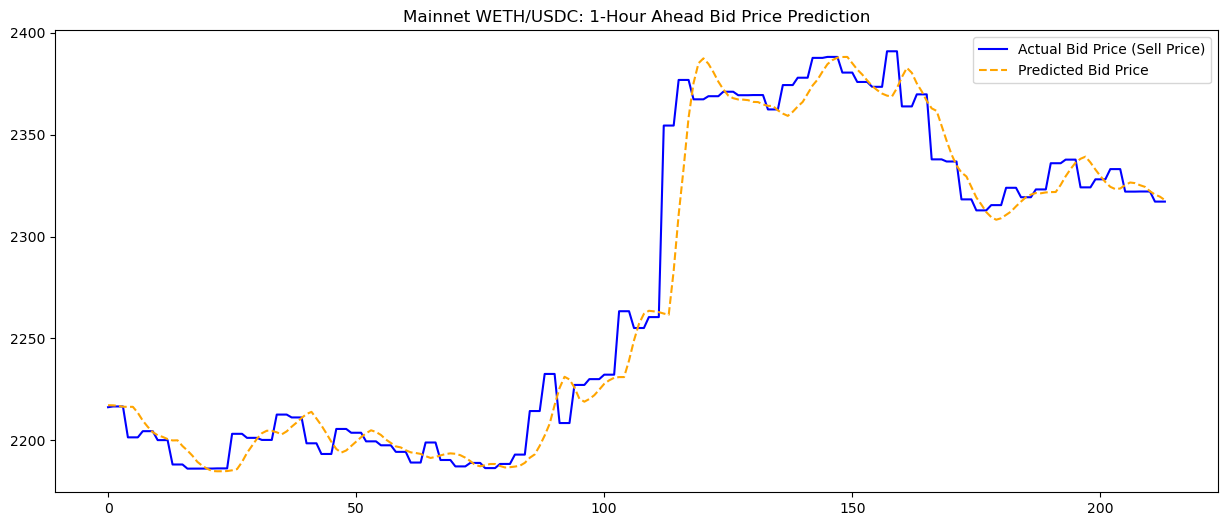

In [7]:
model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    predictions = model(X_test_t).cpu().numpy()

y_test_real = scaler_y.inverse_transform(y_test)
preds_real = scaler_y.inverse_transform(predictions)

plt.figure(figsize=(15, 6))
plt.plot(y_test_real, label='Actual Bid Price (Sell Price)', color='blue')
plt.plot(preds_real, label='Predicted Bid Price', color='orange', linestyle='--')
plt.title('Mainnet WETH/USDC: 1-Hour Ahead Bid Price Prediction')
plt.legend()
plt.show()

_Source notebook: `15_lstm_returns_directional_prediction.ipynb`_

# Advanced LSTM v3: Diagnostic & Feature Refinement
## Strategy: Breaking the Lag and Capturing Real Alpha

This version focuses on diagnosing why the model might be lagging and introduces high-alpha microstructure factors.

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set(style="whitegrid")

if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()


## 1. Feature Engineering: Beyond Simple Returns

In [9]:
ohlcv = pd.read_parquet(PROJECT_ROOT / 'data/mainnet_weth_usdc/curated/pool_ohlcv_hour.parquet')
edges = pd.read_parquet(PROJECT_ROOT / 'data/mainnet_weth_usdc/curated/market_edges_hour.parquet')

df = ohlcv.sort_values('timestamp').merge(edges, on='timestamp', suffixes=('', '_edge'))
df = df.set_index('timestamp')

# --- 1. Momentum & Acceleration ---
df['returns'] = np.log(df['sell_price_usd'] / df['sell_price_usd'].shift(1))
df['accel'] = df['returns'] - df['returns'].shift(1)

# --- 2. Microstructure: Volume-Weighted Spread ---
df['vw_spread'] = df['observed_spread_bps'] * np.log1p(df['volume_usd'])

# --- 3. RSI ---
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

df['rsi'] = calculate_rsi(df['sell_price_usd'])

# Target: Next Hour Returns
df['target'] = df['returns'].shift(-1)

required_cols = ['returns', 'accel', 'vw_spread', 'rsi', 'observed_spread_bps', 'target']
df = df.dropna(subset=required_cols)
print(f"Rows: {len(df)}")

Rows: 2146


## 2. Model Training

In [10]:
feature_cols = ['returns', 'accel', 'vw_spread', 'rsi', 'observed_spread_bps']
scaler_x, scaler_y = StandardScaler(), StandardScaler()
raw_split_idx = int(0.8 * len(df))

scaler_x, scaler_y = StandardScaler(), StandardScaler()

scaler_x.fit(df[feature_cols].iloc[:raw_split_idx])
scaler_y.fit(df[['target']].iloc[:raw_split_idx])

scaled_x = scaler_x.transform(df[feature_cols])
scaled_y = scaler_y.transform(df[['target']])


def create_sequences(x, y, window=24):
    X_s, y_s = [], []
    for i in range(len(x)-window):
        X_s.append(x[i:i+window])
        y_s.append(y[i+window])
    return np.array(X_s), np.array(y_s)

X, y = create_sequences(scaled_x, scaled_y)
seq_split_idx = int(0.8 * len(X))

X_train = torch.tensor(X[:seq_split_idx], dtype=torch.float32).to(device)
X_test = torch.tensor(X[seq_split_idx:], dtype=torch.float32).to(device)
y_train = torch.tensor(y[:seq_split_idx], dtype=torch.float32).to(device)
y_test = torch.tensor(y[seq_split_idx:], dtype=torch.float32).to(device)


class MultiFactorLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 64, 2, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

model = MultiFactorLSTM(len(feature_cols)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.SmoothL1Loss()

for epoch in range(250):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

## 3. Comprehensive Visualization

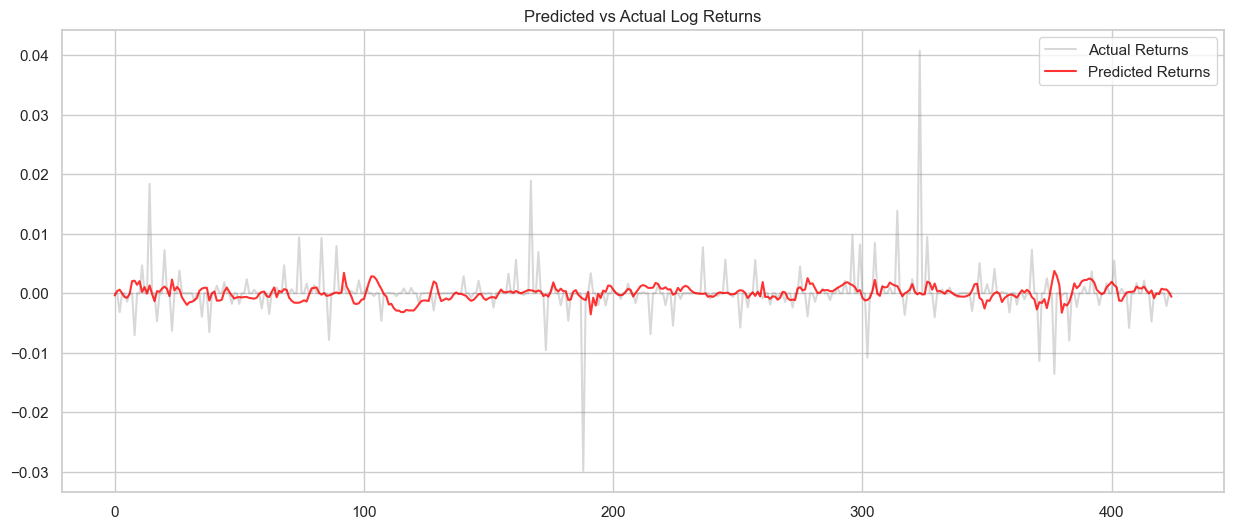

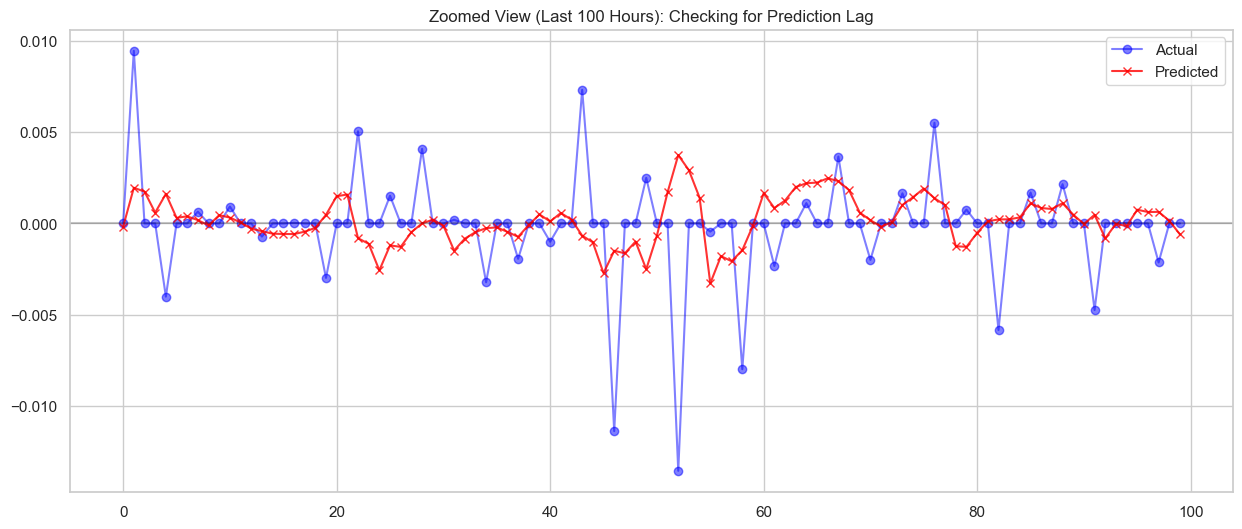

In [11]:
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test).cpu().numpy()
    preds = scaler_y.inverse_transform(preds_scaled).flatten()
    actuals = scaler_y.inverse_transform(y_test.cpu().numpy()).flatten()

# 1. Full comparison
plt.figure(figsize=(15, 6))
plt.plot(actuals, label='Actual Returns', color='gray', alpha=0.3)
plt.plot(preds, label='Predicted Returns', color='red', alpha=0.8)
plt.title('Predicted vs Actual Log Returns')
plt.legend()
plt.show()

# 2. Zoomed View (Detecting Lag)
plt.figure(figsize=(15, 6))
plt.plot(actuals[-100:], label='Actual', color='blue', marker='o', alpha=0.5)
plt.plot(preds[-100:], label='Predicted', color='red', marker='x', alpha=0.8)
plt.axhline(0, color='black', alpha=0.2)
plt.title('Zoomed View (Last 100 Hours): Checking for Prediction Lag')
plt.legend()
plt.show()

## 4. Final Optimized Backtest with Position Visualization

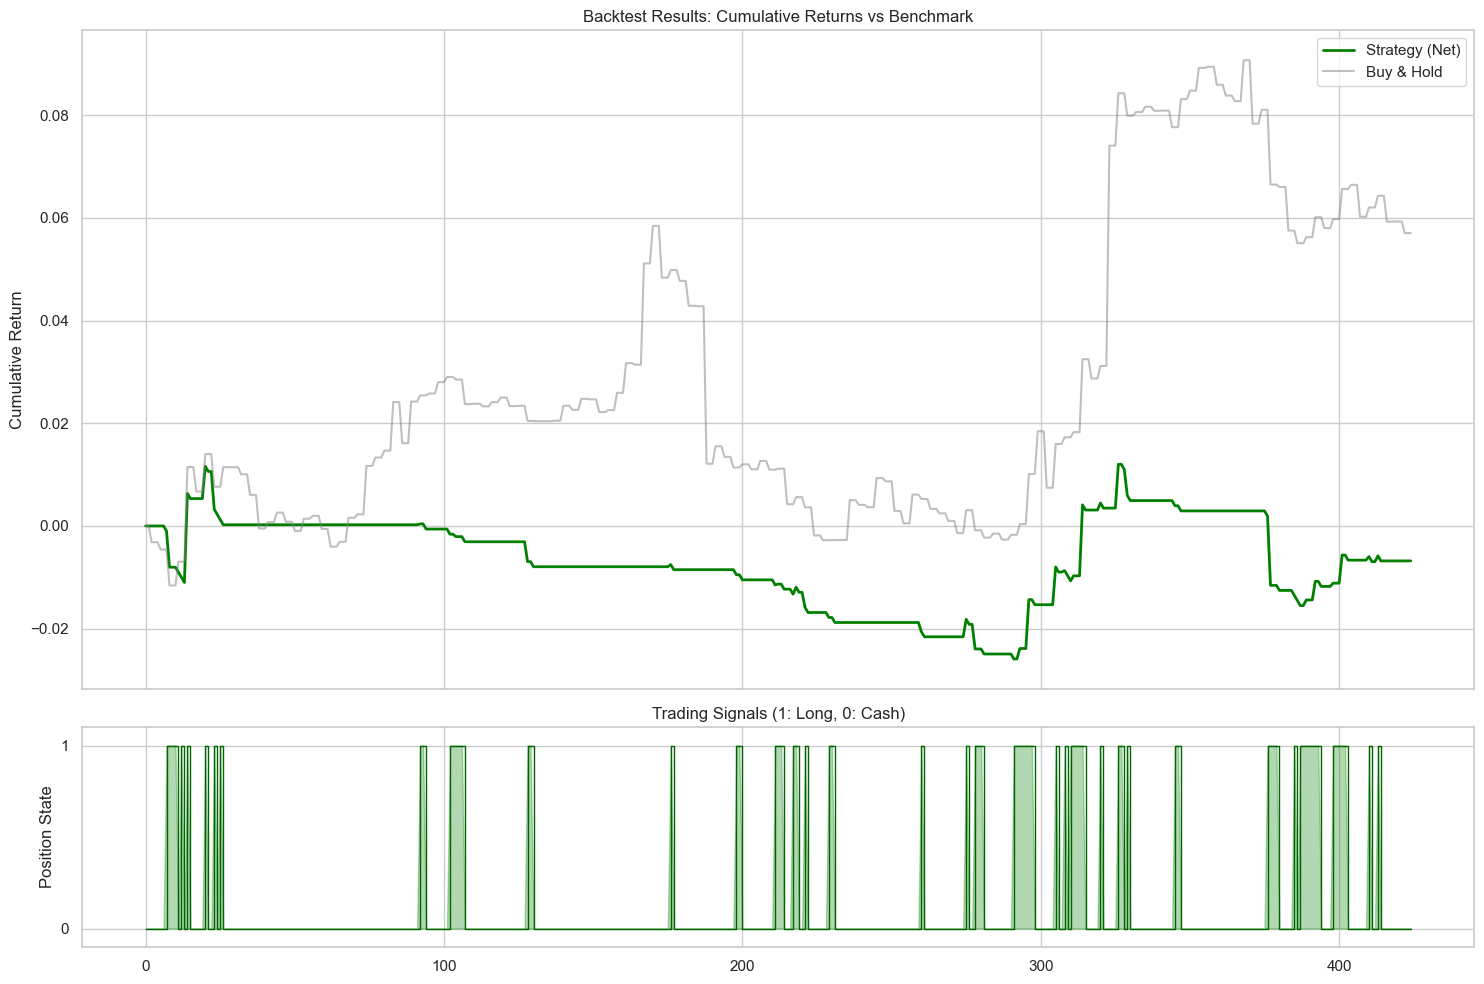

Strategy Final Return: -0.68%
Time in Market: 17.18%


array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.0009995 , -0.00803296, -0.00803296,
       -0.00803296, -0.00902443, -0.01001491, -0.0110044 ,  0.00633908,
        0.00533324,  0.00533324,  0.00533324,  0.00533324,  0.00533324,
        0.01161989,  0.01060878,  0.01060878,  0.00324202,  0.00223928,
        0.00123754,  0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,
        0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,
        0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,
        0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,
        0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,
        0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,
        0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,
        0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,
        0.0002368 ,  0.0002368 ,  0.0002368 ,  0.0002368 ,  0.00

In [12]:
def final_backtest(actuals, preds, fee_bps=10):
    # Confidence Threshold
    threshold = 0.5 * (2 * fee_bps) / 10000.0
    signals = (preds > threshold).astype(int)
    
    # Calculate Returns
    rets = signals * actuals
    trades = np.diff(signals, prepend=0) != 0
    net_rets = rets - (trades * fee_bps / 10000.0)
    
    cum_strat = np.exp(np.cumsum(net_rets)) - 1
    cum_bh = np.exp(np.cumsum(actuals)) - 1
    
    # --- DUAL AXIS PLOT ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    
    # Subplot 1: Cumulative Returns
    ax1.plot(cum_strat, label='Strategy (Net)', color='green', lw=2)
    ax1.plot(cum_bh, label='Buy & Hold', color='gray', alpha=0.5)
    ax1.set_ylabel('Cumulative Return')
    ax1.set_title('Backtest Results: Cumulative Returns vs Benchmark')
    ax1.legend()
    
    # Subplot 2: Position States (1=Long, 0=Cash)
    ax2.fill_between(range(len(signals)), 0, signals, color='green', alpha=0.3)
    ax2.step(range(len(signals)), signals, where='post', color='darkgreen', lw=1)
    ax2.set_ylabel('Position State')
    ax2.set_yticks([0, 1])
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_title('Trading Signals (1: Long, 0: Cash)')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Strategy Final Return: {cum_strat[-1]*100:.2f}%")
    print(f"Time in Market: {signals.mean()*100:.2f}%")
    return cum_strat

final_backtest(actuals, preds)

<!-- PRICE_PREDICTION_MODELS_END -->

# Prediction-Driven Trade Router

_Source notebook: `13_prediction_driven_trade_router.ipynb`_

Supports the final report section where the project shifts from visible arbitrage to prediction-based trade timing.

# Prediction-Driven Trade Router

This section takes the prediction-ready execution dataset, merges an external forecast file from a teammate, and ranks which venue gives the best executable price for the model's direction. It stays usable even before the model exists: if no prediction file is present, it exports the template and shows the routing context only.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent


from prediction_execution import (
    DEFAULT_HORIZONS_HOURS,
    build_trade_candidates,
    export_prediction_ready_bundle,
    market_paths,
    merge_external_predictions,
    prepare_prediction_ready_bundle,
)

plt.style.use('default')

MARKET_SLUG = 'optimism_wbtc_weth'
HORIZONS_HOURS = DEFAULT_HORIZONS_HOURS
MIN_EXPECTED_EDGE_BPS = 5.0

paths = market_paths(PROJECT_ROOT, MARKET_SLUG)
bundle = prepare_prediction_ready_bundle(PROJECT_ROOT, MARKET_SLUG, horizons_hours=HORIZONS_HOURS)
exported_paths = export_prediction_ready_bundle(bundle, horizons_hours=HORIZONS_HOURS)

PREDICTION_FILE = paths['output_dir'] / 'external_predictions.csv'
prediction_frame, prediction_info = merge_external_predictions(bundle['model_frame'], PREDICTION_FILE)
trade_candidates = build_trade_candidates(prediction_frame, min_expected_edge_bps=MIN_EXPECTED_EDGE_BPS)
trade_candidates.to_csv(paths['trade_candidates'], index=False)

actionable = trade_candidates[trade_candidates['trade_side'] != 'hold'].copy()
summary_rows = [
    {'field': 'market_slug', 'value': MARKET_SLUG},
    {'field': 'prediction_status', 'value': prediction_info['status']},
    {'field': 'prediction_file', 'value': str(PREDICTION_FILE)},
    {'field': 'template_file', 'value': str(exported_paths['prediction_template'])},
    {'field': 'prediction_coverage', 'value': prediction_info.get('coverage', np.nan)},
    {'field': 'actionable_rows', 'value': int(len(actionable))},
    {'field': 'min_expected_edge_bps', 'value': MIN_EXPECTED_EDGE_BPS},
]

display(pd.DataFrame(summary_rows))
if prediction_info['status'] == 'missing':
    display(Markdown('## Next Step'))
    display(Markdown(
        'No external prediction file was found yet. Fill the exported `predictions_input_template.csv`, '
        'save it as `external_predictions.csv` in the same output folder, then rerun this notebook.'
    ))
else:
    display(Markdown('## Loaded Prediction Columns'))
    display(pd.DataFrame({'prediction_column': prediction_info.get('prediction_columns', [])}))

In [ ]:
display(Markdown('## Trade Candidate Table'))
candidate_columns = [
    'timestamp', 'trade_side', 'execution_venue', 'execution_price_usd', 'predicted_fair_value',
    'expected_buy_edge_bps', 'expected_sell_edge_bps', 'expected_edge_bps',
    'best_buy_venue', 'best_sell_venue', 'cross_exchange_dispersion_bps'
]
display(trade_candidates.loc[:, [c for c in candidate_columns if c in trade_candidates.columns]].head(50))

display(Markdown('## Actionable Trades Only'))
display(actionable.loc[:, [c for c in candidate_columns if c in actionable.columns]].head(50))

display(Markdown('## Prediction Template Preview'))
display(bundle['prediction_template'].head(25))

In [ ]:
display(Markdown('## Routing Dashboard'))

router = prediction_frame.copy().sort_values('timestamp').reset_index(drop=True)
has_predictions = router['predicted_fair_value'].notna().any()
action_counts = trade_candidates['trade_side'].value_counts().rename_axis('trade_side').reset_index(name='rows')
if actionable.empty:
    venue_counts = router['best_buy_venue'].value_counts().rename_axis('venue').reset_index(name='rows')
else:
    venue_counts = actionable['execution_venue'].value_counts().rename_axis('venue').reset_index(name='rows')

fig, axes = plt.subplots(2, 2, figsize=(18, 11), constrained_layout=True)

axes[0, 0].plot(router['timestamp'], router['reference_price_usd'], linewidth=1.8, label='Reference price')
axes[0, 0].plot(router['timestamp'], router['best_buy_effective_price_usd'], linewidth=1.4, label='Best buy')
axes[0, 0].plot(router['timestamp'], router['best_sell_effective_price_usd'], linewidth=1.4, label='Best sell')
if has_predictions:
    axes[0, 0].plot(router['timestamp'], router['predicted_fair_value'], linewidth=1.6, label='Predicted fair value')
axes[0, 0].set_title('Price and routing context')
axes[0, 0].set_ylabel('Price')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

if has_predictions:
    axes[0, 1].plot(router['timestamp'], router['expected_buy_edge_bps'], linewidth=1.6, label='Expected buy edge')
    axes[0, 1].plot(router['timestamp'], router['expected_sell_edge_bps'], linewidth=1.6, label='Expected sell edge')
    axes[0, 1].axhline(MIN_EXPECTED_EDGE_BPS, color='tab:green', linestyle='--', linewidth=1, label='Trade threshold')
    axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=1)
    axes[0, 1].set_title('Expected edge from predictions')
    axes[0, 1].set_ylabel('Basis points')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].legend()
else:
    axes[0, 1].plot(router['timestamp'], router['cross_exchange_dispersion_bps'], linewidth=1.7, label='Cross-exchange dispersion')
    axes[0, 1].plot(router['timestamp'], router['best_cross_exchange_edge_bps'], linewidth=1.5, label='Best current edge')
    axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=1)
    axes[0, 1].set_title('Routing context while waiting for predictions')
    axes[0, 1].set_ylabel('Basis points')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].legend()

axes[1, 0].bar(action_counts['trade_side'], action_counts['rows'], color=['tab:blue', 'tab:orange', 'tab:green'][:len(action_counts)])
axes[1, 0].set_title('Router decisions')
axes[1, 0].set_ylabel('Rows')
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].bar(venue_counts['venue'], venue_counts['rows'], color='tab:purple')
axes[1, 1].set_title('Chosen execution venue' if not actionable.empty else 'Venue that is currently cheapest to buy')
axes[1, 1].set_ylabel('Rows')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
display(Markdown('## Output Files'))
output_rows = [
    {'artifact': 'prediction_template', 'path': str(exported_paths['prediction_template'])},
    {'artifact': 'model_frame', 'path': str(exported_paths['model_frame'])},
    {'artifact': 'trade_candidates', 'path': str(paths['trade_candidates'])},
]
display(pd.DataFrame(output_rows))